# US House Seat Allocation - 5-Member Proportional System

This notebook calculates how House seats would be distributed under a system where:
- Each state gets districts based on population (1.9M per district)
- Each district elects 5 members proportionally
- Seats are allocated using the largest remainder method with Droop quota (16.67%)

In [54]:
import pandas as pd
import math

## Data: 2020 Census Population by State

In [55]:
CENSUS_2020 = {
    'California': 39538223,
    'Texas': 29145505,
    'Florida': 21538187,
    'New York': 20201249,
    'Pennsylvania': 13002700,
    'Illinois': 12812508,
    'Ohio': 11799448,
    'Georgia': 10711908,
    'North Carolina': 10439388,
    'Michigan': 10077331,
    'New Jersey': 9288994,
    'Virginia': 8631393,
    'Washington': 7705281,
    'Arizona': 7151502,
    'Massachusetts': 7029917,
    'Tennessee': 6910840,
    'Indiana': 6785528,
    'Maryland': 6177224,
    'Missouri': 6154913,
    'Wisconsin': 5893718,
    'Colorado': 5773714,
    'Minnesota': 5706494,
    'South Carolina': 5118425,
    'Alabama': 5024279,
    'Louisiana': 4657757,
    'Kentucky': 4505836,
    'Oregon': 4237256,
    'Oklahoma': 3959353,
    'Connecticut': 3605944,
    'Utah': 3271616,
    'Iowa': 3190369,
    'Nevada': 3104614,
    'Arkansas': 3011524,
    'Mississippi': 2961279,
    'Kansas': 2937880,
    'New Mexico': 2117522,
    'Nebraska': 1961504,
    'Idaho': 1839106,
    'West Virginia': 1793716,
    'Hawaii': 1455271,
    'New Hampshire': 1377529,
    'Maine': 1362359,
    'Montana': 1084225,
    'Rhode Island': 1097379,
    'Delaware': 990837,
    'South Dakota': 886667,
    'North Dakota': 779094,
    'Alaska': 733391,
    'Vermont': 643077,
    'Wyoming': 576851,
}

## Functions

In [312]:
# Constants for seat allocation
TOTAL_US_POP_2020 = sum(CENSUS_2020.values())  # 330,760,625
TARGET_HOUSE_SEATS = 870  # Double the current House (435 * 2)
POP_PER_SEAT = TOTAL_US_POP_2020 / TARGET_HOUSE_SEATS  # ~380,185

def calculate_seats_and_districts(population):
    """
    Calculate total seats and district configuration for a state.
    
    "Double the House" rule: ~380,000 constituents per representative
    Each state gets seats proportional to population (minimum 1 seat).
    
    District Rules:
    - 5-seat and 3-seat districts for states with ≥5 seats
    - 4-seat STATEWIDE district for states with exactly 4 seats
    - 2-seat STATEWIDE district for very small states (2 total seats)
    - 3-seat STATEWIDE district for small states (3 total seats)
    
    2-seat and 4-seat districts are ONLY used as statewide at-large districts,
    never as sub-state districts.
    
    Returns:
        tuple: (total_seats, district_list)
        e.g., (13, [5, 5, 3]) for a state with 13 seats
    """
    # Calculate ideal seats based on population
    raw_seats = population / POP_PER_SEAT
    total_seats = max(1, round(raw_seats))
    
    # Configure districts based on total seats
    if total_seats == 1:
        # Single at-large representative (constitutional minimum)
        districts = [1]
    elif total_seats == 2:
        # Statewide 2-seat district (WY, VT, AK, ND, SD)
        districts = [2]
    elif total_seats == 3:
        # Statewide 3-seat district (DE, MT, RI)
        districts = [3]
    elif total_seats == 4:
        # Statewide 4-seat district (ME, NH, HI)
        # Cannot be made with 5+3, so use single statewide 4-seat
        districts = [4]
    else:
        # For ≥5 seats: use only 5-seat and 3-seat districts
        # Mathematical fact: any integer ≥5 except 7 can be made with 5s and 3s
        # And no state gets exactly 7 seats with our population/seat ratio
        districts = []
        remaining = total_seats
        
        # Find optimal combination of 5s and 3s
        # Strategy: maximize 5-seat districts, fill remainder with 3s
        num_5s = remaining // 5
        remainder = remaining % 5
        
        if remainder == 0:
            # Perfect fit with 5s only
            districts = [5] * num_5s
        elif remainder == 1:
            # 5k + 1: convert one 5 to two 3s → 5(k-1) + 3 + 3 = 5k + 1
            districts = [5] * (num_5s - 1) + [3, 3]
        elif remainder == 2:
            # 5k + 2: convert one 5 to two 3s, add one more 3? No.
            # Actually: 5k + 2 = 5(k-1) + 5 + 2 = 5(k-1) + 3 + 4? No.
            # Better: check if we can do it differently
            # 5k + 2: need to express as 5a + 3b where 5a + 3b = 5k + 2
            # If k >= 1: 5(k-1) + 3*2 + 1? No, that's 5k - 5 + 6 + 1 = 5k + 2. But +1 doesn't work.
            # Actually: 5*1 + 3*(-1) = 2, so we need k >= 2 to convert:
            # 5k + 2 = 5(k-2) + 5 + 5 + 2 = 5(k-2) + 3 + 3 + 3 + 3 = 5k - 10 + 12 = 5k + 2 ✓
            # So: reduce 5s by 2, add 4 threes
            if num_5s >= 2:
                districts = [5] * (num_5s - 2) + [3] * 4
            else:
                # Fallback for edge case (shouldn't happen with our data)
                districts = [5] * num_5s + [2]  # Only if absolutely needed
        elif remainder == 3:
            # 5k + 3: just add one 3-seat district
            districts = [5] * num_5s + [3]
        elif remainder == 4:
            # 5k + 4: convert one 5 to two 3s, add one more 3? 
            # 5(k-1) + 3 + 3 + 4? No.
            # 5k + 4 = 5(k-1) + 5 + 4 = 5(k-1) + 3 + 3 + 3 = 5k - 5 + 9 = 5k + 4 ✓
            districts = [5] * (num_5s - 1) + [3] * 3
        
        districts = sorted(districts, reverse=True)
    
    return total_seats, districts


def allocate_seats_multiparty_variable(party_shares, district_sizes):
    """
    Allocate seats using Largest Remainder Method for variable-size districts.
    
    Each district is allocated independently based on the same party vote shares,
    then seats are summed across all districts.
    
    Args:
        party_shares: dict with party names as keys and vote share as PERCENTAGES (0-100)
        district_sizes: list of district sizes, e.g., [5, 5, 3]
    
    Returns:
        dict with allocated seats for each party
    """
    total_allocation = {party: 0 for party in party_shares.keys()}
    
    for district_seats in district_sizes:
        # Allocate this district using Largest Remainder (Hare Quota)
        seats_allocated = {}
        remainders = {}
        
        total_allocated = 0
        for party, pct in party_shares.items():
            share = pct / 100.0
            ideal_seats = share * district_seats
            whole_seats = int(ideal_seats)
            seats_allocated[party] = whole_seats
            remainders[party] = ideal_seats - whole_seats
            total_allocated += whole_seats
        
        # Distribute remaining seats by largest remainder
        seats_remaining = district_seats - total_allocated
        sorted_parties = sorted(remainders.keys(), key=lambda p: remainders[p], reverse=True)
        
        for i in range(seats_remaining):
            party = sorted_parties[i]
            seats_allocated[party] += 1
        
        # Add to total
        for party, seats in seats_allocated.items():
            total_allocation[party] += seats
    
    return total_allocation


# Validation
print("Seat Allocation System: 'Double the House' Rule")
print("="*70)
print(f"Total US Population: {TOTAL_US_POP_2020:,}")
print(f"Target Seats: {TARGET_HOUSE_SEATS}")
print(f"Population per Seat: {POP_PER_SEAT:,.0f}")
print()
print("District Rules:")
print("  - 5-seat and 3-seat districts for states with ≥5 seats")
print("  - 4-seat STATEWIDE for states with 4 seats (ME, NH, HI)")
print("  - 2-seat STATEWIDE for very small states (WY, VT, AK, ND, SD)")
print()

# Test with all states to verify no 2-seat sub-districts
total_seats = 0
total_districts = 0
district_counts = {1: 0, 2: 0, 3: 0, 4: 0, 5: 0}

for state, pop in sorted(CENSUS_2020.items(), key=lambda x: x[1]):
    seats, districts = calculate_seats_and_districts(pop)
    total_seats += seats
    total_districts += len(districts)
    for d in districts:
        district_counts[d] = district_counts.get(d, 0) + 1
    
    district_str = '+'.join(str(d) for d in districts)
    if seats <= 5 or any(d == 2 for d in districts) or any(d == 4 for d in districts):
        print(f"{state:15s}: {seats:3d} seats [{district_str:15s}]")

print()
print(f"Total: {total_seats} seats in {total_districts} districts")
print(f"  5-seat districts: {district_counts.get(5, 0)}")
print(f"  4-seat districts: {district_counts.get(4, 0)} (statewide only)")
print(f"  3-seat districts: {district_counts.get(3, 0)}")
print(f"  2-seat districts: {district_counts.get(2, 0)} (statewide only)")
print(f"  1-seat districts: {district_counts.get(1, 0)}")

Seat Allocation System: 'Double the House' Rule
Total US Population: 330,760,625
Target Seats: 870
Population per Seat: 380,185

District Rules:
  - 5-seat and 3-seat districts for states with ≥5 seats
  - 4-seat STATEWIDE for states with 4 seats (ME, NH, HI)
  - 2-seat STATEWIDE for very small states (WY, VT, AK, ND, SD)

Wyoming        :   2 seats [2              ]
Vermont        :   2 seats [2              ]
Alaska         :   2 seats [2              ]
North Dakota   :   2 seats [2              ]
South Dakota   :   2 seats [2              ]
Delaware       :   3 seats [3              ]
Montana        :   3 seats [3              ]
Rhode Island   :   3 seats [3              ]
Maine          :   4 seats [4              ]
New Hampshire  :   4 seats [4              ]
Hawaii         :   4 seats [4              ]
West Virginia  :   5 seats [5              ]
Idaho          :   5 seats [5              ]
Nebraska       :   5 seats [5              ]

Total: 871 seats in 207 districts
  5-seat d

In [313]:
def allocate_seats_proportional(vote_percentages, districts, seats_per_district=5):
    """
    Allocate seats using the Largest Remainder Method (Droop Quota).
    
    Args:
        vote_percentages: dict with 'Dem', 'Rep', 'Other' percentages
        districts: number of districts in the state
        seats_per_district: seats per district (default 5)
    
    Returns:
        dict with allocated seats for each party
    """
    total_seats = districts * seats_per_district
    
    # Droop quota: 1/(seats_per_district + 1) = 1/6 = 16.67%
    quota_decimal = 1 / (seats_per_district + 1)
    quota_percent = quota_decimal * 100
    
    seats_allocated = {}
    remainders = {}
    
    # Step 1: Allocate safe seats based on quota
    total_allocated = 0
    for party, vote_pct in vote_percentages.items():
        # Number of quotas this party earned
        quotas_earned = vote_pct / quota_percent
        safe_seats = math.floor(quotas_earned) * districts
        seats_allocated[party] = safe_seats
        total_allocated += safe_seats
        
        # Store the fractional remainder for later
        remainders[party] = (quotas_earned - math.floor(quotas_earned)) * districts
    
    # Step 2: Allocate remaining seats based on largest remainders
    remaining_seats = total_seats - total_allocated
    
    # Sort parties by remainder (largest first)
    sorted_parties = sorted(remainders.items(), key=lambda x: x[1], reverse=True)
    
    for i in range(remaining_seats):
        if i < len(sorted_parties):
            party = sorted_parties[i][0]
            seats_allocated[party] += 1
    
    return seats_allocated


def allocate_seats_variable_districts(vote_percentages, district_sizes):
    """
    Allocate seats for 2-party (Dem/Rep/Other) using variable district sizes.
    Uses Largest Remainder Method for each district independently.
    
    Args:
        vote_percentages: dict with 'Dem', 'Rep', 'Other' percentages
        district_sizes: list of district sizes, e.g., [5, 5, 3]
    
    Returns:
        dict with allocated seats for each party
    """
    total_allocation = {party: 0 for party in vote_percentages.keys()}
    
    for district_seats in district_sizes:
        seats_allocated = {}
        remainders = {}
        total_allocated = 0
        
        for party, vote_pct in vote_percentages.items():
            share = vote_pct / 100.0
            ideal_seats = share * district_seats
            whole_seats = int(ideal_seats)
            seats_allocated[party] = whole_seats
            remainders[party] = ideal_seats - whole_seats
            total_allocated += whole_seats
        
        remaining_seats = district_seats - total_allocated
        sorted_parties = sorted(remainders.keys(), key=lambda p: remainders[p], reverse=True)
        
        for i in range(remaining_seats):
            party = sorted_parties[i]
            seats_allocated[party] += 1
        
        for party, seats in seats_allocated.items():
            total_allocation[party] += seats
    
    return total_allocation


def allocate_seats_multiparty(party_shares, districts, seats_per_district=5):
    """
    Allocate seats using the Largest Remainder Method (Hare Quota) for any number of parties.
    
    This is a generalized version that works with data-driven party clusters from CES analysis.
    
    Args:
        party_shares: dict with party names as keys and vote share as PERCENTAGES (0-100)
                     e.g., {'Progressives': 20.5, 'Conservatives': 17.8, ...}
        districts: number of districts in the state
        seats_per_district: seats per district (default 5)
    
    Returns:
        dict with allocated seats for each party
    """
    total_seats = districts * seats_per_district
    
    seats_allocated = {}
    remainders = {}
    
    # Step 1: Calculate each party's "ideal" seat share and allocate whole seats
    total_allocated = 0
    for party, pct in party_shares.items():
        # Convert percentage to decimal (e.g., 20.5% -> 0.205)
        share = pct / 100.0
        # Party's ideal number of seats based on their vote share
        ideal_seats = share * total_seats
        # Allocate the whole number portion
        whole_seats = int(ideal_seats)
        seats_allocated[party] = whole_seats
        total_allocated += whole_seats
        
        # Store the fractional remainder
        remainders[party] = ideal_seats - whole_seats
    
    # Step 2: Allocate remaining seats by largest remainder
    remaining_seats = total_seats - total_allocated
    
    # Sort parties by remainder (descending)
    sorted_by_remainder = sorted(remainders.items(), key=lambda x: x[1], reverse=True)
    
    for i in range(remaining_seats):
        if i < len(sorted_by_remainder):
            party = sorted_by_remainder[i][0]
            seats_allocated[party] += 1
    
    return seats_allocated

# Congressional Multiparty Analysis Using CES 2024

This section uses actual survey responses from 60,000 voters to discover natural party groupings through clustering analysis, without imposing preconceived notions of what parties should look like.

## Step 1: Load CES 2024 Data

In [651]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load CES 2024 data
ces_df = pd.read_csv('dataverse_files/CCES24_Common_OUTPUT_vv_topost_final.csv')

print(f"Loaded {len(ces_df):,} respondents")
print(f"Columns: {len(ces_df.columns)}")

Loaded 60,000 respondents
Columns: 694


## Step 2: Extract Policy Questions (36 questions across 9 dimensions)

In [652]:
# DOMESTIC POLICY QUESTIONS - Used for clustering (37 questions)
# Foreign policy excluded due to "exclusive option" coding artifacts in survey design
clustering_questions = [
    # Abortion (5) - added CC24_324c
    'CC24_324a', 'CC24_324b', 'CC24_324c', 'CC24_324d', 'CC24_325',
    # Immigration (5) - added CC24_323b
    'CC24_323a', 'CC24_323b', 'CC24_323c', 'CC24_323d', 'CC24_340f',
    # Guns & Policing (6)
    'CC24_321a', 'CC24_321b', 'CC24_321c', 'CC24_321d', 'CC24_321e', 'CC24_321f',
    # Environment (6) - added CC24_326f
    'CC24_326a', 'CC24_326b', 'CC24_326c', 'CC24_326d', 'CC24_326e', 'CC24_326f',
    # Taxation (4)
    'CC24_341a', 'CC24_341b', 'CC24_341c', 'CC24_341d',
    # Healthcare (3)
    'CC24_328c', 'CC24_328d', 'CC24_328e',
    # Student Loans (1)
    'CC24_323f',
    # Housing (2)
    'CC24_328a', 'CC24_328b',
    # Civil Rights (3)
    'CC24_340a', 'CC24_340b', 'CC24_340c',
    # Surveillance (2)
    'CC24_340d', 'CC24_340e'
]

# FOREIGN POLICY QUESTIONS - Excluded from clustering, but included in reporting
# These have "exclusive option" survey design that creates clustering artifacts
foreign_policy_questions = [
    # Ukraine (6)
    'CC24_308a_1', 'CC24_308a_2', 'CC24_308a_3', 'CC24_308a_4', 'CC24_308a_5', 'CC24_308a_8',
    # Israel/Gaza (9)
    'CC24_308b_1', 'CC24_308b_2', 'CC24_308b_3', 'CC24_308b_4', 'CC24_308b_5', 
    'CC24_308b_6', 'CC24_308b_7', 'CC24_308b_8', 'CC24_308b_9'
]

# All questions for reporting purposes
all_policy_questions = clustering_questions + foreign_policy_questions

# Extract policy columns + key demographic/geographic variables
demographic_cols = ['birthyr', 'gender4', 'race', 'educ', 'faminc_new', 'employ', 'marstat', 'region', 'religpew', 'child18', 'urbancity']

# Horserace political columns (approval ratings, economic perceptions, vote choice)
# These are NOT used for clustering (they're partisan proxies) but useful for analysis

# PRE-ELECTION questions
pre_election_cols = [
    'CC24_312a', 'CC24_312i', 'CC24_312c', 'CC24_312b',  # Approvals: Biden, Harris, SCOTUS, Congress
    'CC24_301', 'CC24_302', 'CC24_303',                   # Economic perceptions
    'CC24_364b'                                           # Pre-election presidential preference
]

# POST-ELECTION questions
post_election_cols = [
    # Vote turnout & method
    'CC24_401',   # Turnout: "I definitely voted in the November 2024 General Election"
    'CC24_403',   # Vote method (in-person, mail/absentee, etc.)
    'CC24_404',   # Voting experience (in-person voters)
    'CC24_405',   # Voting experience (mail voters in certain states)
    
    # Actual vote choice (for voters)
    'CC24_410',   # Presidential vote (1=Harris, 2=Trump, 3=RFK, 4=Stein, 5=West, 6=Oliver, 8=Other, 9=Did not vote)
    'CC24_411',   # Senate vote
    'CC24_412',   # House vote  
    'CC24_413',   # Governor vote
    
    # Candidate party columns (to map vote choice to party)
    'SenCand1Party', 'SenCand2Party', 'SenCand3Party',
    'HouseCand1Party', 'HouseCand2Party', 'HouseCand3Party',
    'GovCand1Party', 'GovCand2Party', 'GovCand3Party',
    
    # Non-voter preferences
    'CC24_410_nv',  # Presidential preference (non-voters)
    'CC24_411_nv',  # Senate preference (non-voters)
    'CC24_412_nv',  # House preference (non-voters)
    'CC24_413_nv',  # Governor preference (non-voters)
    
    # Candidate evaluations
    'CC24_416a', 'CC24_416b', 'CC24_416c',  # House candidate evaluations
    
    # Additional turnout info
    'CC24_402a', 'CC24_402b',  # Past voting behavior
    'CC24_406a', 'CC24_406b', 'CC24_406c',  # Ballot issues
]

horserace_cols = pre_election_cols + post_election_cols

analysis_cols = all_policy_questions + ['inputstate', 'commonweight', 'ideo5', 'pid3', 'pid7'] + demographic_cols + horserace_cols

# Filter to only columns that exist in the dataset (some post-election cols may not exist)
existing_cols = [c for c in analysis_cols if c in ces_df.columns]
missing_cols = [c for c in analysis_cols if c not in ces_df.columns]
if missing_cols:
    print(f"Note: {len(missing_cols)} requested columns not in dataset: {missing_cols[:10]}{'...' if len(missing_cols) > 10 else ''}")

analysis_cols = existing_cols
ces_policy = ces_df[analysis_cols].copy()

print(f"Extracted {len(clustering_questions)} DOMESTIC policy questions for clustering")
print(f"Extracted {len(foreign_policy_questions)} FOREIGN POLICY questions for reporting only")
print(f"Total: {len(all_policy_questions)} policy questions")
print(f"Sample size before cleaning: {len(ces_policy):,}")

# Remove rows with too many missing values (keep if at least 30 of 37 clustering questions answered)
ces_policy = ces_policy.dropna(subset=clustering_questions, thresh=30)

print(f"Sample size after removing incomplete responses: {len(ces_policy):,}")
print(f"\nMissing data by clustering question (top 10):")
missing_counts = ces_policy[clustering_questions].isnull().sum().sort_values(ascending=False)
print(missing_counts.head(10))

Note: 1 requested columns not in dataset: ['CC24_406b']
Extracted 37 DOMESTIC policy questions for clustering
Extracted 15 FOREIGN POLICY questions for reporting only
Total: 52 policy questions
Sample size before cleaning: 60,000
Sample size after removing incomplete responses: 59,989

Missing data by clustering question (top 10):
CC24_325     2036
CC24_341a     447
CC24_340d     315
CC24_340c     304
CC24_341d     256
CC24_340e     217
CC24_341c     205
CC24_340b     203
CC24_340f     181
CC24_341b     178
dtype: int64


## Step 3: Prepare Data for Clustering (Handle Different Scales)

In [653]:
# Handle missing values - use median imputation
from sklearn.impute import SimpleImputer

# Separate CC24_325 (continuous 0-40) from binary questions (1-2)
continuous_questions = ['CC24_325']
binary_questions = [q for q in clustering_questions if q not in continuous_questions]

# Impute missing values for ALL questions (clustering + foreign policy for reporting)
imputer = SimpleImputer(strategy='median')
ces_policy_imputed = ces_policy.copy()
ces_policy_imputed[all_policy_questions] = imputer.fit_transform(ces_policy[all_policy_questions])

# Create feature matrix for clustering - ONLY domestic policy questions
# Foreign policy questions excluded due to "exclusive option" survey design artifacts
X = ces_policy_imputed[clustering_questions].values

# Standardize all features (handles different scales)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Feature matrix shape: {X_scaled.shape}")
print(f"  - {len(ces_policy_imputed)} respondents")
print(f"  - {len(clustering_questions)} DOMESTIC policy questions (used for clustering)")
print(f"  - {len(foreign_policy_questions)} FOREIGN POLICY questions (reporting only)")
print(f"\nCC24_325 (abortion weeks) distribution:")
print(ces_policy_imputed['CC24_325'].describe())
print(f"\nExample binary question (CC24_323c - border wall) distribution:")
print(ces_policy_imputed['CC24_323c'].value_counts())

Feature matrix shape: (59989, 37)
  - 59989 respondents
  - 37 DOMESTIC policy questions (used for clustering)
  - 15 FOREIGN POLICY questions (reporting only)

CC24_325 (abortion weeks) distribution:
count    59989.000000
mean        17.009302
std         12.063299
min          0.000000
25%          8.000000
50%         15.000000
75%         24.000000
max         40.000000
Name: CC24_325, dtype: float64

Example binary question (CC24_323c - border wall) distribution:
CC24_323c
2.0    30314
1.0    29675
Name: count, dtype: int64


## Step 4: Run K-Means Clustering (k=4 through 8)

Testing different numbers of clusters...

k=4: Inertia=1,547,632, Silhouette=0.1100, Cluster sizes=[20662  6403 20420 12504]
k=5: Inertia=1,501,673, Silhouette=0.0793, Cluster sizes=[13164 13709  3189 15263 14664]
k=6: Inertia=1,470,437, Silhouette=0.0627, Cluster sizes=[11820  6170  9257  9607 10498 12637]
k=7: Inertia=1,442,405, Silhouette=0.0603, Cluster sizes=[11752  3518  9586 12442 10521  3149  9021]
k=8: Inertia=1,420,332, Silhouette=0.0674, Cluster sizes=[10990  9723  6997  8451 12029  3091  2850  5858]


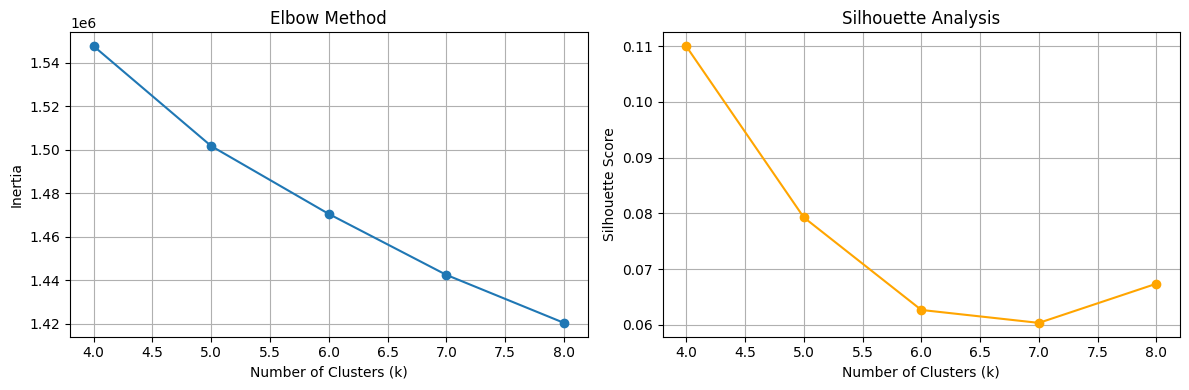


RECOMMENDATION:
Best k based on silhouette score: 4


In [654]:
# Test different numbers of clusters
inertias = []
silhouette_scores = []
k_range = range(4, 9)

print("Testing different numbers of clusters...\n")

cluster_models = {}
for k in k_range:
    print(f"k={k}: ", end='')
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels = kmeans.fit_predict(X_scaled)
    
    inertia = kmeans.inertia_
    silhouette = silhouette_score(X_scaled, labels)
    
    inertias.append(inertia)
    silhouette_scores.append(silhouette)
    cluster_models[k] = (kmeans, labels)
    
    print(f"Inertia={inertia:,.0f}, Silhouette={silhouette:.4f}, Cluster sizes={np.bincount(labels)}")

# Plot elbow curve and silhouette scores
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(k_range, inertias, marker='o')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method')
ax1.grid(True)

ax2.plot(k_range, silhouette_scores, marker='o', color='orange')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Analysis')
ax2.grid(True)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("RECOMMENDATION:")
best_k = list(k_range)[silhouette_scores.index(max(silhouette_scores))]
print(f"Best k based on silhouette score: {best_k}")
print("="*80)

## Step 5: Select Optimal k and Profile Clusters

In [655]:
# Use k=6 as starting point (can adjust based on results)
optimal_k = 6
kmeans_final, labels_final = cluster_models[optimal_k]

# Add cluster assignments to dataframe
ces_policy_imputed['cluster'] = labels_final

print(f"Using k={optimal_k} clusters")
print(f"\nCluster sizes:")
for i in range(optimal_k):
    count = (labels_final == i).sum()
    pct = count / len(labels_final) * 100
    print(f"  Cluster {i}: {count:6,} ({pct:5.1f}%)")

Using k=6 clusters

Cluster sizes:
  Cluster 0: 11,820 ( 19.7%)
  Cluster 1:  6,170 ( 10.3%)
  Cluster 2:  9,257 ( 15.4%)
  Cluster 3:  9,607 ( 16.0%)
  Cluster 4: 10,498 ( 17.5%)
  Cluster 5: 12,637 ( 21.1%)


## Step 6: Profile Each Cluster - What Makes Them Unique?

In [656]:
# COMPREHENSIVE CLUSTER PROFILES - ALL POLICY QUESTIONS (UNLABELED)
# Use this to verify data before assigning party names in Step 7
# NOTE: Foreign policy questions (Ukraine, Israel/Gaza) included for reporting but NOT used in clustering
#       due to "exclusive option" survey design that creates clustering artifacts

question_text = {
    # ABORTION (5)
    'CC24_324a': 'Always allow a woman the right to obtain an abortion as a matter of choice',
    'CC24_324b': 'Permit abortion only in case of rape, incest or when the woman\'s life is in danger',
    'CC24_324c': 'Make abortions illegal in all circumstances',
    'CC24_324d': 'Expand access to abortion, including making it more affordable, broadening the types of providers who can offer care, and protecting access to abortion clinics',
    'CC24_325': 'Until what point in a pregnancy (in weeks) do you think a woman should be legally allowed to obtain an abortion?',
    
    # IMMIGRATION (5)
    'CC24_323a': 'Grant legal status to all illegal immigrants who have held jobs and paid taxes for at least 3 years, and not been convicted of any felony crimes',
    'CC24_323b': 'Increase the number of border patrols on the US-Mexican border',
    'CC24_323c': 'Build a wall between the U.S. and Mexico',
    'CC24_323d': 'Provide permanent resident status to children of immigrants who were brought to the United States by their parents (also known as Dreamers). Provide these immigrants a pathway to citizenship if they meet the citizenship requirements and have committed no crimes',
    'CC24_340f': 'Deny access to asylum for immigrants who cross the US-Mexico border illegally',
    
    # GUNS & POLICING (6)
    'CC24_321a': 'Ban assault rifles',
    'CC24_321b': 'Make it easier for people to obtain concealed-carry permit',
    'CC24_321c': 'Require criminal background checks on all gun sales',
    'CC24_321d': 'Increase the number of police on the street by 10 percent, even if it means fewer funds for other public services',
    'CC24_321e': 'Decrease the number of police on the street by 10 percent, and increase funding for other public services',
    'CC24_321f': 'Increase spending on mental health and school safety; Allow police to confiscate guns from people deemed to be dangerous by a judge; Prohibit people convicted of domestic violence from owning guns; enhance background checks on minors; Increase penalties for illegal gun purchases',
    
    # ENVIRONMENT (6)
    'CC24_326a': 'Give the Environmental Protection Agency power to regulate carbon dioxide emissions',
    'CC24_326b': 'Require that at least 20 percent of electricity be generated with renewable sources such as wind, solar, or hydroelectric power',
    'CC24_326c': 'Strengthen the Environmental Protection Agency enforcement of the Clean Air Act and Clean Water Act even if it costs U.S. jobs',
    'CC24_326d': 'Increase fossil fuel production in the U.S.',
    'CC24_326e': 'Halt new oil and gas leases on federal lands',
    'CC24_326f': 'Prevent the government from banning gas stoves',
    
    # TAXATION (4)
    'CC24_341a': 'Extend the tax cuts enacted in 2017, which reduced individual and corporate income tax rates and limited deductions on mortgage interest and state and local taxes',
    'CC24_341b': 'Raise the corporate income tax rate from 21 percent to 28 percent',
    'CC24_341c': 'Allow tax rates on those earning $400,000 or more a year to rise to 35 percent',
    'CC24_341d': 'Spend $150 billion a year for 8 years on construction and repair of roads and bridges, rail, public transit, airports, water systems, broadband internet, and electric grid',
    
    # HEALTHCARE & HOUSING (6)
    'CC24_328a': 'Relax local zoning laws in your state to allow for construction of more apartments and condos',
    'CC24_328b': 'Expand federal tax incentives to encourage developers to build homes for people who make less than half of the average income in your area',
    'CC24_328c': 'Require able-bodied adults under 64 years of age who do not have dependents to have a job in order to receive Medicaid',
    'CC24_328d': 'Repeal the Affordable Care Act',
    'CC24_328e': 'Expand Medicaid to cover individuals making less than $25,000 and families making less than $40,000 a year',
    'CC24_323f': 'Forgive up to $20,000 of student loan debt for each person',
    
    # CIVIL RIGHTS (3)
    'CC24_340a': 'Prohibit government restrictions on the provision of, and access to, contraceptives',
    'CC24_340b': 'Prohibit government restrictions on the provision of, and access to, abortion services',
    'CC24_340c': 'Require that all federal agencies recognize same-sex marriages and interracial marriages',
    
    # SURVEILLANCE (2)
    'CC24_340d': 'Ban TikTok unless China sells it to a US company',
    'CC24_340e': 'Renew the federal surveillance programs that were adopted after 9/11 and that allow the government to search private electronic data without a search warrant',
    
    # FOREIGN POLICY - UKRAINE (6) - Not used for clustering due to exclusive option survey design
    'CC24_308a_1': 'Do not get involved [in Ukraine]',
    'CC24_308a_2': 'Send food, medicine, and other humanitarian aid to Ukraine',
    'CC24_308a_3': 'Impose economic sanctions on Russia',
    'CC24_308a_4': 'Provide arms to Ukraine',
    'CC24_308a_5': 'Send military support staff to Ukraine (non-combat)',
    'CC24_308a_8': 'Send aid to the affected communities after the conflict to help rebuild destroyed schools, hospitals, and roads',
    
    # FOREIGN POLICY - ISRAEL/GAZA (9) - Not used for clustering due to exclusive option survey design
    'CC24_308b_1': 'Do not get involved [in Israel/Gaza]',
    'CC24_308b_2': 'Send food, medicine and other aid to the communities affected',
    'CC24_308b_3': 'Provide arms to Israel',
    'CC24_308b_4': 'Provide arms to Hamas',
    'CC24_308b_5': 'Send the US Navy and troops to the region to keep the hostility from escalating',
    'CC24_308b_6': 'Send military support staff (non-combat) to Israel',
    'CC24_308b_7': 'Send military support staff (non-combat) to Gaza',
    'CC24_308b_8': 'Negotiate a peace settlement',
    'CC24_308b_9': 'Send aid to the affected communities after the conflict to help rebuild destroyed schools, hospitals, and roads'
}

question_categories = {
    'ABORTION': ['CC24_324a', 'CC24_324b', 'CC24_324c', 'CC24_324d', 'CC24_325'],
    'IMMIGRATION': ['CC24_323a', 'CC24_323b', 'CC24_323c', 'CC24_323d', 'CC24_340f'],
    'GUNS & POLICING': ['CC24_321a', 'CC24_321b', 'CC24_321c', 'CC24_321d', 'CC24_321e', 'CC24_321f'],
    'ENVIRONMENT': ['CC24_326a', 'CC24_326b', 'CC24_326c', 'CC24_326d', 'CC24_326e', 'CC24_326f'],
    'TAXATION': ['CC24_341a', 'CC24_341b', 'CC24_341c', 'CC24_341d'],
    'HEALTHCARE & HOUSING': ['CC24_328a', 'CC24_328b', 'CC24_328c', 'CC24_328d', 'CC24_328e', 'CC24_323f'],
    'CIVIL RIGHTS': ['CC24_340a', 'CC24_340b', 'CC24_340c'],
    'SURVEILLANCE': ['CC24_340d', 'CC24_340e'],
    'FOREIGN POLICY (Ukraine)': ['CC24_308a_1', 'CC24_308a_2', 'CC24_308a_3', 'CC24_308a_4', 'CC24_308a_5', 'CC24_308a_8'],
    'FOREIGN POLICY (Israel/Gaza)': ['CC24_308b_1', 'CC24_308b_2', 'CC24_308b_3', 'CC24_308b_4', 'CC24_308b_5', 'CC24_308b_6', 'CC24_308b_7', 'CC24_308b_8', 'CC24_308b_9']
}

print("="*120)
print("RAW CLUSTER PROFILES - All Policy Questions (NO PARTY LABELS YET)")
print("="*120)
print(f"\nClustering used {len(clustering_questions)} DOMESTIC policy questions")
print(f"Foreign policy ({len(foreign_policy_questions)} questions) included for reporting only - excluded from clustering")
print("\n*** All demographics and policy percentages are WEIGHTED using commonweight ***")
print("*** This ensures national representativeness (corrects for survey oversampling) ***")
print("\nNote: 1=Support/Selected, 2=Oppose/Not Selected. Percentages = % who SUPPORT (value=1)")
print("      CC24_325 = mean weeks until abortion should be legal\n")

for cluster_id in range(optimal_k):
    cluster_data = ces_policy_imputed[ces_policy_imputed['cluster'] == cluster_id].copy()
    n = len(cluster_data)
    total_weight = cluster_data['commonweight'].sum()
    
    # Helper function for weighted percentages - uses closure over cluster_data and total_weight
    def make_wpct(data, tw):
        def wpct(mask):
            """Calculate weighted percentage for a boolean mask"""
            return (data.loc[mask, 'commonweight'].sum() / tw) * 100
        return wpct
    wpct = make_wpct(cluster_data, total_weight)
    
    print(f"\n{'='*120}")
    print(f"CLUSTER {cluster_id} - n={n:,} ({n/len(ces_policy_imputed)*100:.1f}% of voters)")
    print(f"{'='*120}")
    
    # Political Identity (weighted)
    print(f"\nPOLITICAL IDENTITY:")
    print(f"  Party ID:  Dem={wpct(cluster_data['pid3']==1):.1f}%, Rep={wpct(cluster_data['pid3']==2):.1f}%, Ind={wpct(cluster_data['pid3']==3):.1f}%")
    print(f"  Ideology:  VLib={wpct(cluster_data['ideo5']==1):.1f}%, Lib={wpct(cluster_data['ideo5']==2):.1f}%, Mod={wpct(cluster_data['ideo5']==3):.1f}%, Con={wpct(cluster_data['ideo5']==4):.1f}%, VCon={wpct(cluster_data['ideo5']==5):.1f}%")
    
    # Age & Gender (weighted)
    print(f"\nAGE & GENDER:")
    weighted_mean_age = 2024 - np.average(cluster_data['birthyr'], weights=cluster_data['commonweight'])
    print(f"  Mean Age: {weighted_mean_age:.1f} years old")
    print(f"  Gender: Male={wpct(cluster_data['gender4']==1):.1f}%, Female={wpct(cluster_data['gender4']==2):.1f}%, Non-binary/Other={wpct(cluster_data['gender4']>=3):.1f}%")
    
    # Race & Education (weighted)
    print(f"\nRACE & EDUCATION:")
    print(f"  Race: White={wpct(cluster_data['race']==1):.1f}%, Black={wpct(cluster_data['race']==2):.1f}%, Hispanic={wpct(cluster_data['race']==3):.1f}%, Asian={wpct(cluster_data['race']==4):.1f}%, Other={wpct(cluster_data['race']>=5):.1f}%")
    print(f"  Education: No HS={wpct(cluster_data['educ']==1):.1f}%, HS={wpct(cluster_data['educ']==2):.1f}%, Some College={wpct(cluster_data['educ']==3):.1f}%, Associate={wpct(cluster_data['educ']==4):.1f}%, Bachelor={wpct(cluster_data['educ']==5):.1f}%, Postgrad={wpct(cluster_data['educ']==6):.1f}%")
    
    # Income & Employment (weighted)
    print(f"\nECONOMIC:")
    print(f"  Employment: Full-time={wpct(cluster_data['employ']==1):.1f}%, Part-time={wpct(cluster_data['employ']==2):.1f}%, Unemployed={wpct(cluster_data['employ']==4):.1f}%, Retired={wpct(cluster_data['employ']==5):.1f}%, Other={wpct(cluster_data['employ']>=6):.1f}%")
    # Weighted median income (approximate using weighted quantile)
    income_data = cluster_data[['faminc_new', 'commonweight']].dropna()
    if len(income_data) > 0:
        sorted_income = income_data.sort_values('faminc_new')
        cumulative_weights = sorted_income['commonweight'].cumsum() / sorted_income['commonweight'].sum()
        median_idx = (cumulative_weights >= 0.5).idxmax()
        median_income = sorted_income.loc[median_idx, 'faminc_new']
    else:
        median_income = None
    income_bins = ['<$10k', '$10-20k', '$20-30k', '$30-40k', '$40-50k', '$50-60k', '$60-70k', '$70-80k', '$80-100k', '$100-120k', '$120-150k', '$150-200k', '$200-250k', '$250-350k', '$350-500k', '$500k+']
    if median_income and 1 <= median_income <= 16:
        print(f"  Median Income: {income_bins[int(median_income)-1]}")
    
    # Family & Geography (weighted)
    print(f"\nFAMILY & GEOGRAPHY:")
    print(f"  Marital: Married={wpct(cluster_data['marstat']==1):.1f}%, Divorced={wpct(cluster_data['marstat']==3):.1f}%, Single={wpct(cluster_data['marstat']==5):.1f}%, Other={wpct((cluster_data['marstat']>=2)&(cluster_data['marstat']!=3)&(cluster_data['marstat']!=5)):.1f}%")
    print(f"  Has Children (under 18): {wpct(cluster_data['child18']==1):.1f}%")
    print(f"  Region: Northeast={wpct(cluster_data['region']==1):.1f}%, Midwest={wpct(cluster_data['region']==2):.1f}%, South={wpct(cluster_data['region']==3):.1f}%, West={wpct(cluster_data['region']==4):.1f}%")
    print(f"  Urban/Rural: City={wpct(cluster_data['urbancity']==1):.1f}%, Suburb={wpct(cluster_data['urbancity']==2):.1f}%, Town={wpct(cluster_data['urbancity']==3):.1f}%, Rural={wpct(cluster_data['urbancity']==4):.1f}%")
    
    # Religion (weighted)
    print(f"\nRELIGION:")
    print(f"  Protestant={wpct(cluster_data['religpew']==1):.1f}%, Catholic={wpct(cluster_data['religpew']==2):.1f}%, Jewish={wpct(cluster_data['religpew']==5):.1f}%, Atheist/Agnostic={wpct(cluster_data['religpew'].isin([9,10])):.1f}%, Nothing={wpct(cluster_data['religpew']==11):.1f}%, Other={wpct(~cluster_data['religpew'].isin([1,2,5,9,10,11])):.1f}%")
    
    # All policy questions by category (weighted)
    for category, q_codes in question_categories.items():
        print(f"\n{category}:")
        for q_code in q_codes:
            if q_code == 'CC24_325':
                # Weighted mean for continuous variable
                mean_val = np.average(cluster_data[q_code].dropna(), 
                                      weights=cluster_data.loc[cluster_data[q_code].notna(), 'commonweight'])
                print(f"  {q_code}: {mean_val:.1f} weeks")
            else:
                # Weighted percentage for binary variables
                support_pct = wpct(cluster_data[q_code] == 1)
                print(f"  {q_code}: {support_pct:.1f}% support")
            print(f"    → {question_text[q_code]}")

RAW CLUSTER PROFILES - All Policy Questions (NO PARTY LABELS YET)

Clustering used 37 DOMESTIC policy questions
Foreign policy (15 questions) included for reporting only - excluded from clustering

*** All demographics and policy percentages are WEIGHTED using commonweight ***
*** This ensures national representativeness (corrects for survey oversampling) ***

Note: 1=Support/Selected, 2=Oppose/Not Selected. Percentages = % who SUPPORT (value=1)
      CC24_325 = mean weeks until abortion should be legal


CLUSTER 0 - n=11,820 (19.7% of voters)

POLITICAL IDENTITY:
  Party ID:  Dem=62.9%, Rep=0.7%, Ind=24.8%
  Ideology:  VLib=39.5%, Lib=34.2%, Mod=18.6%, Con=1.0%, VCon=0.3%

AGE & GENDER:
  Mean Age: 40.2 years old
  Gender: Male=45.3%, Female=51.9%, Non-binary/Other=2.9%

RACE & EDUCATION:
  Race: White=67.0%, Black=10.9%, Hispanic=9.7%, Asian=5.1%, Other=7.2%
  Education: No HS=3.8%, HS=16.2%, Some College=21.7%, Associate=9.1%, Bachelor=28.9%, Postgrad=20.3%

ECONOMIC:
  Employment: 

## Step 7: Assign Party Labels Based on Cluster Profiles

In [657]:
# ==================================================================================
# INSTRUCTIONS: After reviewing Step 6 output above, assign party names here
# ==================================================================================
#
# Based on the raw cluster profiles in Step 6, manually assign interpretable 
# party names to each cluster number. Look at:
#   - Demographics (Party ID, Ideology)
#   - Key policy positions (abortion, immigration, taxation, Ukraine, etc.)
#
# IMPORTANT: These cluster numbers come from K-Means (Step 5) and must match!
#           The mapping below will be used in Step 6b and all subsequent analysis.
#
# ==================================================================================

cluster_to_party = {
    0: 'The Left',  # Review Step 6: Cluster 0 characteristics
    1: 'RW Nationalists',  # Review Step 6: Cluster 1 characteristics
    2: 'Christian Democrats',  # Review Step 6: Cluster 2 characteristics
    3: 'Civic Protectionists',  # Review Step 6: Cluster 3 characteristics
    4: 'Conservatives',  # Review Step 6: Cluster 4 characteristics
    5: 'Liberals'   # Review Step 6: Cluster 5 characteristics
}

# Map clusters to parties in the dataframe
ces_policy_imputed['party'] = ces_policy_imputed['cluster'].map(cluster_to_party)

print("Cluster to Party mapping:")
print("="*60)
for cluster_id, party_name in cluster_to_party.items():
    count = (ces_policy_imputed['cluster'] == cluster_id).sum()
    pct = count / len(ces_policy_imputed) * 100
    print(f"  Cluster {cluster_id} → {party_name:20s} (n={count:,}, {pct:.1f}%)")
print("="*60)

Cluster to Party mapping:
  Cluster 0 → The Left             (n=11,820, 19.7%)
  Cluster 1 → RW Nationalists      (n=6,170, 10.3%)
  Cluster 2 → Christian Democrats  (n=9,257, 15.4%)
  Cluster 3 → Civic Protectionists (n=9,607, 16.0%)
  Cluster 4 → Conservatives        (n=10,498, 17.5%)
  Cluster 5 → Liberals             (n=12,637, 21.1%)


## Step 6b: COMPREHENSIVE Policy Profiles - All 36 Questions

In [658]:
# COMPREHENSIVE PARTY PROFILES - ALL POLICY QUESTIONS
# Full question text from ces_questions_COMPLETE.md
# NOTE: Foreign policy questions (Ukraine, Israel/Gaza) included for reporting but NOT used in clustering

question_text = {
    # ABORTION (5)
    'CC24_324a': 'Always allow a woman the right to obtain an abortion as a matter of choice',
    'CC24_324b': 'Permit abortion only in case of rape, incest or when the woman\'s life is in danger',
    'CC24_324c': 'Make abortions illegal in all circumstances',
    'CC24_324d': 'Expand access to abortion, including making it more affordable, broadening the types of providers who can offer care, and protecting access to abortion clinics',
    'CC24_325': 'Until what point in a pregnancy (in weeks) do you think a woman should be legally allowed to obtain an abortion?',
    
    # IMMIGRATION (5)
    'CC24_323a': 'Grant legal status to all illegal immigrants who have held jobs and paid taxes for at least 3 years, and not been convicted of any felony crimes',
    'CC24_323b': 'Increase the number of border patrols on the US-Mexican border',
    'CC24_323c': 'Build a wall between the U.S. and Mexico',
    'CC24_323d': 'Provide permanent resident status to children of immigrants who were brought to the United States by their parents (also known as Dreamers). Provide these immigrants a pathway to citizenship if they meet the citizenship requirements and have committed no crimes',
    'CC24_340f': 'Deny access to asylum for immigrants who cross the US-Mexico border illegally',
    
    # GUNS & POLICING (6)
    'CC24_321a': 'Ban assault rifles',
    'CC24_321b': 'Make it easier for people to obtain concealed-carry permit',
    'CC24_321c': 'Require criminal background checks on all gun sales',
    'CC24_321d': 'Increase the number of police on the street by 10 percent, even if it means fewer funds for other public services',
    'CC24_321e': 'Decrease the number of police on the street by 10 percent, and increase funding for other public services',
    'CC24_321f': 'Increase spending on mental health and school safety; Allow police to confiscate guns from people deemed to be dangerous by a judge; Prohibit people convicted of domestic violence from owning guns; enhance background checks on minors; Increase penalties for illegal gun purchases',
    
    # ENVIRONMENT (6)
    'CC24_326a': 'Give the Environmental Protection Agency power to regulate carbon dioxide emissions',
    'CC24_326b': 'Require that at least 20 percent of electricity be generated with renewable sources such as wind, solar, or hydroelectric power',
    'CC24_326c': 'Strengthen the Environmental Protection Agency enforcement of the Clean Air Act and Clean Water Act even if it costs U.S. jobs',
    'CC24_326d': 'Increase fossil fuel production in the U.S.',
    'CC24_326e': 'Halt new oil and gas leases on federal lands',
    'CC24_326f': 'Prevent the government from banning gas stoves',
    
    # TAXATION (4)
    'CC24_341a': 'Extend the tax cuts enacted in 2017, which reduced individual and corporate income tax rates and limited deductions on mortgage interest and state and local taxes',
    'CC24_341b': 'Raise the corporate income tax rate from 21 percent to 28 percent',
    'CC24_341c': 'Allow tax rates on those earning $400,000 or more a year to rise to 35 percent',
    'CC24_341d': 'Spend $150 billion a year for 8 years on construction and repair of roads and bridges, rail, public transit, airports, water systems, broadband internet, and electric grid',
    
    # HEALTHCARE & HOUSING (6)
    'CC24_328a': 'Relax local zoning laws in your state to allow for construction of more apartments and condos',
    'CC24_328b': 'Expand federal tax incentives to encourage developers to build homes for people who make less than half of the average income in your area',
    'CC24_328c': 'Require able-bodied adults under 64 years of age who do not have dependents to have a job in order to receive Medicaid',
    'CC24_328d': 'Repeal the Affordable Care Act',
    'CC24_328e': 'Expand Medicaid to cover individuals making less than $25,000 and families making less than $40,000 a year',
    'CC24_323f': 'Forgive up to $20,000 of student loan debt for each person',
    
    # CIVIL RIGHTS (3)
    'CC24_340a': 'Prohibit government restrictions on the provision of, and access to, contraceptives',
    'CC24_340b': 'Prohibit government restrictions on the provision of, and access to, abortion services',
    'CC24_340c': 'Require that all federal agencies recognize same-sex marriages and interracial marriages',
    
    # SURVEILLANCE (2)
    'CC24_340d': 'Ban TikTok unless China sells it to a US company',
    'CC24_340e': 'Renew the federal surveillance programs that were adopted after 9/11 and that allow the government to search private electronic data without a search warrant',
    
    # FOREIGN POLICY - UKRAINE (6) - Not used for clustering due to exclusive option survey design
    'CC24_308a_1': 'Do not get involved [in Ukraine]',
    'CC24_308a_2': 'Send food, medicine, and other humanitarian aid to Ukraine',
    'CC24_308a_3': 'Impose economic sanctions on Russia',
    'CC24_308a_4': 'Provide arms to Ukraine',
    'CC24_308a_5': 'Send military support staff to Ukraine (non-combat)',
    'CC24_308a_8': 'Send aid to the affected communities after the conflict to help rebuild destroyed schools, hospitals, and roads',
    
    # FOREIGN POLICY - ISRAEL/GAZA (9) - Not used for clustering due to exclusive option survey design
    'CC24_308b_1': 'Do not get involved [in Israel/Gaza]',
    'CC24_308b_2': 'Send food, medicine and other aid to the communities affected',
    'CC24_308b_3': 'Provide arms to Israel',
    'CC24_308b_4': 'Provide arms to Hamas',
    'CC24_308b_5': 'Send the US Navy and troops to the region to keep the hostility from escalating',
    'CC24_308b_6': 'Send military support staff (non-combat) to Israel',
    'CC24_308b_7': 'Send military support staff (non-combat) to Gaza',
    'CC24_308b_8': 'Negotiate a peace settlement',
    'CC24_308b_9': 'Send aid to the affected communities after the conflict to help rebuild destroyed schools, hospitals, and roads'
}

# Organized by category
question_categories = {
    'ABORTION': ['CC24_324a', 'CC24_324b', 'CC24_324c', 'CC24_324d', 'CC24_325'],
    'IMMIGRATION': ['CC24_323a', 'CC24_323b', 'CC24_323c', 'CC24_323d', 'CC24_340f'],
    'GUNS & POLICING': ['CC24_321a', 'CC24_321b', 'CC24_321c', 'CC24_321d', 'CC24_321e', 'CC24_321f'],
    'ENVIRONMENT': ['CC24_326a', 'CC24_326b', 'CC24_326c', 'CC24_326d', 'CC24_326e', 'CC24_326f'],
    'TAXATION': ['CC24_341a', 'CC24_341b', 'CC24_341c', 'CC24_341d'],
    'HEALTHCARE & HOUSING': ['CC24_328a', 'CC24_328b', 'CC24_328c', 'CC24_328d', 'CC24_328e', 'CC24_323f'],
    'CIVIL RIGHTS': ['CC24_340a', 'CC24_340b', 'CC24_340c'],
    'SURVEILLANCE': ['CC24_340d', 'CC24_340e'],
    'FOREIGN POLICY (Ukraine)': ['CC24_308a_1', 'CC24_308a_2', 'CC24_308a_3', 'CC24_308a_4', 'CC24_308a_5', 'CC24_308a_8'],
    'FOREIGN POLICY (Israel/Gaza)': ['CC24_308b_1', 'CC24_308b_2', 'CC24_308b_3', 'CC24_308b_4', 'CC24_308b_5', 'CC24_308b_6', 'CC24_308b_7', 'CC24_308b_8', 'CC24_308b_9']
}

print("="*120)
print("COMPREHENSIVE PARTY PROFILES - All Policy Questions")
print("="*120)
print(f"\nClustering used {len(clustering_questions)} DOMESTIC policy questions")
print(f"Foreign policy ({len(foreign_policy_questions)} questions) included for reporting only")
print("\n*** All demographics and policy percentages are WEIGHTED using commonweight ***")
print("*** This ensures national representativeness (corrects for survey oversampling) ***")
print("\nNote: For binary questions, 1=Support, 2=Oppose. Percentages shown are % who SUPPORT.")
print("      For CC24_325 (abortion weeks), value is mean weeks until abortion should be legal.\n")

for cluster_id in range(optimal_k):
    cluster_data = ces_policy_imputed[ces_policy_imputed['cluster'] == cluster_id].copy()
    n = len(cluster_data)
    total_weight = cluster_data['commonweight'].sum()
    party_name = cluster_to_party[cluster_id]
    
    # Helper function for weighted percentages - uses closure over cluster_data and total_weight
    def make_wpct(data, tw):
        def wpct(mask):
            """Calculate weighted percentage for a boolean mask"""
            return (data.loc[mask, 'commonweight'].sum() / tw) * 100
        return wpct
    wpct = make_wpct(cluster_data, total_weight)
    
    print(f"\n{'='*120}")
    print(f"{party_name.upper()} PARTY (Cluster {cluster_id}) - n={n:,}, {n/len(ces_policy_imputed)*100:.1f}% of voters")
    print(f"{'='*120}")
    
    # Political Identity (weighted)
    print(f"\nPOLITICAL IDENTITY:")
    print(f"  Party ID:  Dem={wpct(cluster_data['pid3']==1):.1f}%, Rep={wpct(cluster_data['pid3']==2):.1f}%, Ind={wpct(cluster_data['pid3']==3):.1f}%")
    print(f"  Ideology:  Very Liberal={wpct(cluster_data['ideo5']==1):.1f}%, Liberal={wpct(cluster_data['ideo5']==2):.1f}%, Moderate={wpct(cluster_data['ideo5']==3):.1f}%, Conservative={wpct(cluster_data['ideo5']==4):.1f}%, Very Conservative={wpct(cluster_data['ideo5']==5):.1f}%")
    
    # Age & Gender (weighted)
    print(f"\nAGE & GENDER:")
    weighted_mean_age = 2024 - np.average(cluster_data['birthyr'], weights=cluster_data['commonweight'])
    print(f"  Mean Age: {weighted_mean_age:.1f} years old")
    print(f"  Gender: Male={wpct(cluster_data['gender4']==1):.1f}%, Female={wpct(cluster_data['gender4']==2):.1f}%, Non-binary/Other={wpct(cluster_data['gender4']>=3):.1f}%")
    
    # Race & Education (weighted)
    print(f"\nRACE & EDUCATION:")
    print(f"  Race: White={wpct(cluster_data['race']==1):.1f}%, Black={wpct(cluster_data['race']==2):.1f}%, Hispanic={wpct(cluster_data['race']==3):.1f}%, Asian={wpct(cluster_data['race']==4):.1f}%, Other={wpct(cluster_data['race']>=5):.1f}%")
    print(f"  Education: No HS={wpct(cluster_data['educ']==1):.1f}%, HS={wpct(cluster_data['educ']==2):.1f}%, Some College={wpct(cluster_data['educ']==3):.1f}%, Associate={wpct(cluster_data['educ']==4):.1f}%, Bachelor={wpct(cluster_data['educ']==5):.1f}%, Postgrad={wpct(cluster_data['educ']==6):.1f}%")
    
    # Income & Employment (weighted)
    print(f"\nECONOMIC:")
    print(f"  Employment: Full-time={wpct(cluster_data['employ']==1):.1f}%, Part-time={wpct(cluster_data['employ']==2):.1f}%, Unemployed={wpct(cluster_data['employ']==4):.1f}%, Retired={wpct(cluster_data['employ']==5):.1f}%, Other={wpct(cluster_data['employ']>=6):.1f}%")
    # Weighted median income (approximate)
    income_data = cluster_data[['faminc_new', 'commonweight']].dropna()
    if len(income_data) > 0:
        sorted_income = income_data.sort_values('faminc_new')
        cumulative_weights = sorted_income['commonweight'].cumsum() / sorted_income['commonweight'].sum()
        median_idx = (cumulative_weights >= 0.5).idxmax()
        median_income = sorted_income.loc[median_idx, 'faminc_new']
    else:
        median_income = None
    income_bins = ['<$10k', '$10-20k', '$20-30k', '$30-40k', '$40-50k', '$50-60k', '$60-70k', '$70-80k', '$80-100k', '$100-120k', '$120-150k', '$150-200k', '$200-250k', '$250-350k', '$350-500k', '$500k+']
    if median_income and 1 <= median_income <= 16:
        print(f"  Median Income: {income_bins[int(median_income)-1]}")
    
    # Family & Geography (weighted)
    print(f"\nFAMILY & GEOGRAPHY:")
    print(f"  Marital: Married={wpct(cluster_data['marstat']==1):.1f}%, Divorced={wpct(cluster_data['marstat']==3):.1f}%, Single={wpct(cluster_data['marstat']==5):.1f}%, Other={wpct((cluster_data['marstat']>=2)&(cluster_data['marstat']!=3)&(cluster_data['marstat']!=5)):.1f}%")
    print(f"  Has Children (under 18): {wpct(cluster_data['child18']==1):.1f}%")
    print(f"  Region: Northeast={wpct(cluster_data['region']==1):.1f}%, Midwest={wpct(cluster_data['region']==2):.1f}%, South={wpct(cluster_data['region']==3):.1f}%, West={wpct(cluster_data['region']==4):.1f}%")
    print(f"  Urban/Rural: City={wpct(cluster_data['urbancity']==1):.1f}%, Suburb={wpct(cluster_data['urbancity']==2):.1f}%, Town={wpct(cluster_data['urbancity']==3):.1f}%, Rural={wpct(cluster_data['urbancity']==4):.1f}%")
    
    # Religion (weighted)
    print(f"\nRELIGION:")
    print(f"  Protestant={wpct(cluster_data['religpew']==1):.1f}%, Catholic={wpct(cluster_data['religpew']==2):.1f}%, Jewish={wpct(cluster_data['religpew']==5):.1f}%, Atheist/Agnostic={wpct(cluster_data['religpew'].isin([9,10])):.1f}%, Nothing={wpct(cluster_data['religpew']==11):.1f}%, Other={wpct(~cluster_data['religpew'].isin([1,2,5,9,10,11])):.1f}%")
    
    # Policy positions - ALL questions (weighted)
    for category, q_codes in question_categories.items():
        print(f"\n{category}:")
        for q_code in q_codes:
            if q_code == 'CC24_325':  # Continuous variable - weighted mean
                mean_val = np.average(cluster_data[q_code].dropna(), 
                                      weights=cluster_data.loc[cluster_data[q_code].notna(), 'commonweight'])
                print(f"  {q_code}: {mean_val:.1f} weeks")
                print(f"    → {question_text[q_code]}")
            else:  # Binary: 1=Support, 2=Oppose - weighted percentage
                support_pct = wpct(cluster_data[q_code] == 1)
                print(f"  {q_code}: {support_pct:.1f}% support")
                print(f"    → {question_text[q_code]}")

COMPREHENSIVE PARTY PROFILES - All Policy Questions

Clustering used 37 DOMESTIC policy questions
Foreign policy (15 questions) included for reporting only

*** All demographics and policy percentages are WEIGHTED using commonweight ***
*** This ensures national representativeness (corrects for survey oversampling) ***

Note: For binary questions, 1=Support, 2=Oppose. Percentages shown are % who SUPPORT.
      For CC24_325 (abortion weeks), value is mean weeks until abortion should be legal.


THE LEFT PARTY (Cluster 0) - n=11,820, 19.7% of voters

POLITICAL IDENTITY:
  Party ID:  Dem=62.9%, Rep=0.7%, Ind=24.8%
  Ideology:  Very Liberal=39.5%, Liberal=34.2%, Moderate=18.6%, Conservative=1.0%, Very Conservative=0.3%

AGE & GENDER:
  Mean Age: 40.2 years old
  Gender: Male=45.3%, Female=51.9%, Non-binary/Other=2.9%

RACE & EDUCATION:
  Race: White=67.0%, Black=10.9%, Hispanic=9.7%, Asian=5.1%, Other=7.2%
  Education: No HS=3.8%, HS=16.2%, Some College=21.7%, Associate=9.1%, Bachelor=28.9

## Step 7b: Weighted K-Means Comparison

Standard K-Means treats each survey respondent equally, but CES provides survey weights (`commonweight`) to make the sample representative of the US population. Let's compare weighted vs unweighted clustering to see if the weights meaningfully change the cluster structure.

**Approach**: Sample with replacement using survey weights, then run K-Means on the resampled data. This approximates weighted K-Means.

In [659]:
# WEIGHTED K-MEANS COMPARISON
# Approach: Resample data with replacement using survey weights, then cluster

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import numpy as np

# Set random seed for reproducibility
np.random.seed(42)

# Normalize weights to probabilities
weights = ces_policy_imputed['commonweight'].values
weights_normalized = weights / weights.sum()

# Resample indices with replacement using weights
n_samples = len(ces_policy_imputed)
resampled_indices = np.random.choice(
    ces_policy_imputed.index, 
    size=n_samples, 
    replace=True, 
    p=weights_normalized
)

# Create resampled feature matrix
X_resampled = ces_policy_imputed.loc[resampled_indices, clustering_questions].values

# Standardize the resampled data
scaler_weighted = StandardScaler()
X_resampled_scaled = scaler_weighted.fit_transform(X_resampled)

# Run K-Means on resampled (weighted) data
print("Running weighted K-Means (k=4 to k=8)...\n")
weighted_results = []

for k in range(4, 9):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_resampled_scaled)
    
    # Calculate silhouette score
    from sklearn.metrics import silhouette_score
    sil_score = silhouette_score(X_resampled_scaled, kmeans.labels_, sample_size=10000)
    
    # Get cluster sizes
    unique, counts = np.unique(kmeans.labels_, return_counts=True)
    
    weighted_results.append({
        'k': k,
        'inertia': kmeans.inertia_,
        'silhouette': sil_score,
        'sizes': counts
    })
    
    print(f"k={k}: Inertia={kmeans.inertia_:,.0f}, Silhouette={sil_score:.4f}, Cluster sizes={counts}")

print("\n" + "="*80)
print("COMPARISON: Unweighted vs Weighted K-Means")
print("="*80)
print("\nUnweighted (original) results:")
print("k=4: Silhouette=0.1100")
print("k=5: Silhouette=0.0793")
print("k=6: Silhouette=0.0627")
print("k=7: Silhouette=0.0603")
print("k=8: Silhouette=0.0674")
print("\nWeighted results (above)")
print("\nNote: If silhouette scores and cluster sizes are similar, weighting doesn't")
print("significantly change the cluster structure. If different, the unweighted sample")
print("may be biased toward oversampled demographic groups.")

Running weighted K-Means (k=4 to k=8)...

k=4: Inertia=1,577,872, Silhouette=0.1018, Cluster sizes=[ 7225 18505 13084 21175]
k=5: Inertia=1,535,757, Silhouette=0.0816, Cluster sizes=[12087 15056 13872  6844 12130]
k=6: Inertia=1,504,105, Silhouette=0.0614, Cluster sizes=[10450 11183  6804 11131 10951  9470]
k=7: Inertia=1,475,993, Silhouette=0.0656, Cluster sizes=[ 3565  6845  9947  9472 12172 10464  7524]
k=8: Inertia=1,450,982, Silhouette=0.0669, Cluster sizes=[ 6895  8471  3530 10637  3444  9862  6269 10881]

COMPARISON: Unweighted vs Weighted K-Means

Unweighted (original) results:
k=4: Silhouette=0.1100
k=5: Silhouette=0.0793
k=6: Silhouette=0.0627
k=7: Silhouette=0.0603
k=8: Silhouette=0.0674

Weighted results (above)

Note: If silhouette scores and cluster sizes are similar, weighting doesn't
significantly change the cluster structure. If different, the unweighted sample
may be biased toward oversampled demographic groups.


In [660]:
# APPLY WEIGHTED K-MEANS (k=6) AND COMPARE TO UNWEIGHTED
# Train on weighted resampled data, then predict cluster labels for original data

weighted_k = 6  # Use same k as unweighted analysis

# Train K-Means on resampled (weighted) data
kmeans_weighted = KMeans(n_clusters=weighted_k, random_state=42, n_init=10)
kmeans_weighted.fit(X_resampled_scaled)

# Now assign original (unweighted) data points to the weighted clusters
# Use the same scaler that was fit on the resampled data
X_original_scaled_for_weighted = scaler_weighted.transform(ces_policy_imputed[clustering_questions].values)
weighted_cluster_labels = kmeans_weighted.predict(X_original_scaled_for_weighted)

# Add weighted cluster labels to dataframe
ces_policy_imputed['weighted_cluster'] = weighted_cluster_labels

# Compare cluster sizes: unweighted vs weighted
print("="*80)
print("CLUSTER SIZE COMPARISON: Unweighted vs Weighted K-Means (k=6)")
print("="*80)

print("\nUnweighted cluster sizes (% of sample):")
for i in range(optimal_k):
    n_unweighted = (ces_policy_imputed['cluster'] == i).sum()
    pct_unweighted = n_unweighted / len(ces_policy_imputed) * 100
    print(f"  Cluster {i}: {n_unweighted:,} ({pct_unweighted:.1f}%)")

print("\nWeighted cluster sizes (% of sample):")
for i in range(weighted_k):
    n_weighted = (ces_policy_imputed['weighted_cluster'] == i).sum()
    pct_weighted = n_weighted / len(ces_policy_imputed) * 100
    print(f"  Cluster {i}: {n_weighted:,} ({pct_weighted:.1f}%)")

# Compare cluster centroids (policy means)
print("\n" + "="*80)
print("KEY POLICY COMPARISON BY CLUSTER METHOD")
print("="*80)

key_policies = ['CC24_324a', 'CC24_323c', 'CC24_321a', 'CC24_326a', 'CC24_341b']
policy_names = ['Abortion Choice', 'Border Wall', 'Ban Assault Rifles', 'EPA CO2 Reg', 'Raise Corp Tax']

print("\nMean support (% choosing 'Support') by cluster:\n")
print(f"{'Policy':<20} | {'Unweighted Clusters':<50} | {'Weighted Clusters':<50}")
print("-" * 125)

for policy, name in zip(key_policies, policy_names):
    unweighted_means = []
    weighted_means = []
    for i in range(6):
        uw_pct = (ces_policy_imputed[ces_policy_imputed['cluster']==i][policy] == 1).mean() * 100
        w_pct = (ces_policy_imputed[ces_policy_imputed['weighted_cluster']==i][policy] == 1).mean() * 100
        unweighted_means.append(f"{uw_pct:.0f}%")
        weighted_means.append(f"{w_pct:.0f}%")
    
    uw_str = " | ".join(unweighted_means)
    w_str = " | ".join(weighted_means)
    print(f"{name:<20} | {uw_str:<50} | {w_str:<50}")

print("\nNote: Cluster numbers may not align between methods (cluster 0 in unweighted")
print("may correspond to cluster 3 in weighted, etc.). Compare overall distributions.")

CLUSTER SIZE COMPARISON: Unweighted vs Weighted K-Means (k=6)

Unweighted cluster sizes (% of sample):
  Cluster 0: 11,820 (19.7%)
  Cluster 1: 6,170 (10.3%)
  Cluster 2: 9,257 (15.4%)
  Cluster 3: 9,607 (16.0%)
  Cluster 4: 10,498 (17.5%)
  Cluster 5: 12,637 (21.1%)

Weighted cluster sizes (% of sample):
  Cluster 0: 10,025 (16.7%)
  Cluster 1: 14,034 (23.4%)
  Cluster 2: 5,874 (9.8%)
  Cluster 3: 12,360 (20.6%)
  Cluster 4: 10,091 (16.8%)
  Cluster 5: 7,605 (12.7%)

KEY POLICY COMPARISON BY CLUSTER METHOD

Mean support (% choosing 'Support') by cluster:

Policy               | Unweighted Clusters                                | Weighted Clusters                                 
-----------------------------------------------------------------------------------------------------------------------------
Abortion Choice      | 97% | 18% | 54% | 80% | 17% | 95%                  | 80% | 94% | 17% | 97% | 17% | 41%                 
Border Wall          | 2% | 92% | 53% | 77% | 97% | 10%  

In [661]:
# WEIGHTED CLUSTER DEMOGRAPHIC PROFILES - FULL VERSION
# Show demographics and ALL policy questions for weighted clusters

print("="*120)
print("WEIGHTED K-MEANS CLUSTER PROFILES (k=6) - FULL POLICY BREAKDOWN")
print("="*120)
print("\nDemographics and policy percentages calculated using survey weights for national representativeness")
print("Clusters derived from weighted K-Means (resampling with replacement by commonweight)")
print("\nNote: 1=Support/Selected, 2=Oppose/Not Selected. Percentages = % who SUPPORT (value=1)")
print("      CC24_325 = mean weeks until abortion should be legal\n")

for cluster_id in range(weighted_k):
    cluster_data = ces_policy_imputed[ces_policy_imputed['weighted_cluster'] == cluster_id].copy()
    n = len(cluster_data)
    total_weight = cluster_data['commonweight'].sum()
    pct_of_total = n / len(ces_policy_imputed) * 100
    
    # Weighted percentage helper - uses closure
    def make_wpct(data, tw):
        def wpct(mask):
            return (data.loc[mask, 'commonweight'].sum() / tw) * 100
        return wpct
    wpct = make_wpct(cluster_data, total_weight)
    
    print("="*120)
    print(f"WEIGHTED CLUSTER {cluster_id} - n={n:,} ({pct_of_total:.1f}% of voters)")
    print("="*120)
    
    # Political Identity
    print(f"\nPOLITICAL IDENTITY:")
    print(f"  Party ID:  Dem={wpct(cluster_data['pid3']==1):.1f}%, Rep={wpct(cluster_data['pid3']==2):.1f}%, Ind={wpct(cluster_data['pid3']==3):.1f}%")
    print(f"  Ideology:  VLib={wpct(cluster_data['ideo5']==1):.1f}%, Lib={wpct(cluster_data['ideo5']==2):.1f}%, Mod={wpct(cluster_data['ideo5']==3):.1f}%, Con={wpct(cluster_data['ideo5']==4):.1f}%, VCon={wpct(cluster_data['ideo5']==5):.1f}%")
    
    # Age & Gender
    print(f"\nAGE & GENDER:")
    weighted_mean_age = 2024 - np.average(cluster_data['birthyr'], weights=cluster_data['commonweight'])
    print(f"  Mean Age: {weighted_mean_age:.1f} years old")
    print(f"  Gender: Male={wpct(cluster_data['gender4']==1):.1f}%, Female={wpct(cluster_data['gender4']==2):.1f}%, Non-binary/Other={wpct(cluster_data['gender4']>=3):.1f}%")
    
    # Race & Education
    print(f"\nRACE & EDUCATION:")
    print(f"  Race: White={wpct(cluster_data['race']==1):.1f}%, Black={wpct(cluster_data['race']==2):.1f}%, Hispanic={wpct(cluster_data['race']==3):.1f}%, Asian={wpct(cluster_data['race']==4):.1f}%, Other={wpct(cluster_data['race']>=5):.1f}%")
    print(f"  Education: No HS={wpct(cluster_data['educ']==1):.1f}%, HS={wpct(cluster_data['educ']==2):.1f}%, Some College={wpct(cluster_data['educ']==3):.1f}%, Associate={wpct(cluster_data['educ']==4):.1f}%, Bachelor={wpct(cluster_data['educ']==5):.1f}%, Postgrad={wpct(cluster_data['educ']==6):.1f}%")
    
    # Income & Employment
    print(f"\nECONOMIC:")
    print(f"  Employment: Full-time={wpct(cluster_data['employ']==1):.1f}%, Part-time={wpct(cluster_data['employ']==2):.1f}%, Unemployed={wpct(cluster_data['employ']==4):.1f}%, Retired={wpct(cluster_data['employ']==5):.1f}%, Other={wpct(cluster_data['employ']>=6):.1f}%")
    # Weighted median income
    income_data = cluster_data[['faminc_new', 'commonweight']].dropna()
    if len(income_data) > 0:
        sorted_income = income_data.sort_values('faminc_new')
        cumulative_weights = sorted_income['commonweight'].cumsum() / sorted_income['commonweight'].sum()
        median_idx = (cumulative_weights >= 0.5).idxmax()
        median_income = sorted_income.loc[median_idx, 'faminc_new']
    else:
        median_income = None
    income_bins = ['<$10k', '$10-20k', '$20-30k', '$30-40k', '$40-50k', '$50-60k', '$60-70k', '$70-80k', '$80-100k', '$100-120k', '$120-150k', '$150-200k', '$200-250k', '$250-350k', '$350-500k', '$500k+']
    if median_income and 1 <= median_income <= 16:
        print(f"  Median Income: {income_bins[int(median_income)-1]}")
    
    # Family & Geography
    print(f"\nFAMILY & GEOGRAPHY:")
    print(f"  Marital: Married={wpct(cluster_data['marstat']==1):.1f}%, Divorced={wpct(cluster_data['marstat']==3):.1f}%, Single={wpct(cluster_data['marstat']==5):.1f}%, Other={wpct((cluster_data['marstat']>=2)&(cluster_data['marstat']!=3)&(cluster_data['marstat']!=5)):.1f}%")
    print(f"  Has Children (under 18): {wpct(cluster_data['child18']==1):.1f}%")
    print(f"  Region: Northeast={wpct(cluster_data['region']==1):.1f}%, Midwest={wpct(cluster_data['region']==2):.1f}%, South={wpct(cluster_data['region']==3):.1f}%, West={wpct(cluster_data['region']==4):.1f}%")
    print(f"  Urban/Rural: City={wpct(cluster_data['urbancity']==1):.1f}%, Suburb={wpct(cluster_data['urbancity']==2):.1f}%, Town={wpct(cluster_data['urbancity']==3):.1f}%, Rural={wpct(cluster_data['urbancity']==4):.1f}%")
    
    # Religion
    print(f"\nRELIGION:")
    print(f"  Protestant={wpct(cluster_data['religpew']==1):.1f}%, Catholic={wpct(cluster_data['religpew']==2):.1f}%, Jewish={wpct(cluster_data['religpew']==5):.1f}%, Atheist/Agnostic={wpct(cluster_data['religpew'].isin([9,10])):.1f}%, Nothing={wpct(cluster_data['religpew']==11):.1f}%, Other={wpct(~cluster_data['religpew'].isin([1,2,5,9,10,11])):.1f}%")
    
    # All policy questions by category (weighted)
    for category, q_codes in question_categories.items():
        print(f"\n{category}:")
        for q_code in q_codes:
            if q_code == 'CC24_325':
                # Weighted mean for continuous variable
                q_data = cluster_data[q_code].dropna()
                if len(q_data) > 0:
                    mean_val = np.average(q_data, weights=cluster_data.loc[q_data.index, 'commonweight'])
                    print(f"  {q_code}: {mean_val:.1f} weeks")
                else:
                    print(f"  {q_code}: N/A")
            else:
                # Weighted percentage for binary variables
                support_pct = wpct(cluster_data[q_code] == 1)
                print(f"  {q_code}: {support_pct:.1f}% support")
            print(f"    → {question_text[q_code]}")

print("\n" + "="*120)
print("SUMMARY: Compare these weighted clusters to the unweighted clusters in Step 6")
print("="*120)
print("Key question: Do the natural party groupings change when we account for")
print("population weights? Look for:")
print("  - Similar ideological distributions → weights don't change structure")
print("  - Different sizes → some groups over/under-represented in raw sample")
print("  - Different policy positions → certain views over/under-weighted")

WEIGHTED K-MEANS CLUSTER PROFILES (k=6) - FULL POLICY BREAKDOWN

Demographics and policy percentages calculated using survey weights for national representativeness
Clusters derived from weighted K-Means (resampling with replacement by commonweight)

Note: 1=Support/Selected, 2=Oppose/Not Selected. Percentages = % who SUPPORT (value=1)
      CC24_325 = mean weeks until abortion should be legal

WEIGHTED CLUSTER 0 - n=10,025 (16.7% of voters)

POLITICAL IDENTITY:
  Party ID:  Dem=25.0%, Rep=33.6%, Ind=28.6%
  Ideology:  VLib=3.5%, Lib=9.2%, Mod=45.8%, Con=20.4%, VCon=6.7%

AGE & GENDER:
  Mean Age: 50.0 years old
  Gender: Male=44.9%, Female=54.8%, Non-binary/Other=0.3%

RACE & EDUCATION:
  Race: White=64.5%, Black=15.5%, Hispanic=10.5%, Asian=4.8%, Other=4.7%
  Education: No HS=11.3%, HS=39.4%, Some College=18.4%, Associate=10.2%, Bachelor=14.4%, Postgrad=6.2%

ECONOMIC:
  Employment: Full-time=32.4%, Part-time=13.1%, Unemployed=9.8%, Retired=22.6%, Other=20.3%
  Median Income: $50-60k

  CC24_324d: 82.1% support
    → Expand access to abortion, including making it more affordable, broadening the types of providers who can offer care, and protecting access to abortion clinics
  CC24_325: 14.0 weeks
    → Until what point in a pregnancy (in weeks) do you think a woman should be legally allowed to obtain an abortion?

IMMIGRATION:
  CC24_323a: 58.2% support
    → Grant legal status to all illegal immigrants who have held jobs and paid taxes for at least 3 years, and not been convicted of any felony crimes
  CC24_323b: 94.9% support
    → Increase the number of border patrols on the US-Mexican border
  CC24_323c: 83.8% support
    → Build a wall between the U.S. and Mexico
  CC24_323d: 68.9% support
    → Provide permanent resident status to children of immigrants who were brought to the United States by their parents (also known as Dreamers). Provide these immigrants a pathway to citizenship if they meet the citizenship requirements and have committed no crimes
  CC24_3

## Step 8: Visual Comparison of Party Clusters

Multiple visualization approaches to compare the 6 natural party clusters on policy positions.

In [662]:
# INTERACTIVE HEATMAP: Policy Support by Party Cluster (Left to Right)
import plotly.graph_objects as go
import plotly.express as px
import pandas as pd
import numpy as np

# Party order from LEFT to RIGHT politically
party_order = ['The Left', 'Liberals', 'Christian Democrats', 'Civic Protectionists', 'Conservatives', 'RW Nationalists']
# Map party names to cluster IDs
party_to_cluster = {
    'The Left': 0, 'RW Nationalists': 1, 'Christian Democrats': 2, 
    'Civic Protectionists': 3, 'Conservatives': 4, 'Liberals': 5
}

# Policy questions organized by category
policy_by_category = {
    'ABORTION': [
        ('Abortion as choice', 'CC24_324a'),
        ('Abortion - rape/incest only', 'CC24_324b'),
        ('Ban all abortion', 'CC24_324c'),
        ('Expand abortion access', 'CC24_324d'),
    ],
    'IMMIGRATION': [
        ('Path to citizenship', 'CC24_323a'),
        ('More border patrols', 'CC24_323b'),
        ('Build border wall', 'CC24_323c'),
        ('DACA/Dreamers', 'CC24_323d'),
        ('Deny asylum', 'CC24_340f'),
    ],
    'GUNS & POLICING': [
        ('Ban assault rifles', 'CC24_321a'),
        ('Easier concealed carry', 'CC24_321b'),
        ('Background checks', 'CC24_321c'),
        ('More police (+10%)', 'CC24_321d'),
        ('Fewer police (-10%)', 'CC24_321e'),
        ('Gun safety package', 'CC24_321f'),
    ],
    'ENVIRONMENT': [
        ('EPA CO2 regulation', 'CC24_326a'),
        ('20% renewable energy', 'CC24_326b'),
        ('Strengthen Clean Air/Water', 'CC24_326c'),
        ('More fossil fuels', 'CC24_326d'),
        ('Halt oil/gas leases', 'CC24_326e'),
        ('Protect gas stoves', 'CC24_326f'),
    ],
    'TAXATION': [
        ('Extend 2017 tax cuts', 'CC24_341a'),
        ('Raise corporate tax', 'CC24_341b'),
        ('Tax rich at 35%', 'CC24_341c'),
        ('Infrastructure spending', 'CC24_341d'),
    ],
    'HEALTHCARE & HOUSING': [
        ('Relax zoning laws', 'CC24_328a'),
        ('Housing tax incentives', 'CC24_328b'),
        ('Medicaid work requirement', 'CC24_328c'),
        ('Repeal ACA', 'CC24_328d'),
        ('Expand Medicaid', 'CC24_328e'),
        ('Student loan forgiveness', 'CC24_323f'),
    ],
    'CIVIL RIGHTS': [
        ('Protect contraceptives', 'CC24_340a'),
        ('Protect abortion access', 'CC24_340b'),
        ('Same-sex marriage', 'CC24_340c'),
    ],
    'SURVEILLANCE': [
        ('Ban TikTok', 'CC24_340d'),
        ('Post-9/11 surveillance', 'CC24_340e'),
    ],
}

# Build heatmap data with category groupings
heatmap_rows = []
row_labels = []
category_labels = []  # For y-axis grouping

for category, policies in policy_by_category.items():
    for policy_name, q_code in policies:
        row_data = []
        for party_name in party_order:
            cluster_id = party_to_cluster[party_name]
            cluster_data = ces_policy_imputed[ces_policy_imputed['cluster'] == cluster_id]
            total_weight = cluster_data['commonweight'].sum()
            support_pct = (cluster_data.loc[cluster_data[q_code] == 1, 'commonweight'].sum() / total_weight) * 100
            row_data.append(support_pct)
        heatmap_rows.append(row_data)
        row_labels.append(policy_name)
        category_labels.append(category)

# Create heatmap matrix
z_data = np.array(heatmap_rows)

# Create hover text with full details
hover_text = []
for i, (label, cat, row) in enumerate(zip(row_labels, category_labels, heatmap_rows)):
    hover_row = []
    for j, (party, val) in enumerate(zip(party_order, row)):
        hover_row.append(f"<b>{party}</b><br><b>{cat}</b>: {label}<br><b>{val:.0f}%</b> support")
    hover_text.append(hover_row)

# Create combined labels with category prefix
combined_labels = [f"[{cat[:3]}] {label}" for cat, label in zip(category_labels, row_labels)]

# Create the interactive heatmap
fig = go.Figure(data=go.Heatmap(
    z=z_data,
    x=party_order,
    y=combined_labels,
    colorscale='viridis',
    zmid=50,
    zmin=0,
    zmax=100,
    text=np.round(z_data).astype(int),
    texttemplate="%{text}",
    textfont={"size": 9},
    hovertext=hover_text,
    hoverinfo='text',
    colorbar=dict(title='% Support', ticksuffix='%')
))

fig.update_layout(
    title=dict(text='<b>Policy Support by Party (Left → Right)</b><br><sup>Hover for details. Red=Oppose, Green=Support</sup>', font=dict(size=16)),
    xaxis=dict(title='Party (Left to Right)', side='top', tickangle=0),
    yaxis=dict(title='', autorange='reversed', tickfont=dict(size=9)),
    height=1100,
    width=1000,
    margin=dict(l=220, r=50, t=100, b=50),
)

fig.show()
print("\n✓ Interactive: Hover over cells for details. Zoom/pan supported.")


✓ Interactive: Hover over cells for details. Zoom/pan supported.


In [663]:
# INTERACTIVE RADAR CHART: Party Profiles (Click legend to toggle parties)
import plotly.graph_objects as go
import numpy as np

# Party order from LEFT to RIGHT
party_order = ['The Left', 'Liberals', 'Christian Democrats', 'Civic Protectionists', 'Conservatives', 'RW Nationalists']
party_to_cluster = {
    'The Left': 0, 'RW Nationalists': 1, 'Christian Democrats': 2, 
    'Civic Protectionists': 3, 'Conservatives': 4, 'Liberals': 5
}
party_colors = {
    'The Left': '#e41a1c',
    'Liberals': '#377eb8', 
    'Christian Democrats': '#4daf4a',
    'Civic Protectionists': '#984ea3',
    'Conservatives': '#ff7f00',
    'RW Nationalists': '#a65628'
}

# Define key dimensions (aggregated policy areas)
dimensions = {
    'Pro-Choice': ['CC24_324a', 'CC24_324d'],
    'Pro-Immigration': ['CC24_323a', 'CC24_323d'],
    'Gun Control': ['CC24_321a', 'CC24_321c'],
    'Pro-Environment': ['CC24_326a', 'CC24_326b', 'CC24_326c'],
    'Economic Progressive': ['CC24_341b', 'CC24_341c', 'CC24_328e'],
    'Pro-Police': ['CC24_321d'],
    'Border Security': ['CC24_323c', 'CC24_340f'],
    'Civil Liberties': ['CC24_340a', 'CC24_340b', 'CC24_340c'],
}

# Calculate dimension scores for each party
radar_data = {}
for party_name in party_order:
    cluster_id = party_to_cluster[party_name]
    cluster_data = ces_policy_imputed[ces_policy_imputed['cluster'] == cluster_id]
    total_weight = cluster_data['commonweight'].sum()
    
    scores = []
    for dim_name, q_codes in dimensions.items():
        dim_score = 0
        for q_code in q_codes:
            support_pct = (cluster_data.loc[cluster_data[q_code] == 1, 'commonweight'].sum() / total_weight) * 100
            dim_score += support_pct
        dim_score /= len(q_codes)
        scores.append(dim_score)
    radar_data[party_name] = scores

# Create radar chart
categories = list(dimensions.keys())

fig = go.Figure()

for party_name in party_order:
    scores = radar_data[party_name]
    # Close the polygon
    scores_closed = scores + [scores[0]]
    categories_closed = categories + [categories[0]]
    
    fig.add_trace(go.Scatterpolar(
        r=scores_closed,
        theta=categories_closed,
        fill='toself',
        fillcolor=party_colors[party_name],
        opacity=0.3,
        line=dict(color=party_colors[party_name], width=2),
        name=party_name,
        hovertemplate='<b>%{theta}</b><br>%{r:.0f}% support<extra>' + party_name + '</extra>'
    ))

fig.update_layout(
    polar=dict(
        radialaxis=dict(visible=True, range=[0, 100], ticksuffix='%'),
    ),
    showlegend=True,
    legend=dict(
        title='<b>Click to toggle parties:</b>',
        orientation='h',
        yanchor='bottom',
        y=-0.15,
        xanchor='center',
        x=0.5
    ),
    title=dict(
        text='<b>Party Profiles: Key Policy Dimensions</b><br><sup>Click legend items to show/hide parties for comparison</sup>',
        font=dict(size=16)
    ),
    height=700,
    width=800,
)

fig.show()
print("\n✓ Click party names in the legend to toggle them on/off for comparison!")


✓ Click party names in the legend to toggle them on/off for comparison!


In [664]:
# INTERACTIVE COMPARISON TABLE: Filter by category and party
import plotly.graph_objects as go
import pandas as pd
import numpy as np

# Party order from LEFT to RIGHT
party_order = ['The Left', 'Liberals', 'Christian Democrats', 'Civic Protectionists', 'Conservatives', 'RW Nationalists']
party_to_cluster = {
    'The Left': 0, 'RW Nationalists': 1, 'Christian Democrats': 2, 
    'Civic Protectionists': 3, 'Conservatives': 4, 'Liberals': 5
}

# Build full comparison data
all_data = []
for category, q_codes in question_categories.items():
    for q_code in q_codes:
        row = {'Category': category, 'Question': question_text.get(q_code, q_code), 'Code': q_code}
        for party_name in party_order:
            cluster_id = party_to_cluster[party_name]
            cluster_data = ces_policy_imputed[ces_policy_imputed['cluster'] == cluster_id]
            total_weight = cluster_data['commonweight'].sum()
            
            if q_code == 'CC24_325':
                q_data = cluster_data[q_code].dropna()
                if len(q_data) > 0:
                    val = np.average(q_data, weights=cluster_data.loc[q_data.index, 'commonweight'])
                    row[party_name] = val
                else:
                    row[party_name] = np.nan
            else:
                support_pct = (cluster_data.loc[cluster_data[q_code] == 1, 'commonweight'].sum() / total_weight) * 100
                row[party_name] = support_pct
        all_data.append(row)

comparison_df = pd.DataFrame(all_data)

# Create interactive table with dropdown filters
fig = go.Figure()

# Get unique categories for dropdown
categories = comparison_df['Category'].unique().tolist()

# Create table for each category (we'll use updatemenus to switch)
for cat in categories:
    cat_df = comparison_df[comparison_df['Category'] == cat]
    
    # Format values for display
    values_list = [cat_df['Question'].str[:60].tolist()]  # Truncate long questions
    for party in party_order:
        if cat == 'ABORTION' and 'CC24_325' in cat_df['Code'].values:
            # Handle the weeks question specially
            formatted = []
            for idx, row in cat_df.iterrows():
                if row['Code'] == 'CC24_325':
                    formatted.append(f"{row[party]:.1f} wks")
                else:
                    formatted.append(f"{row[party]:.0f}%")
            values_list.append(formatted)
        else:
            values_list.append([f"{v:.0f}%" for v in cat_df[party].tolist()])
    
    # Color cells based on value (green for high, red for low)
    fill_colors = [['white'] * len(cat_df)]  # Question column
    for party in party_order:
        party_colors = []
        for val in cat_df[party].tolist():
            if pd.isna(val):
                party_colors.append('white')
            elif val > 70:
                party_colors.append('rgba(76, 175, 80, 0.4)')  # Green
            elif val > 40:
                party_colors.append('rgba(255, 235, 59, 0.4)')  # Yellow
            else:
                party_colors.append('rgba(244, 67, 54, 0.3)')  # Red
        fill_colors.append(party_colors)
    
    fig.add_trace(go.Table(
        header=dict(
            values=['<b>Question</b>'] + [f'<b>{p}</b>' for p in party_order],
            fill_color='rgb(55, 83, 109)',
            font=dict(color='white', size=11),
            align='left',
            height=35
        ),
        cells=dict(
            values=values_list,
            fill_color=fill_colors,
            align='left',
            font=dict(size=10),
            height=30
        ),
        visible=(cat == categories[0])  # Only first visible initially
    ))

# Create dropdown menu
dropdown_buttons = []
for i, cat in enumerate(categories):
    visibility = [False] * len(categories)
    visibility[i] = True
    dropdown_buttons.append(dict(
        label=cat,
        method='update',
        args=[{'visible': visibility}]
    ))

fig.update_layout(
    title=dict(
        text='<b>Policy Comparison Table</b><br><sup>Select category from dropdown. Green=High support, Red=Low support</sup>',
        font=dict(size=16)
    ),
    updatemenus=[dict(
        active=0,
        buttons=dropdown_buttons,
        x=0.0,
        xanchor='left',
        y=1.15,
        yanchor='top',
        bgcolor='lightgray',
        font=dict(size=12)
    )],
    height=500,
    width=800,
    margin=dict(t=120, l=10, r=10, b=10)
)

fig.show()
print("\n✓ Use the dropdown menu to switch between policy categories!")


✓ Use the dropdown menu to switch between policy categories!


In [665]:
# POLARIZATION VISUALIZATION: Where Parties Agree vs Disagree
import plotly.graph_objects as go
import numpy as np
import pandas as pd

# Party order from LEFT to RIGHT
party_order = ['The Left', 'Liberals', 'Christian Democrats', 'Civic Protectionists', 'Conservatives', 'RW Nationalists']
party_to_cluster = {
    'The Left': 0, 'RW Nationalists': 1, 'Christian Democrats': 2, 
    'Civic Protectionists': 3, 'Conservatives': 4, 'Liberals': 5
}

def calculate_party_range(q_code):
    """Calculate min, max, and range of support across parties"""
    supports = {}
    for party_name in party_order:
        cluster_id = party_to_cluster[party_name]
        cluster_data = ces_policy_imputed[ces_policy_imputed['cluster'] == cluster_id]
        total_weight = cluster_data['commonweight'].sum()
        support_pct = (cluster_data.loc[cluster_data[q_code] == 1, 'commonweight'].sum() / total_weight) * 100
        supports[party_name] = support_pct
    return supports, min(supports.values()), max(supports.values())

# Calculate for all binary questions (excluding foreign policy and continuous)
polarization_data = []
for category, q_codes in question_categories.items():
    if 'FOREIGN POLICY' in category:
        continue
    for q_code in q_codes:
        if q_code == 'CC24_325':
            continue
        supports, min_sup, max_sup = calculate_party_range(q_code)
        polarization_data.append({
            'Category': category,
            'Question': question_text[q_code][:45] + '...' if len(question_text[q_code]) > 45 else question_text[q_code],
            'Code': q_code,
            'Min': min_sup,
            'Max': max_sup,
            'Range': max_sup - min_sup,
            'Mean': np.mean(list(supports.values())),
            'Supports': supports
        })

pol_df = pd.DataFrame(polarization_data)
pol_df = pol_df.sort_values('Range', ascending=True)

# Create dumbbell chart showing range of support
fig = go.Figure()

# Add range lines
for i, row in pol_df.iterrows():
    idx = pol_df.index.get_loc(i)
    
    # Line connecting min to max
    fig.add_trace(go.Scatter(
        x=[row['Min'], row['Max']],
        y=[row['Question'], row['Question']],
        mode='lines',
        line=dict(color='gray', width=8),
        showlegend=False,
        hoverinfo='skip'
    ))
    
    # Add dots for each party
    for party_name in party_order:
        val = row['Supports'][party_name]
        fig.add_trace(go.Scatter(
            x=[val],
            y=[row['Question']],
            mode='markers',
            marker=dict(size=10, color={
                'The Left': '#e41a1c', 'Liberals': '#377eb8',
                'Christian Democrats': '#4daf4a', 'Civic Protectionists': '#984ea3',
                'Conservatives': '#ff7f00', 'RW Nationalists': '#a65628'
            }[party_name]),
            name=party_name,
            showlegend=(idx == 0),  # Only show legend once
            hovertemplate=f'<b>{party_name}</b><br>{row["Question"]}<br><b>{val:.0f}%</b> support<extra></extra>'
        ))

# Add vertical line at 50%
fig.add_vline(x=50, line_dash="dash", line_color="black", opacity=0.5)

fig.update_layout(
    title=dict(
        text='<b>Policy Polarization: Party Agreement Range</b><br><sup>Wider bars = more disagreement. Dots show each partys position. Sorted by polarization (most polarizing at top)</sup>',
        font=dict(size=14)
    ),
    xaxis=dict(
        title='% Support',
        range=[0, 100],
        ticksuffix='%',
        gridcolor='lightgray'
    ),
    yaxis=dict(
        title='',
        autorange='reversed',
        tickfont=dict(size=9)
    ),
    height=1000,
    width=1200,
    margin=dict(l=300, r=50, t=100, b=50),
    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=-0.08,
        xanchor='center',
        x=0.5,
        title='<b>Parties (click to toggle):</b>'
    ),
    hovermode='closest'
)

fig.show()

# Print summary stats
print("\n" + "="*80)
print("TOP 5 MOST POLARIZING (largest party disagreement):")
for _, row in pol_df.nlargest(5, 'Range').iterrows():
    print(f"  • {row['Question']} (range: {row['Range']:.0f}pp)")
print("\nTOP 5 CONSENSUS ISSUES (smallest party disagreement):")
for _, row in pol_df.nsmallest(5, 'Range').iterrows():
    direction = "support" if row['Mean'] > 50 else "oppose"
    print(f"  • {row['Question']} (~{row['Mean']:.0f}% {direction}, range: {row['Range']:.0f}pp)")


TOP 5 MOST POLARIZING (largest party disagreement):
  • Build a wall between the U.S. and Mexico (range: 94pp)
  • Give the Environmental Protection Agency powe... (range: 91pp)
  • Increase spending on mental health and school... (range: 88pp)
  • Ban assault rifles (range: 87pp)
  • Strengthen the Environmental Protection Agenc... (range: 86pp)

TOP 5 CONSENSUS ISSUES (smallest party disagreement):
  • Make abortions illegal in all circumstances (~13% oppose, range: 23pp)
  • Relax local zoning laws in your state to allo... (~49% oppose, range: 25pp)
  • Spend $150 billion a year for 8 years on cons... (~79% support, range: 42pp)
  • Renew the federal surveillance programs that ... (~34% oppose, range: 42pp)
  • Prevent the government from banning gas stove... (~68% support, range: 43pp)


In [666]:
# DEMOGRAPHIC HEATMAP: Party Composition Comparison
import plotly.graph_objects as go
import numpy as np

# Party order from LEFT to RIGHT
party_order = ['The Left', 'Liberals', 'Christian Democrats', 'Civic Protectionists', 'Conservatives', 'RW Nationalists']
party_to_cluster = {
    'The Left': 0, 'RW Nationalists': 1, 'Christian Democrats': 2, 
    'Civic Protectionists': 3, 'Conservatives': 4, 'Liberals': 5
}

# Define demographic categories
demographics = {
    'SIZE': [
        ('Share of Electorate', lambda d, w, wpct: len(d)/len(ces_policy_imputed)*100),
    ],
    'AGE': [
        ('Mean Age', lambda d, w, wpct: 2024 - np.average(d['birthyr'], weights=d['commonweight'])),
    ],
    'GENDER': [
        ('Male', lambda d, w, wpct: wpct(d['gender4']==1)),
        ('Female', lambda d, w, wpct: wpct(d['gender4']==2)),
    ],
    'RACE': [
        ('White', lambda d, w, wpct: wpct(d['race']==1)),
        ('Black', lambda d, w, wpct: wpct(d['race']==2)),
        ('Hispanic', lambda d, w, wpct: wpct(d['race']==3)),
        ('Asian', lambda d, w, wpct: wpct(d['race']==4)),
    ],
    'EDUCATION': [
        ('No College', lambda d, w, wpct: wpct(d['educ']<=3)),
        ('Some College', lambda d, w, wpct: wpct(d['educ']==3) + wpct(d['educ']==4)),
        ('Bachelor+', lambda d, w, wpct: wpct(d['educ']>=5)),
    ],
    'PARTY ID': [
        ('Democrat', lambda d, w, wpct: wpct(d['pid3']==1)),
        ('Republican', lambda d, w, wpct: wpct(d['pid3']==2)),
        ('Independent', lambda d, w, wpct: wpct(d['pid3']==3)),
    ],
    'IDEOLOGY': [
        ('Liberal+', lambda d, w, wpct: wpct(d['ideo5']<=2)),
        ('Moderate', lambda d, w, wpct: wpct(d['ideo5']==3)),
        ('Conservative+', lambda d, w, wpct: wpct(d['ideo5']>=4)),
    ],
    'GEOGRAPHY': [
        ('City', lambda d, w, wpct: wpct(d['urbancity']==1)),
        ('Suburb', lambda d, w, wpct: wpct(d['urbancity']==2)),
        ('Rural', lambda d, w, wpct: wpct(d['urbancity']==4)),
        ('South', lambda d, w, wpct: wpct(d['region']==3)),
    ],
    'RELIGION': [
        ('Protestant', lambda d, w, wpct: wpct(d['religpew']==1)),
        ('Catholic', lambda d, w, wpct: wpct(d['religpew']==2)),
        ('None/Atheist', lambda d, w, wpct: wpct(d['religpew'].isin([9,10,11]))),
    ],
    'FAMILY': [
        ('Married', lambda d, w, wpct: wpct(d['marstat']==1)),
        ('Has Kids <18', lambda d, w, wpct: wpct(d['child18']==1)),
    ],
}

# Calculate all demographics for each party
demo_rows = []
row_labels = []
category_labels = []

for cat_name, metrics in demographics.items():
    for metric_name, calc_func in metrics:
        row_data = []
        for party_name in party_order:
            cluster_id = party_to_cluster[party_name]
            cluster_data = ces_policy_imputed[ces_policy_imputed['cluster'] == cluster_id]
            total_weight = cluster_data['commonweight'].sum()
            
            def wpct(mask):
                return (cluster_data.loc[mask, 'commonweight'].sum() / total_weight) * 100
            
            val = calc_func(cluster_data, total_weight, wpct)
            row_data.append(val)
        
        demo_rows.append(row_data)
        row_labels.append(metric_name)
        category_labels.append(cat_name)

z_data = np.array(demo_rows)

# Create hover text
hover_text = []
for i, (label, cat, row) in enumerate(zip(row_labels, category_labels, demo_rows)):
    hover_row = []
    for j, (party, val) in enumerate(zip(party_order, row)):
        if label == 'Mean Age':
            hover_row.append(f"<b>{party}</b><br>{label}: <b>{val:.1f} years</b>")
        else:
            hover_row.append(f"<b>{party}</b><br>{label}: <b>{val:.1f}%</b>")
    hover_text.append(hover_row)

# Create combined labels
combined_labels = [f"[{cat[:4]}] {label}" for cat, label in zip(category_labels, row_labels)]

# Format text for display
text_display = []
for row in demo_rows:
    text_row = []
    for val in row:
        text_row.append(f"{val:.0f}")
    text_display.append(text_row)

# Create heatmap
fig = go.Figure(data=go.Heatmap(
    z=z_data,
    x=party_order,
    y=combined_labels,
    colorscale='viridis',
    text=text_display,
    texttemplate="%{text}",
    textfont={"size": 10},
    hovertext=hover_text,
    hoverinfo='text',
    colorbar=dict(title='Value', ticksuffix='')
))

fig.update_layout(
    title=dict(
        text='<b>Demographic Composition by Party (Left → Right)</b><br><sup>Hover for details. Darker = higher value</sup>',
        font=dict(size=16)
    ),
    xaxis=dict(title='Party (Left to Right)', side='top', tickangle=0),
    yaxis=dict(title='', autorange='reversed', tickfont=dict(size=10)),
    height=800,
    width=1000,
    margin=dict(l=180, r=50, t=100, b=50),
)

fig.show()
print("\n✓ Hover over cells for detailed values. Categories shown in brackets [CAT].")


✓ Hover over cells for detailed values. Categories shown in brackets [CAT].


## Step 9: Calculate State-Level Party Vote Shares

In [667]:
# Map FIPS codes to state names
fips_to_state = {
    1: 'Alabama', 2: 'Alaska', 4: 'Arizona', 5: 'Arkansas', 6: 'California',
    8: 'Colorado', 9: 'Connecticut', 10: 'Delaware', 12: 'Florida', 13: 'Georgia',
    15: 'Hawaii', 16: 'Idaho', 17: 'Illinois', 18: 'Indiana', 19: 'Iowa',
    20: 'Kansas', 21: 'Kentucky', 22: 'Louisiana', 23: 'Maine', 24: 'Maryland',
    25: 'Massachusetts', 26: 'Michigan', 27: 'Minnesota', 28: 'Mississippi', 29: 'Missouri',
    30: 'Montana', 31: 'Nebraska', 32: 'Nevada', 33: 'New Hampshire', 34: 'New Jersey',
    35: 'New Mexico', 36: 'New York', 37: 'North Carolina', 38: 'North Dakota', 39: 'Ohio',
    40: 'Oklahoma', 41: 'Oregon', 42: 'Pennsylvania', 44: 'Rhode Island', 45: 'South Carolina',
    46: 'South Dakota', 47: 'Tennessee', 48: 'Texas', 49: 'Utah', 50: 'Vermont',
    51: 'Virginia', 53: 'Washington', 54: 'West Virginia', 55: 'Wisconsin', 56: 'Wyoming'
}

ces_policy_imputed['state_name'] = ces_policy_imputed['inputstate'].map(fips_to_state)

# Calculate weighted party percentages by state
state_party_shares = {}

for state_name in fips_to_state.values():
    state_data = ces_policy_imputed[ces_policy_imputed['state_name'] == state_name]
    
    if len(state_data) > 0:
        # Use survey weights for proper estimation
        party_shares = {}
        total_weight = state_data['commonweight'].sum()
        
        for party in cluster_to_party.values():
            party_weight = state_data[state_data['party'] == party]['commonweight'].sum()
            party_shares[party] = (party_weight / total_weight) * 100
        
        state_party_shares[state_name] = party_shares

# Display sample states
print("\nSample State-Level Party Shares:\n")
for state in ['California', 'Texas', 'Ohio', 'Florida', 'New York']:
    if state in state_party_shares:
        print(f"{state}:")
        for party, pct in sorted(state_party_shares[state].items()):
            print(f"  {party}: {pct:5.1f}%")


Sample State-Level Party Shares:

California:
  Christian Democrats:  20.6%
  Civic Protectionists:  16.5%
  Conservatives:  13.2%
  Liberals:  20.7%
  RW Nationalists:   8.6%
  The Left:  20.4%
Texas:
  Christian Democrats:  23.3%
  Civic Protectionists:  18.5%
  Conservatives:  18.7%
  Liberals:  12.8%
  RW Nationalists:  11.6%
  The Left:  15.0%
Ohio:
  Christian Democrats:  15.7%
  Civic Protectionists:  18.1%
  Conservatives:  21.1%
  Liberals:  17.5%
  RW Nationalists:  13.2%
  The Left:  14.4%
Florida:
  Christian Democrats:  20.5%
  Civic Protectionists:  18.4%
  Conservatives:  20.4%
  Liberals:  15.0%
  RW Nationalists:  10.2%
  The Left:  15.5%
New York:
  Christian Democrats:  21.1%
  Civic Protectionists:  18.6%
  Conservatives:  15.4%
  Liberals:  18.8%
  RW Nationalists:   6.7%
  The Left:  19.5%


## Step 10: Apply Proportional System with "Double the House" Rule

**Seat Allocation Method:**
- Target: 870 total House seats (double current 435)
- ~380,000 constituents per representative
- Each state gets seats proportional to population (minimum 1 seat)

**District Configuration (for STV/proportional voting):**
- Prefer **5-seat districts** (best proportionality)
- Use **3-seat districts** to fill gaps
- Allow **2-seat districts** only for small states (≤4 total seats)

**Comparison with broken approach:**
- ❌ Old: 1 district per 1.9M people × 5 seats = Wyoming gets 5 seats (1 rep per 115k people!)
- ✓ New: Seats based on population = Wyoming gets 2 seats (1 rep per 288k people)

In [668]:
# Calculate seat allocations using "Double the House" rule
# Each state gets seats proportional to population, then arranged into districts
results_ces = []

print("="*100)
print("SEAT ALLOCATION BY STATE (Double the House Rule)")
print("="*100)
print(f"Target: {TARGET_HOUSE_SEATS} total seats ({POP_PER_SEAT:,.0f} constituents per rep)")
print()

for state_name in sorted(CENSUS_2020.keys(), key=lambda x: CENSUS_2020[x], reverse=True):
    population = CENSUS_2020[state_name]
    
    # Get party shares (if state not in CES data, skip)
    if state_name not in state_party_shares:
        print(f"Warning: {state_name} not in CES data, skipping")
        continue
    
    party_shares = state_party_shares[state_name]
    
    # Calculate total seats and district configuration using new function
    total_seats, district_sizes = calculate_seats_and_districts(population)
    num_districts = len(district_sizes)
    
    # Allocate seats using variable district sizes
    seat_allocation = allocate_seats_multiparty_variable(party_shares, district_sizes)
    
    # Build result row
    result = {
        'State': state_name,
        'Population': population,
        'Districts': num_districts,
        'District_Config': '+'.join(str(d) for d in district_sizes),
        'Total_Seats': total_seats,
    }
    
    # Add seat counts for each party
    for party in cluster_to_party.values():
        result[f'{party}_Seats'] = seat_allocation.get(party, 0)
    
    results_ces.append(result)
    
    # Print summary
    district_str = '+'.join(str(d) for d in district_sizes)
    print(f"{state_name:20s}: {population:>10,} pop → {total_seats:3d} seats in {num_districts:2d} districts [{district_str:25s}]")

# Create DataFrame
df_ces = pd.DataFrame(results_ces)

print()
print("="*100)
print(f"Calculated seat allocations for {len(df_ces)} states")
print(f"Total seats allocated: {df_ces['Total_Seats'].sum():,}")

SEAT ALLOCATION BY STATE (Double the House Rule)
Target: 870 total seats (380,185 constituents per rep)

California          : 39,538,223 pop → 104 seats in 22 districts [5+5+5+5+5+5+5+5+5+5+5+5+5+5+5+5+5+5+5+3+3+3]
Texas               : 29,145,505 pop →  77 seats in 17 districts [5+5+5+5+5+5+5+5+5+5+5+5+5+3+3+3+3]
Florida             : 21,538,187 pop →  57 seats in 13 districts [5+5+5+5+5+5+5+5+5+3+3+3+3]
New York            : 20,201,249 pop →  53 seats in 11 districts [5+5+5+5+5+5+5+5+5+5+3    ]
Pennsylvania        : 13,002,700 pop →  34 seats in  8 districts [5+5+5+5+5+3+3+3          ]
Illinois            : 12,812,508 pop →  34 seats in  8 districts [5+5+5+5+5+3+3+3          ]
Ohio                : 11,799,448 pop →  31 seats in  7 districts [5+5+5+5+5+3+3            ]
Georgia             : 10,711,908 pop →  28 seats in  6 districts [5+5+5+5+5+3              ]
North Carolina      : 10,439,388 pop →  27 seats in  7 districts [5+5+5+3+3+3+3            ]
Michigan            : 10,077,331

In [669]:
# Calculate national totals
totals_ces = {
    'State': 'NATIONAL TOTAL',
    'Population': df_ces['Population'].sum(),
    'Districts': df_ces['Districts'].sum(),
    'District_Config': f"{df_ces['Districts'].sum()} total districts",
    'Total_Seats': df_ces['Total_Seats'].sum(),
}

# Add seat totals for each party
for party in cluster_to_party.values():
    totals_ces[f'{party}_Seats'] = df_ces[f'{party}_Seats'].sum()

df_ces_with_totals = pd.concat([df_ces, pd.DataFrame([totals_ces])], ignore_index=True)

# Count district types
all_configs = df_ces['District_Config'].tolist()
num_5seat = sum(config.count('5') for config in all_configs)
num_3seat = sum(config.count('3') for config in all_configs)
num_2seat = sum(config.count('2') for config in all_configs)
num_1seat = sum(config.count('1') for config in all_configs if '1' in config.split('+'))

print("="*100)
print("CES-BASED MULTIPARTY SEAT ALLOCATION ('Double the House' Rule)")
print("="*100)
print(f"\nTotal Seats: {int(totals_ces['Total_Seats']):,}")
print(f"Total Districts: {int(totals_ces['Districts']):,}")
print(f"  5-seat districts: {num_5seat}")
print(f"  3-seat districts: {num_3seat}")
print(f"  2-seat districts: {num_2seat}")
if num_1seat > 0:
    print(f"  1-seat districts: {num_1seat}")
print()

# Display results
df_ces_with_totals

CES-BASED MULTIPARTY SEAT ALLOCATION ('Double the House' Rule)

Total Seats: 871
Total Districts: 207
  5-seat districts: 126
  3-seat districts: 73
  2-seat districts: 5



,State,Population,Districts,District_Config,Total_Seats,The Left_Seats,RW Nationalists_Seats,Christian Democrats_Seats,Civic Protectionists_Seats,Conservatives_Seats,Liberals_Seats
0,California,39538223,22,5+5+5+5+5+5+5+5+5+5+5+5+5+5+5+5+5+5+5+3+3+3,104,22,0,22,19,19,22
1,Texas,29145505,17,5+5+5+5+5+5+5+5+5+5+5+5+5+3+3+3+3,77,13,0,17,17,17,13
2,Florida,21538187,13,5+5+5+5+5+5+5+5+5+3+3+3+3,57,9,0,13,13,13,9
3,New York,20201249,11,5+5+5+5+5+5+5+5+5+5+3,53,11,0,11,10,10,11
4,Pennsylvania,13002700,8,5+5+5+5+5+3+3+3,34,8,0,5,5,8,8
5,Illinois,12812508,8,5+5+5+5+5+3+3+3,34,8,0,8,5,5,8
6,Ohio,11799448,7,5+5+5+5+5+3+3,31,5,0,5,7,7,7
7,Georgia,10711908,6,5+5+5+5+5+3,28,5,0,6,6,6,5
8,North Carolina,10439388,7,5+5+5+3+3+3+3,27,3,0,7,7,7,3
9,Michigan,10077331,7,5+5+5+3+3+3+3,27,7,3,0,7,7,3


## Step 11: National Summary and Coalition Analysis

In [670]:
totals_ces_row = df_ces_with_totals.iloc[-1]

print("="*100)
print("NATIONAL SUMMARY - CES-BASED PARTIES")
print("="*100)
print(f"\nTotal Districts: {int(totals_ces_row['Districts'])}")
print(f"Total Seats: {int(totals_ces_row['Total_Seats'])}")
print()
print("Seat Distribution by Party:")

for party in cluster_to_party.values():
    seats = totals_ces_row[f'{party}_Seats']
    pct = seats / totals_ces_row['Total_Seats'] * 100
    print(f"  {party:20s}: {int(seats):4d} seats ({pct:5.1f}%)")

print(f"\nMajority threshold: {int(totals_ces_row['Total_Seats']/2 + 1)} seats")


NATIONAL SUMMARY - CES-BASED PARTIES

Total Districts: 207
Total Seats: 871

Seat Distribution by Party:
  The Left            :  168 seats ( 19.3%)
  RW Nationalists     :   44 seats (  5.1%)
  Christian Democrats :  161 seats ( 18.5%)
  Civic Protectionists:  163 seats ( 18.7%)
  Conservatives       :  187 seats ( 21.5%)
  Liberals            :  148 seats ( 17.0%)

Majority threshold: 436 seats


## Step 12: Visualizing Multiparty Seat Allocation by State

Multiple approaches to show how the 6 parties would be represented across states under proportional representation.

In [671]:
# INTERACTIVE MAP: Seat Share by Party (Select party from dropdown)
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
import numpy as np

# Party order and colors (Left to Right)
# The Left = Green, Liberals = Blue, Christian Democrats = Brown, 
# Civic Protectionists = Grey, Conservatives = Orange, RW Nationalists = Red
party_order = ['The Left', 'Liberals', 'Christian Democrats', 'Civic Protectionists', 'Conservatives', 'RW Nationalists']
party_colors = {
    'The Left': '#2ca02c',           # Green
    'Liberals': '#1f77b4',           # Blue
    'Christian Democrats': '#8c564b',   # Brown
    'Civic Protectionists': '#7f7f7f', # Grey
    'Conservatives': '#ff7f0e',      # Orange
    'RW Nationalists': '#d62728'                # Red
}

# State abbreviations
state_abbrev = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR', 'California': 'CA',
    'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE', 'Florida': 'FL', 'Georgia': 'GA',
    'Hawaii': 'HI', 'Idaho': 'ID', 'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA',
    'Kansas': 'KS', 'Kentucky': 'KY', 'Louisiana': 'LA', 'Maine': 'ME', 'Maryland': 'MD',
    'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN', 'Mississippi': 'MS', 'Missouri': 'MO',
    'Montana': 'MT', 'Nebraska': 'NE', 'Nevada': 'NV', 'New Hampshire': 'NH', 'New Jersey': 'NJ',
    'New Mexico': 'NM', 'New York': 'NY', 'North Carolina': 'NC', 'North Dakota': 'ND', 'Ohio': 'OH',
    'Oklahoma': 'OK', 'Oregon': 'OR', 'Pennsylvania': 'PA', 'Rhode Island': 'RI', 'South Carolina': 'SC',
    'South Dakota': 'SD', 'Tennessee': 'TN', 'Texas': 'TX', 'Utah': 'UT', 'Vermont': 'VT',
    'Virginia': 'VA', 'Washington': 'WA', 'West Virginia': 'WV', 'Wisconsin': 'WI', 'Wyoming': 'WY'
}

# Helper to convert hex to rgb string
def hex_to_rgb(hex_color):
    hex_color = hex_color.lstrip('#')
    r, g, b = int(hex_color[0:2], 16), int(hex_color[2:4], 16), int(hex_color[4:6], 16)
    return f'rgb({r},{g},{b})'

def hex_to_rgb_light(hex_color, lightness=0.7):
    """Create a lighter version of the color (blend with white)"""
    hex_color = hex_color.lstrip('#')
    r, g, b = int(hex_color[0:2], 16), int(hex_color[2:4], 16), int(hex_color[4:6], 16)
    r = int(r + (255 - r) * lightness)
    g = int(g + (255 - g) * lightness)
    b = int(b + (255 - b) * lightness)
    return f'rgb({r},{g},{b})'

# Use df_ces from Step 10
map_data = df_ces.copy()
map_data['state_abbrev'] = map_data['State'].map(state_abbrev)

# Calculate seat percentages for each party
for party in party_order:
    col_name = f'{party}_Seats'
    if col_name in map_data.columns:
        map_data[f'{party}_pct'] = (map_data[col_name] / map_data['Total_Seats'] * 100).round(1)

# Create figure with dropdown
fig = go.Figure()

# Add a choropleth for each party with DYNAMIC color scaling
for i, party in enumerate(party_order):
    pct_col = f'{party}_pct'
    seats_col = f'{party}_Seats'
    
    if pct_col not in map_data.columns:
        continue
    
    # Get min/max for this party
    pct_min = map_data[pct_col].min()
    pct_max = map_data[pct_col].max()
    
    # Scale always starts at 0 (white) and goes to the max value
    scale_min = 0
    scale_max = pct_max * 1.05  # Small padding at top
    
    # Create proper colorscale: white at 0, party color at max
    base_color = party_colors[party]
    mid_color = hex_to_rgb_light(base_color, 0.5)  # 50% blend with white
    dark_color = hex_to_rgb(base_color)            # Full color
    
    # Custom hover text
    hover_text = []
    for _, row in map_data.iterrows():
        text = f"<b>{row['State']}</b><br>"
        text += f"Total Seats: {int(row['Total_Seats'])}<br>"
        text += f"<b>{party}: {int(row[seats_col])} seats ({row[pct_col]:.1f}%)</b><br>"
        text += f"Range across states: {pct_min:.1f}% - {pct_max:.1f}%"
        hover_text.append(text)
    
    fig.add_trace(go.Choropleth(
        locations=map_data['state_abbrev'],
        z=map_data[pct_col],
        locationmode='USA-states',
        colorscale=[
            [0, 'rgb(255,255,255)'],   # Pure white at 0%
            [0.5, mid_color],           # Medium color at midpoint
            [1, dark_color]             # Full party color at max
        ],
        zmin=scale_min,
        zmax=scale_max,
        text=hover_text,
        hoverinfo='text',
        colorbar=dict(
            title=f'{party}<br>Seat %', 
            ticksuffix='%',
            tickformat='.0f'
        ),
        visible=(i == 0)
    ))

# Create dropdown menu
dropdown_buttons = []
for i, party in enumerate(party_order):
    visibility = [False] * len(party_order)
    visibility[i] = True
    
    pct_col = f'{party}_pct'
    pct_min = map_data[pct_col].min()
    pct_max = map_data[pct_col].max()
    
    dropdown_buttons.append(dict(
        label=party,
        method='update',
        args=[
            {'visible': visibility},
            {'title': f'<b>{party} Seat Share by State</b><br><sup>Range: {pct_min:.1f}% - {pct_max:.1f}%</sup>'}
        ]
    ))

# Get initial party stats
init_pct_col = f'{party_order[0]}_pct'
init_min = map_data[init_pct_col].min()
init_max = map_data[init_pct_col].max()

fig.update_layout(
    title=dict(
        text=f'<b>{party_order[0]} Seat Share by State</b><br><sup>Range: {init_min:.1f}% - {init_max:.1f}%</sup>', 
        font=dict(size=16)
    ),
    geo=dict(
        scope='usa',
        showlakes=True,
        lakecolor='rgb(255, 255, 255)',
    ),
    updatemenus=[dict(
        active=0,
        buttons=dropdown_buttons,
        x=0.0,
        xanchor='left',
        y=1.15,
        yanchor='top',
        bgcolor='lightgray'
    )],
    height=600,
    width=900,
    margin=dict(t=100, l=10, r=10, b=10)
)

fig.show()
print("\nColor scale: White (0%) → Party Color (max%)")
print("Party Colors: The Left=Green, Liberals=Blue, Christian Democrats=Brown,")
print("              Civic Protectionists=Grey, Conservatives=Orange, RW Nationalists=Red")


Color scale: White (0%) → Party Color (max%)
Party Colors: The Left=Green, Liberals=Blue, Christian Democrats=Brown,
              Civic Protectionists=Grey, Conservatives=Orange, RW Nationalists=Red


In [672]:
# TILE GRID MAP: State-by-State Seat Distribution
import plotly.graph_objects as go
import pandas as pd
import numpy as np

# Party order and colors (Left to Right)
party_order = ['The Left', 'Liberals', 'Christian Democrats', 'Civic Protectionists', 'Conservatives', 'RW Nationalists']
party_colors = {
    'The Left': '#2ca02c',           # Green
    'Liberals': '#1f77b4',           # Blue
    'Christian Democrats': '#8c564b',   # Brown
    'Civic Protectionists': '#7f7f7f', # Grey
    'Conservatives': '#ff7f0e',      # Orange
    'RW Nationalists': '#d62728'                # Red
}

# Tile grid positions (row, col) for US states - standard tile grid layout
tile_positions = {
    'AK': (0, 0), 'ME': (0, 10),
    'WI': (1, 5), 'VT': (1, 9), 'NH': (1, 10),
    'WA': (2, 0), 'ID': (2, 1), 'MT': (2, 2), 'ND': (2, 3), 'MN': (2, 4), 'IL': (2, 5), 'MI': (2, 6), 'NY': (2, 8), 'MA': (2, 9), 'RI': (2, 10),
    'OR': (3, 0), 'NV': (3, 1), 'WY': (3, 2), 'SD': (3, 3), 'IA': (3, 4), 'IN': (3, 5), 'OH': (3, 6), 'PA': (3, 7), 'NJ': (3, 8), 'CT': (3, 9),
    'CA': (4, 0), 'UT': (4, 1), 'CO': (4, 2), 'NE': (4, 3), 'MO': (4, 4), 'KY': (4, 5), 'WV': (4, 6), 'VA': (4, 7), 'MD': (4, 8), 'DE': (4, 9),
    'AZ': (5, 1), 'NM': (5, 2), 'KS': (5, 3), 'AR': (5, 4), 'TN': (5, 5), 'NC': (5, 6), 'SC': (5, 7),
    'OK': (6, 3), 'LA': (6, 4), 'MS': (6, 5), 'AL': (6, 6), 'GA': (6, 7),
    'HI': (7, 0), 'TX': (7, 3), 'FL': (7, 8),
}

# State abbreviations (reverse mapping)
abbrev_to_state = {
    'AL': 'Alabama', 'AK': 'Alaska', 'AZ': 'Arizona', 'AR': 'Arkansas', 'CA': 'California',
    'CO': 'Colorado', 'CT': 'Connecticut', 'DE': 'Delaware', 'FL': 'Florida', 'GA': 'Georgia',
    'HI': 'Hawaii', 'ID': 'Idaho', 'IL': 'Illinois', 'IN': 'Indiana', 'IA': 'Iowa',
    'KS': 'Kansas', 'KY': 'Kentucky', 'LA': 'Louisiana', 'ME': 'Maine', 'MD': 'Maryland',
    'MA': 'Massachusetts', 'MI': 'Michigan', 'MN': 'Minnesota', 'MS': 'Mississippi', 'MO': 'Missouri',
    'MT': 'Montana', 'NE': 'Nebraska', 'NV': 'Nevada', 'NH': 'New Hampshire', 'NJ': 'New Jersey',
    'NM': 'New Mexico', 'NY': 'New York', 'NC': 'North Carolina', 'ND': 'North Dakota', 'OH': 'Ohio',
    'OK': 'Oklahoma', 'OR': 'Oregon', 'PA': 'Pennsylvania', 'RI': 'Rhode Island', 'SC': 'South Carolina',
    'SD': 'South Dakota', 'TN': 'Tennessee', 'TX': 'Texas', 'UT': 'Utah', 'VT': 'Vermont',
    'VA': 'Virginia', 'WA': 'Washington', 'WV': 'West Virginia', 'WI': 'Wisconsin', 'WY': 'Wyoming'
}

# Use df_ces from Step 10
seat_data = df_ces.copy()

# Create figure
fig = go.Figure()

# Grid spacing - more space between tiles
grid_spacing = 1.2

# For each state, create a single stacked bar with hover
for abbrev, (row, col) in tile_positions.items():
    state_name = abbrev_to_state.get(abbrev)
    if state_name is None or state_name not in seat_data['State'].values:
        continue
    
    state_row = seat_data[seat_data['State'] == state_name].iloc[0]
    total_seats = int(state_row['Total_Seats'])
    
    # Calculate position
    x_base = col * grid_spacing
    y_base = (7 - row) * grid_spacing
    
    # Build hover text with all party details
    hover_lines = [f"<b>{state_name} ({abbrev})</b>", f"Total Seats: {total_seats}", ""]
    for party in party_order:
        seats = int(state_row[f'{party}_Seats'])
        pct = seats / total_seats * 100
        hover_lines.append(f"{party}: {seats} ({pct:.0f}%)")
    hover_text = "<br>".join(hover_lines)
    
    # Create stacked bar using actual Bar traces for proper hover
    cumsum = 0
    for party in party_order:
        seats = state_row[f'{party}_Seats']
        if seats > 0:
            pct = seats / total_seats
            
            fig.add_trace(go.Bar(
                x=[pct],
                y=[y_base],
                orientation='h',
                base=x_base - 0.4 + cumsum * 0.8,
                width=0.5,
                marker=dict(color=party_colors[party], line=dict(color='white', width=0.5)),
                hovertemplate=hover_text + "<extra></extra>",
                showlegend=False,
            ))
            cumsum += pct
    
    # Add state label above the bar
    fig.add_annotation(
        x=x_base,
        y=y_base + 0.4,
        text=f"<b>{abbrev}</b><br><span style='font-size:9px'>{total_seats}</span>",
        showarrow=False,
        font=dict(size=11, color='black'),
    )

# Add legend traces
for party in party_order:
    fig.add_trace(go.Bar(
        x=[None], y=[None],
        marker=dict(color=party_colors[party]),
        name=party,
        showlegend=True,
    ))

fig.update_layout(
    title=dict(
        text='<b>Multiparty Seat Distribution by State</b><br><sup>Hover over any state for details</sup>',
        font=dict(size=18)
    ),
    barmode='stack',
    xaxis=dict(visible=False, range=[-1, 13]),
    yaxis=dict(visible=False, range=[-1.5, 10]),
    height=750,
    width=1100,
    showlegend=True,
    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=-0.05,
        xanchor='center',
        x=0.5,
        title='<b>Parties (Left → Right):</b>',
        font=dict(size=11)
    ),
    plot_bgcolor='white',
    margin=dict(t=80, b=100, l=20, r=20),
    hoverlabel=dict(bgcolor='white', font_size=12),
)

fig.show()
print("\n✓ Hover over any state to see detailed seat breakdown!")


✓ Hover over any state to see detailed seat breakdown!


In [673]:
# PARLIAMENT VISUALIZATION: Wedge View (Left to Right)
import plotly.graph_objects as go
import numpy as np

# Party order and colors (Left to Right)
party_order = ['The Left', 'Liberals', 'Christian Democrats', 'Civic Protectionists', 'Conservatives', 'RW Nationalists']
party_colors = {
    'The Left': '#2ca02c',           # Green
    'Liberals': '#1f77b4',           # Blue
    'Christian Democrats': '#8c564b',   # Brown
    'Civic Protectionists': '#7f7f7f', # Grey
    'Conservatives': '#ff7f0e',      # Orange
    'RW Nationalists': '#d62728'                # Red
}

# Use df_ces_with_totals from Step 10/11 - last row is the national total
national_row = df_ces_with_totals.iloc[-1]
total_seats = int(national_row['Total_Seats'])

# Get seat counts per party
party_seats = {}
for party in party_order:
    col_name = f'{party}_Seats'
    if col_name in df_ces_with_totals.columns:
        party_seats[party] = int(national_row[col_name])
    else:
        party_seats[party] = 0

# Calculate percentages
party_pcts = {p: s / total_seats * 100 for p, s in party_seats.items()}

# Create semicircle parliament with wedges
fig = go.Figure()

# Semicircle goes from 180° (left) to 0° (right)
# Each party gets a wedge proportional to their seats
start_angle = 180  # Start from left

for party in party_order:
    seats = party_seats[party]
    pct = party_pcts[party]
    
    # Calculate wedge angle (proportional to seats)
    wedge_angle = (seats / total_seats) * 180
    end_angle = start_angle - wedge_angle
    
    # Create wedge shape using multiple arcs
    # We'll create concentric arcs to fill the wedge
    n_rows = 8  # Number of concentric rows of seats
    
    for row in range(n_rows):
        r_inner = 0.3 + row * 0.1
        r_outer = 0.3 + (row + 1) * 0.1
        
        # Create arc points
        theta = np.linspace(np.radians(start_angle), np.radians(end_angle), 50)
        
        # Outer arc (going one direction)
        x_outer = r_outer * np.cos(theta)
        y_outer = r_outer * np.sin(theta)
        
        # Inner arc (going back)
        x_inner = r_inner * np.cos(theta[::-1])
        y_inner = r_inner * np.sin(theta[::-1])
        
        # Combine to make closed shape
        x_shape = np.concatenate([x_outer, x_inner, [x_outer[0]]])
        y_shape = np.concatenate([y_outer, y_inner, [y_outer[0]]])
        
        fig.add_trace(go.Scatter(
            x=x_shape,
            y=y_shape,
            fill='toself',
            fillcolor=party_colors[party],
            line=dict(color='white', width=0.5),
            mode='lines',
            hoverinfo='skip',
            showlegend=False,
        ))
    
    # Add party label in the middle of the wedge
    mid_angle = np.radians((start_angle + end_angle) / 2)
    label_r = 0.65
    label_x = label_r * np.cos(mid_angle)
    label_y = label_r * np.sin(mid_angle)
    
    # Only add label if wedge is big enough
    if wedge_angle > 15:
        fig.add_annotation(
            x=label_x, y=label_y,
            text=f"<b>{seats}</b>",
            showarrow=False,
            font=dict(size=14, color='white'),
        )
    
    start_angle = end_angle

# Add legend traces
for party in party_order:
    fig.add_trace(go.Scatter(
        x=[None], y=[None],
        mode='markers',
        marker=dict(size=15, color=party_colors[party], symbol='square'),
        name=f"{party}: {party_seats[party]} ({party_pcts[party]:.1f}%)",
        showlegend=True,
    ))

# Add majority line (vertical at center)
fig.add_shape(
    type="line",
    x0=0, x1=0, y0=0, y1=1.15,
    line=dict(color="black", width=2, dash="dash")
)
fig.add_annotation(
    x=0, y=1.2,
    text=f"<b>Majority: {total_seats // 2 + 1}</b>",
    showarrow=False,
    font=dict(size=12)
)

# Add left/right labels
fig.add_annotation(x=-1.1, y=0.1, text="<b>LEFT</b>", showarrow=False, font=dict(size=12, color='gray'))
fig.add_annotation(x=1.1, y=0.1, text="<b>RIGHT</b>", showarrow=False, font=dict(size=12, color='gray'))

fig.update_layout(
    title=dict(
        text=f'<b>National Parliament: {total_seats:,} Total Seats</b>',
        font=dict(size=18)
    ),
    xaxis=dict(visible=False, range=[-1.4, 1.4], scaleanchor='y'),
    yaxis=dict(visible=False, range=[-0.15, 1.4]),
    height=550,
    width=900,
    showlegend=True,
    legend=dict(
        yanchor='top',
        y=0.95,
        xanchor='left',
        x=1.02,
        bgcolor='rgba(255,255,255,0.9)',
        font=dict(size=11)
    ),
    plot_bgcolor='white',
    margin=dict(l=50, r=200, t=80, b=30)
)

fig.show()

# Also show bar chart for clarity
fig2 = go.Figure()

fig2.add_trace(go.Bar(
    x=[party_seats[p] for p in party_order],
    y=party_order,
    orientation='h',
    marker=dict(color=[party_colors[p] for p in party_order]),
    text=[f"{party_seats[p]:,} ({party_pcts[p]:.1f}%)" for p in party_order],
    textposition='outside',
    hovertemplate='%{y}: %{x} seats<extra></extra>'
))

# Add majority line
majority = total_seats // 2 + 1
fig2.add_vline(x=majority, line_dash="dash", line_color="black", annotation_text=f"Majority: {majority}")

fig2.update_layout(
    title='<b>National Seat Distribution by Party</b>',
    xaxis=dict(title='Seats', range=[0, max(party_seats.values()) * 1.3]),
    yaxis=dict(categoryorder='array', categoryarray=party_order[::-1]),
    height=350,
    width=700,
    showlegend=False,
    margin=dict(l=120, r=80)
)

fig2.show()

# Coalition analysis
print("\n" + "="*80)
print("COALITION ANALYSIS")
print("="*80)
print(f"\nTotal Seats: {total_seats:,}")
print(f"Majority Threshold: {total_seats // 2 + 1}")

left_coalition = party_seats['The Left'] + party_seats['Liberals'] + party_seats['Christian Democrats']
right_coalition = party_seats['Conservatives'] + party_seats['RW Nationalists']
center = party_seats['Civic Protectionists']

print(f"\nLeft Coalition (The Left + Liberals + Christian Democrats): {left_coalition:,} seats ({left_coalition/total_seats*100:.1f}%)")
print(f"Right Coalition (Conservatives + RW Nationalists): {right_coalition:,} seats ({right_coalition/total_seats*100:.1f}%)")
print(f"Civic Protectionists (Swing): {center:,} seats ({center/total_seats*100:.1f}%)")

majority_needed = total_seats // 2 + 1
if left_coalition >= majority_needed:
    print("\n→ LEFT COALITION has majority alone!")
elif right_coalition >= majority_needed:
    print("\n→ RIGHT COALITION has majority alone!")
else:
    print(f"\n→ No coalition has outright majority.")
    if left_coalition + center >= majority_needed:
        print(f"   Left + Civic Protectionists = {left_coalition + center} seats (MAJORITY)")
    if right_coalition + center >= majority_needed:
        print(f"   Right + Civic Protectionists = {right_coalition + center} seats (MAJORITY)")


COALITION ANALYSIS

Total Seats: 871
Majority Threshold: 436

Left Coalition (The Left + Liberals + Christian Democrats): 477 seats (54.8%)
Right Coalition (Conservatives + RW Nationalists): 231 seats (26.5%)
Civic Protectionists (Swing): 163 seats (18.7%)

→ LEFT COALITION has majority alone!


In [674]:
# INTERACTIVE STATE BREAKDOWN: Stacked Bar Chart by State
import plotly.graph_objects as go
import pandas as pd

# Party order and colors (Left to Right)
party_order = ['The Left', 'Liberals', 'Christian Democrats', 'Civic Protectionists', 'Conservatives', 'RW Nationalists']
party_colors = {
    'The Left': '#2ca02c',           # Green
    'Liberals': '#1f77b4',           # Blue
    'Christian Democrats': '#8c564b',   # Brown
    'Civic Protectionists': '#7f7f7f', # Grey
    'Conservatives': '#ff7f0e',      # Orange
    'RW Nationalists': '#d62728'                # Red
}

# Use df_ces from Step 10
seat_data = df_ces.copy()

# Sort states by total seats (descending)
seat_data = seat_data.sort_values('Total_Seats', ascending=True)

# Create stacked horizontal bar chart
fig = go.Figure()

for party in party_order:
    col_name = f'{party}_Seats'
    if col_name not in seat_data.columns:
        continue
    
    hover_text = []
    for _, row in seat_data.iterrows():
        seats = row[col_name]
        pct = seats / row['Total_Seats'] * 100
        hover_text.append(f"<b>{row['State']}</b><br>{party}: {int(seats)} seats ({pct:.1f}%)<br>Total State Seats: {int(row['Total_Seats'])}")
    
    fig.add_trace(go.Bar(
        name=party,
        y=seat_data['State'],
        x=seat_data[col_name],
        orientation='h',
        marker=dict(color=party_colors[party]),
        text=seat_data[col_name].apply(lambda x: str(int(x)) if x > 0 else ''),
        textposition='inside',
        textfont=dict(size=9, color='white'),
        hovertext=hover_text,
        hoverinfo='text'
    ))

fig.update_layout(
    barmode='stack',
    title=dict(
        text='<b>Seat Allocation by State</b><br><sup>Sorted by total seats (largest at top). Hover for details.</sup>',
        font=dict(size=16),
        x=0.0,
        xanchor='left'
    ),
    xaxis=dict(title='Number of Seats', side='top'),
    yaxis=dict(title=''),
    height=1200,
    width=950,
    showlegend=True,
    legend=dict(
        title='<b>Parties<br>(Left → Right)</b>',
        orientation='v',
        yanchor='top',
        y=0.99,
        xanchor='left',
        x=1.02,
        bgcolor='rgba(255,255,255,0.9)',
        bordercolor='lightgray',
        borderwidth=1
    ),
    margin=dict(l=120, r=150, t=80, b=40)
)

fig.show()
print("\n✓ States sorted by total seats. Hover for detailed seat breakdown!")


✓ States sorted by total seats. Hover for detailed seat breakdown!


# Rolling Presidential Primary Analysis

In [675]:
# =============================================================================
# ROLLING PRESIDENTIAL PRIMARY: Pod & State Definitions
# =============================================================================
# The "American Mosaic" system organizes states into 4 permanent Pods
# Each Pod is designed to be culturally balanced

# State Tiers based on population
STATE_TIERS = {
    # Tier 1: Anchors (> 13M)
    1: ['California', 'Texas', 'Florida', 'New York'],
    # Tier 2: Counterweights (7M - 13M)
    2: ['Pennsylvania', 'Illinois', 'Ohio', 'Georgia', 'North Carolina', 'Michigan', 
        'New Jersey', 'Virginia', 'Washington', 'Arizona', 'Massachusetts', 'Tennessee'],
    # Tier 3: Keystones (3.5M - 7M)
    3: ['Indiana', 'Maryland', 'Missouri', 'Wisconsin', 'Colorado', 'Minnesota',
        'South Carolina', 'Alabama', 'Louisiana', 'Kentucky', 'Oregon', 'Oklahoma', 'Connecticut', 'Utah'],
    # Tier 4: Retail (< 3.5M)
    4: ['Iowa', 'Nevada', 'Arkansas', 'Mississippi', 'Kansas', 'New Mexico', 'Nebraska',
        'Idaho', 'West Virginia', 'Hawaii', 'New Hampshire', 'Maine', 'Montana', 
        'Rhode Island', 'Delaware', 'South Dakota', 'North Dakota', 'Alaska', 
        'Vermont', 'Wyoming']
}

# Flatten for lookup
STATE_TO_TIER = {}
for tier, states in STATE_TIERS.items():
    for state in states:
        STATE_TO_TIER[state] = tier

# Cultural Groupings for Round 1 Lottery
CULTURAL_GROUPS = {
    'Southwest': ['New Mexico', 'Nevada'],
    'Appalachia_South': ['West Virginia', 'Arkansas', 'Mississippi'],
    'East_Coast': ['Delaware'],  # DC excluded as not a state
    'Midwest': ['Nebraska', 'Kansas', 'Iowa'],
    'Yankee': ['Vermont', 'Rhode Island', 'Maine', 'New Hampshire'],
    'Frontier': ['Alaska', 'Hawaii', 'Wyoming', 'North Dakota', 'South Dakota', 'Montana', 'Idaho']
}

# Regional groupings for candidate home advantage
REGIONS = {
    'West_Coast': ['California', 'Oregon', 'Washington'],
    'Mountain_West': ['Colorado', 'Utah', 'Nevada', 'Arizona', 'New Mexico', 'Wyoming', 'Montana', 'Idaho'],
    'Great_Plains': ['North Dakota', 'South Dakota', 'Nebraska', 'Kansas', 'Oklahoma'],
    'Texas': ['Texas'],
    'Deep_South': ['Louisiana', 'Mississippi', 'Alabama', 'Georgia', 'South Carolina'],
    'Upper_South': ['Tennessee', 'Kentucky', 'Arkansas', 'North Carolina', 'Virginia', 'West Virginia'],
    'Florida': ['Florida'],
    'Midwest': ['Ohio', 'Michigan', 'Indiana', 'Illinois', 'Wisconsin', 'Minnesota', 'Iowa', 'Missouri'],
    'Northeast': ['New York', 'New Jersey', 'Pennsylvania', 'Connecticut', 'Rhode Island', 'Massachusetts'],
    'New_England': ['Vermont', 'New Hampshire', 'Maine'],
    'Mid_Atlantic': ['Maryland', 'Delaware'],
    'Pacific': ['Hawaii', 'Alaska']
}

# Reverse lookup: state -> region
STATE_TO_REGION = {}
for region, states in REGIONS.items():
    for state in states:
        STATE_TO_REGION[state] = region

# =============================================================================
# THE FOUR PODS
# =============================================================================

PODS = {
    'A': {
        'name': 'The Cowboy & The Cosmopolitans',
        'theme': 'Texas Conservatism vs Urban/Tech Liberalism',
        'anchor': 'Texas',
        'counterweights': ['Illinois', 'Washington', 'Virginia'],
        'keystones': ['Utah', 'Connecticut'],
        'retail': ['Vermont', 'West Virginia', 'New Mexico', 'Hawaii', 'North Dakota']
    },
    'B': {
        'name': 'The Sunshine & The Rust',
        'theme': 'Sun Belt Populism vs Old Economy/Industrial',
        'anchor': 'Florida',
        'counterweights': ['Pennsylvania', 'Massachusetts', 'Tennessee'],
        'keystones': ['Colorado', 'Maryland'],
        'retail': ['Iowa', 'Idaho', 'Rhode Island', 'Arkansas', 'Alaska']
    },
    'C': {
        'name': 'The Empire & The Heartland',
        'theme': 'NYC Finance/Elites vs Rural South/West',
        'anchor': 'New York',
        'counterweights': ['Georgia', 'Ohio', 'Arizona'],
        'keystones': ['Minnesota', 'Indiana'],
        'retail': ['Mississippi', 'Nebraska', 'Montana', 'Maine', 'Delaware']
    },
    'D': {
        'name': 'The Golden State & The Guardrails',
        'theme': 'California Progressivism vs Institutionalists',
        'anchor': 'California',
        'counterweights': ['North Carolina', 'Michigan', 'New Jersey'],
        'keystones': ['Missouri', 'South Carolina'],
        'retail': ['New Hampshire', 'Kansas', 'South Dakota', 'Wyoming', 'Nevada']
    }
}

def get_pod_states(pod_id):
    """Get all states in a pod"""
    pod = PODS[pod_id]
    return [pod['anchor']] + pod['counterweights'] + pod['keystones'] + pod['retail']

def get_pod_delegates(pod_id):
    """Get total delegates (seats) for a pod using df_ces"""
    states = get_pod_states(pod_id)
    total = 0
    for state in states:
        if state in df_ces['State'].values:
            total += df_ces[df_ces['State'] == state]['Total_Seats'].values[0]
    return int(total)

# =============================================================================
# ELECTION CYCLE SCHEDULES
# =============================================================================

CYCLE_SCHEDULES = {
    2028: {
        'name': 'The Classic Year',
        'round1_states': {
            'Southwest': 'Nevada',
            'Appalachia_South': 'Mississippi', 
            'East_Coast': 'Delaware',
            'Midwest': 'Iowa',
            'Yankee': 'New Hampshire',
            'Frontier': 'Wyoming'  # Using Wyoming instead of Puerto Rico
        },
        'round2_pod': 'A',  # Texas pod
        'round3_pod': 'C',  # New York pod
        'round4_pods': ['B', 'D']  # Florida + California
    },
    2032: {
        'name': 'The Hardscrabble Year',
        'round1_states': {
            'Southwest': 'New Mexico',
            'Appalachia_South': 'West Virginia',
            'East_Coast': 'Delaware',
            'Midwest': 'Kansas',
            'Yankee': 'Vermont',
            'Frontier': 'Alaska'
        },
        'round2_pod': 'B',  # Florida pod
        'round3_pod': 'D',  # California pod
        'round4_pods': ['A', 'C']  # Texas + New York
    },
    2036: {
        'name': 'The Heartland Year',
        'round1_states': {
            'Southwest': 'Nevada',
            'Appalachia_South': 'Arkansas',
            'East_Coast': 'Delaware',
            'Midwest': 'Nebraska',
            'Yankee': 'Maine',
            'Frontier': 'Idaho'
        },
        'round2_pod': 'D',  # California pod
        'round3_pod': 'A',  # Texas pod
        'round4_pods': ['C', 'B']  # New York + Florida
    }
}

# Print summary
print("="*80)
print("AMERICAN MOSAIC PRIMARY SYSTEM - Pod Structure")
print("="*80)

for pod_id, pod in PODS.items():
    states = get_pod_states(pod_id)
    # Calculate delegates if df_ces exists
    try:
        delegates = get_pod_delegates(pod_id)
        print(f"\nPod {pod_id}: {pod['name']}")
        print(f"  Theme: {pod['theme']}")
        print(f"  Anchor: {pod['anchor']}")
        print(f"  States: {len(states)} | Delegates: {delegates}")
    except:
        print(f"\nPod {pod_id}: {pod['name']}")
        print(f"  Theme: {pod['theme']}")
        print(f"  Anchor: {pod['anchor']}")
        print(f"  States: {len(states)}")

print("\n" + "="*80)
print("CYCLE SCHEDULES")
print("="*80)
for year, schedule in CYCLE_SCHEDULES.items():
    print(f"\n{year} - {schedule['name']}:")
    print(f"  Round 1 (Retail): {list(schedule['round1_states'].values())}")
    print(f"  Round 2: Pod {schedule['round2_pod']} ({PODS[schedule['round2_pod']]['anchor']})")
    print(f"  Round 3: Pod {schedule['round3_pod']} ({PODS[schedule['round3_pod']]['anchor']})")
    print(f"  Round 4: Pods {schedule['round4_pods'][0]} + {schedule['round4_pods'][1]}")

AMERICAN MOSAIC PRIMARY SYSTEM - Pod Structure

Pod A: The Cowboy & The Cosmopolitans
  Theme: Texas Conservatism vs Urban/Tech Liberalism
  Anchor: Texas
  States: 11 | Delegates: 191

Pod B: The Sunshine & The Rust
  Theme: Sun Belt Populism vs Old Economy/Industrial
  Anchor: Florida
  States: 11 | Delegates: 184

Pod C: The Empire & The Heartland
  Theme: NYC Finance/Elites vs Rural South/West
  Anchor: New York
  States: 11 | Delegates: 187

Pod D: The Golden State & The Guardrails
  Theme: California Progressivism vs Institutionalists
  Anchor: California
  States: 11 | Delegates: 235

CYCLE SCHEDULES

2028 - The Classic Year:
  Round 1 (Retail): ['Nevada', 'Mississippi', 'Delaware', 'Iowa', 'New Hampshire', 'Wyoming']
  Round 2: Pod A (Texas)
  Round 3: Pod C (New York)
  Round 4: Pods B + D

2032 - The Hardscrabble Year:
  Round 1 (Retail): ['New Mexico', 'West Virginia', 'Delaware', 'Kansas', 'Vermont', 'Alaska']
  Round 2: Pod B (Florida)
  Round 3: Pod D (California)
  Round

In [676]:
# =============================================================================
# CLUSTER SUPPORT RATES & INFRASTRUCTURE
# =============================================================================
# Moved here (before candidate definitions) so that create_cluster_champion_positions
# and create_nuanced_positions can use CLUSTER_SUPPORT_RATES.

import numpy as np
import random

# Map party names to cluster IDs
CLUSTER_ID_MAP = {
    'The Left': 0,
    'RW Nationalists': 1,
    'Christian Democrats': 2,
    'Civic Protectionists': 3,
    'Conservatives': 4,
    'Liberals': 5
}

PARTY_CLUSTERS = ['The Left', 'Liberals', 'Christian Democrats', 'Civic Protectionists', 'Conservatives', 'RW Nationalists']

# Define the MOST POLARIZING questions - these determine ideological identity
KEY_POLARIZING_QUESTIONS = [
    # Abortion - the biggest divider
    'CC24_324a',  # Always allow abortion
    'CC24_324c',  # Ban all abortion
    'CC24_324d',  # Expand abortion access
    
    # Immigration - major divider
    'CC24_323c',  # Border wall
    'CC24_323a',  # Path to citizenship
    'CC24_340f',  # Deny asylum
    
    # Guns - cultural flashpoint
    'CC24_321a',  # Ban assault weapons
    'CC24_321b',  # Easier concealed carry
    
    # Environment - policy divide
    'CC24_326a',  # EPA regulate CO2
    'CC24_326d',  # More oil/gas/coal
    
    # Economics - left/right split
    'CC24_341a',  # Extend Trump tax cuts
    'CC24_341b',  # Raise corporate taxes
]


def get_cluster_support_rates():
    """Calculate support rates directly from cluster data."""
    cluster_support = {}
    
    for party_name, cluster_id in CLUSTER_ID_MAP.items():
        cluster_data = ces_policy_imputed[ces_policy_imputed['cluster'] == cluster_id]
        total_weight = cluster_data['commonweight'].sum()
        
        support_rates = {}
        for question in clustering_questions:
            if question == 'CC24_325':
                q_data = cluster_data[question].dropna()
                if len(q_data) > 0:
                    avg_weeks = np.average(q_data, weights=cluster_data.loc[q_data.index, 'commonweight'])
                    support_rates[question] = (avg_weeks / 40) * 100
                else:
                    support_rates[question] = 50
            else:
                support_weight = cluster_data.loc[cluster_data[question] == 1, 'commonweight'].sum()
                support_rate = (support_weight / total_weight) * 100 if total_weight > 0 else 50
                support_rates[question] = support_rate
        
        cluster_support[party_name] = support_rates
    
    return cluster_support


CLUSTER_SUPPORT_RATES = get_cluster_support_rates()

print("Cluster Support Rates validated:")
print(f"  The Left - Abortion support: {CLUSTER_SUPPORT_RATES['The Left']['CC24_324a']:.1f}%")
print(f"  RW Nationalists - Abortion support: {CLUSTER_SUPPORT_RATES['RW Nationalists']['CC24_324a']:.1f}%")
print(f"  Christian Democrats - Wall support: {CLUSTER_SUPPORT_RATES['Christian Democrats']['CC24_323c']:.1f}%")
print(f"  Civic Protectionists - Wall support: {CLUSTER_SUPPORT_RATES['Civic Protectionists']['CC24_323c']:.1f}%")


def create_cluster_champion_positions(cluster_name):
    """
    Create a candidate whose positions EXACTLY match what the majority
    of a cluster supports on each question.
    
    For each question:
    - If >50% of cluster supports (position=1), candidate supports
    - If <50% of cluster supports, candidate opposes (position=2)
    """
    positions = {}
    cluster_rates = CLUSTER_SUPPORT_RATES[cluster_name]
    
    for q in clustering_questions:
        support_rate = cluster_rates.get(q, 50)
        
        if q == 'CC24_325':
            # Weeks question - use the cluster's average
            positions[q] = support_rate * 40 / 100  # Convert back from 0-100 to 0-40
        else:
            # Binary: if >50% support, position=1; otherwise position=2
            positions[q] = 1 if support_rate > 50 else 2
    
    return positions


def create_nuanced_positions(primary_cluster, overrides=None):
    """
    Create candidate positions starting from a cluster's DATA-DRIVEN majority positions,
    then override specific questions to create a unique character.
    
    This is much more accurate than the old label-based create_candidate_positions():
    - Base positions come from actual CES survey data for the cluster
    - Overrides capture what makes this candidate DIFFERENT from their cluster's norm
    - Avoids flattening cross-cutting positions into crude labels
    
    Args:
        primary_cluster: Name of the base cluster (e.g., 'Christian Democrats')
        overrides: dict of {question_code: position} for character-defining deviations
    """
    positions = create_cluster_champion_positions(primary_cluster).copy()
    if overrides:
        positions.update(overrides)
    return positions


print(f"\ncreate_cluster_champion_positions and create_nuanced_positions now available.")
print(f"CLUSTER_SUPPORT_RATES, CLUSTER_ID_MAP, PARTY_CLUSTERS, KEY_POLARIZING_QUESTIONS loaded.")

Cluster Support Rates validated:
  The Left - Abortion support: 97.2%
  RW Nationalists - Abortion support: 17.3%
  Christian Democrats - Wall support: 53.7%
  Civic Protectionists - Wall support: 77.4%

create_cluster_champion_positions and create_nuanced_positions now available.
CLUSTER_SUPPORT_RATES, CLUSTER_ID_MAP, PARTY_CLUSTERS, KEY_POLARIZING_QUESTIONS loaded.


In [677]:
# =============================================================================
# CANDIDATE DEFINITIONS: Position-Based on CES Questions
# =============================================================================
#
# Each candidate is defined by their positions on the 37 clustering questions.
# Positions: 1 = Support, 2 = Oppose (matching CES coding)
# For CC24_325 (abortion weeks): 0-40 scale
#
# The 37 questions are organized into policy domains:
#   - Abortion (5): CC24_324a, 324b, 324c, 324d, CC24_325(weeks)
#   - Immigration (5): CC24_323a, 323b, 323c, 323d, 340f
#   - Guns & Policing (6): CC24_321a-f
#   - Environment (6): CC24_326a-f
#   - Taxation (4): CC24_341a-d
#   - Healthcare (3): CC24_328c, 328d, 328e
#   - Student Loans (1): CC24_323f
#   - Housing (2): CC24_328a, 328b
#   - Civil Rights (3): CC24_340a, 340b, 340c
#   - Surveillance (2): CC24_340d, 340e

# Question reference (1=Support, 2=Oppose unless noted):
# Abortion: 324a=always allow, 324b=only rape/incest/life, 324c=illegal always, 324d=expand access, 325=weeks (0-40)
# Immigration: 323a=legal status for workers, 323b=more border patrol, 323c=border wall, 323d=DACA path, 340f=?
# Guns: 321a=ban assault rifles, 321b=easier concealed carry, 321c=background checks, 321d=more police, 321e=less police more services, 321f=comprehensive package
# Environment: 326a=EPA regulate CO2, 326b=20% renewable, 326c=strengthen EPA, 326d=more fossil fuel, 326e=halt oil leases, 326f=no gas stove ban
# Taxation: 341a-d (need to check coding)
# Healthcare: 328c-e (need to check coding)
# Student Loans: 323f=forgive $20k
# Housing: 328a-b (need to check coding)
# Civil Rights: 340a-c (need to check coding)
# Surveillance: 340d-e (need to check coding)

# For simplicity, we'll define key policy dimensions and candidate stances
# Then calculate full 37-question profiles

POLICY_QUESTIONS = clustering_questions  # From earlier cell

# Define candidate archetypes with their policy positions
# Format: question -> position (1=Support, 2=Oppose for binary; 0-40 for weeks)

def create_candidate_positions(
    # Core ideological stances (will generate full profile from these)
    abortion_stance,      # 'pro_choice', 'moderate', 'pro_life'
    immigration_stance,   # 'open', 'moderate', 'restrictive'
    gun_stance,          # 'control', 'moderate', 'rights'
    environment_stance,  # 'green', 'moderate', 'fossil'
    economic_stance,     # 'progressive', 'moderate', 'conservative'
    police_stance        # 'reform', 'moderate', 'law_order'
):
    """Generate full 37-question profile from core stances"""
    positions = {}
    
    # ABORTION (5 questions)
    if abortion_stance == 'pro_choice':
        positions['CC24_324a'] = 1  # Support always allow
        positions['CC24_324b'] = 2  # Oppose limited only
        positions['CC24_324c'] = 2  # Oppose ban
        positions['CC24_324d'] = 1  # Support expand access
        positions['CC24_325'] = 24  # Allow until 24 weeks
    elif abortion_stance == 'moderate':
        positions['CC24_324a'] = 2  # Oppose unrestricted
        positions['CC24_324b'] = 1  # Support exceptions
        positions['CC24_324c'] = 2  # Oppose total ban
        positions['CC24_324d'] = 2  # Oppose expansion
        positions['CC24_325'] = 15  # 15 weeks
    else:  # pro_life
        positions['CC24_324a'] = 2  # Oppose
        positions['CC24_324b'] = 1  # Support exceptions only
        positions['CC24_324c'] = 1  # Support ban
        positions['CC24_324d'] = 2  # Oppose expansion
        positions['CC24_325'] = 6   # 6 weeks or less
    
    # IMMIGRATION (5 questions)
    if immigration_stance == 'open':
        positions['CC24_323a'] = 1  # Support legal status
        positions['CC24_323b'] = 2  # Oppose more border patrol
        positions['CC24_323c'] = 2  # Oppose wall
        positions['CC24_323d'] = 1  # Support DACA
        positions['CC24_340f'] = 1  # (assuming pro-immigrant)
    elif immigration_stance == 'moderate':
        positions['CC24_323a'] = 1  # Support legal status
        positions['CC24_323b'] = 1  # Support border security
        positions['CC24_323c'] = 2  # Oppose wall
        positions['CC24_323d'] = 1  # Support DACA
        positions['CC24_340f'] = 1.5  # Middle
    else:  # restrictive
        positions['CC24_323a'] = 2  # Oppose
        positions['CC24_323b'] = 1  # Support more patrol
        positions['CC24_323c'] = 1  # Support wall
        positions['CC24_323d'] = 2  # Oppose DACA
        positions['CC24_340f'] = 2  # Restrictive
    
    # GUNS & POLICING (6 questions)
    if gun_stance == 'control':
        positions['CC24_321a'] = 1  # Support assault rifle ban
        positions['CC24_321b'] = 2  # Oppose easier concealed carry
        positions['CC24_321c'] = 1  # Support background checks
        positions['CC24_321f'] = 1  # Support comprehensive package
    elif gun_stance == 'moderate':
        positions['CC24_321a'] = 2  # Oppose ban
        positions['CC24_321b'] = 2  # Oppose easier carry
        positions['CC24_321c'] = 1  # Support background checks
        positions['CC24_321f'] = 1  # Support package
    else:  # rights
        positions['CC24_321a'] = 2  # Oppose ban
        positions['CC24_321b'] = 1  # Support easier carry
        positions['CC24_321c'] = 2  # Oppose background checks
        positions['CC24_321f'] = 2  # Oppose
    
    # Police stance
    if police_stance == 'reform':
        positions['CC24_321d'] = 2  # Oppose more police
        positions['CC24_321e'] = 1  # Support fewer police, more services
    elif police_stance == 'moderate':
        positions['CC24_321d'] = 1  # Support more police
        positions['CC24_321e'] = 2  # Oppose defund
    else:  # law_order
        positions['CC24_321d'] = 1  # Support more police
        positions['CC24_321e'] = 2  # Oppose defund
    
    # ENVIRONMENT (6 questions)
    if environment_stance == 'green':
        positions['CC24_326a'] = 1  # EPA regulate CO2
        positions['CC24_326b'] = 1  # 20% renewable
        positions['CC24_326c'] = 1  # Strengthen EPA
        positions['CC24_326d'] = 2  # Oppose more fossil
        positions['CC24_326e'] = 1  # Halt oil leases
        positions['CC24_326f'] = 2  # Allow gas stove regulation
    elif environment_stance == 'moderate':
        positions['CC24_326a'] = 1  # EPA regulate
        positions['CC24_326b'] = 1  # Renewable
        positions['CC24_326c'] = 2  # Don't over-regulate
        positions['CC24_326d'] = 1  # Some fossil ok
        positions['CC24_326e'] = 2  # Don't halt leases
        positions['CC24_326f'] = 1  # No gas stove ban
    else:  # fossil
        positions['CC24_326a'] = 2  # Oppose EPA
        positions['CC24_326b'] = 2  # Oppose mandates
        positions['CC24_326c'] = 2  # Oppose
        positions['CC24_326d'] = 1  # Support fossil
        positions['CC24_326e'] = 2  # Oppose halt
        positions['CC24_326f'] = 1  # No ban
    
    # ECONOMIC (taxation + healthcare + student loans + housing)
    if economic_stance == 'progressive':
        positions['CC24_341a'] = 1  # Pro-redistribution
        positions['CC24_341b'] = 1
        positions['CC24_341c'] = 1
        positions['CC24_341d'] = 1
        positions['CC24_328c'] = 1  # Expand Medicaid
        positions['CC24_328d'] = 1
        positions['CC24_328e'] = 1
        positions['CC24_323f'] = 1  # Forgive student loans
        positions['CC24_328a'] = 1  # Housing support
        positions['CC24_328b'] = 1
    elif economic_stance == 'moderate':
        positions['CC24_341a'] = 1.5
        positions['CC24_341b'] = 1.5
        positions['CC24_341c'] = 1.5
        positions['CC24_341d'] = 1.5
        positions['CC24_328c'] = 1  # Expand Medicaid
        positions['CC24_328d'] = 2
        positions['CC24_328e'] = 1
        positions['CC24_323f'] = 2  # Oppose loan forgiveness
        positions['CC24_328a'] = 1
        positions['CC24_328b'] = 2
    else:  # conservative
        positions['CC24_341a'] = 2
        positions['CC24_341b'] = 2
        positions['CC24_341c'] = 2
        positions['CC24_341d'] = 2
        positions['CC24_328c'] = 2
        positions['CC24_328d'] = 2
        positions['CC24_328e'] = 2
        positions['CC24_323f'] = 2
        positions['CC24_328a'] = 2
        positions['CC24_328b'] = 2
    
    # CIVIL RIGHTS & SURVEILLANCE (5 questions) - default moderate
    positions['CC24_340a'] = 1.5
    positions['CC24_340b'] = 1.5
    positions['CC24_340c'] = 1.5
    positions['CC24_340d'] = 1.5
    positions['CC24_340e'] = 1.5
    
    return positions


# =============================================================================
# 24 PRESIDENTIAL CANDIDATES WITH POLICY POSITIONS
# =============================================================================

CANDIDATES = [
    # =========================================================================
    # PURISTS (6) - Strong ideological consistency
    # =========================================================================
    {
        'name': 'Green Crusader',
        'archetype': 'Climate Activist',
        'description': 'Former environmental lawyer, Green New Deal champion',
        'home_region': 'West_Coast',
        'home_cluster': 'The Left',
        'crossover': 0.25,
        # Base: The Left (97% pro-choice, anti-wall, pro-environment, anti-fossil)
        # Character: Ultra-green single-issue candidate. Few deviations from The Left.
        'positions': create_nuanced_positions('The Left', {
            'CC24_340d': 1.5,  # Neutral on TikTok ban (not their issue)
            'CC24_340e': 2,    # Oppose surveillance renewal (civil libertarian)
        })
    },
    {
        'name': 'Coastal Elite',
        'archetype': 'Tech CEO Liberal',
        'description': 'Silicon Valley exec, techno-optimist, socially liberal',
        'home_region': 'West_Coast',
        'home_cluster': 'Liberals',
        'crossover': 0.30,
        # Base: Liberals (94% pro-choice, 91% more border patrol, pro-gun control, pro-environment)
        # Character: Tech CEO - socially liberal but business-friendly economics
        'positions': create_nuanced_positions('Liberals', {
            'CC24_341a': 1,    # Support extending Trump tax cuts (benefits tech industry)
            'CC24_341b': 2,    # Oppose raising corporate taxes (they're a CEO)
            'CC24_340d': 2,    # Oppose TikTok ban (pro-tech freedom)
            'CC24_340e': 1.5,  # Neutral on surveillance (tech companies use data)
            'CC24_326d': 1.5,  # Neutral on fossil fuels (pragmatic about energy)
        })
    },
    {
        'name': 'Union Boss',
        'archetype': 'Labor Champion',
        'description': 'Former steelworkers union president, protectionist',
        'home_region': 'Midwest',
        'home_cluster': 'Christian Democrats',
        'crossover': 0.40,
        # Base: Christian Democrats (pro-amnesty+pro-wall+pro-border, split on abortion,
        #        pro-gun control, pro-EPA+pro-fossil, populist economics)
        # Character: Union president - protectionist, anti-China, traditional on social issues
        'positions': create_nuanced_positions('Christian Democrats', {
            'CC24_340d': 1,    # Support TikTok ban (anti-China, protectionist)
            'CC24_340e': 1,    # Support surveillance (security-minded union guy)
            'CC24_321b': 1.5,  # Neutral on concealed carry (union members split on guns)
        })
    },
    {
        'name': 'RW Nationalists Warrior',
        'archetype': 'Trump Loyalist',
        'description': 'America First nationalist, anti-establishment firebrand',
        'home_region': 'Deep_South',
        'home_cluster': 'RW Nationalists',
        'crossover': 0.15,
        # Base: RW Nationalists (anti-abortion, anti-immigrant, pro-gun, anti-environment, anti-gun-safety-package)
        # Character: Pure RW Nationalists firebrand - almost no deviations
        'positions': create_nuanced_positions('RW Nationalists', {
            'CC24_341d': 1,    # Support infrastructure spending (populist RW Nationalists likes roads/bridges)
        })
    },
    {
        'name': 'Chamber Conservative',
        'archetype': 'Business Republican',
        'description': 'Former Chamber of Commerce president, free trade advocate',
        'home_region': 'Texas',
        'home_cluster': 'Conservatives',
        'crossover': 0.35,
        # Base: Conservatives (pro-life, pro-wall, pro-gun, anti-environment, pro-tax-cuts)
        # Character: Business GOP - needs immigrant labor, not culture warrior
        'positions': create_nuanced_positions('Conservatives', {
            'CC24_323a': 1,    # Support legal status (business needs legal labor pool)
            'CC24_323d': 1,    # Support DACA (Dreamers are productive workers)
            'CC24_324a': 1.5,  # Neutral on abortion (not a business priority)
            'CC24_324d': 1.5,  # Neutral on expand abortion access
            'CC24_341d': 1,    # Support infrastructure spending (good for business)
        })
    },
    {
        'name': 'Southern Preacher',
        'archetype': 'Evangelical Leader',
        'description': 'Megachurch pastor, moral majority voice',
        'home_region': 'Deep_South',
        'home_cluster': 'Conservatives',
        'crossover': 0.20,
        # Base: Conservatives (pro-life, pro-wall, pro-gun, anti-environment)
        # Character: Evangelical - strong on social conservatism, compassionate on poverty
        'positions': create_nuanced_positions('Conservatives', {
            'CC24_328e': 1,    # Support expand Medicaid (compassion for the poor)
            'CC24_328b': 1,    # Support affordable housing incentives (compassion)
            'CC24_341c': 1,    # Support taxing the rich (biblical justice)
            'CC24_340c': 2,    # Oppose same-sex marriage recognition (evangelical position)
        })
    },
    
    # =========================================================================
    # TRIANGULATORS (6) - Cross-cutting positions
    # =========================================================================
    {
        'name': 'Purple Governor',
        'archetype': 'Swing State Moderate',
        'description': 'Two-term governor from purple state, pragmatic dealmaker',
        'home_region': 'Midwest',
        'home_cluster': 'Civic Protectionists',
        'crossover': 0.70,
        # Base: Civic Protectionists (pro-choice, pro-wall, pro-border, pro-police,
        #        pro-environment+pro-fossil, moderate economics)
        # Character: Purple state governor - avoids divisive extremes, maximum crossover
        'positions': create_nuanced_positions('Civic Protectionists', {
            'CC24_323c': 1.5,  # Neutral on wall (too divisive for a purple state gov)
            'CC24_340f': 1.5,  # Neutral on deny asylum (pragmatic middle ground)
            'CC24_321b': 1.5,  # Neutral on concealed carry (SC 45.5%, already near split)
        })
    },
    {
        'name': 'Heartland Democrat',
        'archetype': 'Rural Progressive',
        'description': 'Farmer-turned-politician, economic populist, gun owner',
        'home_region': 'Great_Plains',
        'home_cluster': 'Christian Democrats',
        'crossover': 0.55,
        # Base: Christian Democrats (pro-amnesty+pro-wall, split on abortion,
        #        pro-gun control, pro-EPA+pro-fossil, populist economics)
        # Character: Rural gun-owner farmer - deviates from WF on guns and environment
        'positions': create_nuanced_positions('Christian Democrats', {
            'CC24_321a': 2,    # Oppose assault rifle ban (gun owner!)
            'CC24_321b': 1,    # Support easier concealed carry (gun owner, WF base=33%→2)
            'CC24_326c': 2,    # Oppose strengthen EPA at cost of jobs (rural jobs matter)
            'CC24_326e': 2,    # Oppose halt oil leases (energy independence, rural economy)
            'CC24_325': 15,    # 15 weeks on abortion (moderate rural position)
        })
    },
    {
        'name': 'Suburban Mom',
        'archetype': 'Security Moderate',
        'description': 'Former prosecutor, tough on crime, pro-choice Republican',
        'home_region': 'Northeast',
        'home_cluster': 'Civic Protectionists',
        'crossover': 0.65,
        # Base: Civic Protectionists (pro-choice 78.6%, pro-wall 77%, pro-police 69%,
        #        pro-gun control, pro-environment+pro-fossil)
        # Character: Suburban prosecutor - softens on wall/asylum, stronger on safety
        'positions': create_nuanced_positions('Civic Protectionists', {
            'CC24_323c': 1.5,  # Neutral on wall (suburban women less extreme on border)
            'CC24_340f': 1.5,  # Neutral on deny asylum (compassionate but security-minded)
            'CC24_326d': 1.5,  # Neutral on fossil fuels (suburban environmental concern)
        })
    },
    {
        'name': 'Reform Republican',
        'archetype': 'GOP Modernizer',
        'description': 'Young GOP senator, climate-accepting, socially moderate',
        'home_region': 'Mountain_West',
        'home_cluster': 'Conservatives',
        'crossover': 0.50,
        # Base: Conservatives (pro-life, pro-wall, pro-gun, anti-environment)
        # Character: Young modernizer - accepts climate science, moderate on social issues
        'positions': create_nuanced_positions('Conservatives', {
            'CC24_326a': 1,    # Support EPA regulate CO2 (climate-accepting!)
            'CC24_326b': 1,    # Support 20% renewable mandate (climate-accepting!)
            'CC24_326c': 1.5,  # Neutral on strengthen EPA (moderate, not all-in)
            'CC24_324a': 1.5,  # Neutral on always-allow abortion (socially moderate)
            'CC24_324d': 1.5,  # Neutral on expand abortion access (socially moderate)
            'CC24_323a': 1,    # Support legal status (moderate on immigration)
            'CC24_323d': 1,    # Support DACA (moderate on immigration)
        })
    },
    {
        'name': 'Blue Dog',
        'archetype': 'Conservative Democrat',
        'description': 'Former Blue Dog congressman, fiscal hawk, pro-gun Dem',
        'home_region': 'Upper_South',
        'home_cluster': 'Civic Protectionists',
        'crossover': 0.60,
        # Base: Civic Protectionists (pro-choice, pro-wall, pro-police, pro-gun control)
        # Character: Conservative Dem - pro-gun, fiscal hawk, breaks from SC on guns/spending
        'positions': create_nuanced_positions('Civic Protectionists', {
            'CC24_321a': 2,    # Oppose assault rifle ban (pro-gun Dem!)
            'CC24_321b': 1,    # Support easier concealed carry (pro-gun Dem!)
            'CC24_341d': 2,    # Oppose big infrastructure spending (fiscal hawk)
            'CC24_323f': 2,    # Oppose student loan forgiveness (fiscal hawk)
            'CC24_328b': 2,    # Oppose housing developer incentives (fiscal hawk)
        })
    },
    {
        'name': 'Libertarian Light',
        'archetype': 'Freedom Caucus Defector',
        'description': 'Former libertarian, now pragmatic small-government advocate',
        'home_region': 'Mountain_West',
        'home_cluster': 'Conservatives',
        'crossover': 0.40,
        # Base: Conservatives (pro-life, pro-wall, pro-gun, anti-environment)
        # Character: Libertarian - pro-freedom on EVERYTHING, anti-government
        'positions': create_nuanced_positions('Conservatives', {
            'CC24_324a': 1,    # Support always-allow abortion (libertarian!)
            'CC24_324d': 1,    # Support expand abortion access (libertarian!)
            'CC24_323a': 1,    # Support legal status (pro-immigration libertarian)
            'CC24_323d': 1,    # Support DACA (pro-immigration)
            'CC24_323c': 2,    # Oppose wall (libertarian - against big govt projects)
            'CC24_321d': 2,    # Oppose more police (libertarian - less government)
            'CC24_321e': 1,    # Support fewer police (libertarian)
            'CC24_340d': 2,    # Oppose TikTok ban (pro-market, anti-regulation)
            'CC24_340e': 2,    # Oppose surveillance (anti-police-state)
            'CC24_340a': 1,    # Support contraception access (libertarian)
            'CC24_340b': 1,    # Support abortion access bill (libertarian)
            'CC24_340c': 1,    # Support same-sex marriage (libertarian)
        })
    },
    
    # =========================================================================
    # REGIONAL CHAMPIONS (6) - Strong geographic identity
    # =========================================================================
    {
        'name': 'Rust Belt Revival',
        'archetype': 'Manufacturing Mayor',
        'description': 'Turned around declining industrial city, infrastructure focus',
        'home_region': 'Midwest',
        'crossover': 0.60,
        'positions': create_candidate_positions(
            abortion_stance='moderate',
            immigration_stance='moderate',
            gun_stance='moderate',
            environment_stance='moderate',
            economic_stance='progressive',
            police_stance='moderate'
        )
    },
    {
        'name': 'Florida Man (Good)',
        'archetype': 'Sunshine Populist',
        'description': 'Popular Florida mayor, hurricane response hero, Latino appeal',
        'home_region': 'Florida',
        'crossover': 0.55,
        'positions': create_candidate_positions(
            abortion_stance='moderate',
            immigration_stance='moderate',
            gun_stance='moderate',
            environment_stance='moderate',
            economic_stance='moderate',
            police_stance='moderate'
        )
    },
    {
        'name': 'New England Noble',
        'archetype': 'Yankee Institutionalist',
        'description': 'Former senator, Harvard Law, bipartisan tradition',
        'home_region': 'New_England',
        'crossover': 0.65,
        'positions': create_candidate_positions(
            abortion_stance='pro_choice',
            immigration_stance='moderate',
            gun_stance='control',
            environment_stance='green',
            economic_stance='moderate',
            police_stance='moderate'
        )
    },
    {
        'name': 'Western Sheriff',
        'archetype': 'Law & Order Westerner',
        'description': 'Former sheriff, border county, law enforcement hero',
        'home_region': 'Mountain_West',
        'crossover': 0.45,
        'positions': create_candidate_positions(
            abortion_stance='moderate',
            immigration_stance='restrictive',
            gun_stance='rights',
            environment_stance='moderate',
            economic_stance='moderate',
            police_stance='law_order'
        )
    },
    {
        'name': 'Tech Populist',
        'archetype': 'Anti-Monopoly Crusader',
        'description': 'Break up Big Tech advocate, economic nationalist',
        'home_region': 'Northeast',
        'crossover': 0.45,
        'positions': create_candidate_positions(
            abortion_stance='pro_choice',
            immigration_stance='moderate',
            gun_stance='control',
            environment_stance='green',
            economic_stance='progressive',
            police_stance='reform'
        )
    },
    {
        'name': 'Texas Titan',
        'archetype': 'Lone Star Leader',
        'description': 'Former Texas governor, business-friendly, border hawk',
        'home_region': 'Texas',
        'crossover': 0.40,
        'positions': create_candidate_positions(
            abortion_stance='pro_life',
            immigration_stance='restrictive',
            gun_stance='rights',
            environment_stance='fossil',
            economic_stance='conservative',
            police_stance='law_order'
        )
    },
    
    # =========================================================================
    # IDIOSYNCRATIC (6) - Unusual ideological combinations
    # =========================================================================
    {
        'name': 'Crunchy Con',
        'archetype': 'Granola Conservative',
        'description': 'Environmental conservative, anti-corporate, traditional family',
        'home_region': 'New_England',
        'crossover': 0.40,
        'positions': create_candidate_positions(
            abortion_stance='pro_life',
            immigration_stance='moderate',
            gun_stance='moderate',
            environment_stance='green',  # unusual for conservative
            economic_stance='moderate',
            police_stance='moderate'
        )
    },
    {
        'name': 'Medicare Marine',
        'archetype': 'Veteran Populist',
        'description': 'Combat vet, Medicare for All, tough on China, pro-gun',
        'home_region': 'Upper_South',
        'crossover': 0.55,
        'positions': create_candidate_positions(
            abortion_stance='moderate',
            immigration_stance='moderate',
            gun_stance='rights',  # pro-gun
            environment_stance='moderate',
            economic_stance='progressive',  # Medicare for All
            police_stance='law_order'
        )
    },
    {
        'name': 'Border Dove',
        'archetype': 'Immigration Republican',
        'description': 'Pro-immigration conservative, business coalition builder',
        'home_region': 'Texas',
        'crossover': 0.35,
        'positions': create_candidate_positions(
            abortion_stance='moderate',
            immigration_stance='open',  # unusual for conservative
            gun_stance='rights',
            environment_stance='moderate',
            economic_stance='conservative',
            police_stance='moderate'
        )
    },
    {
        'name': 'Nuclear Dem',
        'archetype': 'Climate Hawk',
        'description': 'Nuclear power advocate, climate emergency, pro-development',
        'home_region': 'Northeast',
        'crossover': 0.45,
        'positions': create_candidate_positions(
            abortion_stance='pro_choice',
            immigration_stance='moderate',
            gun_stance='control',
            environment_stance='green',
            economic_stance='moderate',
            police_stance='moderate'
        )
    },
    {
        'name': 'Teamster Tory',
        'archetype': 'Union Conservative',
        'description': 'Union leader turned Republican, tariffs, social conservative',
        'home_region': 'Midwest',
        'crossover': 0.50,
        'positions': create_candidate_positions(
            abortion_stance='pro_life',
            immigration_stance='restrictive',
            gun_stance='moderate',
            environment_stance='moderate',
            economic_stance='progressive',  # pro-union economics
            police_stance='law_order'
        )
    },
    {
        'name': 'Pentagon Pragmatist',
        'archetype': 'Defense Democrat',
        'description': 'Former Defense official, hawkish foreign policy, moderate domestic',
        'home_region': 'Mid_Atlantic',
        'crossover': 0.55,
        'positions': create_candidate_positions(
            abortion_stance='pro_choice',
            immigration_stance='moderate',
            gun_stance='moderate',
            environment_stance='moderate',
            economic_stance='moderate',
            police_stance='law_order'
        )
    }
]

# Helper function to get candidate by name
def get_candidate_by_name(name):
    for c in CANDIDATES:
        if c['name'] == name:
            return c
    return None

print("="*100)
print("24 PRESIDENTIAL CANDIDATES (Position-Based)")
print("="*100)

for i, c in enumerate(CANDIDATES):
    print(f"\n{i+1}. {c['name']} ({c['archetype']})")
    print(f"   {c['description']}")
    print(f"   Home: {c['home_region']} | Crossover: {c['crossover']:.0%}")
    
    # Summarize key positions
    p = c['positions']
    abortion = "Pro-Choice" if p['CC24_324a'] == 1 else ("Pro-Life" if p['CC24_324c'] == 1 else "Moderate")
    immigration = "Open" if p['CC24_323c'] == 2 and p['CC24_323b'] == 2 else ("Restrictive" if p['CC24_323c'] == 1 else "Moderate")
    guns = "Control" if p['CC24_321a'] == 1 else ("Rights" if p['CC24_321b'] == 1 else "Moderate")
    environment = "Green" if p['CC24_326e'] == 1 else ("Fossil" if p['CC24_326d'] == 1 and p['CC24_326a'] == 2 else "Moderate")
    economic = "Progressive" if p.get('CC24_341a', 1.5) == 1 else ("Conservative" if p.get('CC24_341a', 1.5) == 2 else "Moderate")
    
    print(f"   Abortion: {abortion} | Immigration: {immigration} | Guns: {guns}")
    print(f"   Environment: {environment} | Economics: {economic}")

24 PRESIDENTIAL CANDIDATES (Position-Based)

1. Green Crusader (Climate Activist)
   Former environmental lawyer, Green New Deal champion
   Home: West_Coast | Crossover: 25%
   Abortion: Pro-Choice | Immigration: Open | Guns: Control
   Environment: Green | Economics: Conservative

2. Coastal Elite (Tech CEO Liberal)
   Silicon Valley exec, techno-optimist, socially liberal
   Home: West_Coast | Crossover: 30%
   Abortion: Pro-Choice | Immigration: Moderate | Guns: Control
   Environment: Green | Economics: Progressive

3. Union Boss (Labor Champion)
   Former steelworkers union president, protectionist
   Home: Midwest | Crossover: 40%
   Abortion: Moderate | Immigration: Restrictive | Guns: Control
   Environment: Moderate | Economics: Progressive

4. RW Nationalists Warrior (Trump Loyalist)
   America First nationalist, anti-establishment firebrand
   Home: Deep_South | Crossover: 15%
   Abortion: Moderate | Immigration: Restrictive | Guns: Rights
   Environment: Fossil | Economics

In [678]:
# =============================================================================
# ADD 6 "CLUSTER CHAMPION" CANDIDATES
# =============================================================================
#
# These candidates perfectly match each cluster's MAJORITY positions.
# create_cluster_champion_positions() is defined in the infrastructure cell above.

# Create the 6 Cluster Champions
CLUSTER_CHAMPIONS = [
    {
        'name': 'LEFT CHAMPION',
        'archetype': 'Pure Progressive',
        'description': f'Perfectly represents The Left cluster - matches majority position on every issue',
        'home_region': 'West_Coast',
        'home_cluster': 'The Left',
        'crossover': 0.20,
        'positions': create_cluster_champion_positions('The Left')
    },
    {
        'name': 'LIBERAL CHAMPION',
        'archetype': 'Pure Liberal',
        'description': f'Perfectly represents the Liberals cluster - educated, socially liberal',
        'home_region': 'Northeast',
        'home_cluster': 'Liberals',
        'crossover': 0.25,
        'positions': create_cluster_champion_positions('Liberals')
    },
    {
        'name': 'WORKING FAMILY CHAMPION',
        'archetype': 'Pure Working Class',
        'description': f'Perfectly represents Christian Democrats cluster - economically populist',
        'home_region': 'Midwest',
        'home_cluster': 'Christian Democrats',
        'crossover': 0.35,
        'positions': create_cluster_champion_positions('Christian Democrats')
    },
    {
        'name': 'SECURITY CHAMPION',
        'archetype': 'Pure Centrist',
        'description': f'Perfectly represents Civic Protectionists cluster - moderate on most issues',
        'home_region': 'Mid_Atlantic',
        'home_cluster': 'Civic Protectionists',
        'crossover': 0.50,
        'positions': create_cluster_champion_positions('Civic Protectionists')
    },
    {
        'name': 'CONSERVATIVE CHAMPION',
        'archetype': 'Pure Conservative',
        'description': f'Perfectly represents Conservatives cluster - traditional values',
        'home_region': 'Texas',
        'home_cluster': 'Conservatives',
        'crossover': 0.25,
        'positions': create_cluster_champion_positions('Conservatives')
    },
    {
        'name': 'RW Nationalists CHAMPION',
        'archetype': 'Pure RW Nationalists',
        'description': f'Perfectly represents RW Nationalists cluster - nationalist populist',
        'home_region': 'Deep_South',
        'home_cluster': 'RW Nationalists',
        'crossover': 0.15,
        'positions': create_cluster_champion_positions('RW Nationalists')
    },
]

# Show what the champions look like
print("="*100)
print("6 CLUSTER CHAMPION CANDIDATES")
print("="*100)
print("\nThese candidates PERFECTLY match each cluster's majority positions.\n")

# Show their vote shares from each cluster
print(f"{'Champion':<25} {'Left':>10} {'Lib':>10} {'Work':>10} {'Sec':>10} {'Con':>10} {'RW Nationalists':>10}")
print("-"*95)

for champ in CLUSTER_CHAMPIONS:
    shares = []
    for cluster in PARTY_CLUSTERS:
        vote_share = calculate_cluster_vote_share(champ['positions'], CLUSTER_SUPPORT_RATES[cluster])
        shares.append(vote_share)
    print(f"{champ['name']:<25} {shares[0]:>9.0f}% {shares[1]:>9.0f}% {shares[2]:>9.0f}% {shares[3]:>9.0f}% {shares[4]:>9.0f}% {shares[5]:>9.0f}%")

# Add champions to the candidate pool
print("\n" + "="*100)
print("ADDING CLUSTER CHAMPIONS TO CANDIDATE POOL")
print("="*100)

# Replace the last 6 candidates with cluster champions
# Or add them as new candidates
CANDIDATES_WITH_CHAMPIONS = CANDIDATES[:18] + CLUSTER_CHAMPIONS

print(f"\nNew candidate pool: {len(CANDIDATES_WITH_CHAMPIONS)} candidates")
print("  - 18 original archetypes")
print("  - 6 cluster champions (perfect matches)")

# Update CANDIDATES
CANDIDATES = CANDIDATES_WITH_CHAMPIONS

# Verify by showing expected state performance
print("\n" + "="*100)
print("EXPECTED PERFORMANCE BY STATE (Champions vs Key Originals)")
print("="*100)

test_states = ['California', 'Texas', 'Mississippi', 'Vermont']
test_names = ['LEFT CHAMPION', 'RW Nationalists CHAMPION', 'SECURITY CHAMPION', 'Green Crusader', 'RW Nationalists Warrior', 'Purple Governor']

for state in test_states:
    print(f"\n{state}:")
    shares = state_party_shares.get(state, {})
    top_clusters = sorted(shares.items(), key=lambda x: -x[1])[:3]
    print(f"  Clusters: {', '.join([f'{c[0]}:{c[1]:.0f}%' for c in top_clusters])}")
    
    supports = []
    for name in test_names:
        c = get_candidate_by_name(name)
        if c:
            support = calculate_candidate_support(c, state, noise_factor=0)
            supports.append((name, support))
    
    supports.sort(key=lambda x: x[1], reverse=True)
    for name, sup in supports:
        print(f"    {name:<25}: {sup:.1f}")

6 CLUSTER CHAMPION CANDIDATES

These candidates PERFECTLY match each cluster's majority positions.

Champion                        Left        Lib       Work        Sec        Con RW Nationalists
-----------------------------------------------------------------------------------------------
LEFT CHAMPION                    92%        90%        61%        58%        13%        11%
LIBERAL CHAMPION                 92%        90%        61%        58%        13%        11%
WORKING FAMILY CHAMPION          52%        62%        70%        73%        69%        57%
SECURITY CHAMPION                77%        82%        69%        84%        49%        37%
CONSERVATIVE CHAMPION            11%        14%        47%        55%        89%        91%
RW Nationalists CHAMPION         11%        14%        47%        55%        89%        91%

ADDING CLUSTER CHAMPIONS TO CANDIDATE POOL

New candidate pool: 24 candidates
  - 18 original archetypes
  - 6 cluster champions (perfect matches)

EXPECT

In [679]:
# =============================================================================
# ADD 6 "NEAR-CHAMPION" CANDIDATES (Close Clones)
# =============================================================================
#
# These are ~80% aligned with each cluster - similar to the champions but
# with a few crossover positions. This tests whether multiple ideological
# candidates of the same type can survive together.

def create_near_champion_positions(cluster_name, variation='moderate'):
    """
    Create a candidate who is MOSTLY aligned with a cluster but has
    a few crossover positions (making them ~80% match instead of 100%).
    """
    # Start with perfect match
    positions = create_cluster_champion_positions(cluster_name).copy()
    
    # Add some crossover positions based on the cluster
    if cluster_name == 'The Left':
        # A "pragmatic progressive" - agrees on social but moderate on some economic
        positions['CC24_341a'] = 1.5  # Moderate on raising taxes (not as aggressive)
        positions['CC24_321d'] = 1.5  # Moderate on police funding
        
    elif cluster_name == 'Liberals':
        # A "security liberal" - liberal but tougher on crime/border
        positions['CC24_323b'] = 1  # Supports more border patrol
        positions['CC24_321d'] = 1  # Supports more police funding
        
    elif cluster_name == 'Christian Democrats':
        # A "Rural Progressive" - working class but more progressive on social
        positions['CC24_324a'] = 1  # Pro-choice (crossover)
        positions['CC24_326a'] = 1  # Supports EPA regulation (crossover)
        
    elif cluster_name == 'Civic Protectionists':
        # A "hawkish centrist" - centrist but more conservative lean
        positions['CC24_341b'] = 1  # Supports corporate tax cuts
        positions['CC24_326d'] = 1  # More fossil fuels
        
    elif cluster_name == 'Conservatives':
        # A "compassionate conservative" - conservative but softer edges
        positions['CC24_323a'] = 1  # Supports path to citizenship (crossover)
        positions['CC24_324b'] = 1  # Abortion exceptions (not total ban)
        
    elif cluster_name == 'RW Nationalists':
        # A "populist nationalist" - RW Nationalists but more economically populist
        positions['CC24_341a'] = 1  # Supports raising taxes on rich (populist)
        positions['CC24_323a'] = 1  # Path to citizenship (softer on immigration)
    
    return positions


NEAR_CHAMPIONS = [
    {
        'name': 'Pragmatic Progressive',
        'archetype': 'Left-Adjacent',
        'description': 'Progressive on social issues, moderate on economics',
        'home_region': 'West_Coast',
        'home_cluster': 'The Left',
        'crossover': 0.35,
        'positions': create_near_champion_positions('The Left')
    },
    {
        'name': 'Security Liberal',
        'archetype': 'Liberal-Adjacent', 
        'description': 'Liberal but tougher on crime and borders',
        'home_region': 'Northeast',
        'home_cluster': 'Liberals',
        'crossover': 0.40,
        'positions': create_near_champion_positions('Liberals')
    },
    {
        'name': 'Rural Progressive',
        'archetype': 'Working-Adjacent',
        'description': 'Working class economics, progressive social views',
        'home_region': 'Midwest',
        'home_cluster': 'Christian Democrats',
        'crossover': 0.45,
        'positions': create_near_champion_positions('Christian Democrats')
    },
    {
        'name': 'Hawkish Centrist',
        'archetype': 'Security-Adjacent',
        'description': 'Centrist with conservative economic lean',
        'home_region': 'Mid_Atlantic',
        'home_cluster': 'Civic Protectionists',
        'crossover': 0.55,
        'positions': create_near_champion_positions('Civic Protectionists')
    },
    {
        'name': 'Compassionate Conservative',
        'archetype': 'Conservative-Adjacent',
        'description': 'Conservative with softer edges on immigration',
        'home_region': 'Texas',
        'home_cluster': 'Conservatives',
        'crossover': 0.40,
        'positions': create_near_champion_positions('Conservatives')
    },
    {
        'name': 'Populist Nationalist',
        'archetype': 'RW Nationalists-Adjacent',
        'description': 'Nationalist but economically populist',
        'home_region': 'Deep_South',
        'home_cluster': 'RW Nationalists',
        'crossover': 0.25,
        'positions': create_near_champion_positions('RW Nationalists')
    },
]

# Show the near-champions
print("="*100)
print("6 NEAR-CHAMPION CANDIDATES (Close Clones)")
print("="*100)
print("\nThese are ~80% aligned with each cluster, with some crossover positions.\n")

print(f"{'Near-Champion':<25} {'Left':>10} {'Lib':>10} {'Work':>10} {'Sec':>10} {'Con':>10} {'RW Nationalists':>10}")
print("-"*95)

for champ in NEAR_CHAMPIONS:
    shares = []
    for cluster in PARTY_CLUSTERS:
        vote_share = calculate_cluster_vote_share(champ['positions'], CLUSTER_SUPPORT_RATES[cluster])
        shares.append(vote_share)
    print(f"{champ['name']:<25} {shares[0]:>9.0f}% {shares[1]:>9.0f}% {shares[2]:>9.0f}% {shares[3]:>9.0f}% {shares[4]:>9.0f}% {shares[5]:>9.0f}%")

# Compare to pure champions
print("\n" + "-"*95)
print("For comparison - PURE CHAMPIONS:")
print("-"*95)

for champ in CLUSTER_CHAMPIONS:
    shares = []
    for cluster in PARTY_CLUSTERS:
        vote_share = calculate_cluster_vote_share(champ['positions'], CLUSTER_SUPPORT_RATES[cluster])
        shares.append(vote_share)
    print(f"{champ['name']:<25} {shares[0]:>9.0f}% {shares[1]:>9.0f}% {shares[2]:>9.0f}% {shares[3]:>9.0f}% {shares[4]:>9.0f}% {shares[5]:>9.0f}%")

# Create full candidate pool: 12 original + 6 champions + 6 near-champions = 24
print("\n" + "="*100)
print("FINAL CANDIDATE POOL: 24 Candidates")
print("="*100)

# Keep first 12 original archetypes + 6 champions + 6 near-champions
CANDIDATES = CANDIDATES[:12] + CLUSTER_CHAMPIONS + NEAR_CHAMPIONS

print(f"\n{len(CANDIDATES)} total candidates:")
print("  - 12 original archetypes (diverse backgrounds)")
print("  - 6 cluster champions (perfect ideological matches)")
print("  - 6 near-champions (close clones with crossover)")

print("\nCandidate roster:")
for i, c in enumerate(CANDIDATES, 1):
    print(f"  {i:2d}. {c['name']:30s} ({c['archetype']})")

6 NEAR-CHAMPION CANDIDATES (Close Clones)

These are ~80% aligned with each cluster, with some crossover positions.

Near-Champion                   Left        Lib       Work        Sec        Con RW Nationalists
-----------------------------------------------------------------------------------------------
Pragmatic Progressive            91%        89%        63%        62%        15%        12%
Security Liberal                 92%        90%        61%        58%        13%        11%
Rural Progressive                66%        73%        69%        79%        60%        48%
Hawkish Centrist                 77%        82%        69%        84%        49%        37%
Compassionate Conservative        15%        19%        53%        58%        87%        88%
Populist Nationalist             15%        19%        53%        58%        87%        88%

-----------------------------------------------------------------------------------------------
For comparison - PURE CHAMPIONS:
-------

In [680]:
# =============================================================================
# VOTING MODEL: "Base + Appeal" Model (No Averaging!)
# =============================================================================
#
# CLUSTER_ID_MAP, PARTY_CLUSTERS, KEY_POLARIZING_QUESTIONS, CLUSTER_SUPPORT_RATES
# are now defined in the earlier "Cluster Support Rates" cell (before candidates).

CLUSTER_IDEOLOGY_ORDER = {
    'The Left': 0,
    'Liberals': 1,
    'Christian Democrats': 2,
    'Civic Protectionists': 3,
    'Conservatives': 4,
    'RW Nationalists': 5
}


def calculate_cluster_vote_share(candidate_positions, cluster_support_rates,
                                  candidate_home_cluster=None, voter_cluster=None):
    """
    Calculate what % of a cluster would vote for this candidate.
    
    Base: alignment on KEY polarizing issues → tanh → vote share (0-100%).
    
    Enhanced (when candidate_home_cluster and voter_cluster are provided):
    - Intensity weighting: questions the cluster feels strongly about count more
    - Partisan identity modifier: loyalty bonus for own cluster, penalty for distant
    """
    
    # Calculate alignment score on KEY questions only
    alignment_scores = []
    intensity_weights = []
    
    for q in KEY_POLARIZING_QUESTIONS:
        if q not in candidate_positions or q not in cluster_support_rates:
            continue
        
        cand_pos = candidate_positions[q]
        cluster_support = cluster_support_rates[q]
        
        if cand_pos == 1:  # Candidate supports
            alignment = (cluster_support - 50) / 50  # Range: -1 to +1
        elif cand_pos == 2:  # Candidate opposes
            alignment = (50 - cluster_support) / 50  # Range: -1 to +1
        else:  # Moderate (1.5)
            alignment = 0  # Neutral
        
        # Intensity: how strongly the cluster feels about this issue (0 to 1)
        strength = abs(cluster_support - 50) / 50
        
        alignment_scores.append(alignment)
        intensity_weights.append(strength)
    
    if not alignment_scores:
        return 50
    
    # Use intensity weighting when partisan identity info is provided
    if voter_cluster is not None and sum(intensity_weights) > 0:
        avg_alignment = np.average(alignment_scores, weights=intensity_weights)
    else:
        avg_alignment = np.mean(alignment_scores)
    
    # Convert to vote share using tanh S-curve
    vote_share = 50 + 45 * np.tanh(avg_alignment * 2)
    
    # Apply partisan identity modifier when cluster info is provided
    if candidate_home_cluster is not None and voter_cluster is not None:
        cand_order = CLUSTER_IDEOLOGY_ORDER.get(candidate_home_cluster, 3)
        voter_order = CLUSTER_IDEOLOGY_ORDER.get(voter_cluster, 3)
        distance = abs(cand_order - voter_order)
        
        # Loyalty bonus / distance penalty (percentage points)
        identity_modifiers = {0: 10, 1: 3, 2: 0, 3: -5, 4: -10, 5: -15}
        modifier = identity_modifiers.get(distance, -15)
        
        vote_share = np.clip(vote_share + modifier, 5, 95)
    
    return vote_share


def get_dominant_cluster(candidate):
    """
    Determine which cluster a candidate most closely represents.
    
    If the candidate has an explicit 'home_cluster' field, use that directly.
    Otherwise, fall back to algorithmic position matching on KEY polarizing questions.
    """
    # Prefer explicit home_cluster assignment (set during candidate creation)
    if isinstance(candidate, dict) and 'home_cluster' in candidate:
        return candidate['home_cluster']
    
    # Also check the pre-computed CANDIDATE_HOME_CLUSTERS dict
    if isinstance(candidate, dict) and 'name' in candidate:
        try:
            if candidate['name'] in CANDIDATE_HOME_CLUSTERS:
                return CANDIDATE_HOME_CLUSTERS[candidate['name']]
        except NameError:
            pass  # CANDIDATE_HOME_CLUSTERS not yet defined
    
    # Fallback: algorithmic detection from positions
    best_cluster = None
    best_match_score = -999
    
    for cluster_name in PARTY_CLUSTERS:
        cluster_rates = CLUSTER_SUPPORT_RATES[cluster_name]
        match_score = 0
        
        for q in KEY_POLARIZING_QUESTIONS:
            if q not in candidate['positions'] or q not in cluster_rates:
                continue
            
            cand_pos = candidate['positions'][q]
            cluster_support = cluster_rates[q]
            
            cluster_majority_pos = 1 if cluster_support > 50 else 2
            
            if cand_pos == cluster_majority_pos:
                strength = abs(cluster_support - 50) / 50
                match_score += 1 + strength
            elif cand_pos == 1.5:
                match_score += 0
            else:
                strength = abs(cluster_support - 50) / 50
                match_score -= (1 + strength)
        
        if match_score > best_match_score:
            best_match_score = match_score
            best_cluster = cluster_name
    
    return best_cluster


# Pre-compute each candidate's home cluster and alignment matrix
# Use the explicit 'home_cluster' field if defined (preferred), fall back to algorithmic detection
CANDIDATE_HOME_CLUSTERS = {}
for c in CANDIDATES:
    if 'home_cluster' in c:
        CANDIDATE_HOME_CLUSTERS[c['name']] = c['home_cluster']
    else:
        CANDIDATE_HOME_CLUSTERS[c['name']] = get_dominant_cluster(c)

CANDIDATE_CLUSTER_ALIGNMENTS = {}
for c in CANDIDATES:
    home = CANDIDATE_HOME_CLUSTERS[c['name']]
    CANDIDATE_CLUSTER_ALIGNMENTS[c['name']] = {}
    for cluster_name in PARTY_CLUSTERS:
        cluster_rates = CLUSTER_SUPPORT_RATES[cluster_name]
        score = calculate_cluster_vote_share(c['positions'], cluster_rates,
                                              candidate_home_cluster=home,
                                              voter_cluster=cluster_name)
        CANDIDATE_CLUSTER_ALIGNMENTS[c['name']][cluster_name] = score

print("Candidate-Cluster Alignment Matrix (with partisan identity):")
print(f"  {'Candidate':<28} {'Left':>6} {'Lib':>6} {'WF':>6} {'SC':>6} {'Con':>6} {'RW Nationalists':>6}  {'Home':<20} {'Algo?':<6}")
print("-" * 110)
for c in CANDIDATES:
    scores = CANDIDATE_CLUSTER_ALIGNMENTS[c['name']]
    home = CANDIDATE_HOME_CLUSTERS[c['name']]
    algo_home = get_dominant_cluster(c)
    flag = '' if home == algo_home else f'(algo={algo_home})'
    print(f"  {c['name']:<28} {scores['The Left']:5.1f} {scores['Liberals']:5.1f} "
          f"{scores['Christian Democrats']:5.1f} {scores['Civic Protectionists']:5.1f} "
          f"{scores['Conservatives']:5.1f} {scores['RW Nationalists']:5.1f}  {home:<20} {flag}")

# Show cluster distribution
print(f"\nHome cluster distribution:")
from collections import Counter
cluster_counts = Counter(CANDIDATE_HOME_CLUSTERS.values())
for cluster in PARTY_CLUSTERS:
    names = [n for n, c in CANDIDATE_HOME_CLUSTERS.items() if c == cluster]
    print(f"  {cluster:<22} ({cluster_counts[cluster]}): {', '.join(names)}")


def calculate_cluster_first_support(candidates, state):
    """
    Calculate first-choice STV support using the cluster-first model.
    
    Each cluster's voters allocate their support as:
      - 75% goes to candidates from their home cluster (split by intra-cluster alignment)
      - 25% spills over to candidates from other clusters (weighted by alignment score)
    
    Returns dict: {candidate_name: vote_share_pct}
    """
    HOME_LOYALTY = 0.75
    SPILLOVER = 0.25
    
    if state not in state_party_shares:
        return {c['name']: 100.0 / len(candidates) for c in candidates}
    
    cluster_shares = state_party_shares[state]
    
    # Group active candidates by home cluster
    candidates_by_cluster = {}
    for c in candidates:
        home = CANDIDATE_HOME_CLUSTERS[c['name']]
        if home not in candidates_by_cluster:
            candidates_by_cluster[home] = []
        candidates_by_cluster[home].append(c)
    
    vote_totals = {c['name']: 0.0 for c in candidates}
    
    for voter_cluster, cluster_pct in cluster_shares.items():
        if cluster_pct <= 0:
            continue
        
        # HOME LOYALTY: 75% of this cluster's votes go to its own candidates
        home_candidates = candidates_by_cluster.get(voter_cluster, [])
        if home_candidates:
            home_alignments = {}
            for c in home_candidates:
                align = CANDIDATE_CLUSTER_ALIGNMENTS[c['name']][voter_cluster]
                home_alignments[c['name']] = max(align, 1.0)
            
            total_home_align = sum(home_alignments.values())
            for c in home_candidates:
                share = (home_alignments[c['name']] / total_home_align) * HOME_LOYALTY
                vote_totals[c['name']] += cluster_pct * share
        
        # SPILLOVER: 25% (or 100% if no home candidates) goes to all candidates
        actual_spillover = SPILLOVER if home_candidates else 1.0
        
        spillover_alignments = {}
        for c in candidates:
            align = CANDIDATE_CLUSTER_ALIGNMENTS[c['name']][voter_cluster]
            spillover_alignments[c['name']] = max(align, 1.0)
        
        total_spill_align = sum(spillover_alignments.values())
        for c in candidates:
            share = (spillover_alignments[c['name']] / total_spill_align) * actual_spillover
            vote_totals[c['name']] += cluster_pct * share
    
    return vote_totals


def calculate_candidate_support(candidate, state, noise_factor=0.02):
    """
    Calculate total support for a candidate in a state (approval-score model).
    
    NOTE: This is the LEGACY approval-score model, kept for backwards compatibility.
    For STV primaries, use calculate_cluster_first_support() instead.
    """
    if state not in state_party_shares:
        return 0
    
    cluster_shares = state_party_shares[state]
    candidate_positions = candidate['positions']
    
    total_support = 0
    for cluster_name, cluster_share in cluster_shares.items():
        cluster_support_rates = CLUSTER_SUPPORT_RATES.get(cluster_name, {})
        
        # Get vote share from this cluster
        vote_share = calculate_cluster_vote_share(candidate_positions, cluster_support_rates)
        
        # Weight by cluster's presence in state
        cluster_contribution = (cluster_share / 100) * vote_share
        total_support += cluster_contribution
    
    # Small crossover bonus
    crossover_boost = 1.0 + (candidate['crossover'] - 0.5) * 0.1
    total_support *= crossover_boost
    
    # Add noise
    noise = np.random.normal(0, noise_factor * total_support)
    total_support += noise
    
    return max(0, total_support)


def get_state_population(state):
    return CENSUS_2020.get(state, 500000)


def calculate_all_candidate_support(candidates, states, seed=None):
    if seed is not None:
        np.random.seed(seed)
        random.seed(seed)
    
    results = []
    for state in states:
        state_total = 0
        state_results = []
        
        for candidate in candidates:
            support = calculate_candidate_support(candidate, state)
            state_results.append({
                'state': state,
                'candidate': candidate['name'],
                'raw_support': support
            })
            state_total += support
        
        for result in state_results:
            result['support'] = (result['raw_support'] / state_total) * 100 if state_total > 0 else 0
            results.append(result)
    
    return pd.DataFrame(results)


def calculate_raw_votes(support_df, states):
    state_populations = {state: get_state_population(state) for state in states}
    total_population = sum(state_populations.values())
    
    vote_totals = {}
    for candidate in support_df['candidate'].unique():
        candidate_df = support_df[support_df['candidate'] == candidate]
        total_votes = 0
        for _, row in candidate_df.iterrows():
            state = row['state']
            support_pct = row['support'] / 100
            pop = state_populations.get(state, 0)
            total_votes += pop * support_pct
        
        vote_totals[candidate] = total_votes
    
    return vote_totals, total_population


def get_pod_total_population(states):
    return sum(get_state_population(state) for state in states)


# =============================================================================
# TEST: Verify the new model creates ideological differentiation
# =============================================================================
print("\n" + "="*100)
print("NEW MODEL TEST: Cluster Vote Shares (should show DIFFERENTIATION)")
print("="*100)

test_candidates = ['Green Crusader', 'RW Nationalists Warrior', 'Purple Governor', 'Union Boss']

print("\nVote share each cluster would give to each candidate:")
print(f"\n{'Candidate':<20} {'The Left':>12} {'Liberals':>12} {'RW Nationalists':>12} {'Conserv':>12}")
print("-"*70)

for name in test_candidates:
    c = get_candidate_by_name(name)
    shares = []
    for cluster in ['The Left', 'Liberals', 'RW Nationalists', 'Conservatives']:
        vote_share = calculate_cluster_vote_share(c['positions'], CLUSTER_SUPPORT_RATES[cluster])
        shares.append(vote_share)
    print(f"{name:<20} {shares[0]:>11.0f}% {shares[1]:>11.0f}% {shares[2]:>11.0f}% {shares[3]:>11.0f}%")

print("\n" + "="*100)
print("STATE SUPPORT TEST")
print("="*100)

test_states = ['California', 'Texas', 'Mississippi', 'Vermont']
all_test_candidates = [c for c in CANDIDATES if c['name'] in 
                       ['Green Crusader', 'RW Nationalists Warrior', 'Purple Governor', 'Union Boss', 'Texas Titan', 'Nuclear Dem']]

for state in test_states:
    print(f"\n{state}:")
    shares = state_party_shares.get(state, {})
    top_clusters = sorted(shares.items(), key=lambda x: -x[1])[:3]
    print(f"  Top clusters: {', '.join([f'{c[0]}:{c[1]:.0f}%' for c in top_clusters])}")
    
    supports = []
    for c in all_test_candidates:
        support = calculate_candidate_support(c, state, noise_factor=0)
        supports.append((c['name'], support))
    
    supports.sort(key=lambda x: x[1], reverse=True)
    print(f"  Candidate rankings:")
    for name, sup in supports:
        print(f"    {name:25s}: {sup:5.1f}")

Candidate-Cluster Alignment Matrix (with partisan identity):
  Candidate                      Left    Lib     WF     SC    Con RW Nationalists  Home                 Algo? 
--------------------------------------------------------------------------------------------------------------
  Green Crusader                95.0  94.6  72.9  51.6   5.0   5.0  The Left             
  Coastal Elite                 91.5  95.0  79.2  66.6  20.5  10.1  Liberals             
  Union Boss                    46.5  64.4  85.6  78.7  77.3  53.6  Christian Democrats  
  RW Nationalists Warrior        5.0   5.0  39.7  64.0  93.1  95.0  RW Nationalists      
  Chamber Conservative          13.9  22.0  54.1  77.3  95.0  88.5  Conservatives        
  Southern Preacher              5.0   7.7  44.7  67.0  95.0  94.1  Conservatives        
  Purple Governor               78.6  87.0  77.9  91.3  43.9  28.1  Civic Protectionists 
  Heartland Democrat            31.2  42.7  77.7  77.4  81.4  71.1  Christian Democrats

In [681]:
# =============================================================================
# STV ALGORITHM (Improved - Prevents Clone Clustering)
# =============================================================================
#
# Key improvements:
# 1. Votes transfer based on VOTER preferences, not candidate similarity
# 2. Similar candidates don't automatically feed each other
# 3. Transfers consider the diversity of the remaining field

def calculate_transfer_preferences(eliminated_candidate, active_candidates):
    """
    Calculate how eliminated candidate's votes should transfer.
    
    IMPROVED: Instead of just looking at candidate similarity, we model
    how VOTERS of the eliminated candidate would redistribute.
    
    Voters who supported candidate X will prefer candidates who:
    1. Share some key positions (but not identical - that's a clone)
    2. Don't strongly oppose their key issues
    """
    eliminated_positions = eliminated_candidate['positions']
    
    # Calculate ideological distance to each remaining candidate
    distances = {}
    for c in active_candidates:
        # Count agreements and disagreements on KEY questions
        agree_count = 0
        disagree_count = 0
        
        for q in KEY_POLARIZING_QUESTIONS:
            elim_pos = eliminated_positions.get(q, 1.5)
            cand_pos = c['positions'].get(q, 1.5)
            
            if q == 'CC24_325':
                diff = abs(elim_pos - cand_pos)
                if diff < 5:
                    agree_count += 1
                elif diff > 15:
                    disagree_count += 1
            else:
                if elim_pos == cand_pos:
                    agree_count += 1
                elif abs(elim_pos - cand_pos) > 0.5:
                    disagree_count += 1
        
        # Score: prefer some agreement, penalize strong disagreement
        # But also penalize being TOO similar (clone penalty)
        similarity_ratio = agree_count / max(1, agree_count + disagree_count)
        
        # Ideal transfer target: 50-80% similar (not identical, not opposite)
        if similarity_ratio > 0.9:  # Too similar - clone
            score = 0.5  # Reduced preference for clones
        elif similarity_ratio > 0.6:  # Good match
            score = 1.0
        elif similarity_ratio > 0.3:  # Partial match
            score = 0.7
        else:  # Too different
            score = 0.2
        
        distances[c['name']] = score
    
    # Normalize to fractions
    total = sum(distances.values())
    if total == 0:
        n = len(active_candidates)
        return {c['name']: 1/n for c in active_candidates}
    
    return {name: score / total for name, score in distances.items()}


def run_stv_elimination(candidates, states, target_survivors=12, seed=None):
    """
    Run STV elimination across all states in the round.
    
    Uses the cluster-first vote model: each cluster's voters allocate 75% to
    home-cluster candidates and 25% spillover, weighted by state population.
    Elimination proceeds one candidate at a time with vote transfers.
    """
    if seed is not None:
        np.random.seed(seed)
        random.seed(seed)
    
    # Calculate cluster-first support across ALL states (population-weighted)
    state_populations = {state: get_state_population(state) for state in states}
    total_pop = sum(state_populations.values())
    
    vote_totals = {c['name']: 0.0 for c in candidates}
    for state in states:
        pop = state_populations[state]
        state_support = calculate_cluster_first_support(candidates, state)
        for name, pct in state_support.items():
            vote_totals[name] += (pct / 100) * pop
    
    # Track progress
    active_candidates = candidates.copy()
    current_votes = vote_totals.copy()
    elimination_record = []
    transfer_records = []
    
    print(f"\n  Initial vote totals ({len(candidates)} candidates, {total_pop:,} total voters):")
    sorted_initial = sorted(current_votes.items(), key=lambda x: x[1], reverse=True)
    for name, votes in sorted_initial[:5]:
        print(f"    {name}: {votes:,.0f} ({votes/total_pop*100:.1f}%)")
    print(f"    ...")
    
    # Elimination rounds
    round_num = 1
    while len(active_candidates) > target_survivors:
        # Find candidate with fewest votes among active
        active_names = [c['name'] for c in active_candidates]
        active_votes = {name: current_votes[name] for name in active_names}
        
        min_candidate = min(active_votes, key=active_votes.get)
        min_votes = active_votes[min_candidate]
        
        # Get eliminated candidate
        eliminated = next(c for c in active_candidates if c['name'] == min_candidate)
        
        # Calculate transfer preferences
        remaining = [c for c in active_candidates if c['name'] != min_candidate]
        transfer_prefs = calculate_transfer_preferences(eliminated, remaining)
        
        # Transfer votes
        transfer_record = {'from': min_candidate, 'votes': min_votes, 'to': {}}
        
        for recipient, fraction in transfer_prefs.items():
            transfer_amount = min_votes * fraction
            current_votes[recipient] = current_votes.get(recipient, 0) + transfer_amount
            transfer_record['to'][recipient] = transfer_amount
        
        # Remove eliminated
        current_votes[min_candidate] = 0
        active_candidates = remaining
        
        elimination_record.append((min_candidate, min_votes))
        transfer_records.append(transfer_record)
        round_num += 1
    
    survivors = [c['name'] for c in active_candidates]
    
    # Sort final votes for survivors only
    final_votes = {name: current_votes[name] for name in survivors}
    
    return {
        'survivors': survivors,
        'eliminated': elimination_record,
        'transfers': transfer_records,
        'final_votes': final_votes,
        'total_votes': total_pop,
        'states': states
    }


print("STV Algorithm defined (Improved - Anti-Clone)")
print("-" * 60)
print("Key improvements:")
print("  - Clone penalty: identical candidates don't reinforce each other")
print("  - Better transfer model: voters prefer partial-match candidates")
print("  - Votes aggregated across entire pod (not state-by-state)")

STV Algorithm defined (Improved - Anti-Clone)
------------------------------------------------------------
Key improvements:
  - Clone penalty: identical candidates don't reinforce each other
  - Better transfer model: voters prefer partial-match candidates
  - Votes aggregated across entire pod (not state-by-state)


In [682]:
# =============================================================================
# ROUND SIMULATION FUNCTIONS
# =============================================================================
# 
# Four rounds:
#   Round 1 (May): Retail Six - 24 → 12 candidates
#   Round 2 (June): One Pod votes - 12 → 10 candidates  
#   Round 3 (July): Another Pod votes - 10 → 8 candidates
#   Round 4 (August): Final Two Pods vote together - 8 → 5 finalists

def get_round1_states(cycle_year):
    """Get the 6 retail states for Round 1 based on cycle"""
    # CYCLE_SCHEDULES uses 'round1_states' as a dict
    return list(CYCLE_SCHEDULES[cycle_year]['round1_states'].values())

def get_round2_states(cycle_year):
    """Get Pod states for Round 2"""
    # CYCLE_SCHEDULES uses 'round2_pod' 
    pod_name = CYCLE_SCHEDULES[cycle_year]['round2_pod']
    return get_pod_states(pod_name)

def get_round3_states(cycle_year):
    """Get Pod states for Round 3"""
    # CYCLE_SCHEDULES uses 'round3_pod'
    pod_name = CYCLE_SCHEDULES[cycle_year]['round3_pod']
    return get_pod_states(pod_name)

def get_round4_states(cycle_year):
    """Get combined Pod states for Round 4 (Finale)"""
    # CYCLE_SCHEDULES uses 'round4_pods' (list of 2 pod names)
    pod_names = CYCLE_SCHEDULES[cycle_year]['round4_pods']
    states = []
    for pod_name in pod_names:
        states.extend(get_pod_states(pod_name))
    return states


def run_full_primary_cycle(cycle_year, seed=42):
    """
    Run a complete primary cycle with all 4 rounds using RAW VOTES.
    
    Returns:
        dict with complete results for all rounds
    """
    print("="*100)
    print(f"{'':^100}")
    print(f"{'AMERICAN MOSAIC PRIMARY':^100}")
    print(f"{f'{cycle_year} CYCLE - {CYCLE_SCHEDULES[cycle_year]["name"]}':^100}")
    print(f"{'':^100}")
    print("="*100)
    
    results = {
        'cycle_year': cycle_year,
        'rounds': {}
    }
    
    # Start with all 24 candidates
    active_candidates = CANDIDATES.copy()
    
    # ==========================================================================
    # ROUND 1: The Retail Six (May) - 24 → 12
    # ==========================================================================
    round1_states = get_round1_states(cycle_year)
    round1_pop = get_pod_total_population(round1_states)
    
    print(f"\n{'='*100}")
    print(f"ROUND 1: THE RETAIL SIX (May)")
    print(f"{'='*100}")
    print(f"States: {', '.join(round1_states)}")
    print(f"Total Voters: {round1_pop:,}")
    print(f"Candidates: 24 → 12")
    
    round1_results = run_stv_elimination(active_candidates, round1_states, 
                                          target_survivors=12, seed=seed)
    results['rounds']['round1'] = round1_results
    
    print(f"\nEliminated ({len(round1_results['eliminated'])} candidates):")
    for name, votes in round1_results['eliminated']:
        pct = (votes / round1_results['total_votes']) * 100
        print(f"  - {name} ({votes:,.0f} votes, {pct:.2f}%)")
    
    print(f"\nSurvivors ({len(round1_results['survivors'])}):")
    for i, (name, votes) in enumerate(round1_results['final_votes'].items(), 1):
        pct = (votes / round1_results['total_votes']) * 100
        print(f"  {i:2d}. {name}: {votes:,.0f} votes ({pct:.2f}%)")
    
    # Update active candidates
    active_candidates = [c for c in active_candidates if c['name'] in round1_results['survivors']]
    
    # ==========================================================================
    # ROUND 2: The Expansion (June) - 12 → 10
    # ==========================================================================
    round2_states = get_round2_states(cycle_year)
    round2_pod = CYCLE_SCHEDULES[cycle_year]['round2_pod']
    round2_pop = get_pod_total_population(round2_states)
    
    print(f"\n{'='*100}")
    print(f"ROUND 2: THE EXPANSION (June) - Pod {round2_pod}")
    print(f"{'='*100}")
    print(f"States: {', '.join(round2_states)}")
    print(f"Total Voters: {round2_pop:,}")
    print(f"Candidates: 12 → 10")
    
    round2_results = run_stv_elimination(active_candidates, round2_states,
                                          target_survivors=10, seed=seed+1)
    results['rounds']['round2'] = round2_results
    
    print(f"\nEliminated:")
    for name, votes in round2_results['eliminated']:
        pct = (votes / round2_results['total_votes']) * 100
        print(f"  - {name} ({votes:,.0f} votes, {pct:.2f}%)")
    
    active_candidates = [c for c in active_candidates if c['name'] in round2_results['survivors']]
    
    # ==========================================================================
    # ROUND 3: The Gauntlet (July) - 10 → 8
    # ==========================================================================
    round3_states = get_round3_states(cycle_year)
    round3_pod = CYCLE_SCHEDULES[cycle_year]['round3_pod']
    round3_pop = get_pod_total_population(round3_states)
    
    print(f"\n{'='*100}")
    print(f"ROUND 3: THE GAUNTLET (July) - Pod {round3_pod}")
    print(f"{'='*100}")
    print(f"States: {', '.join(round3_states)}")
    print(f"Total Voters: {round3_pop:,}")
    print(f"Candidates: 10 → 8")
    
    round3_results = run_stv_elimination(active_candidates, round3_states,
                                          target_survivors=8, seed=seed+2)
    results['rounds']['round3'] = round3_results
    
    print(f"\nEliminated:")
    for name, votes in round3_results['eliminated']:
        pct = (votes / round3_results['total_votes']) * 100
        print(f"  - {name} ({votes:,.0f} votes, {pct:.2f}%)")
    
    active_candidates = [c for c in active_candidates if c['name'] in round3_results['survivors']]
    
    # ==========================================================================
    # ROUND 4: The Finale (August) - 8 → 5
    # ==========================================================================
    round4_states = get_round4_states(cycle_year)
    round4_pods = CYCLE_SCHEDULES[cycle_year]['round4_pods']
    round4_pop = get_pod_total_population(round4_states)
    
    print(f"\n{'='*100}")
    print(f"ROUND 4: THE FINALE (August) - Pods {' + '.join(round4_pods)}")
    print(f"{'='*100}")
    print(f"States: {', '.join(round4_states)}")
    print(f"Total Voters: {round4_pop:,}")
    print(f"Candidates: 8 → 5 FINALISTS")
    
    round4_results = run_stv_elimination(active_candidates, round4_states,
                                          target_survivors=5, seed=seed+3)
    results['rounds']['round4'] = round4_results
    
    print(f"\nEliminated:")
    for name, votes in round4_results['eliminated']:
        pct = (votes / round4_results['total_votes']) * 100
        print(f"  - {name} ({votes:,.0f} votes, {pct:.2f}%)")
    
    # Store finalists
    results['finalists'] = round4_results['survivors']
    
    # ==========================================================================
    # FINAL RESULTS
    # ==========================================================================
    print(f"\n{'='*100}")
    print(f"{'*** FINAL 5 CANDIDATES ***':^100}")
    print(f"{'='*100}")
    
    for i, (name, votes) in enumerate(round4_results['final_votes'].items(), 1):
        pct = (votes / round4_results['total_votes']) * 100
        c = get_candidate_by_name(name)
        print(f"\n  {i}. {name}")
        print(f"     Archetype: {c['archetype']}")
        print(f"     Final Round Votes: {votes:,.0f} ({pct:.1f}%)")
        print(f"     Home Region: {c['home_region']}")
        print(f"     Crossover Potential: {c['crossover']:.0%}")
    
    return results


def summarize_cycle_results(results):
    """Create a summary DataFrame of cycle results"""
    rows = []
    for c in CANDIDATES:
        row = {'Candidate': c['name'], 'Archetype': c['archetype']}
        
        # Find where eliminated
        eliminated_in = None
        for round_key in ['round1', 'round2', 'round3', 'round4']:
            round_data = results['rounds'][round_key]
            for name, _ in round_data['eliminated']:
                if name == c['name']:
                    eliminated_in = round_key
                    break
            if eliminated_in:
                break
        
        if eliminated_in:
            row['Result'] = f'Eliminated in {eliminated_in.replace("round", "Round ")}'
        else:
            rank = results['finalists'].index(c['name']) + 1
            row['Result'] = f'FINALIST #{rank}'
        
        rows.append(row)
    
    return pd.DataFrame(rows)


print("Round simulation functions defined.")
print("Ready to run primary cycles!")

Round simulation functions defined.
Ready to run primary cycles!


In [683]:
# =============================================================================
# VISUALIZATION FUNCTIONS (Updated for Base+Appeal Model)
# =============================================================================
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px

CLUSTER_COLORS = {
    'The Left': '#2ca02c',           # Green
    'Liberals': '#1f77b4',           # Blue
    'Christian Democrats': '#8c564b',   # Brown
    'Civic Protectionists': '#7f7f7f', # Grey
    'Conservatives': '#ff7f0e',      # Orange
    'RW Nationalists': '#d62728'                # Red
}

def hex_to_rgba(hex_color, alpha=0.5):
    hex_color = hex_color.lstrip('#')
    r, g, b = int(hex_color[0:2], 16), int(hex_color[2:4], 16), int(hex_color[4:6], 16)
    return f'rgba({r},{g},{b},{alpha})'


def get_candidate_cluster_vote_shares(candidate):
    """Get vote share each cluster would give this candidate."""
    vote_shares = {}
    for cluster_name in PARTY_CLUSTERS:
        cluster_support_rates = CLUSTER_SUPPORT_RATES[cluster_name]
        vote_share = calculate_cluster_vote_share(candidate['positions'], cluster_support_rates)
        vote_shares[cluster_name] = vote_share
    return vote_shares


def get_candidate_color(candidate_name):
    """Color based on candidate's home cluster (using get_dominant_cluster)."""
    c = get_candidate_by_name(candidate_name)
    if c:
        cluster = get_dominant_cluster(c)
        return CLUSTER_COLORS.get(cluster, '#888888')
    return '#888888'


def get_candidate_dominant_cluster(candidate_name):
    """Get candidate's home cluster (using get_dominant_cluster)."""
    c = get_candidate_by_name(candidate_name)
    if c:
        return get_dominant_cluster(c)
    return 'Unknown'


def create_candidate_scatter(candidates=None):
    """Create 2D scatter plot of candidates."""
    if candidates is None:
        candidates = CANDIDATES
    
    fig = go.Figure()
    
    for c in candidates:
        p = c['positions']
        
        # X: Left-Right
        left_score = right_score = 0
        if p.get('CC24_324a', 1.5) == 1: left_score += 20
        if p.get('CC24_324c', 1.5) == 1: right_score += 20
        if p.get('CC24_326a', 1.5) == 1: left_score += 15
        if p.get('CC24_326d', 1.5) == 1: right_score += 15
        if p.get('CC24_321a', 1.5) == 1: left_score += 15
        if p.get('CC24_321b', 1.5) == 1: right_score += 15
        if p.get('CC24_323a', 1.5) == 1: left_score += 10
        if p.get('CC24_323c', 1.5) == 1: right_score += 10
        x = right_score - left_score
        
        # Y: Populist-Establishment
        populist_score = establishment_score = 0
        if p.get('CC24_321e', 1.5) == 1: populist_score += 20
        if p.get('CC24_321d', 1.5) == 1: establishment_score += 20
        if p.get('CC24_341a', 1.5) == 1: populist_score += 15
        y = populist_score - establishment_score
        
        color = get_candidate_color(c['name'])
        
        fig.add_trace(go.Scatter(
            x=[x], y=[y],
            mode='markers+text',
            marker=dict(size=15, color=color, line=dict(width=1, color='white')),
            text=[c['name']],
            textposition='top center',
            textfont=dict(size=9),
            name=c['name'],
            hovertemplate=f"<b>{c['name']}</b><br>Archetype: {c['archetype']}<br><extra></extra>"
        ))
    
    fig.add_hline(y=0, line_dash="dash", line_color="gray", opacity=0.5)
    fig.add_vline(x=0, line_dash="dash", line_color="gray", opacity=0.5)
    fig.update_layout(
        title='<b>Candidate Ideological Map</b>',
        xaxis=dict(title='← LEFT — RIGHT →', range=[-60, 60]),
        yaxis=dict(title='← ESTABLISHMENT — POPULIST →', range=[-50, 50]),
        height=600, width=800, showlegend=False, plot_bgcolor='white'
    )
    return fig


def create_sankey_diagram(results, cycle_year):
    """
    Sankey diagram showing individual candidate-to-candidate vote transfers.
    
    Each eliminated candidate's votes flow directly to the survivors who
    received them — no pooling. Survivors' retained votes flow to themselves
    in the next round.
    """
    round_keys = ['round1', 'round2', 'round3', 'round4']
    
    # ── Build node list ──
    # Stage 0 = all candidates before Round 1
    # Stage 1..4 = survivors after each round
    
    node_labels = []
    node_colors = []
    node_map = {}   # (name, stage) → index
    
    # Reconstruct initial (pre-elimination) vote amounts for stage 0
    # We need to reverse-engineer from round 1's transfer records
    rd1 = results['rounds']['round1']
    
    # Start from final_votes for survivors
    initial_votes = {}
    for name, votes in rd1['final_votes'].items():
        initial_votes[name] = votes
    
    # Walk transfers backwards to recover each eliminated candidate's votes
    # at their moment of elimination (before their votes were redistributed)
    for name, votes in rd1['eliminated']:
        initial_votes[name] = votes
    
    # Stage 0 nodes: all 24 candidates sorted by vote share
    sorted_initial = sorted(initial_votes.items(), key=lambda x: x[1], reverse=True)
    for name, _ in sorted_initial:
        node_map[(name, 0)] = len(node_labels)
        node_labels.append(name)
        node_colors.append(get_candidate_color(name))
    
    # Stage 1-4 nodes: survivors after each round
    for stage, rkey in enumerate(round_keys, 1):
        rd = results['rounds'][rkey]
        sorted_survivors = sorted(rd['final_votes'].items(), key=lambda x: x[1], reverse=True)
        for name, _ in sorted_survivors:
            node_map[(name, stage)] = len(node_labels)
            node_labels.append(name)
            node_colors.append(get_candidate_color(name))
    
    # ── Build links ──
    sources, targets, values, link_colors = [], [], [], []
    
    prev_votes = dict(sorted_initial)
    
    for stage, rkey in enumerate(round_keys, 1):
        rd = results['rounds'][rkey]
        survivor_set = set(rd['survivors'])
        eliminated_set = set(name for name, _ in rd['eliminated'])
        
        # Track per-survivor: how much they received from each eliminated candidate
        # transfers is a list of {'from': name, 'votes': amount, 'to': {recipient: amount}}
        transfers = rd.get('transfers', [])
        
        # Per-eliminated-candidate transfers to each survivor
        elim_to_survivor = {}  # (elim_name, survivor_name) → amount
        for tr in transfers:
            elim_name = tr['from']
            for recipient, amount in tr['to'].items():
                if recipient in survivor_set:
                    elim_to_survivor[(elim_name, recipient)] = \
                        elim_to_survivor.get((elim_name, recipient), 0) + amount
        
        # Link type 1: Eliminated candidate → each survivor (direct transfers)
        for (elim_name, surv_name), amount in elim_to_survivor.items():
            src = node_map.get((elim_name, stage - 1))
            tgt = node_map.get((surv_name, stage))
            if src is not None and tgt is not None and amount > 0:
                # Color = eliminated candidate's color (shows where votes CAME FROM)
                color = get_candidate_color(elim_name)
                sources.append(src)
                targets.append(tgt)
                values.append(amount)
                link_colors.append(hex_to_rgba(color, 0.25))
        
        # Some eliminated candidates may have had votes that went to OTHER
        # candidates who were ALSO eliminated in the same round (cascading).
        # Those intermediate transfers won't reach survivors directly.
        # Show any "lost" eliminated votes as a thin flow to the closest survivor.
        for elim_name, elim_votes in rd['eliminated']:
            total_tracked = sum(
                amt for (en, _), amt in elim_to_survivor.items() if en == elim_name
            )
            # If this eliminated candidate has no tracked outflows to survivors,
            # their votes went to other eliminated candidates (cascading elimination).
            # The cascade is already captured by later transfer records.
        
        # Link type 2: Survivor → themselves (retained base)
        for name in rd['survivors']:
            src = node_map.get((name, stage - 1))
            tgt = node_map.get((name, stage))
            if src is not None and tgt is not None:
                retained = prev_votes.get(name, 0)
                if retained > 0:
                    sources.append(src)
                    targets.append(tgt)
                    values.append(retained)
                    link_colors.append(hex_to_rgba(get_candidate_color(name), 0.5))
        
        # Update for next round
        prev_votes = dict(rd['final_votes'])
    
    fig = go.Figure(data=[go.Sankey(
        arrangement='snap',
        node=dict(
            pad=6,
            thickness=15,
            line=dict(color='white', width=0.5),
            label=node_labels,
            color=node_colors
        ),
        link=dict(
            source=sources,
            target=targets,
            value=values,
            color=link_colors
        )
    )])
    
    fig.update_layout(
        title=f'<b>{cycle_year} Primary: Vote Flow</b><br>'
              f'<sup>Direct candidate-to-candidate transfers | '
              f'Bright = retained support, Faded = transferred from eliminated</sup>',
        height=1400, width=1200,
        margin=dict(t=80, b=20, l=10, r=10),
        font=dict(size=10)
    )
    return fig


def create_round_results_table(results, cycle_year):
    """Results table."""
    rows = []
    for c in CANDIDATES:
        row = {'Candidate': c['name'], 'Archetype': c['archetype']}
        eliminated_in = None
        for rkey in ['round1', 'round2', 'round3', 'round4']:
            for name, _ in results['rounds'][rkey]['eliminated']:
                if name == c['name']:
                    eliminated_in = rkey
                    break
            if eliminated_in:
                break
        
        if eliminated_in:
            row['Status'] = f'Eliminated {eliminated_in.upper()}'
            row['Final Rank'] = '-'
        else:
            fv = results['rounds']['round4']['final_votes']
            tv = results['rounds']['round4']['total_votes']
            rank = results['finalists'].index(c['name']) + 1
            row['Status'] = f'FINALIST #{rank}'
            row['Final Rank'] = f'{rank} ({fv[c["name"]]/tv*100:.1f}%)'
        rows.append(row)
    
    df = pd.DataFrame(rows)
    fig = go.Figure(data=[go.Table(
        header=dict(values=list(df.columns), fill_color='#2c3e50', font=dict(color='white')),
        cells=dict(values=[df[col] for col in df.columns],
                  fill_color=[['#d4edda' if 'FINALIST' in str(r['Status']) else '#f8f9fa' for _, r in df.iterrows()]])
    )])
    fig.update_layout(title=f'<b>{cycle_year} Results</b>', height=700, width=800)
    return fig


def create_finalist_profiles(results, cycle_year):
    """Radar charts showing cluster vote shares for finalists."""
    finalists = results['finalists']
    
    fig = make_subplots(rows=1, cols=5, subplot_titles=[f"#{i+1}" for i in range(5)],
                        specs=[[{"type": "polar"}]*5], horizontal_spacing=0.02)
    
    categories = ['Left', 'Lib', 'Work', 'Sec', 'Con', 'RW Nationalists']
    
    for i, name in enumerate(finalists):
        c = get_candidate_by_name(name)
        vote_shares = get_candidate_cluster_vote_shares(c)
        values = [vote_shares[cluster] for cluster in PARTY_CLUSTERS]
        values = values + [values[0]]
        
        color = get_candidate_color(name)
        fig.add_trace(go.Scatterpolar(
            r=values, theta=categories + [categories[0]],
            fill='toself', fillcolor=hex_to_rgba(color, 0.25),
            line=dict(color=color), name=name
        ), row=1, col=i+1)
    
    fig.update_layout(title=f'<b>{cycle_year} Final 5 - Cluster Vote Share Profiles</b>',
                      height=400, width=1200, showlegend=True)
    for i in range(5):
        fig.update_polars(radialaxis=dict(range=[0, 100], showticklabels=False), row=1, col=i+1)
    return fig


# Also update get_candidate_cluster_agreements to use vote shares
def get_candidate_cluster_agreements(candidate):
    """Alias for compatibility - returns vote shares now."""
    return get_candidate_cluster_vote_shares(candidate)


print("Visualization functions updated for Base+Appeal model")
print("  - get_candidate_cluster_vote_shares(): Vote share from each cluster")
print("  - get_candidate_color(): Based on highest vote share")
print("  - Radar charts now show VOTE SHARES (0-100%) not averaged agreement")

Visualization functions updated for Base+Appeal model
  - get_candidate_cluster_vote_shares(): Vote share from each cluster
  - get_candidate_color(): Based on highest vote share
  - Radar charts now show VOTE SHARES (0-100%) not averaged agreement


## Election Results

In [684]:
# =============================================================================
# 2028 PRESIDENTIAL PRIMARY: "The Classic Year"
# =============================================================================
# Round 1: Nevada, Mississippi, Delaware, Iowa, New Hampshire, Wyoming
# Round 2: Pod A (Texas)
# Round 3: Pod C (New York)
# Round 4: Pods B + D (Florida + California)

# First, show the candidate ideological map
print("="*100)
print("CANDIDATE IDEOLOGICAL POSITIONS")
print("="*100)

# Run the full 2028 cycle
results_2028 = run_full_primary_cycle(2028, seed=2028)

CANDIDATE IDEOLOGICAL POSITIONS
                                                                                                    
                                      AMERICAN MOSAIC PRIMARY                                       
                                   2028 CYCLE - The Classic Year                                    
                                                                                                    

ROUND 1: THE RETAIL SIX (May)
States: Nevada, Mississippi, Delaware, Iowa, New Hampshire, Wyoming
Total Voters: 12,201,479
Candidates: 24 → 12

  Initial vote totals (24 candidates, 12,201,479 total voters):
    Pragmatic Progressive: 659,923 (5.4%)
    Green Crusader: 657,880 (5.4%)
    LEFT CHAMPION: 657,880 (5.4%)
    Coastal Elite: 586,211 (4.8%)
    LIBERAL CHAMPION: 576,142 (4.7%)
    ...

Eliminated (12 candidates):
  - Libertarian Light (396,757 votes, 3.25%)
  - Southern Preacher (461,989 votes, 3.79%)
  - CONSERVATIVE CHAMPION (481,080 votes, 3.94

In [685]:
# =============================================================================
# 2028 VISUALIZATIONS
# =============================================================================
print("\n" + "="*100)
print("2028 PRIMARY RESULTS - VISUALIZATIONS")
print("="*100)

# Results table
fig_table = create_round_results_table(results_2028, 2028)
fig_table.show()

# Sankey diagram of vote flow
print("\n" + "="*100)
print("2028 VOTE FLOW (SANKEY DIAGRAM)")
print("="*100)
fig_sankey = create_sankey_diagram(results_2028, 2028)
fig_sankey.show()

# Final 5 profiles
print("\n" + "="*100)
print("2028 FINAL 5 CANDIDATE PROFILES")
print("="*100)

finalists_2028 = results_2028['finalists']
final_votes_2028 = results_2028['rounds']['round4']['final_votes']
total_votes_2028 = results_2028['rounds']['round4']['total_votes']

# Create detailed finalist cards with cluster agreements
fig = make_subplots(
    rows=2, cols=5,
    specs=[[{"type": "polar"}]*5, [{"type": "bar"}]*5],
    subplot_titles=[f"{i+1}. {finalists_2028[i]}" for i in range(5)] + [""]*5,
    vertical_spacing=0.15,
    horizontal_spacing=0.03
)

categories = ['The Left', 'Liberals', 'Working\nFamilies', 'Security\nCentrists', 'Conservatives', 'RW Nationalists']

for i, name in enumerate(finalists_2028):
    c = get_candidate_by_name(name)
    
    # Get AGREEMENT with each cluster (using new function)
    agreements = get_candidate_cluster_agreements(c)
    values = [agreements[cluster] for cluster in PARTY_CLUSTERS]
    values_closed = values + [values[0]]  # Close the polygon for radar
    
    color = get_candidate_color(name)
    fill_color = hex_to_rgba(color, 0.25)
    
    # Radar chart (top row)
    fig.add_trace(
        go.Scatterpolar(
            r=values_closed,
            theta=categories + [categories[0]],
            fill='toself',
            fillcolor=fill_color,
            line=dict(color=color, width=2),
            name=name,
            showlegend=False
        ),
        row=1, col=i+1
    )
    
    # Bar chart of agreements (bottom row)
    fig.add_trace(
        go.Bar(
            x=list(range(6)),
            y=values,
            marker_color=[CLUSTER_COLORS[c] for c in PARTY_CLUSTERS],
            showlegend=False
        ),
        row=2, col=i+1
    )

# Update layout
for i in range(5):
    fig.update_polars(
        radialaxis=dict(range=[0, 100], showticklabels=False),
        row=1, col=i+1
    )

fig.update_layout(
    title='<b>2028 Final 5 Candidates - Cluster Agreement Profiles</b>',
    height=600,
    width=1200
)
fig.show()

# Text summary of finalist coalitions
print("\n" + "="*100)
print("2028 FINALIST COALITION BREAKDOWN")
print("="*100)

for i, name in enumerate(finalists_2028, 1):
    c = get_candidate_by_name(name)
    share = (final_votes_2028[name] / total_votes_2028) * 100
    agreements = get_candidate_cluster_agreements(c)
    dominant = max(agreements, key=agreements.get)
    
    print(f"\n{i}. {name} ({share:.1f}% of votes)")
    print(f"   Archetype: {c['archetype']}")
    print(f"   Description: {c['description']}")
    print(f"   Crossover Potential: {c['crossover']:.0%}")
    print(f"   Highest Agreement: {dominant} ({agreements[dominant]:.1f}%)")
    
    # Top 3 cluster agreements
    sorted_agreements = sorted(agreements.items(), key=lambda x: x[1], reverse=True)
    print(f"   Top Agreements: {sorted_agreements[0][0]} ({sorted_agreements[0][1]:.1f}%), " +
          f"{sorted_agreements[1][0]} ({sorted_agreements[1][1]:.1f}%), " +
          f"{sorted_agreements[2][0]} ({sorted_agreements[2][1]:.1f}%)")


2028 PRIMARY RESULTS - VISUALIZATIONS



2028 VOTE FLOW (SANKEY DIAGRAM)



2028 FINAL 5 CANDIDATE PROFILES



2028 FINALIST COALITION BREAKDOWN

1. Coastal Elite (24.0% of votes)
   Archetype: Tech CEO Liberal
   Description: Silicon Valley exec, techno-optimist, socially liberal
   Crossover Potential: 30%
   Highest Agreement: The Left (86.5%)
   Top Agreements: The Left (86.5%), Liberals (83.4%), Christian Democrats (64.5%)

2. Reform Republican (24.2% of votes)
   Archetype: GOP Modernizer
   Description: Young GOP senator, climate-accepting, socially moderate
   Crossover Potential: 50%
   Highest Agreement: RW Nationalists (77.9%)
   Top Agreements: RW Nationalists (77.9%), Conservatives (77.2%), Civic Protectionists (72.1%)

3. Blue Dog (18.3% of votes)
   Archetype: Conservative Democrat
   Description: Former Blue Dog congressman, fiscal hawk, pro-gun Dem
   Crossover Potential: 60%
   Highest Agreement: Civic Protectionists (81.3%)
   Top Agreements: Civic Protectionists (81.3%), Liberals (63.8%), Conservatives (61.4%)

4. WORKING FAMILY CHAMPION (16.5% of votes)
   Archetype: Pure 

In [686]:
# =============================================================================
# 2032 PRESIDENTIAL PRIMARY: "The Hardscrabble Year"
# =============================================================================
# Round 1: New Mexico, West Virginia, Delaware, Kansas, Vermont, Alaska
# Round 2: Pod B (Florida)
# Round 3: Pod D (California)
# Round 4: Pods A + C (Texas + New York)

print("\n" + "="*100)
print("2032 PRESIDENTIAL PRIMARY: 'THE HARDSCRABBLE YEAR'")
print("="*100)

# Run the full 2032 cycle
results_2032 = run_full_primary_cycle(2032, seed=2032)

# Visualizations
print("\n" + "="*100)
print("2032 RESULTS SUMMARY")
print("="*100)
fig_table_2032 = create_round_results_table(results_2032, 2032)
fig_table_2032.show()

# Final 5 summary
finalists_2032 = results_2032['finalists']
final_votes_2032 = results_2032['rounds']['round4']['final_votes']
total_votes_2032 = results_2032['rounds']['round4']['total_votes']

print("\n" + "="*100)
print("2032 FINAL 5 CANDIDATES")
print("="*100)

for i, name in enumerate(finalists_2032, 1):
    c = get_candidate_by_name(name)
    share = (final_votes_2032[name] / total_votes_2032) * 100
    agreements = get_candidate_cluster_agreements(c); dominant = max(agreements, key=agreements.get)
    print(f"\n{i}. {name} ({c['archetype']}) - {share:.1f}%")
    print(f"   Base: {dominant} | Region: {c['home_region']}")


2032 PRESIDENTIAL PRIMARY: 'THE HARDSCRABBLE YEAR'
                                                                                                    
                                      AMERICAN MOSAIC PRIMARY                                       
                                 2032 CYCLE - The Hardscrabble Year                                 
                                                                                                    

ROUND 1: THE RETAIL SIX (May)
States: New Mexico, West Virginia, Delaware, Kansas, Vermont, Alaska
Total Voters: 9,216,423
Candidates: 24 → 12

  Initial vote totals (24 candidates, 9,216,423 total voters):
    Coastal Elite: 517,766 (5.6%)
    LIBERAL CHAMPION: 510,197 (5.5%)
    Security Liberal: 510,197 (5.5%)
    Pragmatic Progressive: 448,599 (4.9%)
    Green Crusader: 447,145 (4.9%)
    ...

Eliminated (12 candidates):
  - Libertarian Light (299,136 votes, 3.25%)
  - Suburban Mom (340,053 votes, 3.69%)
  - Southern Preacher (352,21


2032 FINAL 5 CANDIDATES

1. Reform Republican (GOP Modernizer) - 23.8%
   Base: RW Nationalists | Region: Mountain_West

2. Blue Dog (Conservative Democrat) - 18.1%
   Base: Civic Protectionists | Region: Upper_South

3. WORKING FAMILY CHAMPION (Pure Working Class) - 18.5%
   Base: Civic Protectionists | Region: Midwest

4. Rural Progressive (Working-Adjacent) - 19.6%
   Base: Civic Protectionists | Region: Midwest

5. Hawkish Centrist (Security-Adjacent) - 20.0%
   Base: Civic Protectionists | Region: Mid_Atlantic


In [687]:
# =============================================================================
# 2036 PRESIDENTIAL PRIMARY: "The Heartland Year"
# =============================================================================
# Round 1: Nevada, Arkansas, Delaware, Nebraska, Maine, Idaho
# Round 2: Pod D (California) - rare early West Coast test
# Round 3: Pod A (Texas) - The Conservative Check
# Round 4: Pods C + B (New York + Florida) - East Coast/South Finale

print("\n" + "="*100)
print("2036 PRESIDENTIAL PRIMARY: 'THE HEARTLAND YEAR'")
print("="*100)

# Run the full 2036 cycle
results_2036 = run_full_primary_cycle(2036, seed=2036)

# Visualizations
print("\n" + "="*100)
print("2036 RESULTS SUMMARY")
print("="*100)
fig_table_2036 = create_round_results_table(results_2036, 2036)
fig_table_2036.show()

# Final 5 summary
finalists_2036 = results_2036['finalists']
final_votes_2036 = results_2036['rounds']['round4']['final_votes']
total_votes_2036 = results_2036['rounds']['round4']['total_votes']

print("\n" + "="*100)
print("2036 FINAL 5 CANDIDATES")
print("="*100)

for i, name in enumerate(finalists_2036, 1):
    c = get_candidate_by_name(name)
    share = (final_votes_2036[name] / total_votes_2036) * 100
    agreements = get_candidate_cluster_agreements(c); dominant = max(agreements, key=agreements.get)
    print(f"\n{i}. {name} ({c['archetype']}) - {share:.1f}%")
    print(f"   Base: {dominant} | Region: {c['home_region']}")


2036 PRESIDENTIAL PRIMARY: 'THE HEARTLAND YEAR'
                                                                                                    
                                      AMERICAN MOSAIC PRIMARY                                       
                                  2036 CYCLE - The Heartland Year                                   
                                                                                                    

ROUND 1: THE RETAIL SIX (May)
States: Nevada, Arkansas, Delaware, Nebraska, Maine, Idaho
Total Voters: 12,269,944
Candidates: 24 → 12

  Initial vote totals (24 candidates, 12,269,944 total voters):
    Pragmatic Progressive: 709,771 (5.8%)
    Green Crusader: 707,840 (5.8%)
    LEFT CHAMPION: 707,840 (5.8%)
    Populist Nationalist: 626,207 (5.1%)
    RW Nationalists Warrior: 623,125 (5.1%)
    ...

Eliminated (12 candidates):
  - Libertarian Light (372,337 votes, 3.03%)
  - Southern Preacher (431,140 votes, 3.51%)
  - CONSERVATIVE CHAMPIO


2036 FINAL 5 CANDIDATES

1. Coastal Elite (Tech CEO Liberal) - 21.5%
   Base: The Left | Region: West_Coast

2. Blue Dog (Conservative Democrat) - 24.6%
   Base: Civic Protectionists | Region: Upper_South

3. WORKING FAMILY CHAMPION (Pure Working Class) - 13.1%
   Base: Civic Protectionists | Region: Midwest

4. Pragmatic Progressive (Left-Adjacent) - 21.1%
   Base: The Left | Region: West_Coast

5. Populist Nationalist (RW Nationalists-Adjacent) - 19.7%
   Base: RW Nationalists | Region: Deep_South


In [688]:
# =============================================================================
# CROSS-CYCLE ANALYSIS: Comparing 2028, 2032, and 2036
# =============================================================================

print("="*100)
print("CROSS-CYCLE ANALYSIS: Which Candidate Types Succeed?")
print("="*100)

# Collect all results
all_results = {
    2028: results_2028,
    2032: results_2032,
    2036: results_2036
}

# Track finalist appearances
finalist_counts = {}
for year, results in all_results.items():
    for name in results['finalists']:
        if name not in finalist_counts:
            finalist_counts[name] = {'years': [], 'total_share': 0, 'archetypes': get_candidate_by_name(name)['archetype']}
        finalist_counts[name]['years'].append(year)
        final_votes = results['rounds']['round4']['final_votes']
        total_votes = results['rounds']['round4']['total_votes']
        finalist_counts[name]['total_share'] += (final_votes[name] / total_votes) * 100

# Sort by number of appearances, then by total share
sorted_finalists = sorted(finalist_counts.items(), 
                          key=lambda x: (len(x[1]['years']), x[1]['total_share']), 
                          reverse=True)

print("\n" + "="*80)
print("CANDIDATES WHO MADE THE FINAL 5 MULTIPLE TIMES")
print("="*80)

multi_appearance = [(name, data) for name, data in sorted_finalists if len(data['years']) > 1]
if multi_appearance:
    for name, data in multi_appearance:
        c = get_candidate_by_name(name)
        print(f"\n{name} ({c['archetype']})")
        print(f"  Made Final 5 in: {data['years']}")
        print(f"  Total Share Across Cycles: {data['total_share']:.1f}%")
        print(f"  Home Region: {c['home_region']}")
        print(f"  Crossover: {c['crossover']:.0%}")
else:
    print("\nNo candidates appeared in Final 5 multiple times - each cycle produced unique winners!")

# Analyze by candidate type
print("\n" + "="*80)
print("SUCCESS BY CANDIDATE TYPE")
print("="*80)

type_success = {
    'Purists': {'made_finals': 0, 'candidates': []},
    'Triangulators': {'made_finals': 0, 'candidates': []},
    'Regional Champions': {'made_finals': 0, 'candidates': []},
    'Idiosyncratic': {'made_finals': 0, 'candidates': []}
}

for i, c in enumerate(CANDIDATES):
    if i < 6:
        ctype = 'Purists'
    elif i < 12:
        ctype = 'Triangulators'
    elif i < 18:
        ctype = 'Regional Champions'
    else:
        ctype = 'Idiosyncratic'
    
    if c['name'] in finalist_counts:
        type_success[ctype]['made_finals'] += len(finalist_counts[c['name']]['years'])
        type_success[ctype]['candidates'].append(c['name'])

for ctype, data in type_success.items():
    print(f"\n{ctype}:")
    print(f"  Final 5 Appearances: {data['made_finals']}")
    if data['candidates']:
        print(f"  Successful Candidates: {', '.join(data['candidates'])}")

# Analyze by dominant cluster
print("\n" + "="*80)
print("SUCCESS BY IDEOLOGICAL BASE")
print("="*80)

cluster_success = {cluster: {'appearances': 0, 'candidates': []} for cluster in PARTY_CLUSTERS}

for name, data in finalist_counts.items():
    c = get_candidate_by_name(name)
    agreements = get_candidate_cluster_agreements(c); dominant = max(agreements, key=agreements.get)
    cluster_success[dominant]['appearances'] += len(data['years'])
    if name not in cluster_success[dominant]['candidates']:
        cluster_success[dominant]['candidates'].append(name)

for cluster in PARTY_CLUSTERS:
    data = cluster_success[cluster]
    color_block = "█" * data['appearances']
    print(f"\n{cluster}:")
    print(f"  Final 5 Appearances: {data['appearances']} {color_block}")
    if data['candidates']:
        print(f"  Candidates: {', '.join(data['candidates'])}")

# Create comparison visualization
print("\n" + "="*80)
print("CROSS-CYCLE COMPARISON CHART")
print("="*80)

# Create grouped bar chart showing finalists by year
fig = go.Figure()

years = [2028, 2032, 2036]
for year in years:
    finalists = all_results[year]['finalists']
    final_votes = all_results[year]['rounds']['round4']['final_votes']
    total_votes = all_results[year]['rounds']['round4']['total_votes']
    
    shares = [(final_votes[name] / total_votes) * 100 for name in finalists]
    colors = [get_candidate_color(name) for name in finalists]
    
    fig.add_trace(go.Bar(
        name=str(year),
        x=finalists,
        y=shares,
        marker_color=colors,
        text=[f"{s:.1f}%" for s in shares],
        textposition='outside'
    ))

fig.update_layout(
    title='<b>Final 5 Candidates Across All Three Cycles</b>',
    xaxis=dict(title='Candidate', tickangle=45),
    yaxis=dict(title='Delegate Share (%)', range=[0, 35]),
    barmode='group',
    height=500,
    width=1200,
    legend=dict(title='Election Year'),
    showlegend=True
)

fig.show()

# Summary statistics
print("\n" + "="*100)
print("KEY FINDINGS")
print("="*100)

print("\n1. CANDIDATE DIVERSITY:")
unique_finalists = set()
for year, results in all_results.items():
    unique_finalists.update(results['finalists'])
print(f"   Unique candidates making Final 5 across 3 cycles: {len(unique_finalists)} out of 24")
print(f"   This represents {len(unique_finalists)/24*100:.0f}% of the initial field")

print("\n2. IDEOLOGICAL BALANCE:")
total_appearances = sum(d['appearances'] for d in cluster_success.values())
print(f"   Total Final 5 slots across 3 cycles: {total_appearances}")
for cluster in PARTY_CLUSTERS:
    pct = cluster_success[cluster]['appearances'] / total_appearances * 100
    print(f"   {cluster}: {cluster_success[cluster]['appearances']}/15 ({pct:.0f}%)")

print("\n3. CANDIDATE TYPE EFFECTIVENESS:")
for ctype, data in type_success.items():
    pct = data['made_finals'] / 15 * 100
    print(f"   {ctype}: {data['made_finals']}/15 Final 5 appearances ({pct:.0f}%)")

print("\n4. REGIONAL BALANCE:")
region_success = {}
for name in unique_finalists:
    c = get_candidate_by_name(name)
    region = c['home_region']
    region_success[region] = region_success.get(region, 0) + 1

sorted_regions = sorted(region_success.items(), key=lambda x: x[1], reverse=True)
print("   Regions with successful candidates:")
for region, count in sorted_regions:
    print(f"   {region}: {count} unique finalist(s)")

CROSS-CYCLE ANALYSIS: Which Candidate Types Succeed?

CANDIDATES WHO MADE THE FINAL 5 MULTIPLE TIMES

Blue Dog (Conservative Democrat)
  Made Final 5 in: [2028, 2032, 2036]
  Total Share Across Cycles: 61.0%
  Home Region: Upper_South
  Crossover: 60%

WORKING FAMILY CHAMPION (Pure Working Class)
  Made Final 5 in: [2028, 2032, 2036]
  Total Share Across Cycles: 48.1%
  Home Region: Midwest
  Crossover: 35%

Reform Republican (GOP Modernizer)
  Made Final 5 in: [2028, 2032]
  Total Share Across Cycles: 47.9%
  Home Region: Mountain_West
  Crossover: 50%

Coastal Elite (Tech CEO Liberal)
  Made Final 5 in: [2028, 2036]
  Total Share Across Cycles: 45.5%
  Home Region: West_Coast
  Crossover: 30%

Hawkish Centrist (Security-Adjacent)
  Made Final 5 in: [2028, 2032]
  Total Share Across Cycles: 37.0%
  Home Region: Mid_Atlantic
  Crossover: 55%

SUCCESS BY CANDIDATE TYPE

Purists:
  Final 5 Appearances: 2
  Successful Candidates: Coastal Elite

Triangulators:
  Final 5 Appearances: 5
  Su


KEY FINDINGS

1. CANDIDATE DIVERSITY:
   Unique candidates making Final 5 across 3 cycles: 8 out of 24
   This represents 33% of the initial field

2. IDEOLOGICAL BALANCE:
   Total Final 5 slots across 3 cycles: 15
   The Left: 3/15 (20%)
   Liberals: 0/15 (0%)
   Christian Democrats: 0/15 (0%)
   Civic Protectionists: 9/15 (60%)
   Conservatives: 0/15 (0%)
   RW Nationalists: 3/15 (20%)

3. CANDIDATE TYPE EFFECTIVENESS:
   Purists: 2/15 Final 5 appearances (13%)
   Triangulators: 5/15 Final 5 appearances (33%)
   Regional Champions: 3/15 Final 5 appearances (20%)
   Idiosyncratic: 5/15 Final 5 appearances (33%)

4. REGIONAL BALANCE:
   Regions with successful candidates:
   Midwest: 2 unique finalist(s)
   West_Coast: 2 unique finalist(s)
   Mid_Atlantic: 1 unique finalist(s)
   Upper_South: 1 unique finalist(s)
   Deep_South: 1 unique finalist(s)
   Mountain_West: 1 unique finalist(s)


# Presidential Elections

In [689]:
# =============================================================================
# CONDORCET GENERAL ELECTION: Electoral Vote Allocation (Doubled House)
# =============================================================================
#
# Using the "doubled House" system:
# - 870 House seats (proportional to population)
# - 100 Senate seats (2 per state)
# - 3 for DC
# = 973 total electors

# Calculate electoral votes for each state
def get_electoral_votes():
    """
    Calculate electoral votes using doubled House system.
    Electoral Votes = House Seats + 2 Senators
    DC gets 3 electors.
    """
    electoral_votes = {}
    
    for state in CENSUS_2020.keys():
        population = CENSUS_2020[state]
        house_seats, _ = calculate_seats_and_districts(population)
        electoral_votes[state] = house_seats + 2  # House seats + 2 senators
    
    # Add DC with 3 electors
    electoral_votes['District of Columbia'] = 3
    
    return electoral_votes

ELECTORAL_VOTES = get_electoral_votes()
TOTAL_ELECTORS = sum(ELECTORAL_VOTES.values())

print("="*100)
print("ELECTORAL VOTE ALLOCATION (Doubled House System)")
print("="*100)
print(f"\nTotal Electors: {TOTAL_ELECTORS}")
print(f"Majority needed to win: {TOTAL_ELECTORS // 2 + 1}")

print("\nTop 10 States by Electoral Votes:")
sorted_evs = sorted(ELECTORAL_VOTES.items(), key=lambda x: x[1], reverse=True)
for state, evs in sorted_evs[:10]:
    pop = CENSUS_2020.get(state, 0)
    print(f"  {state:20s}: {evs:3d} EVs ({pop:>12,} pop)")

print(f"\n...and {len(ELECTORAL_VOTES) - 10} more states/territories")

ELECTORAL VOTE ALLOCATION (Doubled House System)

Total Electors: 974
Majority needed to win: 488

Top 10 States by Electoral Votes:
  California          : 106 EVs (  39,538,223 pop)
  Texas               :  79 EVs (  29,145,505 pop)
  Florida             :  59 EVs (  21,538,187 pop)
  New York            :  55 EVs (  20,201,249 pop)
  Pennsylvania        :  36 EVs (  13,002,700 pop)
  Illinois            :  36 EVs (  12,812,508 pop)
  Ohio                :  33 EVs (  11,799,448 pop)
  Georgia             :  30 EVs (  10,711,908 pop)
  North Carolina      :  29 EVs (  10,439,388 pop)
  Michigan            :  29 EVs (  10,077,331 pop)

...and 41 more states/territories


In [690]:
# =============================================================================
# CONDORCET: Pairwise Preference Functions
# =============================================================================
#
# For each pair of candidates (A, B), we calculate what percentage of voters
# in each state/nationally would prefer A over B in a head-to-head matchup.

def calculate_pairwise_preference(candidate_a, candidate_b, state):
    """
    Calculate the head-to-head preference for candidate A vs candidate B in a state.
    
    Returns: (votes_for_a, votes_for_b) as a fraction of total voters
    
    Logic:
    - For each cluster, calculate vote share for A and B
    - A voter in that cluster votes for whoever has higher vote share
    - Proportional split based on relative vote shares
    """
    if state not in state_party_shares:
        return 0.5, 0.5
    
    cluster_shares = state_party_shares[state]
    pos_a = candidate_a['positions']
    pos_b = candidate_b['positions']
    
    total_for_a = 0
    total_for_b = 0
    
    # Look up home clusters for partisan identity modifier
    # get_dominant_cluster now checks home_cluster field first, then CANDIDATE_HOME_CLUSTERS dict
    try:
        home_a = get_dominant_cluster(candidate_a)
        home_b = get_dominant_cluster(candidate_b)
    except Exception:
        home_a = None
        home_b = None
    
    for cluster_name, cluster_pct in cluster_shares.items():
        cluster_support_rates = CLUSTER_SUPPORT_RATES.get(cluster_name, {})
        
        # Calculate vote share each candidate gets from this cluster
        # Pass partisan identity for intensity weighting + identity modifier
        vote_share_a = calculate_cluster_vote_share(pos_a, cluster_support_rates,
                                                     candidate_home_cluster=home_a,
                                                     voter_cluster=cluster_name)
        vote_share_b = calculate_cluster_vote_share(pos_b, cluster_support_rates,
                                                     candidate_home_cluster=home_b,
                                                     voter_cluster=cluster_name)
        
        # Head-to-head: voters split proportionally based on vote shares
        total_share = vote_share_a + vote_share_b
        if total_share > 0:
            pct_for_a = vote_share_a / total_share
            pct_for_b = vote_share_b / total_share
        else:
            pct_for_a = 0.5
            pct_for_b = 0.5
        
        # Weight by cluster's presence in state
        cluster_contribution_a = (cluster_pct / 100) * pct_for_a
        cluster_contribution_b = (cluster_pct / 100) * pct_for_b
        
        total_for_a += cluster_contribution_a
        total_for_b += cluster_contribution_b
    
    return total_for_a, total_for_b


def calculate_state_pairwise_matrix(candidates, state):
    """
    Build a pairwise preference matrix for a state.
    
    Returns NxN matrix where matrix[i][j] = fraction of state voters preferring candidate i over j
    """
    n = len(candidates)
    matrix = np.zeros((n, n))
    
    for i in range(n):
        for j in range(n):
            if i == j:
                matrix[i][j] = 0.5  # Tie with self
            else:
                pref_i, pref_j = calculate_pairwise_preference(candidates[i], candidates[j], state)
                matrix[i][j] = pref_i
    
    return matrix


def calculate_national_pairwise_matrix(candidates, states, weight_by_population=True):
    """
    Build the national pairwise matrix by summing state matrices.
    
    If weight_by_population=True, each state's matrix is weighted by its population.
    Returns NxN matrix where matrix[i][j] = total votes preferring i over j
    """
    n = len(candidates)
    national_matrix = np.zeros((n, n))
    total_population = 0
    
    for state in states:
        pop = CENSUS_2020.get(state, 0)
        if pop == 0:
            continue
        
        state_matrix = calculate_state_pairwise_matrix(candidates, state)
        
        if weight_by_population:
            national_matrix += state_matrix * pop
            total_population += pop
        else:
            national_matrix += state_matrix
    
    # Normalize to percentages
    if weight_by_population and total_population > 0:
        national_matrix_pct = national_matrix / total_population
    else:
        national_matrix_pct = national_matrix / len(states)
    
    return national_matrix, national_matrix_pct


# Verify pairwise calculation
print("="*100)
print("PAIRWISE PREFERENCE FUNCTIONS - Test")
print("="*100)

# Get the Final 5 from the most recent primary simulation
# (We'll use the 2028 results which should be defined earlier)
if 'finalists_2028' in dir() and 'get_candidate_by_name' in dir():
    test_candidates = [get_candidate_by_name(name) for name in finalists_2028]
    print(f"\nUsing Final 5 from 2028: {finalists_2028}")
else:
    # Use a sample from CANDIDATES if Final 5 not available
    test_candidates = CANDIDATES[:5]
    print(f"\nUsing first 5 candidates for testing: {[c['name'] for c in test_candidates]}")

# Test pairwise preference in a few states
test_states = ['California', 'Texas', 'Ohio']
for state in test_states:
    print(f"\n{state}:")
    for i, c_a in enumerate(test_candidates[:3]):
        for j, c_b in enumerate(test_candidates[i+1:4], i+1):
            pref_a, pref_b = calculate_pairwise_preference(c_a, c_b, state)
            winner = c_a['name'] if pref_a > pref_b else c_b['name']
            margin = abs(pref_a - pref_b) * 100
            print(f"  {c_a['name']:25s} vs {c_b['name']:25s}: {pref_a*100:5.1f}%-{pref_b*100:5.1f}% -> {winner} (+{margin:.1f}%)")

PAIRWISE PREFERENCE FUNCTIONS - Test

Using Final 5 from 2028: ['Coastal Elite', 'Reform Republican', 'Blue Dog', 'WORKING FAMILY CHAMPION', 'Hawkish Centrist']

California:
  Coastal Elite             vs Reform Republican        :  52.7%- 47.3% -> Coastal Elite (+5.4%)
  Coastal Elite             vs Blue Dog                 :  46.3%- 53.7% -> Blue Dog (+7.4%)
  Coastal Elite             vs WORKING FAMILY CHAMPION  :  46.4%- 53.6% -> WORKING FAMILY CHAMPION (+7.1%)
  Reform Republican         vs Blue Dog                 :  43.6%- 56.4% -> Blue Dog (+12.9%)
  Reform Republican         vs WORKING FAMILY CHAMPION  :  43.8%- 56.2% -> WORKING FAMILY CHAMPION (+12.5%)
  Blue Dog                  vs WORKING FAMILY CHAMPION  :  50.3%- 49.7% -> Blue Dog (+0.6%)

Texas:
  Coastal Elite             vs Reform Republican        :  46.6%- 53.4% -> Reform Republican (+6.9%)
  Coastal Elite             vs Blue Dog                 :  42.5%- 57.5% -> Blue Dog (+15.1%)
  Coastal Elite             vs WORK

In [691]:
# =============================================================================
# CONDORCET GENERAL ELECTION SIMULATION
# =============================================================================
#
# Steps:
# 1. Build state-level pairwise matrices for Final 5
# 2. Sum to create National Pairwise Matrix
# 3. Use Copeland method to find Top 2
# 4. Check for Condorcet winner
# 5. Virtual runoff with proportional elector allocation
# 6. Determine winner

# Get Final 5 candidates from 2028 simulation
# finalists_2028 contains names (strings), so we convert to candidate objects
if 'finalists_2028' in dir() and 'get_candidate_by_name' in dir():
    FINAL_5 = [get_candidate_by_name(name) for name in finalists_2028]
    print(f"Loaded Final 5 from 2028 primary: {finalists_2028}")
elif 'results_2028' in dir():
    FINAL_5 = [get_candidate_by_name(name) for name in results_2028['finalists']]
    print(f"Loaded Final 5 from results_2028: {results_2028['finalists']}")
else:
    # Fallback - use top 5 candidates by cluster diversity
    print("Warning: 2028 primary results not found, using fallback")
    FINAL_5 = CANDIDATES[:5]

print("="*100)
print("CONDORCET GENERAL ELECTION SIMULATION")
print("="*100)
# get_dominant_cluster is already defined in the voting model cell (cell 51)
# with home_cluster field support. No need to redefine it here.

print(f"\nFinal 5 Candidates from Primary:")
for i, c in enumerate(FINAL_5, 1):
    dominant = get_dominant_cluster(c)
    print(f"  {i}. {c['name']:30s} (Home Cluster: {dominant})")

# =============================================================================
# STEP 1: Build State Pairwise Matrices
# =============================================================================
print("\n" + "="*80)
print("STEP 1: Building State Pairwise Matrices")
print("="*80)

# All states + DC
ALL_STATES = list(CENSUS_2020.keys())
if 'District of Columbia' not in ALL_STATES:
    # DC might be in state_party_shares under a different key
    pass

state_matrices = {}
candidate_names = [c['name'] for c in FINAL_5]

for state in ALL_STATES:
    if state in state_party_shares:
        state_matrices[state] = calculate_state_pairwise_matrix(FINAL_5, state)

print(f"Built pairwise matrices for {len(state_matrices)} states")

# Sample output
sample_state = 'Ohio'
if sample_state in state_matrices:
    print(f"\nSample: {sample_state} Pairwise Matrix (rows prefer row candidate over column)")
    print(f"{'':25s} " + " ".join([f"{c['name'][:10]:>10s}" for c in FINAL_5]))
    for i, c in enumerate(FINAL_5):
        row_str = f"{c['name']:25s} "
        for j in range(len(FINAL_5)):
            row_str += f"{state_matrices[sample_state][i][j]*100:10.1f}"
        print(row_str)

# =============================================================================
# STEP 2: National Pairwise Matrix
# =============================================================================
print("\n" + "="*80)
print("STEP 2: National Pairwise Matrix (Population-Weighted)")
print("="*80)

# Build national matrix
national_raw, national_pct = calculate_national_pairwise_matrix(FINAL_5, list(state_matrices.keys()), weight_by_population=True)

print(f"\nNational Pairwise Matrix (% of voters preferring row over column):")
print(f"{'':25s} " + " ".join([f"{c['name'][:10]:>10s}" for c in FINAL_5]))
for i, c in enumerate(FINAL_5):
    row_str = f"{c['name']:25s} "
    for j in range(len(FINAL_5)):
        row_str += f"{national_pct[i][j]*100:10.1f}"
    print(row_str)

# =============================================================================
# STEP 3: Copeland Ranking (Count Pairwise Victories)
# =============================================================================
print("\n" + "="*80)
print("STEP 3: Copeland Ranking - Counting Pairwise Victories")
print("="*80)

def copeland_ranking(candidates, pairwise_matrix_pct):
    """
    Rank candidates by number of pairwise victories (Copeland method).
    A candidate "wins" against another if they have >50% preference.
    """
    n = len(candidates)
    scores = []
    
    for i in range(n):
        wins = 0
        losses = 0
        ties = 0
        matchup_details = []
        
        for j in range(n):
            if i == j:
                continue
            pref_i = pairwise_matrix_pct[i][j]
            pref_j = pairwise_matrix_pct[j][i]
            
            if pref_i > 0.5:
                wins += 1
                result = "WIN"
            elif pref_i < 0.5:
                losses += 1
                result = "LOSS"
            else:
                ties += 1
                result = "TIE"
            
            matchup_details.append({
                'opponent': candidates[j]['name'],
                'margin': (pref_i - 0.5) * 100,
                'result': result
            })
        
        scores.append({
            'candidate': candidates[i],
            'wins': wins,
            'losses': losses,
            'ties': ties,
            'copeland_score': wins - losses,
            'matchups': matchup_details
        })
    
    # Sort by Copeland score (wins - losses)
    scores.sort(key=lambda x: -x['copeland_score'])
    return scores

copeland_results = copeland_ranking(FINAL_5, national_pct)

print("\nCopeland Rankings (based on pairwise victories):")
print("-"*80)
for rank, result in enumerate(copeland_results, 1):
    c = result['candidate']
    print(f"{rank}. {c['name']:30s} W:{result['wins']} L:{result['losses']} T:{result['ties']} Score:{result['copeland_score']:+d}")
    for m in result['matchups']:
        symbol = "✓" if m['result'] == "WIN" else ("✗" if m['result'] == "LOSS" else "=")
        print(f"       {symbol} vs {m['opponent']:25s}: {m['margin']:+5.1f}%")

# Top 2 for runoff
TOP_2 = [copeland_results[0]['candidate'], copeland_results[1]['candidate']]
print(f"\n>>> TOP 2 FINALISTS: {TOP_2[0]['name']} vs {TOP_2[1]['name']}")

# =============================================================================
# STEP 4: Check for Condorcet Winner
# =============================================================================
print("\n" + "="*80)
print("STEP 4: Condorcet Winner Check")
print("="*80)

# A Condorcet winner beats ALL other candidates head-to-head
condorcet_winner = None
for result in copeland_results:
    if result['wins'] == len(FINAL_5) - 1:  # Beats everyone
        condorcet_winner = result['candidate']
        break

if condorcet_winner:
    print(f"\n✓ CONDORCET WINNER EXISTS: {condorcet_winner['name']}")
    print(f"  This candidate beats every other candidate in a head-to-head matchup.")
else:
    print(f"\n✗ NO CONDORCET WINNER - No candidate beats all others")
    print(f"  The Top 2 by Copeland score will proceed to the proportional runoff.")

# =============================================================================
# STEP 5: Virtual Runoff - State-by-State Head-to-Head
# =============================================================================
print("\n" + "="*80)
print("STEP 5: Virtual Runoff - State Head-to-Head Preferences")
print("="*80)

candidate_a = TOP_2[0]
candidate_b = TOP_2[1]

print(f"\nFinal Runoff: {candidate_a['name']} vs {candidate_b['name']}")

state_runoff_results = []
for state in state_matrices.keys():
    pop = CENSUS_2020.get(state, 0)
    evs = ELECTORAL_VOTES.get(state, 0)
    
    pref_a, pref_b = calculate_pairwise_preference(candidate_a, candidate_b, state)
    
    state_runoff_results.append({
        'state': state,
        'population': pop,
        'electoral_votes': evs,
        'pref_a': pref_a,
        'pref_b': pref_b,
        'winner': candidate_a['name'] if pref_a > pref_b else candidate_b['name'],
        'margin': abs(pref_a - pref_b)
    })

# Sort by margin (closest races first)
state_runoff_results.sort(key=lambda x: x['margin'])

print(f"\nClosest States (< 5% margin):")
for sr in state_runoff_results[:10]:
    print(f"  {sr['state']:20s}: {candidate_a['name'][:15]:15s} {sr['pref_a']*100:5.1f}% vs {sr['pref_b']*100:5.1f}% {candidate_b['name'][:15]:15s} ({sr['winner']} +{sr['margin']*100:.1f}%)")

# =============================================================================
# STEP 6: Proportional Elector Allocation
# =============================================================================
print("\n" + "="*80)
print("STEP 6: Proportional Elector Allocation")
print("="*80)

def allocate_electors_proportionally(pref_a, pref_b, total_evs):
    """
    Allocate electors proportionally based on head-to-head preference.
    Uses rounding that preserves the total.
    """
    if total_evs == 0:
        return 0, 0
    
    raw_a = pref_a * total_evs
    raw_b = pref_b * total_evs
    
    # Round, ensuring total = total_evs
    evs_a = round(raw_a)
    evs_b = total_evs - evs_a
    
    return evs_a, evs_b

total_evs_a = 0
total_evs_b = 0
elector_allocations = []

for sr in state_runoff_results:
    evs_a, evs_b = allocate_electors_proportionally(sr['pref_a'], sr['pref_b'], sr['electoral_votes'])
    total_evs_a += evs_a
    total_evs_b += evs_b
    
    elector_allocations.append({
        'state': sr['state'],
        'evs_total': sr['electoral_votes'],
        'evs_a': evs_a,
        'evs_b': evs_b,
        'pref_a': sr['pref_a'],
        'pref_b': sr['pref_b']
    })

print(f"\nElector Allocation Summary:")
print(f"  {candidate_a['name']:30s}: {total_evs_a:4d} electors ({total_evs_a/TOTAL_ELECTORS*100:.1f}%)")
print(f"  {candidate_b['name']:30s}: {total_evs_b:4d} electors ({total_evs_b/TOTAL_ELECTORS*100:.1f}%)")
print(f"  {'Total':30s}: {total_evs_a + total_evs_b:4d} electors")

# Show top states by elector contribution
elector_allocations.sort(key=lambda x: x['evs_total'], reverse=True)
print(f"\nTop 15 States by Electoral Votes:")
for ea in elector_allocations[:15]:
    print(f"  {ea['state']:20s} ({ea['evs_total']:3d} EVs): {candidate_a['name'][:12]:12s} {ea['evs_a']:3d} | {ea['evs_b']:3d} {candidate_b['name'][:12]:12s}")

# =============================================================================
# STEP 7: Winner Determination
# =============================================================================
print("\n" + "="*100)
print("FINAL RESULT")
print("="*100)

majority_threshold = TOTAL_ELECTORS // 2 + 1

if total_evs_a > total_evs_b:
    winner = candidate_a
    winner_evs = total_evs_a
    loser = candidate_b
    loser_evs = total_evs_b
else:
    winner = candidate_b
    winner_evs = total_evs_b
    loser = candidate_a
    loser_evs = total_evs_a

print(f"\n{'='*50}")
print(f"  WINNER: {winner['name'].upper()}")
print(f"{'='*50}")
print(f"\n  Electoral Votes: {winner_evs} to {loser_evs}")
print(f"  Margin: {winner_evs - loser_evs} electors ({(winner_evs - loser_evs)/TOTAL_ELECTORS*100:.1f}%)")
print(f"  Majority threshold: {majority_threshold} (achieved: {'YES' if winner_evs >= majority_threshold else 'NO'})")

if condorcet_winner:
    if winner['name'] == condorcet_winner['name']:
        print(f"\n  ✓ The Electoral College winner IS the Condorcet winner")
        print(f"    This system successfully elected the candidate who would beat all others head-to-head.")
    else:
        print(f"\n  ✗ WARNING: Electoral Inversion!")
        print(f"    The Condorcet winner ({condorcet_winner['name']}) lost the Electoral College.")
else:
    print(f"\n  Note: No Condorcet winner existed among the Final 5.")
    print(f"  The winner was determined via Top 2 proportional runoff.")

# Store results for visualizations
CONDORCET_RESULTS = {
    'final_5': FINAL_5,
    'candidate_names': candidate_names,
    'national_pct': national_pct,
    'copeland_results': copeland_results,
    'top_2': TOP_2,
    'condorcet_winner': condorcet_winner,
    'state_runoff_results': state_runoff_results,
    'elector_allocations': elector_allocations,
    'total_evs_a': total_evs_a,
    'total_evs_b': total_evs_b,
    'winner': winner,
    'loser': loser
}

Loaded Final 5 from 2028 primary: ['Coastal Elite', 'Reform Republican', 'Blue Dog', 'WORKING FAMILY CHAMPION', 'Hawkish Centrist']
CONDORCET GENERAL ELECTION SIMULATION

Final 5 Candidates from Primary:
  1. Coastal Elite                  (Home Cluster: Liberals)
  2. Reform Republican              (Home Cluster: Conservatives)
  3. Blue Dog                       (Home Cluster: Civic Protectionists)
  4. WORKING FAMILY CHAMPION        (Home Cluster: Christian Democrats)
  5. Hawkish Centrist               (Home Cluster: Civic Protectionists)

STEP 1: Building State Pairwise Matrices
Built pairwise matrices for 50 states

Sample: Ohio Pairwise Matrix (rows prefer row candidate over column)
                          Coastal El Reform Rep   Blue Dog WORKING FA Hawkish Ce
Coastal Elite                   50.0      45.8      41.3      41.6      40.6
Reform Republican               54.2      50.0      46.1      46.5      46.3
Blue Dog                        58.7      53.9      50.0      50.5

## Condorcet Election Results

In [692]:
# =============================================================================
# VISUALIZATION 1: National Pairwise Matrix Heatmap
# =============================================================================

import plotly.graph_objects as go
from plotly.subplots import make_subplots

def create_pairwise_heatmap(results):
    """
    Create a heatmap showing head-to-head matchup results.
    Cells show margin: positive = row candidate wins, negative = column candidate wins
    """
    candidates = results['final_5']
    names = [c['name'] for c in candidates]
    n = len(names)
    
    # Create margin matrix (row minus column preference)
    margin_matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i == j:
                margin_matrix[i][j] = 0
            else:
                # How much row beats column (positive = row wins)
                margin_matrix[i][j] = (results['national_pct'][i][j] - 0.5) * 100
    
    # Create annotations showing the margin
    annotations = []
    for i in range(n):
        for j in range(n):
            if i == j:
                text = "-"
            else:
                margin = margin_matrix[i][j]
                if margin > 0:
                    text = f"+{margin:.1f}%"
                else:
                    text = f"{margin:.1f}%"
            annotations.append(dict(
                x=j, y=i,
                text=text,
                font=dict(color='white' if abs(margin_matrix[i][j]) > 5 else 'black', size=12),
                showarrow=False
            ))
    
    # Create heatmap
    fig = go.Figure(data=go.Heatmap(
        z=margin_matrix,
        x=names,
        y=names,
        colorscale=[
            [0, 'rgb(178,24,43)'],     # Deep red (big loss)
            [0.35, 'rgb(239,138,98)'], # Light red
            [0.5, 'rgb(255,255,255)'], # White (tie)
            [0.65, 'rgb(103,169,207)'],# Light blue
            [1, 'rgb(33,102,172)']     # Deep blue (big win)
        ],
        zmid=0,
        zmin=-20,
        zmax=20,
        colorbar=dict(
            title=dict(text="Margin (%)", side="right")
        ),
        hovertemplate="<b>%{y}</b> vs %{x}<br>Margin: %{z:.1f}%<extra></extra>"
    ))
    
    fig.update_layout(
        title='<b>National Pairwise Matrix: Head-to-Head Margins</b><br><sup>Positive (blue) = Row candidate wins | Negative (red) = Column candidate wins</sup>',
        xaxis=dict(title="Column Candidate", tickangle=45),
        yaxis=dict(title="Row Candidate", autorange="reversed"),
        annotations=annotations,
        height=600,
        width=800
    )
    
    return fig

# Create and display the heatmap
fig_heatmap = create_pairwise_heatmap(CONDORCET_RESULTS)
fig_heatmap.show()

# Show Copeland scores summary
print("\nCopeland Score Summary (Win-Loss):")
for result in CONDORCET_RESULTS['copeland_results']:
    print(f"  {result['candidate']['name']:30s}: {result['copeland_score']:+d} ({result['wins']}W-{result['losses']}L)")


Copeland Score Summary (Win-Loss):
  Hawkish Centrist              : +4 (4W-0L)
  Blue Dog                      : +2 (3W-1L)
  WORKING FAMILY CHAMPION       : +0 (2W-2L)
  Reform Republican             : -2 (1W-3L)
  Coastal Elite                 : -4 (0W-4L)


In [693]:
# =============================================================================
# VISUALIZATION 2: State Electoral Allocation Choropleth Map
# =============================================================================

def create_electoral_map(results):
    """
    Create a choropleth map showing how each state splits its electors
    between the Top 2 candidates.
    """
    candidate_a = results['top_2'][0]
    candidate_b = results['top_2'][1]
    
    # State abbreviation mapping
    state_abbrevs = {
        'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR', 'California': 'CA',
        'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE', 'Florida': 'FL', 'Georgia': 'GA',
        'Hawaii': 'HI', 'Idaho': 'ID', 'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA',
        'Kansas': 'KS', 'Kentucky': 'KY', 'Louisiana': 'LA', 'Maine': 'ME', 'Maryland': 'MD',
        'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN', 'Mississippi': 'MS', 'Missouri': 'MO',
        'Montana': 'MT', 'Nebraska': 'NE', 'Nevada': 'NV', 'New Hampshire': 'NH', 'New Jersey': 'NJ',
        'New Mexico': 'NM', 'New York': 'NY', 'North Carolina': 'NC', 'North Dakota': 'ND', 'Ohio': 'OH',
        'Oklahoma': 'OK', 'Oregon': 'OR', 'Pennsylvania': 'PA', 'Rhode Island': 'RI', 'South Carolina': 'SC',
        'South Dakota': 'SD', 'Tennessee': 'TN', 'Texas': 'TX', 'Utah': 'UT', 'Vermont': 'VT',
        'Virginia': 'VA', 'Washington': 'WA', 'West Virginia': 'WV', 'Wisconsin': 'WI', 'Wyoming': 'WY',
        'District of Columbia': 'DC'
    }
    
    # Build data for map
    states = []
    margins = []  # Positive = A wins, Negative = B wins
    hover_texts = []
    
    for ea in results['elector_allocations']:
        state = ea['state']
        abbrev = state_abbrevs.get(state, '')
        if not abbrev:
            continue
        
        margin = (ea['pref_a'] - ea['pref_b']) * 100
        
        states.append(abbrev)
        margins.append(margin)
        
        hover_text = f"<b>{state}</b><br>"
        hover_text += f"Electoral Votes: {ea['evs_total']}<br>"
        hover_text += f"{candidate_a['name']}: {ea['evs_a']} EVs ({ea['pref_a']*100:.1f}%)<br>"
        hover_text += f"{candidate_b['name']}: {ea['evs_b']} EVs ({ea['pref_b']*100:.1f}%)<br>"
        hover_text += f"Margin: {abs(margin):.1f}% for {candidate_a['name'] if margin > 0 else candidate_b['name']}"
        hover_texts.append(hover_text)
    
    # Use Viridis colorscale for better perceptual differentiation
    # Low values (Candidate B wins) = purple/dark
    # High values (Candidate A wins) = yellow/bright
    colorscale = 'Viridis'
    
    # Dynamically set scale based on actual data range
    max_margin = max(abs(m) for m in margins) if margins else 10
    scale_limit = max(3, min(15, max_margin * 1.2))  # At least ±3, cap at ±15
    
    fig = go.Figure(data=go.Choropleth(
        locations=states,
        z=margins,
        locationmode='USA-states',
        colorscale='icefire',  # Red-Yellow-Green diverging scale
        zmid=0,  # Center at 0 (tied)
        zmin=-scale_limit,
        zmax=scale_limit,
        text=hover_texts,
        hoverinfo='text',
        colorbar=dict(
            title=dict(text=f"Margin %", side="right"),
            tickvals=[-scale_limit, -scale_limit/2, 0, scale_limit/2, scale_limit],
            ticktext=[f"{candidate_b['name'][:10]}\n+{scale_limit:.0f}", f"+{scale_limit/2:.0f}", "Tied", f"+{scale_limit/2:.0f}", f"{candidate_a['name'][:10]}\n+{scale_limit:.0f}"]
        )
    ))
    
    fig.update_layout(
        title=f'<b>Electoral Allocation: {candidate_a["name"]} vs {candidate_b["name"]}</b><br><sup>Proportional allocation under Bottom-Up Condorcet system</sup>',
        geo=dict(
            scope='usa',
            showlakes=True,
            lakecolor='rgb(255,255,255)'
        ),
        height=600,
        width=1000
    )
    
    # Add annotation with totals
    fig.add_annotation(
        x=0.02, y=0.02,
        xref="paper", yref="paper",
        text=f"<b>TOTALS:</b><br>{candidate_a['name']}: {results['total_evs_a']} EVs<br>{candidate_b['name']}: {results['total_evs_b']} EVs",
        showarrow=False,
        font=dict(size=12),
        bgcolor="white",
        bordercolor="black",
        borderwidth=1
    )
    
    return fig

# Create and display the electoral map
fig_electoral = create_electoral_map(CONDORCET_RESULTS)
fig_electoral.show()

In [694]:
# =============================================================================
# VISUALIZATION 3: Electoral Vote Flow Sankey Diagram
# =============================================================================

def create_electoral_sankey(results):
    """
    Create a Sankey diagram showing how electors flow from states to candidates.
    Groups states by region for readability.
    """
    candidate_a = results['top_2'][0]
    candidate_b = results['top_2'][1]
    
    # Group states by region
    regions = {
        'Northeast': ['Connecticut', 'Delaware', 'Maine', 'Maryland', 'Massachusetts', 
                      'New Hampshire', 'New Jersey', 'New York', 'Pennsylvania', 
                      'Rhode Island', 'Vermont', 'District of Columbia'],
        'Southeast': ['Alabama', 'Arkansas', 'Florida', 'Georgia', 'Kentucky', 
                      'Louisiana', 'Mississippi', 'North Carolina', 'South Carolina', 
                      'Tennessee', 'Virginia', 'West Virginia'],
        'Midwest': ['Illinois', 'Indiana', 'Iowa', 'Kansas', 'Michigan', 'Minnesota',
                    'Missouri', 'Nebraska', 'North Dakota', 'Ohio', 'South Dakota', 'Wisconsin'],
        'Southwest': ['Arizona', 'New Mexico', 'Oklahoma', 'Texas'],
        'West': ['Alaska', 'California', 'Colorado', 'Hawaii', 'Idaho', 'Montana',
                 'Nevada', 'Oregon', 'Utah', 'Washington', 'Wyoming']
    }
    
    # Calculate regional totals
    region_data = {region: {'evs_a': 0, 'evs_b': 0, 'total': 0} for region in regions}
    state_to_region = {}
    
    for region, state_list in regions.items():
        for state in state_list:
            state_to_region[state] = region
    
    for ea in results['elector_allocations']:
        state = ea['state']
        region = state_to_region.get(state, 'Other')
        if region not in region_data:
            region_data[region] = {'evs_a': 0, 'evs_b': 0, 'total': 0}
        
        region_data[region]['evs_a'] += ea['evs_a']
        region_data[region]['evs_b'] += ea['evs_b']
        region_data[region]['total'] += ea['evs_total']
    
    # Build Sankey data
    # Nodes: Regions (left) -> Candidates (right)
    region_list = list(region_data.keys())
    
    labels = region_list + [candidate_a['name'], candidate_b['name']]
    
    # Define colors
    def hex_to_rgba(hex_color, alpha=0.5):
        hex_color = hex_color.lstrip('#')
        r, g, b = int(hex_color[0:2], 16), int(hex_color[2:4], 16), int(hex_color[4:6], 16)
        return f'rgba({r},{g},{b},{alpha})'
    
    region_colors = {
        'Northeast': '#6B8E23',
        'Southeast': '#CD853F', 
        'Midwest': '#4682B4',
        'Southwest': '#D2691E',
        'West': '#9370DB'
    }
    
    # Use fixed, highly contrasting colors (matching electoral map)
    color_a = '#1E88E5'  # Bright blue
    color_b = '#E53935'  # Bright red
    
    node_colors = [region_colors.get(r, '#888888') for r in region_list] + [color_a, color_b]
    
    # Build links
    sources = []
    targets = []
    values = []
    link_colors = []
    
    candidate_a_idx = len(region_list)
    candidate_b_idx = len(region_list) + 1
    
    for i, region in enumerate(region_list):
        # Link to candidate A
        if region_data[region]['evs_a'] > 0:
            sources.append(i)
            targets.append(candidate_a_idx)
            values.append(region_data[region]['evs_a'])
            link_colors.append(hex_to_rgba(color_a, 0.5))
        
        # Link to candidate B
        if region_data[region]['evs_b'] > 0:
            sources.append(i)
            targets.append(candidate_b_idx)
            values.append(region_data[region]['evs_b'])
            link_colors.append(hex_to_rgba(color_b, 0.5))
    
    fig = go.Figure(data=[go.Sankey(
        node=dict(
            pad=15,
            thickness=20,
            line=dict(color="black", width=0.5),
            label=labels,
            color=node_colors
        ),
        link=dict(
            source=sources,
            target=targets,
            value=values,
            color=link_colors
        )
    )])
    
    fig.update_layout(
        title=f'<b>Electoral Vote Flow: Regions to Candidates</b><br><sup>{candidate_a["name"]}: {results["total_evs_a"]} EVs | {candidate_b["name"]}: {results["total_evs_b"]} EVs</sup>',
        height=600,
        width=1000,
        font=dict(size=12)
    )
    
    return fig

# Create and display the Sankey diagram
fig_sankey = create_electoral_sankey(CONDORCET_RESULTS)
fig_sankey.show()

# Summary table by region
print("\nElectoral Votes by Region:")
print("-"*70)
candidate_a = CONDORCET_RESULTS['top_2'][0]
candidate_b = CONDORCET_RESULTS['top_2'][1]

regions = {
    'Northeast': ['Connecticut', 'Delaware', 'Maine', 'Maryland', 'Massachusetts', 
                  'New Hampshire', 'New Jersey', 'New York', 'Pennsylvania', 
                  'Rhode Island', 'Vermont', 'District of Columbia'],
    'Southeast': ['Alabama', 'Arkansas', 'Florida', 'Georgia', 'Kentucky', 
                  'Louisiana', 'Mississippi', 'North Carolina', 'South Carolina', 
                  'Tennessee', 'Virginia', 'West Virginia'],
    'Midwest': ['Illinois', 'Indiana', 'Iowa', 'Kansas', 'Michigan', 'Minnesota',
                'Missouri', 'Nebraska', 'North Dakota', 'Ohio', 'South Dakota', 'Wisconsin'],
    'Southwest': ['Arizona', 'New Mexico', 'Oklahoma', 'Texas'],
    'West': ['Alaska', 'California', 'Colorado', 'Hawaii', 'Idaho', 'Montana',
             'Nevada', 'Oregon', 'Utah', 'Washington', 'Wyoming']
}

state_to_region = {}
for region, state_list in regions.items():
    for state in state_list:
        state_to_region[state] = region

region_totals = {r: {'a': 0, 'b': 0, 'total': 0} for r in regions}
for ea in CONDORCET_RESULTS['elector_allocations']:
    region = state_to_region.get(ea['state'], 'Other')
    if region in region_totals:
        region_totals[region]['a'] += ea['evs_a']
        region_totals[region]['b'] += ea['evs_b']
        region_totals[region]['total'] += ea['evs_total']

print(f"{'Region':<15} {'Total EVs':>10} {candidate_a['name'][:15]:>15} {candidate_b['name'][:15]:>15}")
print("-"*70)
for region in regions:
    rt = region_totals[region]
    print(f"{region:<15} {rt['total']:>10} {rt['a']:>15} {rt['b']:>15}")
print("-"*70)
print(f"{'TOTAL':<15} {TOTAL_ELECTORS:>10} {CONDORCET_RESULTS['total_evs_a']:>15} {CONDORCET_RESULTS['total_evs_b']:>15}")


Electoral Votes by Region:
----------------------------------------------------------------------
Region           Total EVs Hawkish Centris        Blue Dog
----------------------------------------------------------------------
Northeast              192              98              94
Southeast              248             124             124
Midwest                206             103             103
Southwest              120              60              60
West                   205             104             101
----------------------------------------------------------------------
TOTAL                  974             489             482


## IRV Election Results

In [695]:
# =============================================================================
# IRV PRESIDENTIAL GENERAL ELECTION: "National IRV" Sum, Filter, Allocate
# =============================================================================
#
# Mirrors the Condorcet "Sum, Filter, Allocate" mechanism but uses IRV's
# iterative-elimination philosophy instead of pairwise comparisons.
#
# The Algorithm:
#   STEP 1 - NATIONAL FIRST-CHOICE TALLY
#       Every state calculates first-choice support (cluster-first model).
#       These are aggregated nationally, weighted by population.
#
#   STEP 2 - NATIONAL IRV ELIMINATION (Filter to Top 2)
#       The candidate with the fewest NATIONAL first-choice votes is eliminated.
#       Every state recalculates with the remaining candidates (votes transfer).
#       Repeat until exactly 2 candidates remain.
#       Result: "The IRV Finalists are Candidate A and Candidate B."
#
#   STEP 3 - STATE RE-VISIT (Virtual Runoff)
#       Go back to each state's ballots. With only 2 candidates left,
#       ask: "What % preferred A over B?"
#
#   STEP 4 - PROPORTIONAL ALLOCATION
#       Each state splits its electors proportionally based on that A/B ratio.
#
#   STEP 5 - NATIONAL COUNT
#       Sum electors across all states. Declare the winner.
#
# This guarantees a clean 2-candidate finish (always a majority winner)
# while preserving IRV's core insight: eliminate the least-supported first.

print("=" * 100)
print("IRV PRESIDENTIAL GENERAL ELECTION")
print("=" * 100)
print("\nMethod: National IRV Elimination → Virtual Runoff → Proportional EV Allocation")

print(f"\nFinal 5 Candidates from Primary:")
for i, c in enumerate(FINAL_5, 1):
    cluster = get_dominant_cluster(c)
    print(f"  {i}. {c['name']:30s} ({cluster})")

ALL_STATES_IRV = [s for s in ELECTORAL_VOTES.keys() if s in state_party_shares]
state_populations_irv = {s: CENSUS_2020.get(s, 0) for s in ALL_STATES_IRV}
total_national_pop = sum(state_populations_irv.values())

# =============================================================================
# STEP 1 & 2: National IRV Elimination (iterate until 2 remain)
# =============================================================================
print(f"\n{'='*80}")
print("STEPS 1-2: National IRV Elimination")
print(f"{'='*80}")

active_candidates = list(FINAL_5)
elimination_order = []
national_rounds = []

round_num = 0
while len(active_candidates) > 2:
    round_num += 1

    # Calculate first-choice support in every state for current active candidates
    state_votes = {}
    for state in ALL_STATES_IRV:
        state_votes[state] = calculate_cluster_first_support(active_candidates, state)

    # Aggregate nationally (population-weighted)
    national_totals = {c['name']: 0.0 for c in active_candidates}
    for state in ALL_STATES_IRV:
        pop = state_populations_irv[state]
        for name, pct in state_votes[state].items():
            national_totals[name] += (pct / 100.0) * pop

    # Convert to national percentages
    national_pcts = {}
    for name, raw in national_totals.items():
        national_pcts[name] = (raw / total_national_pop) * 100.0

    national_rounds.append({
        'round': round_num,
        'votes': dict(national_pcts),
        'state_detail': {s: dict(v) for s, v in state_votes.items()}
    })

    # Print round summary
    print(f"\n  Round {round_num}: National First-Choice Support ({len(active_candidates)} candidates)")
    sorted_round = sorted(national_pcts.items(), key=lambda x: x[1], reverse=True)
    for name, pct in sorted_round:
        cluster = get_dominant_cluster(get_candidate_by_name(name))
        bar = '█' * int(pct * 2)
        print(f"    {name:<30s} ({cluster:<20s}): {pct:5.1f}%  {bar}")

    # Check for majority
    top_name, top_pct = sorted_round[0]
    if top_pct > 50.0:
        print(f"\n  >>> {top_name} has a national majority ({top_pct:.1f}%) — skipping to runoff")
        break

    # Eliminate the candidate with the fewest national first-choice votes
    min_name = sorted_round[-1][0]
    min_pct = sorted_round[-1][1]
    eliminated_candidate = next(c for c in active_candidates if c['name'] == min_name)
    eliminated_cluster = get_dominant_cluster(eliminated_candidate)

    print(f"\n  >>> ELIMINATED: {min_name} ({eliminated_cluster}) with {min_pct:.1f}% national support")

    elimination_order.append({
        'round': round_num,
        'name': min_name,
        'cluster': eliminated_cluster,
        'national_pct': min_pct
    })

    active_candidates = [c for c in active_candidates if c['name'] != min_name]

# The final 2 (IRV's Top 2)
IRV_TOP_2 = active_candidates
print(f"\n{'='*80}")
print(f"IRV TOP 2 FINALISTS: {IRV_TOP_2[0]['name']} vs {IRV_TOP_2[1]['name']}")
print(f"{'='*80}")

# =============================================================================
# STEP 3: Virtual Runoff — State-by-State Head-to-Head
# =============================================================================
print(f"\n{'='*80}")
print("STEP 3: Virtual Runoff — State Head-to-Head Preferences")
print(f"{'='*80}")

irv_candidate_a = IRV_TOP_2[0]
irv_candidate_b = IRV_TOP_2[1]

print(f"\nFinal Runoff: {irv_candidate_a['name']} vs {irv_candidate_b['name']}")

irv_state_runoff_results = []
for state in ALL_STATES_IRV:
    pop = state_populations_irv[state]
    evs = ELECTORAL_VOTES.get(state, 0)

    pref_a, pref_b = calculate_pairwise_preference(irv_candidate_a, irv_candidate_b, state)

    irv_state_runoff_results.append({
        'state': state,
        'population': pop,
        'electoral_votes': evs,
        'pref_a': pref_a,
        'pref_b': pref_b,
        'winner': irv_candidate_a['name'] if pref_a > pref_b else irv_candidate_b['name'],
        'margin': abs(pref_a - pref_b)
    })

# Sort by margin (closest races first)
irv_state_runoff_results.sort(key=lambda x: x['margin'])

print(f"\nClosest States (< 5% margin):")
close_states = [sr for sr in irv_state_runoff_results if sr['margin'] < 0.05]
for sr in close_states[:15]:
    print(f"  {sr['state']:20s}: {irv_candidate_a['name'][:15]:15s} {sr['pref_a']*100:5.1f}% vs "
          f"{sr['pref_b']*100:5.1f}% {irv_candidate_b['name'][:15]:15s} ({sr['winner']} +{sr['margin']*100:.1f}%)")
if not close_states:
    print("  (No states within 5% margin)")
    for sr in irv_state_runoff_results[:5]:
        print(f"  {sr['state']:20s}: {irv_candidate_a['name'][:15]:15s} {sr['pref_a']*100:5.1f}% vs "
              f"{sr['pref_b']*100:5.1f}% {irv_candidate_b['name'][:15]:15s} ({sr['winner']} +{sr['margin']*100:.1f}%)")

# =============================================================================
# STEP 4: Proportional Elector Allocation
# =============================================================================
print(f"\n{'='*80}")
print("STEP 4: Proportional Elector Allocation")
print(f"{'='*80}")

irv_total_evs_a = 0
irv_total_evs_b = 0
irv_elector_allocations = []

for sr in irv_state_runoff_results:
    evs = sr['electoral_votes']
    if evs == 0:
        continue

    # Proportional allocation between the 2 finalists
    raw_a = sr['pref_a'] * evs
    evs_a = round(raw_a)
    evs_b = evs - evs_a

    irv_total_evs_a += evs_a
    irv_total_evs_b += evs_b

    irv_elector_allocations.append({
        'state': sr['state'],
        'evs_total': evs,
        'evs_a': evs_a,
        'evs_b': evs_b,
        'pref_a': sr['pref_a'],
        'pref_b': sr['pref_b']
    })

print(f"\nElector Allocation Summary:")
print(f"  {irv_candidate_a['name']:30s}: {irv_total_evs_a:4d} electors ({irv_total_evs_a/TOTAL_ELECTORS*100:.1f}%)")
print(f"  {irv_candidate_b['name']:30s}: {irv_total_evs_b:4d} electors ({irv_total_evs_b/TOTAL_ELECTORS*100:.1f}%)")
print(f"  {'Total':30s}: {irv_total_evs_a + irv_total_evs_b:4d} electors")

# Top 15 states by EV contribution
irv_elector_allocations.sort(key=lambda x: x['evs_total'], reverse=True)
print(f"\nTop 15 States by Electoral Votes:")
for ea in irv_elector_allocations[:15]:
    print(f"  {ea['state']:20s} ({ea['evs_total']:3d} EVs): "
          f"{irv_candidate_a['name'][:12]:12s} {ea['evs_a']:3d} | {ea['evs_b']:3d} {irv_candidate_b['name'][:12]:12s}")

# =============================================================================
# STEP 5: Winner Determination
# =============================================================================
print(f"\n{'='*100}")
print("STEP 5: IRV PRESIDENTIAL RESULT")
print(f"{'='*100}")

majority_threshold = TOTAL_ELECTORS // 2 + 1

if irv_total_evs_a > irv_total_evs_b:
    irv_winner = irv_candidate_a
    irv_winner_evs = irv_total_evs_a
    irv_loser = irv_candidate_b
    irv_loser_evs = irv_total_evs_b
else:
    irv_winner = irv_candidate_b
    irv_winner_evs = irv_total_evs_b
    irv_loser = irv_candidate_a
    irv_loser_evs = irv_total_evs_a

print(f"\n  {'='*50}")
print(f"  IRV PRESIDENT: {irv_winner['name'].upper()}")
print(f"  {'='*50}")
print(f"  Cluster: {get_dominant_cluster(irv_winner)}")
print(f"  Electoral Votes: {irv_winner_evs} to {irv_loser_evs}")
print(f"  Margin: {irv_winner_evs - irv_loser_evs} electors ({(irv_winner_evs - irv_loser_evs)/TOTAL_ELECTORS*100:.1f}%)")
print(f"  Majority threshold: {majority_threshold} (achieved: {'YES' if irv_winner_evs >= majority_threshold else 'NO'})")

# Elimination recap
print(f"\n  Elimination Order:")
for e in elimination_order:
    print(f"    Round {e['round']}: {e['name']:<30s} ({e['cluster']}) — {e['national_pct']:.1f}% first-choice support")
print(f"    Final: {irv_winner['name']} defeats {irv_loser['name']}")

# States won by each finalist
states_a = sum(1 for sr in irv_state_runoff_results if sr['winner'] == irv_candidate_a['name'])
states_b = sum(1 for sr in irv_state_runoff_results if sr['winner'] == irv_candidate_b['name'])
print(f"\n  States won (H2H winner of state):")
print(f"    {irv_candidate_a['name']:<30s}: {states_a:2d} states")
print(f"    {irv_candidate_b['name']:<30s}: {states_b:2d} states")

# =============================================================================
# COMPARISON WITH CONDORCET
# =============================================================================
print(f"\n{'='*100}")
print("IRV vs CONDORCET PRESIDENTIAL COMPARISON")
print(f"{'='*100}")

condorcet_winner_name = CONDORCET_RESULTS['winner']['name']
condorcet_winner_evs = max(CONDORCET_RESULTS['total_evs_a'], CONDORCET_RESULTS['total_evs_b'])
condorcet_loser_name = CONDORCET_RESULTS['loser']['name']
condorcet_loser_evs = min(CONDORCET_RESULTS['total_evs_a'], CONDORCET_RESULTS['total_evs_b'])

irv_winner_name = irv_winner['name']

print(f"\n  How the Top 2 were selected:")
print(f"    Condorcet: Copeland ranking (most pairwise victories nationally)")
print(f"    IRV:       National IRV elimination (remove least first-choice support iteratively)")

print(f"\n  {'Method':<12} {'Top 2 Selection':<30} {'Winner':<30} {'EVs':>6} {'Loser':<30} {'EVs':>6}")
print(f"  {'-'*120}")
print(f"  {'Condorcet':<12} {'Copeland (pairwise wins)':<30} "
      f"{condorcet_winner_name:<30} {condorcet_winner_evs:>6} "
      f"{condorcet_loser_name:<30} {condorcet_loser_evs:>6}")
print(f"  {'IRV':<12} {'Elimination (least 1st-choice)':<30} "
      f"{irv_winner['name']:<30} {irv_winner_evs:>6} "
      f"{irv_loser['name']:<30} {irv_loser_evs:>6}")

# Check if Top 2 are the same (possibly in different order)
condorcet_top2_names = {CONDORCET_RESULTS['top_2'][0]['name'], CONDORCET_RESULTS['top_2'][1]['name']}
irv_top2_names = {IRV_TOP_2[0]['name'], IRV_TOP_2[1]['name']}

if condorcet_top2_names == irv_top2_names:
    print(f"\n  ✓ BOTH METHODS SELECT THE SAME TOP 2: {' vs '.join(irv_top2_names)}")
else:
    overlap = condorcet_top2_names & irv_top2_names
    only_condorcet = condorcet_top2_names - irv_top2_names
    only_irv = irv_top2_names - condorcet_top2_names
    print(f"\n  ✗ DIFFERENT TOP 2:")
    print(f"    Condorcet Top 2: {', '.join(condorcet_top2_names)}")
    print(f"    IRV Top 2:       {', '.join(irv_top2_names)}")
    if overlap:
        print(f"    Shared:          {', '.join(overlap)}")
    print(f"    Only Condorcet:  {', '.join(only_condorcet)}")
    print(f"    Only IRV:        {', '.join(only_irv)}")

if condorcet_winner_name == irv_winner_name:
    print(f"\n  ✓ SAME WINNER: {irv_winner_name} wins under BOTH methods!")
else:
    print(f"\n  ✗ DIFFERENT WINNERS:")
    print(f"    Condorcet President: {condorcet_winner_name} ({get_dominant_cluster(CONDORCET_RESULTS['winner'])})")
    print(f"    IRV President:       {irv_winner_name} ({get_dominant_cluster(irv_winner)})")

# State-level agreement on which finalist wins each state
if condorcet_top2_names == irv_top2_names:
    agree_count = 0
    disagree_states = []
    for state in ALL_STATES_IRV:
        # IRV state winner
        irv_sr = next(sr for sr in irv_state_runoff_results if sr['state'] == state)
        irv_w = irv_sr['winner']
        # Condorcet state winner
        cond_sr = next((sr for sr in CONDORCET_RESULTS['state_runoff_results'] if sr['state'] == state), None)
        if cond_sr:
            cond_w = cond_sr['winner']
            if irv_w == cond_w:
                agree_count += 1
            else:
                disagree_states.append((state, irv_w, cond_w))

    print(f"\n  State-level H2H agreement (same Top 2, same virtual runoff):")
    print(f"    Agree: {agree_count}/{len(ALL_STATES_IRV)} states")
    if disagree_states:
        print(f"    Disagree: {len(disagree_states)} states")
        for state, irv_w, cond_w in sorted(disagree_states):
            print(f"      {state:<22s} IRV: {irv_w:<28s} Condorcet: {cond_w}")
    else:
        print(f"    (Perfect agreement — same Top 2 means same virtual runoff)")

# Store results
IRV_PRESIDENTIAL_RESULTS = {
    'final_5': FINAL_5,
    'irv_top_2': IRV_TOP_2,
    'elimination_order': elimination_order,
    'national_rounds': national_rounds,
    'state_runoff_results': irv_state_runoff_results,
    'elector_allocations': irv_elector_allocations,
    'total_evs_a': irv_total_evs_a,
    'total_evs_b': irv_total_evs_b,
    'winner': irv_winner,
    'loser': irv_loser
}

IRV PRESIDENTIAL GENERAL ELECTION

Method: National IRV Elimination → Virtual Runoff → Proportional EV Allocation

Final 5 Candidates from Primary:
  1. Coastal Elite                  (Liberals)
  2. Reform Republican              (Conservatives)
  3. Blue Dog                       (Civic Protectionists)
  4. WORKING FAMILY CHAMPION        (Christian Democrats)
  5. Hawkish Centrist               (Civic Protectionists)

STEPS 1-2: National IRV Elimination

  Round 1: National First-Choice Support (5 candidates)
    Reform Republican              (Conservatives       ):  23.1%  ██████████████████████████████████████████████
    WORKING FAMILY CHAMPION        (Christian Democrats ):  23.0%  ██████████████████████████████████████████████
    Coastal Elite                  (Liberals            ):  21.4%  ██████████████████████████████████████████
    Blue Dog                       (Civic Protectionists):  16.3%  ████████████████████████████████
    Hawkish Centrist               (Civic Pro

In [696]:
# =============================================================================
# PRESIDENTIAL IRV vs CONDORCET: Comparison Visualizations
# =============================================================================

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px

# Party colors and ordering (consistent with Senate viz)
party_colors_pres = {
    'The Left': '#2ca02c',           # Green
    'Liberals': '#1f77b4',           # Blue
    'Christian Democrats': '#8c564b',   # Brown
    'Civic Protectionists': '#7f7f7f', # Grey
    'Conservatives': '#ff7f0e',      # Orange
    'RW Nationalists': '#d62728'                # Red
}
party_order_pres = ['The Left', 'Liberals', 'Christian Democrats', 'Civic Protectionists', 'Conservatives', 'RW Nationalists']

state_abbrevs_pres = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR', 'California': 'CA',
    'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE', 'Florida': 'FL', 'Georgia': 'GA',
    'Hawaii': 'HI', 'Idaho': 'ID', 'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA',
    'Kansas': 'KS', 'Kentucky': 'KY', 'Louisiana': 'LA', 'Maine': 'ME', 'Maryland': 'MD',
    'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN', 'Mississippi': 'MS', 'Missouri': 'MO',
    'Montana': 'MT', 'Nebraska': 'NE', 'Nevada': 'NV', 'New Hampshire': 'NH', 'New Jersey': 'NJ',
    'New Mexico': 'NM', 'New York': 'NY', 'North Carolina': 'NC', 'North Dakota': 'ND', 'Ohio': 'OH',
    'Oklahoma': 'OK', 'Oregon': 'OR', 'Pennsylvania': 'PA', 'Rhode Island': 'RI', 'South Carolina': 'SC',
    'South Dakota': 'SD', 'Tennessee': 'TN', 'Texas': 'TX', 'Utah': 'UT', 'Vermont': 'VT',
    'Virginia': 'VA', 'Washington': 'WA', 'West Virginia': 'WV', 'Wisconsin': 'WI', 'Wyoming': 'WY'
}

# Extract key variables
irv_winner = IRV_PRESIDENTIAL_RESULTS['winner']
irv_loser = IRV_PRESIDENTIAL_RESULTS['loser']
irv_winner_evs = IRV_PRESIDENTIAL_RESULTS['total_evs_a'] if irv_winner == IRV_PRESIDENTIAL_RESULTS['irv_top_2'][0] else IRV_PRESIDENTIAL_RESULTS['total_evs_b']
irv_loser_evs = (IRV_PRESIDENTIAL_RESULTS['total_evs_a'] + IRV_PRESIDENTIAL_RESULTS['total_evs_b']) - irv_winner_evs

cond_winner = CONDORCET_RESULTS['winner']
cond_loser = CONDORCET_RESULTS['loser']
cond_winner_evs = max(CONDORCET_RESULTS['total_evs_a'], CONDORCET_RESULTS['total_evs_b'])
cond_loser_evs = min(CONDORCET_RESULTS['total_evs_a'], CONDORCET_RESULTS['total_evs_b'])

irv_top2 = IRV_PRESIDENTIAL_RESULTS['irv_top_2']
cond_top2 = CONDORCET_RESULTS['top_2']

# =============================================================================
# 1. SIDE-BY-SIDE CHOROPLETH: State Margins (diverging icefire scale)
# =============================================================================
# Uses margin-based coloring (like the Condorcet electoral map) so you can
# distinguish candidates even when both come from the same cluster.
# Positive margin = Candidate A leads, Negative = Candidate B leads.

# Determine state winners and their clusters for both methods
irv_state_winners = {}
for sr in IRV_PRESIDENTIAL_RESULTS['state_runoff_results']:
    irv_state_winners[sr['state']] = {
        'winner': sr['winner'],
        'cluster': get_dominant_cluster(get_candidate_by_name(sr['winner'])),
        'pref_a': sr['pref_a'],
        'pref_b': sr['pref_b'],
        'margin': sr['margin']
    }

cond_state_winners = {}
for sr in CONDORCET_RESULTS['state_runoff_results']:
    cond_state_winners[sr['state']] = {
        'winner': sr['winner'],
        'cluster': get_dominant_cluster(get_candidate_by_name(sr['winner'])),
        'pref_a': sr['pref_a'],
        'pref_b': sr['pref_b'],
        'margin': abs(sr['pref_a'] - sr['pref_b'])
    }

candidate_names_f5 = [c['name'] for c in FINAL_5]
candidate_clusters_f5 = {c['name']: get_dominant_cluster(c) for c in FINAL_5}

def build_margin_map_data(state_winners_dict, top2):
    """Build arrays using signed margin (positive = Candidate A leads)."""
    cand_a = top2[0]
    cand_b = top2[1]
    abbrevs = []
    margins = []
    hovers = []

    for state in sorted(state_winners_dict.keys()):
        abbrev = state_abbrevs_pres.get(state)
        if not abbrev:
            continue
        abbrevs.append(abbrev)

        sw = state_winners_dict[state]
        evs = ELECTORAL_VOTES.get(state, 0)

        # Signed margin: positive = A leads, negative = B leads
        margin_pct = (sw['pref_a'] - sw['pref_b']) * 100
        margins.append(margin_pct)

        leading = cand_a['name'] if margin_pct > 0 else cand_b['name']
        evs_a = round(sw['pref_a'] * evs)
        evs_b = evs - evs_a

        hovers.append(
            f"<b>{state}</b> ({evs} EVs)<br>"
            f"{cand_a['name']}: {sw['pref_a']*100:.1f}% ({evs_a} EVs)<br>"
            f"{cand_b['name']}: {sw['pref_b']*100:.1f}% ({evs_b} EVs)<br>"
            f"Margin: {abs(margin_pct):.1f}% for {leading}"
        )

    return abbrevs, margins, hovers, cand_a, cand_b

irv_abbrevs, irv_margins, irv_hovers, irv_cand_a, irv_cand_b = build_margin_map_data(
    irv_state_winners, irv_top2)
cond_abbrevs, cond_margins, cond_hovers, cond_cand_a, cond_cand_b = build_margin_map_data(
    cond_state_winners, cond_top2)

# Dynamic scale limits
all_margins = irv_margins + cond_margins
max_margin = max(abs(m) for m in all_margins) if all_margins else 10
scale_limit = max(3, min(15, max_margin * 1.2))

fig_maps = make_subplots(
    rows=1, cols=2,
    specs=[[{"type": "choropleth"}, {"type": "choropleth"}]],
    subplot_titles=[
        f"IRV: {irv_cand_a['name']} vs {irv_cand_b['name']}",
        f"Condorcet: {cond_cand_a['name']} vs {cond_cand_b['name']}"
    ]
)

# IRV map — icefire diverging colorscale centered at 0
fig_maps.add_trace(go.Choropleth(
    locations=irv_abbrevs,
    z=irv_margins,
    locationmode='USA-states',
    colorscale='icefire',
    zmid=0,
    zmin=-scale_limit,
    zmax=scale_limit,
    text=irv_hovers,
    hoverinfo='text',
    showscale=False,
    marker_line_color='white',
    marker_line_width=0.5
), row=1, col=1)

# Condorcet map — same colorscale
fig_maps.add_trace(go.Choropleth(
    locations=cond_abbrevs,
    z=cond_margins,
    locationmode='USA-states',
    colorscale='icefire',
    zmid=0,
    zmin=-scale_limit,
    zmax=scale_limit,
    text=cond_hovers,
    hoverinfo='text',
    colorbar=dict(
        title=dict(text="Margin %", side="right"),
        tickvals=[-scale_limit, 0, scale_limit],
        ticktext=[f"← {cond_cand_b['name'][:12]}", "Tied", f"{cond_cand_a['name'][:12]} →"],
        len=0.6, y=0.5
    ),
    marker_line_color='white',
    marker_line_width=0.5
), row=1, col=2)

# Candidate labels — match icefire colorscale direction:
#   Positive (Candidate A leads) = warm/red/fire tones
#   Negative (Candidate B leads) = cool/blue/ice tones
# IRV labels
fig_maps.add_annotation(x=0.01, y=0.98, xref="paper", yref="paper",
    text=f"<b style='color:rgb(180,60,30)'>■</b> <b>{irv_cand_a['name']}</b> ({get_dominant_cluster(irv_cand_a)})",
    showarrow=False, font=dict(size=11), align="left")
fig_maps.add_annotation(x=0.01, y=0.91, xref="paper", yref="paper",
    text=f"<b style='color:rgb(30,60,180)'>■</b> <b>{irv_cand_b['name']}</b> ({get_dominant_cluster(irv_cand_b)})",
    showarrow=False, font=dict(size=11), align="left")
# Condorcet labels
fig_maps.add_annotation(x=0.55, y=0.98, xref="paper", yref="paper",
    text=f"<b style='color:rgb(180,60,30)'>■</b> <b>{cond_cand_a['name']}</b> ({get_dominant_cluster(cond_cand_a)})",
    showarrow=False, font=dict(size=11), align="left")
fig_maps.add_annotation(x=0.55, y=0.91, xref="paper", yref="paper",
    text=f"<b style='color:rgb(30,60,180)'>■</b> <b>{cond_cand_b['name']}</b> ({get_dominant_cluster(cond_cand_b)})",
    showarrow=False, font=dict(size=11), align="left")

fig_maps.update_geos(scope='usa', showlakes=True, lakecolor='rgb(255,255,255)')
fig_maps.update_layout(
    title='<b>Presidential Election: State Margin Maps</b><br>'
          '<sup>IRV (National Elimination → Virtual Runoff) vs Condorcet (Copeland → Virtual Runoff) | '
          'Warm/Red = Candidate A leads, Cool/Blue = Candidate B leads</sup>',
    height=500, width=1200,
    margin=dict(l=0, r=0, t=100, b=0)
)
fig_maps.show()

# =============================================================================
# 2. ELECTORAL VOTE COMPARISON BAR CHART
# =============================================================================

fig_ev = go.Figure()

# IRV bars
fig_ev.add_trace(go.Bar(
    name=f'IRV: {irv_winner["name"]}',
    x=['IRV'],
    y=[irv_winner_evs],
    marker_color=party_colors_pres.get(get_dominant_cluster(irv_winner), '#999'),
    text=[f'{irv_winner["name"]}<br>{irv_winner_evs} EVs'],
    textposition='inside',
    textfont=dict(color='white', size=14)
))
fig_ev.add_trace(go.Bar(
    name=f'IRV: {irv_loser["name"]}',
    x=['IRV'],
    y=[irv_loser_evs],
    marker_color=party_colors_pres.get(get_dominant_cluster(irv_loser), '#999'),
    marker_opacity=0.6,
    text=[f'{irv_loser["name"]}<br>{irv_loser_evs} EVs'],
    textposition='inside',
    textfont=dict(color='white', size=14)
))

# Condorcet bars
fig_ev.add_trace(go.Bar(
    name=f'Condorcet: {cond_winner["name"]}',
    x=['Condorcet'],
    y=[cond_winner_evs],
    marker_color=party_colors_pres.get(get_dominant_cluster(cond_winner), '#999'),
    text=[f'{cond_winner["name"]}<br>{cond_winner_evs} EVs'],
    textposition='inside',
    textfont=dict(color='white', size=14)
))
fig_ev.add_trace(go.Bar(
    name=f'Condorcet: {cond_loser["name"]}',
    x=['Condorcet'],
    y=[cond_loser_evs],
    marker_color=party_colors_pres.get(get_dominant_cluster(cond_loser), '#999'),
    marker_opacity=0.6,
    text=[f'{cond_loser["name"]}<br>{cond_loser_evs} EVs'],
    textposition='inside',
    textfont=dict(color='white', size=14)
))

# Majority line
fig_ev.add_hline(y=TOTAL_ELECTORS // 2 + 1, line_dash="dash", line_color="red",
                 annotation_text=f"Majority: {TOTAL_ELECTORS // 2 + 1}")

fig_ev.update_layout(
    barmode='stack',
    title='<b>Presidential Electoral Votes: IRV vs Condorcet</b><br>'
          f'<sup>{TOTAL_ELECTORS} total electors (Doubled House system)</sup>',
    yaxis_title='Electoral Votes',
    height=500, width=500,
    showlegend=False,
    legend=dict(x=0.7, y=0.95)
)
fig_ev.show()

# =============================================================================
# 3. IRV NATIONAL ELIMINATION: Sankey Vote Flow
# =============================================================================
# Shows how votes transfer from eliminated candidates to survivors each round.

elimination_order = IRV_PRESIDENTIAL_RESULTS['elimination_order']
national_rounds = list(IRV_PRESIDENTIAL_RESULTS['national_rounds'])  # copy so we can append

# Add a synthetic "Final 2" round showing where the last eliminated candidate's votes go.
# Compute national popular vote for the Top 2 from the state-level virtual runoff.
irv_t2 = IRV_PRESIDENTIAL_RESULTS['irv_top_2']
state_pops_irv = {s: CENSUS_2020.get(s, 0) for s in state_party_shares if s in ELECTORAL_VOTES}
total_pop_irv = sum(state_pops_irv.values())

final_weighted_a = 0.0
final_weighted_b = 0.0
for sr in IRV_PRESIDENTIAL_RESULTS['state_runoff_results']:
    pop = state_pops_irv.get(sr['state'], 0)
    final_weighted_a += sr['pref_a'] * pop
    final_weighted_b += sr['pref_b'] * pop

final_pct_a = (final_weighted_a / total_pop_irv) * 100
final_pct_b = (final_weighted_b / total_pop_irv) * 100

last_round_num = national_rounds[-1]['round']
national_rounds.append({
    'round': last_round_num + 1,
    'votes': {
        irv_t2[0]['name']: final_pct_a,
        irv_t2[1]['name']: final_pct_b
    }
})

# Build Sankey nodes and links
# Nodes: one per candidate per round they're alive in
# Links: from each round to next, showing retained votes + transfers

node_labels = []
node_colors = []
node_x = []
node_y = []

# Track node indices: node_map[(round, candidate_name)] = index
node_map = {}
n_rounds = len(national_rounds)

for r_idx, rd in enumerate(national_rounds):
    # Sort candidates by vote share (high to low) for consistent vertical ordering
    sorted_cands = sorted(rd['votes'].items(), key=lambda x: x[1], reverse=True)
    n_cands = len(sorted_cands)

    for c_idx, (cand_name, pct) in enumerate(sorted_cands):
        node_idx = len(node_labels)
        node_map[(rd['round'], cand_name)] = node_idx

        cluster = candidate_clusters_f5.get(cand_name, 'Unknown')
        color = party_colors_pres.get(cluster, '#999')

        # Check if this candidate gets eliminated this round
        elim_this_round = any(
            e['name'] == cand_name and e['round'] == rd['round']
            for e in elimination_order
        )
        label_suffix = " ✗" if elim_this_round else ""

        node_labels.append(f"{cand_name}{label_suffix}\n{pct:.1f}%")
        node_colors.append(color)

        # Position: x evenly spaced across rounds, y by rank with generous padding
        x_pos = 0.01 + (r_idx / max(n_rounds - 1, 1)) * 0.98
        y_pos = 0.05 + (c_idx / max(n_cands, 1)) * 0.80 if n_cands > 1 else 0.45
        node_x.append(x_pos)
        node_y.append(y_pos)

# Build links between consecutive rounds
link_sources = []
link_targets = []
link_values = []
link_colors = []

for r_idx in range(n_rounds - 1):
    rd_curr = national_rounds[r_idx]
    rd_next = national_rounds[r_idx + 1]
    curr_round = rd_curr['round']
    next_round = rd_next['round']

    # Who was eliminated this round?
    elim_name = None
    for e in elimination_order:
        if e['round'] == curr_round:
            elim_name = e['name']
            break

    elim_pct = rd_curr['votes'].get(elim_name, 0) if elim_name else 0

    # For each surviving candidate: link from current round to next round
    for cand_name in rd_next['votes']:
        curr_pct = rd_curr['votes'].get(cand_name, 0)
        next_pct = rd_next['votes'].get(cand_name, 0)
        transfer_received = next_pct - curr_pct  # How much they gained from transfers

        src_node = node_map.get((curr_round, cand_name))
        tgt_node = node_map.get((next_round, cand_name))

        if src_node is not None and tgt_node is not None:
            # Link 1: Retained votes (carried forward from themselves)
            cluster = candidate_clusters_f5.get(cand_name, 'Unknown')
            color = party_colors_pres.get(cluster, '#999')
            # Make link color a semi-transparent version
            # Convert hex to rgba
            r_val = int(color[1:3], 16)
            g_val = int(color[3:5], 16)
            b_val = int(color[5:7], 16)

            link_sources.append(src_node)
            link_targets.append(tgt_node)
            link_values.append(curr_pct)
            link_colors.append(f'rgba({r_val},{g_val},{b_val},0.4)')

        # Link 2: Transfers FROM eliminated candidate to this survivor
        if elim_name and transfer_received > 0.01:
            elim_src = node_map.get((curr_round, elim_name))
            if elim_src is not None and tgt_node is not None:
                elim_cluster = candidate_clusters_f5.get(elim_name, 'Unknown')
                elim_color = party_colors_pres.get(elim_cluster, '#999')
                r_val = int(elim_color[1:3], 16)
                g_val = int(elim_color[3:5], 16)
                b_val = int(elim_color[5:7], 16)

                link_sources.append(elim_src)
                link_targets.append(tgt_node)
                link_values.append(transfer_received)
                link_colors.append(f'rgba({r_val},{g_val},{b_val},0.25)')

fig_sankey = go.Figure(data=[go.Sankey(
    arrangement='snap',
    node=dict(
        pad=20,
        thickness=25,
        line=dict(color='white', width=1),
        label=node_labels,
        color=node_colors,
        x=node_x,
        y=node_y
    ),
    link=dict(
        source=link_sources,
        target=link_targets,
        value=link_values,
        color=link_colors
    )
)])

# Add round labels
for r_idx, rd in enumerate(national_rounds):
    x_pos = 0.01 + (r_idx / max(n_rounds - 1, 1)) * 0.98
    n_alive = len(rd['votes'])
    elim_name = next((e['name'] for e in elimination_order if e['round'] == rd['round']), None)

    if r_idx == n_rounds - 1:
        # Final column — the Top 2
        round_label = f"Final 2"
    else:
        round_label = f"Round {rd['round']} ({n_alive} candidates)"
    if elim_name:
        round_label += f"<br><i>→ {elim_name} eliminated</i>"

    fig_sankey.add_annotation(
        x=x_pos, y=1.08, xref='paper', yref='paper',
        text=f"<b>{round_label}</b>",
        showarrow=False, font=dict(size=11),
        align='center'
    )

fig_sankey.update_layout(
    title='<b>National IRV Vote Flow</b><br>'
          '<sup>How votes transfer when candidates are eliminated | ✗ = eliminated that round</sup>',
    height=650, width=1000,
    margin=dict(t=100, b=40, l=20, r=20),
    font=dict(size=11)
)
fig_sankey.show()

# =============================================================================
# 4. TOP 2 SELECTION COMPARISON
# =============================================================================

print("=" * 100)
print("HOW THE TOP 2 WERE SELECTED")
print("=" * 100)

print(f"\n  CONDORCET METHOD: Copeland Ranking (most national pairwise victories)")
print(f"  {'-'*70}")
for i, cr in enumerate(CONDORCET_RESULTS['copeland_results'], 1):
    c = cr['candidate']
    cluster = get_dominant_cluster(c)
    marker = " ← FINALIST" if i <= 2 else ""
    print(f"    {i}. {c['name']:<30s} ({cluster:<20s}) W:{cr['wins']} L:{cr['losses']} Score:{cr['copeland_score']:+d}{marker}")

print(f"\n  IRV METHOD: National Elimination (remove least first-choice support)")
print(f"  {'-'*70}")
# Show Round 1 ranking (initial standing)
r1_sorted = sorted(national_rounds[0]['votes'].items(), key=lambda x: x[1], reverse=True)
print(f"    Initial Standing (Round 1 first-choice support):")
for i, (name, pct) in enumerate(r1_sorted, 1):
    cluster = candidate_clusters_f5.get(name, 'Unknown')
    print(f"      {i}. {name:<30s} ({cluster:<20s}) {pct:5.1f}%")
print(f"    Elimination order:")
for e in elimination_order:
    print(f"      Round {e['round']}: ✗ {e['name']:<30s} ({e['cluster']:<20s}) — {e['national_pct']:.1f}% support")
print(f"    Finalists: {irv_top2[0]['name']} vs {irv_top2[1]['name']}")

# =============================================================================
# 5. STATE MARGIN COMPARISON (scatter: IRV margin vs Condorcet margin)
# =============================================================================

# Only meaningful if both methods have the same Top 2
irv_top2_set = {irv_top2[0]['name'], irv_top2[1]['name']}
cond_top2_set = {cond_top2[0]['name'], cond_top2[1]['name']}

if irv_top2_set == cond_top2_set:
    # Same Top 2 — compare state-level margins directly
    scatter_states = []
    scatter_irv_margins = []
    scatter_cond_margins = []
    scatter_evs = []

    # Align margins so positive = candidate A wins (using a consistent reference)
    ref_cand = irv_top2[0]['name']  # Use IRV's candidate A as reference

    for state in sorted(irv_state_winners.keys()):
        if state not in cond_state_winners:
            continue
        irv_sr = next(sr for sr in IRV_PRESIDENTIAL_RESULTS['state_runoff_results'] if sr['state'] == state)
        cond_sr = next((sr for sr in CONDORCET_RESULTS['state_runoff_results'] if sr['state'] == state), None)
        if not cond_sr:
            continue

        scatter_states.append(state_abbrevs_pres.get(state, state))
        evs = ELECTORAL_VOTES.get(state, 3)
        scatter_evs.append(evs)

        # IRV margin (positive = ref_cand leads)
        irv_margin = (irv_sr['pref_a'] - irv_sr['pref_b']) * 100
        if irv_top2[0]['name'] != ref_cand:
            irv_margin = -irv_margin
        scatter_irv_margins.append(irv_margin)

        # Condorcet margin
        cond_margin = (cond_sr['pref_a'] - cond_sr['pref_b']) * 100
        if cond_top2[0]['name'] != ref_cand:
            cond_margin = -cond_margin
        scatter_cond_margins.append(cond_margin)

    fig_scatter = go.Figure()
    fig_scatter.add_trace(go.Scatter(
        x=scatter_cond_margins,
        y=scatter_irv_margins,
        mode='markers+text',
        text=scatter_states,
        textposition='top center',
        textfont=dict(size=8),
        marker=dict(size=[max(4, e/2) for e in scatter_evs],
                    color=scatter_evs,
                    colorscale='Viridis',
                    colorbar=dict(title='EVs'),
                    line=dict(width=0.5, color='black')),
        hovertemplate='%{text}<br>Condorcet margin: %{x:.1f}%<br>IRV margin: %{y:.1f}%<extra></extra>'
    ))

    # Add diagonal line (perfect agreement)
    margin_range = max(abs(min(scatter_cond_margins + scatter_irv_margins)),
                       abs(max(scatter_cond_margins + scatter_irv_margins))) + 2
    fig_scatter.add_trace(go.Scatter(
        x=[-margin_range, margin_range], y=[-margin_range, margin_range],
        mode='lines', line=dict(color='gray', dash='dash', width=1),
        showlegend=False
    ))
    fig_scatter.add_hline(y=0, line_color='lightgray', line_width=0.5)
    fig_scatter.add_vline(x=0, line_color='lightgray', line_width=0.5)

    fig_scatter.update_layout(
        title=f'<b>State Margin Comparison: IRV vs Condorcet</b><br>'
              f'<sup>Same Top 2: {ref_cand} vs {list(irv_top2_set - {{ref_cand}})[0]} | '
              f'Positive = {ref_cand} leads | Dot size = Electoral Votes</sup>',
        xaxis_title='Condorcet State Margin (%)',
        yaxis_title='IRV State Margin (%)',
        height=600, width=700,
        xaxis=dict(zeroline=True), yaxis=dict(zeroline=True)
    )
    fig_scatter.show()

    print("(Same Top 2 — scatter shows how state margins compare between methods)")

else:
    # Different Top 2 — show a different comparison
    print(f"\nDifferent Top 2 selected — showing state-level winner comparison map instead.")

    map_abbrevs_cmp = []
    map_z_cmp = []
    map_hover_cmp = []

    for state in sorted(irv_state_winners.keys()):
        abbrev = state_abbrevs_pres.get(state)
        if not abbrev:
            continue
        map_abbrevs_cmp.append(abbrev)

        irv_w = irv_state_winners[state]['winner']
        cond_w = cond_state_winners.get(state, {}).get('winner', '')
        irv_cl = irv_state_winners[state]['cluster']
        cond_cl = cond_state_winners.get(state, {}).get('cluster', '')
        evs = ELECTORAL_VOTES.get(state, 0)

        if irv_w == cond_w:
            map_z_cmp.append(0)  # Agree on candidate
            map_hover_cmp.append(f"<b>{state}</b> ({evs} EVs)<br>Both: {irv_w} ({irv_cl})")
        elif irv_cl == cond_cl:
            map_z_cmp.append(1)  # Same cluster, different candidate
            map_hover_cmp.append(
                f"<b>{state}</b> ({evs} EVs)<br>Same cluster ({irv_cl})<br>"
                f"IRV: {irv_w}<br>Condorcet: {cond_w}")
        else:
            map_z_cmp.append(2)  # Different cluster
            map_hover_cmp.append(
                f"<b>{state}</b> ({evs} EVs)<br>"
                f"IRV: {irv_w} ({irv_cl})<br>"
                f"Condorcet: {cond_w} ({cond_cl})")

    fig_cmp = go.Figure(data=go.Choropleth(
        locations=map_abbrevs_cmp,
        z=map_z_cmp,
        locationmode='USA-states',
        colorscale=[[0, '#4CAF50'], [0.5, '#FFC107'], [1.0, '#d62728']],
        zmin=0, zmax=2,
        text=map_hover_cmp,
        hoverinfo='text',
        showscale=False,
        marker_line_color='white',
        marker_line_width=0.5
    ))

    fig_cmp.update_layout(
        title='<b>Presidential Election: State Winner Agreement</b><br>'
              '<sup>Green = same winner | Yellow = different candidate, same cluster | '
              'Red = different cluster</sup>',
        geo=dict(scope='usa', showlakes=True, lakecolor='rgb(255,255,255)'),
        height=500, width=900
    )
    fig_cmp.show()

    # Also show the EV breakdown for each candidate across both methods
    all_pres_candidates = set()
    for sw in irv_state_winners.values():
        all_pres_candidates.add(sw['winner'])
    for sw in cond_state_winners.values():
        all_pres_candidates.add(sw['winner'])

    # Count states won per candidate per method
    irv_cand_states = {}
    cond_cand_states = {}
    for state, sw in irv_state_winners.items():
        irv_cand_states[sw['winner']] = irv_cand_states.get(sw['winner'], 0) + 1
    for state, sw in cond_state_winners.items():
        cond_cand_states[sw['winner']] = cond_cand_states.get(sw['winner'], 0) + 1

    print(f"\n  {'CANDIDATE':<30} {'CLUSTER':<22} {'IRV States':>11} {'Cond States':>12}")
    print(f"  {'-'*80}")
    for cand in sorted(all_pres_candidates):
        cluster = candidate_clusters_f5.get(cand, get_dominant_cluster(get_candidate_by_name(cand)))
        irv_s = irv_cand_states.get(cand, 0)
        cond_s = cond_cand_states.get(cand, 0)
        print(f"  {cand:<30} {cluster:<22} {irv_s:>11} {cond_s:>12}")

# =============================================================================
# 6. SUMMARY TABLE
# =============================================================================
print(f"\n{'='*100}")
print("PRESIDENTIAL ELECTION SUMMARY: IRV vs CONDORCET")
print(f"{'='*100}")

print(f"\n  {'':30s} {'IRV':^35s} {'CONDORCET':^35s}")
print(f"  {'-'*100}")
print(f"  {'Top 2 Selection':<30s} {'Nat\'l elimination (least 1st)':^35s} {'Copeland (most pairwise wins)':^35s}")
print(f"  {'Finalist 1':<30s} {irv_top2[0]['name'] + ' (' + get_dominant_cluster(irv_top2[0]) + ')':^35s} {cond_top2[0]['name'] + ' (' + get_dominant_cluster(cond_top2[0]) + ')':^35s}")
print(f"  {'Finalist 2':<30s} {irv_top2[1]['name'] + ' (' + get_dominant_cluster(irv_top2[1]) + ')':^35s} {cond_top2[1]['name'] + ' (' + get_dominant_cluster(cond_top2[1]) + ')':^35s}")
print(f"  {'Winner':<30s} {irv_winner['name']:^35s} {cond_winner['name']:^35s}")
print(f"  {'Winner Cluster':<30s} {get_dominant_cluster(irv_winner):^35s} {get_dominant_cluster(cond_winner):^35s}")
print(f"  {'Winner EVs':<30s} {str(irv_winner_evs):^35s} {str(cond_winner_evs):^35s}")
print(f"  {'Loser EVs':<30s} {str(irv_loser_evs):^35s} {str(cond_loser_evs):^35s}")
print(f"  {'EV Margin':<30s} {str(irv_winner_evs - irv_loser_evs):^35s} {str(cond_winner_evs - cond_loser_evs):^35s}")

same_top2 = (irv_top2_set == cond_top2_set)
same_winner = (irv_winner['name'] == cond_winner['name'])

print(f"\n  Same Top 2?  {'YES' if same_top2 else 'NO'}")
print(f"  Same Winner? {'YES' if same_winner else 'NO'}")

if not same_winner:
    print(f"\n  Why they differ:")
    print(f"    Condorcet rewards the candidate who BEATS EVERYONE head-to-head (least objectionable).")
    print(f"    IRV rewards the candidate who SURVIVES ELIMINATION (strongest first-choice base).")
    if not same_top2:
        print(f"    In this case, the methods didn't even agree on who the Top 2 should be.")
        print(f"    IRV eliminated {[e['name'] for e in elimination_order]} before the final round,")
        print(f"    while Copeland ranked by total pairwise victories nationally.")

HOW THE TOP 2 WERE SELECTED

  CONDORCET METHOD: Copeland Ranking (most national pairwise victories)
  ----------------------------------------------------------------------
    1. Hawkish Centrist               (Civic Protectionists) W:4 L:0 Score:+4 ← FINALIST
    2. Blue Dog                       (Civic Protectionists) W:3 L:1 Score:+2 ← FINALIST
    3. WORKING FAMILY CHAMPION        (Christian Democrats ) W:2 L:2 Score:+0
    4. Reform Republican              (Conservatives       ) W:1 L:3 Score:-2
    5. Coastal Elite                  (Liberals            ) W:0 L:4 Score:-4

  IRV METHOD: National Elimination (remove least first-choice support)
  ----------------------------------------------------------------------
    Initial Standing (Round 1 first-choice support):
      1. Reform Republican              (Conservatives       )  23.1%
      2. WORKING FAMILY CHAMPION        (Christian Democrats )  23.0%
      3. Coastal Elite                  (Liberals            )  21.4%
      


  CANDIDATE                      CLUSTER                 IRV States  Cond States
  --------------------------------------------------------------------------------
  Blue Dog                       Civic Protectionists            48           22
  Hawkish Centrist               Civic Protectionists             0           28
  WORKING FAMILY CHAMPION        Christian Democrats              2            0

PRESIDENTIAL ELECTION SUMMARY: IRV vs CONDORCET

                                                 IRV                              CONDORCET             
  ----------------------------------------------------------------------------------------------------
  Top 2 Selection                   Nat'l elimination (least 1st)       Copeland (most pairwise wins)   
  Finalist 1                       Blue Dog (Civic Protectionists)   Hawkish Centrist (Civic Protectionists)
  Finalist 2                     WORKING FAMILY CHAMPION (Christian Democrats)   Blue Dog (Civic Protectionists)  
  Win

# Senate Elections

Per-state STV primary (24 candidates → 5 finalists) followed by IRV vs Condorcet/Copeland general election comparison.

Each of the 50 states runs its own Senate primary using the state's unique cluster proportions, then the 5 finalists compete in both an IRV general election and a Condorcet general election. We compare the two methods to see where they agree and disagree.

In [697]:
# =============================================================================
# SENATE: Per-State STV Primary (24 candidates → 5 finalists per state)
# =============================================================================
#
# Uses the cluster-first model defined earlier:
# - CANDIDATE_HOME_CLUSTERS, CANDIDATE_CLUSTER_ALIGNMENTS, and
#   calculate_cluster_first_support() are all defined in the voting model cell.
# - get_dominant_cluster() is also defined there.
# This cell defines the per-state Senate STV function and runs the primaries.

import random

print("Senate STV Primary using shared cluster-first model")
print(f"  CANDIDATE_HOME_CLUSTERS: {len(CANDIDATE_HOME_CLUSTERS)} candidates mapped")
print(f"  CANDIDATE_CLUSTER_ALIGNMENTS: {len(CANDIDATE_CLUSTER_ALIGNMENTS)} candidates scored")


def run_senate_stv(candidates, state, target_survivors=5, seed=42):
    """
    Run STV elimination for a Senate primary in a single state.
    
    Uses cluster-first support model for proportional first-round results.
    Transfer preferences use the existing alignment-based transfer system.
    """
    np.random.seed(seed)
    random.seed(seed)
    
    active_candidates = list(candidates)
    
    # Calculate initial first-choice support
    current_votes = calculate_cluster_first_support(active_candidates, state)
    
    # Track total "population" for percentage calculations
    total_votes = sum(current_votes.values())
    
    elimination_record = []
    transfer_records = []
    
    # Elimination rounds
    while len(active_candidates) > target_survivors:
        active_names = [c['name'] for c in active_candidates]
        active_votes = {name: current_votes[name] for name in active_names}
        
        # Find candidate with fewest votes
        min_candidate = min(active_votes, key=active_votes.get)
        min_votes = active_votes[min_candidate]
        
        # Get eliminated candidate
        eliminated = next(c for c in active_candidates if c['name'] == min_candidate)
        remaining = [c for c in active_candidates if c['name'] != min_candidate]
        
        # Use existing transfer preference logic
        transfer_prefs = calculate_transfer_preferences(eliminated, remaining)
        
        # Transfer votes
        transfer_record = {'from': min_candidate, 'votes': min_votes, 'to': {}}
        for recipient, fraction in transfer_prefs.items():
            transfer_amount = min_votes * fraction
            current_votes[recipient] = current_votes.get(recipient, 0) + transfer_amount
            transfer_record['to'][recipient] = transfer_amount
        
        current_votes[min_candidate] = 0
        active_candidates = remaining
        
        elimination_record.append((min_candidate, min_votes))
        transfer_records.append(transfer_record)
    
    survivors = [c['name'] for c in active_candidates]
    final_votes = {name: current_votes[name] for name in survivors}
    
    # Convert survivor names back to candidate objects
    finalist_objects = [get_candidate_by_name(name) for name in survivors]
    
    return {
        'finalists': survivors,
        'finalist_objects': finalist_objects,
        'eliminated': elimination_record,
        'final_votes': final_votes,
        'total_votes': total_votes
    }


# =============================================================================
# RUN STV PRIMARIES FOR ALL 50 STATES
# =============================================================================
print("\n" + "=" * 100)
print("SENATE STV PRIMARIES (Cluster-First Model): 24 Candidates → 5 Finalists Per State")
print("=" * 100)

senate_primaries = {}
all_states = list(CENSUS_2020.keys())

for state in all_states:
    state_seed = 42 + hash(state) % 10000
    senate_primaries[state] = run_senate_stv(CANDIDATES, state, target_survivors=5, seed=state_seed)

print(f"\nCompleted primaries for {len(senate_primaries)} states")

# Summary table
print(f"\n{'='*120}")
print(f"{'STATE':<22} {'FINALIST 1':<22} {'FINALIST 2':<22} {'FINALIST 3':<22} {'FINALIST 4':<22} {'FINALIST 5':<22}")
print(f"{'='*120}")

for state in sorted(all_states):
    finalists = senate_primaries[state]['finalists']
    clusters = []
    for name in finalists:
        c = get_candidate_by_name(name)
        dom = get_dominant_cluster(c)
        short = dom[:4] if dom else '?'
        clusters.append(f"{name[:17]}({short})")
    
    print(f"{state:<22} {clusters[0]:<22} {clusters[1]:<22} {clusters[2]:<22} {clusters[3]:<22} {clusters[4]:<22}")

# Aggregate stats: which candidates survive most often
print(f"\n{'='*100}")
print("CANDIDATE SURVIVAL RATES (out of 50 states)")
print(f"{'='*100}")

survival_counts = {}
for state, result in senate_primaries.items():
    for name in result['finalists']:
        survival_counts[name] = survival_counts.get(name, 0) + 1

sorted_survival = sorted(survival_counts.items(), key=lambda x: x[1], reverse=True)
for name, count in sorted_survival:
    c = get_candidate_by_name(name)
    dom = get_dominant_cluster(c)
    bar = '#' * count
    print(f"  {name:<28} ({dom:<20}) : {count:2d}/50 states  {bar}")

# Show which candidates never survived
never_survived = [c['name'] for c in CANDIDATES if c['name'] not in survival_counts]
if never_survived:
    print(f"\n  Never survived primary in any state:")
    for name in never_survived:
        c = get_candidate_by_name(name)
        dom = get_dominant_cluster(c)
        print(f"    - {name} ({dom})")

# Cluster representation in finalists
print(f"\n{'='*100}")
print("CLUSTER REPRESENTATION IN PRIMARY FINALISTS (avg across 50 states)")
print(f"{'='*100}")

cluster_finalist_counts = {p: 0 for p in PARTY_CLUSTERS}
for state, result in senate_primaries.items():
    for name in result['finalists']:
        cluster = CANDIDATE_HOME_CLUSTERS[name]
        cluster_finalist_counts[cluster] += 1

for cluster in PARTY_CLUSTERS:
    total = cluster_finalist_counts[cluster]
    avg = total / 50
    bar = '#' * int(total / 2)
    print(f"  {cluster:<22}: {total:3d} finalist slots ({avg:.1f} avg per state)  {bar}")

Senate STV Primary using shared cluster-first model
  CANDIDATE_HOME_CLUSTERS: 24 candidates mapped
  CANDIDATE_CLUSTER_ALIGNMENTS: 24 candidates scored

SENATE STV PRIMARIES (Cluster-First Model): 24 Candidates → 5 Finalists Per State

Completed primaries for 50 states

STATE                  FINALIST 1             FINALIST 2             FINALIST 3             FINALIST 4             FINALIST 5            
Alabama                Union Boss(Chri)       Heartland Democra(Chri) Blue Dog(Civi)         WORKING FAMILY CH(Chri) Rural Progressive(Chri)
Alaska                 Coastal Elite(Libe)    LIBERAL CHAMPION(Libe) RW Nationalists C(RW N) Security Liberal(Libe) Populist National(RW N)
Arizona                Coastal Elite(Libe)    Chamber Conservat(Cons) Reform Republican(Cons) Pragmatic Progres(The ) Populist National(RW N)
Arkansas               Union Boss(Chri)       Heartland Democra(Chri) Blue Dog(Civi)         WORKING FAMILY CH(Chri) Rural Progressive(Chri)
California             Coa

In [698]:
# =============================================================================
# SENATE: IRV General Election (Single Winner per State)
# =============================================================================
#
# For each state, take the 5 STV primary finalists and run Instant Runoff Voting:
#   1. Calculate first-choice support for each candidate
#   2. If no one has >50%, eliminate the lowest
#   3. Transfer eliminated candidate's votes using existing transfer logic
#   4. Repeat until a winner emerges

def run_irv_election(candidates, state):
    """
    Run an IRV (Instant Runoff Voting) single-winner election in a state.
    
    Args:
        candidates: list of candidate dicts (the 5 finalists)
        state: state name
    
    Returns:
        dict with winner, rounds detail, final margin
    """
    active_candidates = list(candidates)
    
    # Calculate initial support using cluster-first model (proportional first-choice)
    current_votes = calculate_cluster_first_support(active_candidates, state)
    
    rounds = []
    rounds.append({
        'round': 1,
        'votes': dict(current_votes),
        'eliminated': None
    })
    
    round_num = 1
    
    while len(active_candidates) > 1:
        # Check if anyone has >50%
        max_name = max(current_votes, key=current_votes.get)
        if current_votes[max_name] > 50.0:
            break
        
        # Find candidate with fewest votes
        active_names = [c['name'] for c in active_candidates]
        active_votes = {name: current_votes[name] for name in active_names}
        min_name = min(active_votes, key=active_votes.get)
        min_votes = active_votes[min_name]
        
        # Get eliminated candidate object
        eliminated = next(c for c in active_candidates if c['name'] == min_name)
        remaining = [c for c in active_candidates if c['name'] != min_name]
        
        # Calculate transfer preferences using existing function
        transfer_prefs = calculate_transfer_preferences(eliminated, remaining)
        
        # Transfer votes
        for recipient, fraction in transfer_prefs.items():
            transfer_amount = min_votes * fraction
            current_votes[recipient] = current_votes.get(recipient, 0) + transfer_amount
        
        # Remove eliminated
        del current_votes[min_name]
        active_candidates = remaining
        
        round_num += 1
        rounds.append({
            'round': round_num,
            'votes': dict(current_votes),
            'eliminated': min_name
        })
    
    # Winner is the last one standing or the one with >50%
    winner_name = max(current_votes, key=current_votes.get)
    winner_pct = current_votes[winner_name]
    
    # Runner-up (if exists)
    runner_up = None
    runner_up_pct = 0
    if len(current_votes) > 1:
        sorted_final = sorted(current_votes.items(), key=lambda x: x[1], reverse=True)
        runner_up = sorted_final[1][0]
        runner_up_pct = sorted_final[1][1]
    
    return {
        'winner': winner_name,
        'winner_pct': winner_pct,
        'runner_up': runner_up,
        'runner_up_pct': runner_up_pct,
        'margin': winner_pct - runner_up_pct if runner_up else winner_pct,
        'rounds': rounds,
        'num_rounds': len(rounds)
    }


# Run IRV for all 50 states
print("=" * 100)
print("SENATE IRV GENERAL ELECTION RESULTS")
print("=" * 100)

senate_irv_results = {}

for state in sorted(all_states):
    # Get finalist objects from the primary
    finalist_objects = senate_primaries[state]['finalist_objects']
    result = run_irv_election(finalist_objects, state)
    senate_irv_results[state] = result

# Print results
print(f"\n{'STATE':<22} {'IRV WINNER':<28} {'WIN %':>7} {'RUNNER-UP':<28} {'RU %':>7} {'MARGIN':>8} {'RNDS':>5}")
print("-" * 110)

for state in sorted(all_states):
    r = senate_irv_results[state]
    winner_cluster = get_dominant_cluster(get_candidate_by_name(r['winner']))
    ru_cluster = get_dominant_cluster(get_candidate_by_name(r['runner_up'])) if r['runner_up'] else ''
    
    print(f"{state:<22} {r['winner']:<28} {r['winner_pct']:6.1f}% {(r['runner_up'] or ''):<28} {r['runner_up_pct']:6.1f}% {r['margin']:>7.1f}% {r['num_rounds']:>4}")

# Party distribution summary
print(f"\n{'='*100}")
print("IRV WINNER DISTRIBUTION BY DOMINANT CLUSTER")
print(f"{'='*100}")

irv_cluster_counts = {}
for state, result in senate_irv_results.items():
    winner = get_candidate_by_name(result['winner'])
    cluster = get_dominant_cluster(winner)
    irv_cluster_counts[cluster] = irv_cluster_counts.get(cluster, 0) + 1

for cluster in PARTY_CLUSTERS:
    count = irv_cluster_counts.get(cluster, 0)
    bar = '#' * count
    print(f"  {cluster:<22}: {count:2d} seats  {bar}")

SENATE IRV GENERAL ELECTION RESULTS

STATE                  IRV WINNER                     WIN % RUNNER-UP                       RU %   MARGIN  RNDS
--------------------------------------------------------------------------------------------------------------
Alabama                Blue Dog                       61.7% Rural Progressive              38.3%    23.4%    4
Alaska                 Coastal Elite                  53.4% Populist Nationalist           46.6%     6.8%    4
Arizona                Coastal Elite                  59.8% Populist Nationalist           40.2%    19.7%    4
Arkansas               Blue Dog                       63.6% Rural Progressive              36.4%    27.2%    4
California             Coastal Elite                  57.5% Rural Progressive              42.5%    15.1%    4
Colorado               Coastal Elite                  56.0% Rural Progressive              44.0%    11.9%    4
Connecticut            Coastal Elite                  55.3% Blue Dog      

In [699]:
# =============================================================================
# SENATE: Condorcet/Copeland General Election (Single Winner per State)
# =============================================================================
#
# For each state, take the 5 STV primary finalists and determine:
#   1. Build 5x5 pairwise preference matrix
#   2. Check for Condorcet winner (beats all others head-to-head)
#   3. If no Condorcet winner, use Copeland ranking (most pairwise wins)

def run_condorcet_senate(candidates, state):
    """
    Run a Condorcet/Copeland single-winner election in a state.
    
    Args:
        candidates: list of candidate dicts (the 5 finalists)
        state: state name
    
    Returns:
        dict with winner, Condorcet status, pairwise matrix, Copeland scores
    """
    n = len(candidates)
    
    # Build pairwise matrix using existing function
    matrix = calculate_state_pairwise_matrix(candidates, state)
    
    # Copeland scoring: count pairwise wins/losses/ties
    copeland_results = []
    for i in range(n):
        wins = 0
        losses = 0
        ties = 0
        details = []
        
        for j in range(n):
            if i == j:
                continue
            pref_i = matrix[i][j]
            pref_j = matrix[j][i]
            
            if pref_i > 0.5 + 1e-9:  # i beats j
                wins += 1
                details.append((candidates[j]['name'], 'W', (pref_i - 0.5) * 100))
            elif pref_j > 0.5 + 1e-9:  # j beats i
                losses += 1
                details.append((candidates[j]['name'], 'L', (pref_j - 0.5) * 100))
            else:  # tie
                ties += 1
                details.append((candidates[j]['name'], 'T', 0))
        
        copeland_results.append({
            'candidate': candidates[i]['name'],
            'wins': wins,
            'losses': losses,
            'ties': ties,
            'score': wins - losses,
            'details': details
        })
    
    # Sort by Copeland score (wins - losses), then by total wins
    copeland_results.sort(key=lambda x: (x['score'], x['wins']), reverse=True)
    
    # Check for Condorcet winner (beats ALL others)
    is_condorcet = copeland_results[0]['wins'] == n - 1
    winner_name = copeland_results[0]['candidate']
    
    # Runner-up
    runner_up = copeland_results[1]['candidate'] if len(copeland_results) > 1 else None
    
    # Get the head-to-head margin between winner and runner-up
    winner_idx = next(i for i, c in enumerate(candidates) if c['name'] == winner_name)
    runner_idx = next(i for i, c in enumerate(candidates) if c['name'] == runner_up) if runner_up else 0
    margin = (matrix[winner_idx][runner_idx] - 0.5) * 200 if runner_up else 0
    
    return {
        'winner': winner_name,
        'runner_up': runner_up,
        'is_condorcet': is_condorcet,
        'margin_vs_runner_up': margin,
        'copeland_ranking': copeland_results,
        'pairwise_matrix': matrix,
        'candidates': [c['name'] for c in candidates]
    }


# Run Condorcet for all 50 states
print("=" * 100)
print("SENATE CONDORCET/COPELAND GENERAL ELECTION RESULTS")
print("=" * 100)

senate_condorcet_results = {}

for state in sorted(all_states):
    finalist_objects = senate_primaries[state]['finalist_objects']
    result = run_condorcet_senate(finalist_objects, state)
    senate_condorcet_results[state] = result

# Print results
condorcet_count = sum(1 for r in senate_condorcet_results.values() if r['is_condorcet'])
copeland_count = len(senate_condorcet_results) - condorcet_count

print(f"\nCondorcet winners found: {condorcet_count}/50 states")
print(f"Copeland fallback used: {copeland_count}/50 states")

print(f"\n{'STATE':<22} {'CONDORCET WINNER':<28} {'METHOD':<12} {'RUNNER-UP':<28} {'H2H MARGIN':>10} {'W-L-T':>8}")
print("-" * 115)

for state in sorted(all_states):
    r = senate_condorcet_results[state]
    method = "Condorcet" if r['is_condorcet'] else "Copeland"
    top = r['copeland_ranking'][0]
    wlt = f"{top['wins']}-{top['losses']}-{top['ties']}"
    
    print(f"{state:<22} {r['winner']:<28} {method:<12} {(r['runner_up'] or ''):<28} {r['margin_vs_runner_up']:>+9.1f}% {wlt:>8}")

# Party distribution summary
print(f"\n{'='*100}")
print("CONDORCET WINNER DISTRIBUTION BY DOMINANT CLUSTER")
print(f"{'='*100}")

condorcet_cluster_counts = {}
for state, result in senate_condorcet_results.items():
    winner = get_candidate_by_name(result['winner'])
    cluster = get_dominant_cluster(winner)
    condorcet_cluster_counts[cluster] = condorcet_cluster_counts.get(cluster, 0) + 1

for cluster in PARTY_CLUSTERS:
    count = condorcet_cluster_counts.get(cluster, 0)
    bar = '#' * count
    print(f"  {cluster:<22}: {count:2d} seats  {bar}")

SENATE CONDORCET/COPELAND GENERAL ELECTION RESULTS

Condorcet winners found: 48/50 states
Copeland fallback used: 2/50 states

STATE                  CONDORCET WINNER             METHOD       RUNNER-UP                    H2H MARGIN    W-L-T
-------------------------------------------------------------------------------------------------------------------
Alabama                Rural Progressive            Condorcet    Blue Dog                          +0.5%    4-0-0
Alaska                 Coastal Elite                Condorcet    LIBERAL CHAMPION                 +15.0%    4-0-0
Arizona                Reform Republican            Condorcet    Chamber Conservative              +9.8%    4-0-0
Arkansas               Blue Dog                     Condorcet    Rural Progressive                 +1.1%    4-0-0
California             Rural Progressive            Condorcet    WORKING FAMILY CHAMPION           +3.3%    4-0-0
Colorado               Rural Progressive            Condorcet    WORKING 

In [700]:
# =============================================================================
# SENATE: IRV vs Condorcet Comparison Analysis & Visualizations
# =============================================================================

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px

# Party colors (Left to Right)
party_colors = {
    'The Left': '#2ca02c',           # Green
    'Liberals': '#1f77b4',           # Blue
    'Christian Democrats': '#8c564b',   # Brown
    'Civic Protectionists': '#7f7f7f', # Grey
    'Conservatives': '#ff7f0e',      # Orange
    'RW Nationalists': '#d62728'                # Red
}
party_order = ['The Left', 'Liberals', 'Christian Democrats', 'Civic Protectionists', 'Conservatives', 'RW Nationalists']

state_abbrevs = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR', 'California': 'CA',
    'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE', 'Florida': 'FL', 'Georgia': 'GA',
    'Hawaii': 'HI', 'Idaho': 'ID', 'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA',
    'Kansas': 'KS', 'Kentucky': 'KY', 'Louisiana': 'LA', 'Maine': 'ME', 'Maryland': 'MD',
    'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN', 'Mississippi': 'MS', 'Missouri': 'MO',
    'Montana': 'MT', 'Nebraska': 'NE', 'Nevada': 'NV', 'New Hampshire': 'NH', 'New Jersey': 'NJ',
    'New Mexico': 'NM', 'New York': 'NY', 'North Carolina': 'NC', 'North Dakota': 'ND', 'Ohio': 'OH',
    'Oklahoma': 'OK', 'Oregon': 'OR', 'Pennsylvania': 'PA', 'Rhode Island': 'RI', 'South Carolina': 'SC',
    'South Dakota': 'SD', 'Tennessee': 'TN', 'Texas': 'TX', 'Utah': 'UT', 'Vermont': 'VT',
    'Virginia': 'VA', 'Washington': 'WA', 'West Virginia': 'WV', 'Wisconsin': 'WI', 'Wyoming': 'WY'
}

# =============================================================================
# 1. COMPARISON TABLE
# =============================================================================
print("=" * 120)
print("SENATE ELECTION COMPARISON: IRV vs CONDORCET/COPELAND")
print("=" * 120)

agree_count = 0
disagree_states = []

print(f"\n{'STATE':<22} {'IRV WINNER':<25} {'IRV CLUSTER':<22} {'CONDORCET WINNER':<25} {'COND CLUSTER':<22} {'AGREE?':>6}")
print("-" * 125)

for state in sorted(all_states):
    irv_w = senate_irv_results[state]['winner']
    cond_w = senate_condorcet_results[state]['winner']
    
    irv_cluster = get_dominant_cluster(get_candidate_by_name(irv_w))
    cond_cluster = get_dominant_cluster(get_candidate_by_name(cond_w))
    
    agree = irv_w == cond_w
    if agree:
        agree_count += 1
        marker = "Yes"
    else:
        marker = "** NO **"
        disagree_states.append({
            'state': state,
            'irv_winner': irv_w,
            'irv_cluster': irv_cluster,
            'condorcet_winner': cond_w,
            'condorcet_cluster': cond_cluster,
            'irv_margin': senate_irv_results[state]['margin'],
            'condorcet_margin': senate_condorcet_results[state]['margin_vs_runner_up']
        })
    
    print(f"{state:<22} {irv_w:<25} {irv_cluster:<22} {cond_w:<25} {cond_cluster:<22} {marker:>6}")

# =============================================================================
# 2. AGREEMENT STATS
# =============================================================================
print(f"\n{'='*100}")
print("AGREEMENT SUMMARY")
print(f"{'='*100}")
print(f"  Methods agree:    {agree_count}/50 states ({agree_count/50*100:.1f}%)")
print(f"  Methods disagree: {len(disagree_states)}/50 states ({len(disagree_states)/50*100:.1f}%)")

if disagree_states:
    print(f"\n  States where IRV and Condorcet produce DIFFERENT winners:")
    print(f"  {'-'*95}")
    for d in disagree_states:
        print(f"    {d['state']:<20} IRV: {d['irv_winner']:<22} ({d['irv_cluster']:<20})")
        print(f"    {'':20} Cond: {d['condorcet_winner']:<22} ({d['condorcet_cluster']:<20})")
        print(f"    {'':20} IRV margin: {d['irv_margin']:.1f}% | Condorcet H2H margin: {d['condorcet_margin']:+.1f}%")
        print()

# =============================================================================
# 3. CLUSTER-LEVEL AGREEMENT (do winners come from the same party cluster?)
# =============================================================================
print(f"\n{'='*100}")
print("CLUSTER-LEVEL COMPARISON: Do the methods elect from the same party?")
print(f"{'='*100}")
print("(Even when individual candidates differ, they may come from the same cluster)")

cluster_agree_count = 0
cluster_disagree_states = []

print(f"\n{'STATE':<22} {'IRV WINNER':<22} {'IRV CLUSTER':<22} {'COND WINNER':<22} {'COND CLUSTER':<22} {'SAME?':>6}")
print("-" * 120)

for state in sorted(all_states):
    irv_w = senate_irv_results[state]['winner']
    cond_w = senate_condorcet_results[state]['winner']
    
    irv_cluster = get_dominant_cluster(get_candidate_by_name(irv_w))
    cond_cluster = get_dominant_cluster(get_candidate_by_name(cond_w))
    
    same_candidate = (irv_w == cond_w)
    same_cluster = (irv_cluster == cond_cluster)
    
    if same_cluster:
        cluster_agree_count += 1
        if same_candidate:
            marker = "Yes"
        else:
            marker = "~SAME~"  # Different candidate, same cluster
    else:
        marker = "** NO **"
        cluster_disagree_states.append({
            'state': state,
            'irv_winner': irv_w,
            'irv_cluster': irv_cluster,
            'condorcet_winner': cond_w,
            'condorcet_cluster': cond_cluster
        })
    
    print(f"{state:<22} {irv_w[:20]:<22} {irv_cluster:<22} {cond_w[:20]:<22} {cond_cluster:<22} {marker:>6}")

# Summary
same_candidate_count = agree_count
same_cluster_not_candidate = cluster_agree_count - same_candidate_count
diff_cluster_count = len(cluster_disagree_states)

print(f"\n{'='*100}")
print("CLUSTER-LEVEL AGREEMENT SUMMARY")
print(f"{'='*100}")
print(f"  Same candidate AND cluster: {same_candidate_count:2d}/50 ({same_candidate_count/50*100:.0f}%)")
print(f"  Different candidate, SAME cluster: {same_cluster_not_candidate:2d}/50 ({same_cluster_not_candidate/50*100:.0f}%)")
print(f"  Different CLUSTER entirely: {diff_cluster_count:2d}/50 ({diff_cluster_count/50*100:.0f}%)")
print(f"  ---")
print(f"  Total cluster agreement: {cluster_agree_count:2d}/50 ({cluster_agree_count/50*100:.0f}%)")
print(f"  Total cluster disagreement: {diff_cluster_count:2d}/50 ({diff_cluster_count/50*100:.0f}%)")

if cluster_disagree_states:
    print(f"\n  States where IRV and Condorcet elect from DIFFERENT clusters:")
    print(f"  {'-'*90}")
    for d in cluster_disagree_states:
        print(f"    {d['state']:<20} IRV: {d['irv_winner']:<22} -> {d['irv_cluster']}")
        print(f"    {'':20} Cond: {d['condorcet_winner']:<22} -> {d['condorcet_cluster']}")
        print()
else:
    print(f"\n  All 50 states elect from the same party cluster under both methods,")
    print(f"  even though the specific candidate may differ.")

# Cluster-level disagreement map
if cluster_disagree_states:
    cluster_disagree_names = [d['state'] for d in cluster_disagree_states]
    
    map_abbrevs = []
    map_z = []
    map_hover = []
    
    for state in sorted(all_states):
        abbrev = state_abbrevs.get(state)
        if not abbrev:
            continue
        map_abbrevs.append(abbrev)
        
        irv_w = senate_irv_results[state]['winner']
        cond_w = senate_condorcet_results[state]['winner']
        irv_cl = get_dominant_cluster(get_candidate_by_name(irv_w))
        cond_cl = get_dominant_cluster(get_candidate_by_name(cond_w))
        
        if state in cluster_disagree_names:
            map_z.append(2)  # Different cluster
            map_hover.append(
                f"<b>{state}</b> - DIFFERENT CLUSTER<br>"
                f"IRV: {irv_w} ({irv_cl})<br>"
                f"Condorcet: {cond_w} ({cond_cl})"
            )
        elif irv_w != cond_w:
            map_z.append(1)  # Different candidate, same cluster
            map_hover.append(
                f"<b>{state}</b> - Same cluster, different candidate<br>"
                f"IRV: {irv_w} ({irv_cl})<br>"
                f"Condorcet: {cond_w} ({cond_cl})"
            )
        else:
            map_z.append(0)  # Same candidate
            map_hover.append(
                f"<b>{state}</b> - Same winner<br>"
                f"Winner: {irv_w} ({irv_cl})"
            )
    
    fig_cluster = go.Figure(data=go.Choropleth(
        locations=map_abbrevs,
        z=map_z,
        locationmode='USA-states',
        colorscale=[[0, '#4CAF50'], [0.5, '#FFC107'], [1.0, '#d62728']],
        zmin=0,
        zmax=2,
        text=map_hover,
        hoverinfo='text',
        showscale=False,
        marker_line_color='white',
        marker_line_width=0.5
    ))
    
    fig_cluster.update_layout(
        title=(f'<b>Cluster-Level Agreement: IRV vs Condorcet</b><br>'
               f'<sup>Green=same winner | Yellow=different candidate, same cluster | '
               f'Red=different cluster</sup>'),
        geo=dict(scope='usa', showlakes=True, lakecolor='rgb(255,255,255)'),
        height=500,
        width=900
    )
    fig_cluster.show()

# =============================================================================
# 4. PARTY DISTRIBUTION COMPARISON
# =============================================================================
print(f"\n{'='*100}")
print("PARTY SEAT DISTRIBUTION: IRV vs CONDORCET")
print(f"{'='*100}")

print(f"\n  {'PARTY':<22} {'IRV SEATS':>10} {'CONDORCET SEATS':>16} {'DIFF':>8}")
print(f"  {'-'*60}")

for cluster in party_order:
    irv_count = irv_cluster_counts.get(cluster, 0)
    cond_count = condorcet_cluster_counts.get(cluster, 0)
    diff = cond_count - irv_count
    diff_str = f"{diff:+d}" if diff != 0 else "="
    print(f"  {cluster:<22} {irv_count:>10} {cond_count:>16} {diff_str:>8}")

print(f"  {'-'*60}")
print(f"  {'TOTAL':<22} {sum(irv_cluster_counts.values()):>10} {sum(condorcet_cluster_counts.values()):>16}")

# =============================================================================
# 5. CHOROPLETH MAPS (Side by Side)
# =============================================================================

# Helper: assign numeric value for color mapping by party
party_to_num = {p: i for i, p in enumerate(party_order)}

def build_map_data(results_dict, method_name):
    """Build arrays for choropleth from results."""
    states_list = []
    colors = []
    hover_texts = []
    party_nums = []
    
    for state in sorted(all_states):
        abbrev = state_abbrevs.get(state)
        if not abbrev:
            continue
        
        result = results_dict[state]
        winner = result['winner']
        winner_obj = get_candidate_by_name(winner)
        cluster = get_dominant_cluster(winner_obj)
        
        states_list.append(abbrev)
        colors.append(party_colors.get(cluster, '#999999'))
        party_nums.append(party_to_num.get(cluster, 3))
        
        if method_name == 'IRV':
            hover_text = (f"<b>{state}</b><br>"
                         f"Winner: {winner}<br>"
                         f"Party: {cluster}<br>"
                         f"Win %: {result['winner_pct']:.1f}%<br>"
                         f"Margin: {result['margin']:.1f}%<br>"
                         f"Rounds: {result['num_rounds']}")
        else:
            hover_text = (f"<b>{state}</b><br>"
                         f"Winner: {winner}<br>"
                         f"Party: {cluster}<br>"
                         f"Condorcet: {'Yes' if result['is_condorcet'] else 'No (Copeland)'}<br>"
                         f"H2H Margin: {result['margin_vs_runner_up']:+.1f}%")
        
        hover_texts.append(hover_text)
    
    return states_list, colors, hover_texts, party_nums

# Build IRV map
irv_states, irv_colors, irv_hovers, irv_nums = build_map_data(senate_irv_results, 'IRV')

# Build Condorcet map
cond_states, cond_colors, cond_hovers, cond_nums = build_map_data(senate_condorcet_results, 'Condorcet')

# Create custom discrete colorscale for party mapping
# Map 0-5 (party indices) to party colors
discrete_colorscale = []
for i, party in enumerate(party_order):
    frac_start = i / len(party_order)
    frac_end = (i + 1) / len(party_order)
    color = party_colors[party]
    discrete_colorscale.append([frac_start, color])
    discrete_colorscale.append([frac_end, color])

fig = make_subplots(
    rows=1, cols=2,
    specs=[[{"type": "choropleth"}, {"type": "choropleth"}]],
    subplot_titles=["IRV Senate Winners", "Condorcet/Copeland Senate Winners"]
)

# IRV Map
fig.add_trace(go.Choropleth(
    locations=irv_states,
    z=irv_nums,
    locationmode='USA-states',
    colorscale=discrete_colorscale,
    zmin=0,
    zmax=len(party_order) - 1,
    text=irv_hovers,
    hoverinfo='text',
    showscale=False,
    marker_line_color='white',
    marker_line_width=0.5
), row=1, col=1)

# Condorcet Map
fig.add_trace(go.Choropleth(
    locations=cond_states,
    z=cond_nums,
    locationmode='USA-states',
    colorscale=discrete_colorscale,
    zmin=0,
    zmax=len(party_order) - 1,
    text=cond_hovers,
    hoverinfo='text',
    showscale=False,
    marker_line_color='white',
    marker_line_width=0.5
), row=1, col=2)

# Add legend as annotations
for i, party in enumerate(party_order):
    irv_count = irv_cluster_counts.get(party, 0)
    cond_count = condorcet_cluster_counts.get(party, 0)
    fig.add_annotation(
        x=0.02, y=0.95 - i * 0.07,
        xref="paper", yref="paper",
        text=f"<span style='color:{party_colors[party]}'>&#9632;</span> {party}",
        showarrow=False,
        font=dict(size=11),
        align="left"
    )

fig.update_geos(scope='usa', showlakes=True, lakecolor='rgb(255,255,255)')
fig.update_layout(
    title='<b>Senate Election Winners: IRV vs Condorcet/Copeland</b><br><sup>Based on per-state STV primaries from 24 candidates to 5 finalists</sup>',
    height=500,
    width=1200,
    margin=dict(l=0, r=0, t=80, b=0)
)
fig.show()

# =============================================================================
# 6. BAR CHART: Party Seats Side-by-Side
# =============================================================================
fig_bar = go.Figure()

x_positions = list(range(len(party_order)))

fig_bar.add_trace(go.Bar(
    name='IRV',
    x=party_order,
    y=[irv_cluster_counts.get(p, 0) for p in party_order],
    marker_color=[party_colors[p] for p in party_order],
    marker_line_color='black',
    marker_line_width=1,
    opacity=0.8,
    text=[irv_cluster_counts.get(p, 0) for p in party_order],
    textposition='outside'
))

fig_bar.add_trace(go.Bar(
    name='Condorcet',
    x=party_order,
    y=[condorcet_cluster_counts.get(p, 0) for p in party_order],
    marker_color=[party_colors[p] for p in party_order],
    marker_line_color='black',
    marker_line_width=2,
    marker_pattern_shape='/',
    opacity=0.6,
    text=[condorcet_cluster_counts.get(p, 0) for p in party_order],
    textposition='outside'
))

fig_bar.update_layout(
    title='<b>Senate Seats by Party: IRV vs Condorcet/Copeland</b><br><sup>50 states, 1 senator each</sup>',
    barmode='group',
    xaxis_title='Party Cluster',
    yaxis_title='Number of Senate Seats',
    height=500,
    width=900,
    legend=dict(x=0.85, y=0.95),
    yaxis=dict(range=[0, max(max(irv_cluster_counts.values(), default=0), max(condorcet_cluster_counts.values(), default=0)) + 5])
)

fig_bar.show()

# =============================================================================
# 7. CANDIDATE-LEVEL DISAGREEMENT DETAIL MAP (if any disagreements exist)
# =============================================================================
if disagree_states:
    # Build a map highlighting only the states that disagree
    all_abbrevs = []
    disagree_z = []
    disagree_hover = []
    disagree_state_names = [d['state'] for d in disagree_states]
    
    for state in sorted(all_states):
        abbrev = state_abbrevs.get(state)
        if not abbrev:
            continue
        all_abbrevs.append(abbrev)
        
        if state in disagree_state_names:
            disagree_z.append(1)  # Highlighted
            d = next(x for x in disagree_states if x['state'] == state)
            disagree_hover.append(
                f"<b>{state}</b><br>"
                f"IRV: {d['irv_winner']} ({d['irv_cluster']})<br>"
                f"Condorcet: {d['condorcet_winner']} ({d['condorcet_cluster']})<br>"
                f"IRV margin: {d['irv_margin']:.1f}%<br>"
                f"Condorcet H2H margin: {d['condorcet_margin']:+.1f}%"
            )
        else:
            disagree_z.append(0)  # Not highlighted
            disagree_hover.append(f"<b>{state}</b><br>Methods agree")
    
    fig_disagree = go.Figure(data=go.Choropleth(
        locations=all_abbrevs,
        z=disagree_z,
        locationmode='USA-states',
        colorscale=[[0, '#e8e8e8'], [1, '#d62728']],
        zmin=0,
        zmax=1,
        text=disagree_hover,
        hoverinfo='text',
        showscale=False,
        marker_line_color='white',
        marker_line_width=0.5
    ))
    
    fig_disagree.update_layout(
        title=f'<b>States Where IRV and Condorcet Disagree ({len(disagree_states)} states)</b><br><sup>Red = different winner under each method</sup>',
        geo=dict(scope='usa', showlakes=True, lakecolor='rgb(255,255,255)'),
        height=500,
        width=900
    )
    fig_disagree.show()
else:
    print("\nIRV and Condorcet agree on the winner in ALL 50 states.")

SENATE ELECTION COMPARISON: IRV vs CONDORCET/COPELAND

STATE                  IRV WINNER                IRV CLUSTER            CONDORCET WINNER          COND CLUSTER           AGREE?
-----------------------------------------------------------------------------------------------------------------------------
Alabama                Blue Dog                  Civic Protectionists   Rural Progressive         Christian Democrats    ** NO **
Alaska                 Coastal Elite             Liberals               Coastal Elite             Liberals                  Yes
Arizona                Coastal Elite             Liberals               Reform Republican         Conservatives          ** NO **
Arkansas               Blue Dog                  Civic Protectionists   Blue Dog                  Civic Protectionists      Yes
California             Coastal Elite             Liberals               Rural Progressive         Christian Democrats    ** NO **
Colorado               Coastal Elite         


PARTY SEAT DISTRIBUTION: IRV vs CONDORCET

  PARTY                   IRV SEATS  CONDORCET SEATS     DIFF
  ------------------------------------------------------------
  The Left                        0                0        =
  Liberals                       16                4      -12
  Christian Democrats             7               19      +12
  Civic Protectionists           17               24       +7
  Conservatives                   9                3       -6
  RW Nationalists                 1                0       -1
  ------------------------------------------------------------
  TOTAL                          50               50


# 2028 Summary

In [701]:
# =============================================================================
# 2028 GOVERNMENT SUMMARY: House + Senate + Presidency
# =============================================================================
# Two standalone charts — one per election method.
# Each chart: House wedge | Senate wedge | President badge
# House is the same in both (STV proportional). Senate and President differ.

import plotly.graph_objects as go
import numpy as np

# ── Shared constants ──
summary_party_order = ['The Left', 'Liberals', 'Christian Democrats',
                       'Civic Protectionists', 'Conservatives', 'RW Nationalists']
summary_party_colors = {
    'The Left': '#2ca02c',
    'Liberals': '#1f77b4',
    'Christian Democrats': '#8c564b',
    'Civic Protectionists': '#7f7f7f',
    'Conservatives': '#ff7f0e',
    'RW Nationalists': '#d62728'
}

# ── Gather data ──
national_row = df_ces_with_totals.iloc[-1]
house_total = int(national_row['Total_Seats'])
house_seats = {}
for party in summary_party_order:
    col = f'{party}_Seats'
    house_seats[party] = int(national_row[col]) if col in df_ces_with_totals.columns else 0

senate_irv_seats = {p: irv_cluster_counts.get(p, 0) * 2 for p in summary_party_order}
senate_cond_seats = {p: condorcet_cluster_counts.get(p, 0) * 2 for p in summary_party_order}
senate_total = 100

irv_pres = IRV_PRESIDENTIAL_RESULTS['winner']
irv_pres_evs = max(IRV_PRESIDENTIAL_RESULTS['total_evs_a'],
                    IRV_PRESIDENTIAL_RESULTS['total_evs_b'])
cond_pres = CONDORCET_RESULTS['winner']
cond_pres_evs = max(CONDORCET_RESULTS['total_evs_a'],
                    CONDORCET_RESULTS['total_evs_b'])


def create_wedge(fig, seat_dict, total, x_center, label_prefix=''):
    """Draw a semicircle parliament wedge on a single-axis figure."""
    start_angle = 180
    n_rows = 8
    for party in summary_party_order:
        seats = seat_dict.get(party, 0)
        if seats == 0:
            continue
        wedge_angle = (seats / total) * 180
        end_angle = start_angle - wedge_angle
        color = summary_party_colors[party]

        for r in range(n_rows):
            r_inner = 0.3 + r * 0.1
            r_outer = 0.3 + (r + 1) * 0.1
            theta = np.linspace(np.radians(start_angle), np.radians(end_angle), 40)
            x_o = x_center + r_outer * np.cos(theta)
            y_o = r_outer * np.sin(theta)
            x_i = x_center + r_inner * np.cos(theta[::-1])
            y_i = r_inner * np.sin(theta[::-1])
            fig.add_trace(go.Scatter(
                x=np.concatenate([x_o, x_i, [x_o[0]]]),
                y=np.concatenate([y_o, y_i, [y_o[0]]]),
                fill='toself', fillcolor=color,
                line=dict(color='white', width=0.3), mode='lines',
                hoverinfo='skip', showlegend=False
            ))

        if wedge_angle > 10:
            mid = np.radians((start_angle + end_angle) / 2)
            fig.add_annotation(
                x=x_center + 0.65 * np.cos(mid), y=0.65 * np.sin(mid),
                text=f"<b>{seats}</b>", showarrow=False,
                font=dict(size=13, color='white')
            )
        start_angle = end_angle

    # Majority line
    fig.add_shape(type='line', x0=x_center, x1=x_center, y0=0, y1=1.15,
                  line=dict(color='black', width=1.5, dash='dash'))
    # Majority annotation
    majority = total // 2 + 1
    fig.add_annotation(x=x_center, y=1.22,
                       text=f"<b>Majority: {majority}</b>",
                       showarrow=False, font=dict(size=10))
    # Section title below
    fig.add_annotation(x=x_center, y=-0.15,
                       text=f"<b>{label_prefix}{total} seats</b>",
                       showarrow=False, font=dict(size=12, color='#333'))


def print_president_profile(pres_obj, pres_evs, method_name):
    """Print a detailed president profile: identity, cluster base, and deviations."""
    name = pres_obj['name']
    cluster = get_dominant_cluster(pres_obj)
    archetype = pres_obj.get('archetype', 'N/A')
    description = pres_obj.get('description', 'N/A')
    positions = pres_obj.get('positions', {})
    cluster_rates = CLUSTER_SUPPORT_RATES.get(cluster, {})

    print(f"\n  {'='*80}")
    print(f"  {method_name} PRESIDENT: {name.upper()}")
    print(f"  {'='*80}")
    print(f"  Cluster:     {cluster}")
    print(f"  Archetype:   {archetype}")
    print(f"  Description: {description}")
    print(f"  Electoral Votes: {pres_evs}")
    print(f"  Crossover:   {pres_obj.get('crossover', 'N/A')}")

    # Cluster agreement scores
    vote_shares = get_candidate_cluster_vote_shares(pres_obj)
    sorted_shares = sorted(vote_shares.items(), key=lambda x: x[1], reverse=True)
    print(f"\n  Cluster Appeal (vote share each cluster would give):")
    for cl, vs in sorted_shares:
        bar = '█' * int(vs / 2)
        marker = ' ← HOME' if cl == cluster else ''
        print(f"    {cl:<22s} {vs:5.1f}% {bar}{marker}")

    # Policy positions: show by category, highlight deviations from cluster
    # Only use the 37 clustering questions (not foreign policy)
    domestic_categories = {
        'ABORTION': ['CC24_324a', 'CC24_324b', 'CC24_324c', 'CC24_324d', 'CC24_325'],
        'IMMIGRATION': ['CC24_323a', 'CC24_323b', 'CC24_323c', 'CC24_323d', 'CC24_340f'],
        'GUNS & POLICING': ['CC24_321a', 'CC24_321b', 'CC24_321c', 'CC24_321d', 'CC24_321e', 'CC24_321f'],
        'ENVIRONMENT': ['CC24_326a', 'CC24_326b', 'CC24_326c', 'CC24_326d', 'CC24_326e', 'CC24_326f'],
        'TAXATION & SPENDING': ['CC24_341a', 'CC24_341b', 'CC24_341c', 'CC24_341d'],
        'HEALTHCARE & HOUSING': ['CC24_328a', 'CC24_328b', 'CC24_328c', 'CC24_328d', 'CC24_328e', 'CC24_323f'],
        'CIVIL RIGHTS': ['CC24_340a', 'CC24_340b', 'CC24_340c'],
        'SURVEILLANCE': ['CC24_340d', 'CC24_340e'],
    }

    # Short labels for questions
    short_labels = {
        'CC24_324a': 'Always allow abortion',
        'CC24_324b': 'Abortion only rape/incest/life',
        'CC24_324c': 'Ban all abortion',
        'CC24_324d': 'Expand abortion access',
        'CC24_325':  'Abortion weeks limit',
        'CC24_323a': 'Path to citizenship',
        'CC24_323b': 'More border patrols',
        'CC24_323c': 'Build border wall',
        'CC24_323d': 'Increase deportation',
        'CC24_340f': 'Deny asylum at border',
        'CC24_321a': 'Ban assault rifles',
        'CC24_321b': 'Easier concealed carry',
        'CC24_321c': 'Background checks all sales',
        'CC24_321d': 'More police (+10%)',
        'CC24_321e': 'Fewer police (-10%)',
        'CC24_321f': 'Mental health + gun safety pkg',
        'CC24_326a': 'EPA regulate CO2',
        'CC24_326b': 'Clean energy subsidies',
        'CC24_326c': 'Rejoin Paris Agreement',
        'CC24_326d': 'More oil/gas/coal',
        'CC24_326e': 'Stricter fuel standards',
        'CC24_326f': 'Prevent gas stove ban',
        'CC24_341a': 'Extend 2017 tax cuts',
        'CC24_341b': 'Raise corporate tax to 28%',
        'CC24_341c': 'Tax 400k+ at 35%',
        'CC24_341d': '$150B/yr infrastructure',
        'CC24_328a': 'Relax zoning for housing',
        'CC24_328b': 'Tax incentives affordable housing',
        'CC24_328c': 'Expand Medicare',
        'CC24_328d': 'Medicare for All',
        'CC24_328e': 'Public option insurance',
        'CC24_323f': 'Student loan forgiveness',
        'CC24_340a': 'LGBTQ nondiscrimination',
        'CC24_340b': 'Protect abortion access (fed)',
        'CC24_340c': 'Ban trans athlete participation',
        'CC24_340d': 'Ban TikTok',
        'CC24_340e': 'Renew warrantless surveillance',
    }

    print(f"\n  Policy Positions vs {cluster} Cluster Base:")
    print(f"  (✓ = agrees with cluster majority | ✗ = DEVIATES | ~ = moderate/neutral)")
    print(f"  {'─'*80}")

    deviations = []
    agreements = 0
    total_qs = 0

    for category, questions in domestic_categories.items():
        print(f"\n  {category}:")
        for q in questions:
            if q not in positions:
                continue
            total_qs += 1
            pos = positions[q]
            rate = cluster_rates.get(q, 50)
            label = short_labels.get(q, q)

            # Determine cluster majority position
            if q == 'CC24_325':
                # Weeks question — skip comparison
                print(f"    {label:<40s}  {pos:.0f} weeks")
                agreements += 1
                continue

            cluster_supports = rate > 50  # True = cluster majority supports (pos=1)
            cluster_pos = 1 if cluster_supports else 2

            if pos == 1:
                cand_stance = 'SUPPORT'
            elif pos == 2:
                cand_stance = 'OPPOSE'
            else:
                cand_stance = 'NEUTRAL'

            cluster_stance = 'Support' if cluster_supports else 'Oppose'
            cluster_pct = rate if cluster_supports else (100 - rate)

            if pos == cluster_pos:
                marker = '✓'
                agreements += 1
            elif pos == 1.5:
                marker = '~'
                deviations.append((label, cand_stance, f'Cluster {cluster_pct:.0f}% {cluster_stance}'))
            else:
                marker = '✗'
                deviations.append((label, cand_stance, f'Cluster {cluster_pct:.0f}% {cluster_stance}'))

            print(f"    {marker} {label:<40s}  {cand_stance:<8s}  (cluster: {cluster_pct:.0f}% {cluster_stance})")

    pct_agree = (agreements / total_qs * 100) if total_qs > 0 else 0
    print(f"\n  {'─'*80}")
    print(f"  ALIGNMENT: {agreements}/{total_qs} positions match cluster majority ({pct_agree:.0f}%)")

    if deviations:
        print(f"\n  KEY DEVIATIONS FROM {cluster.upper()} BASE:")
        for label, stance, cluster_info in deviations:
            print(f"    → {label}: {stance} (vs {cluster_info})")
    else:
        print(f"\n  No deviations — perfect cluster champion.")


def create_government_chart(method_name, senate_seats_dict, pres_obj, pres_evs):
    """Create a chart showing House + Senate wedges with president info in title."""
    fig = go.Figure()

    house_x = -2.0
    senate_x = 2.0

    create_wedge(fig, house_seats, house_total, house_x, label_prefix='House: ')
    create_wedge(fig, senate_seats_dict, senate_total, senate_x,
                 label_prefix=f'Senate ({method_name}): ')

    fig.add_annotation(x=house_x, y=1.45, text='<b>House</b><br><sup>STV Proportional</sup>',
                       showarrow=False, font=dict(size=14))
    fig.add_annotation(x=senate_x, y=1.45,
                       text=f'<b>Senate</b><br><sup>{method_name} (× 2)</sup>',
                       showarrow=False, font=dict(size=14))

    for party in summary_party_order:
        fig.add_trace(go.Scatter(
            x=[None], y=[None], mode='markers',
            marker=dict(size=12, color=summary_party_colors[party], symbol='square'),
            name=f"{party}", showlegend=True
        ))

    # President info in title
    pres_name = pres_obj['name']
    pres_cluster = get_dominant_cluster(pres_obj)
    pres_desc = pres_obj.get('description', '')
    if len(pres_desc) > 60:
        pres_desc = pres_desc[:58] + '...'

    fig.update_layout(
        title=f'<b>2028 Government: {method_name} Scenario</b><br>'
              f'<sup>President: {pres_name} ({pres_cluster}) — {pres_evs} EVs</sup><br>'
              f'<sup><i>{pres_desc}</i></sup>',
        xaxis=dict(visible=False, range=[-4.0, 4.0], scaleanchor='y'),
        yaxis=dict(visible=False, range=[-0.5, 1.6]),
        height=520, width=900,
        showlegend=True,
        legend=dict(orientation='h', yanchor='bottom', y=-0.08,
                    xanchor='center', x=0.5, font=dict(size=11)),
        plot_bgcolor='white',
        margin=dict(l=30, r=30, t=100, b=60)
    )
    return fig


# ── Create the two charts ──
fig_irv = create_government_chart('IRV', senate_irv_seats, irv_pres, irv_pres_evs)
fig_irv.show()

fig_cond = create_government_chart('Condorcet', senate_cond_seats, cond_pres, cond_pres_evs)
fig_cond.show()

# ── Consolidated Text Summary ──
print("=" * 100)
print("2028 GOVERNMENT COMPOSITION SUMMARY")
print("=" * 100)

# Precompute house coalition numbers (same for both scenarios)
house_majority = house_total // 2 + 1
left_house = house_seats['The Left'] + house_seats['Liberals'] + house_seats['Christian Democrats']
right_house = house_seats['Conservatives'] + house_seats['RW Nationalists']
center_house = house_seats['Civic Protectionists']

for method, sen_seats, pres_obj, pres_ev in [
    ('Condorcet', senate_cond_seats, cond_pres, cond_pres_evs),
    ('IRV', senate_irv_seats, irv_pres, irv_pres_evs)
]:
    print(f"\n{'#'*100}")
    print(f"#  {method.upper()} SCENARIO")
    print(f"{'#'*100}")

    # ── President ──
    print_president_profile(pres_obj, pres_ev, method)

    # ── Senate ──
    print(f"\n  {'-'*80}")
    print(f"  SENATE ({method}, 50 states × 2 = 100 seats)")
    print(f"  {'-'*80}")
    print(f"  {'Party':<22} {'Seats':>8} {'%':>8}")
    for p in summary_party_order:
        s = sen_seats.get(p, 0)
        print(f"  {p:<22} {s:>8} {s/senate_total*100:>7.1f}%")
    print(f"  {'TOTAL':<22} {senate_total:>8}")

    left_sen = sum(sen_seats.get(p, 0) for p in ['The Left', 'Liberals', 'Christian Democrats'])
    right_sen = sum(sen_seats.get(p, 0) for p in ['Conservatives', 'RW Nationalists'])
    center_sen = sen_seats.get('Civic Protectionists', 0)
    print(f"  Majority: 51 | Left bloc: {left_sen} | Center: {center_sen} | Right: {right_sen}")

    # ── House ──
    print(f"\n  {'-'*80}")
    print(f"  HOUSE (STV Proportional — same under both methods)")
    print(f"  {'-'*80}")
    print(f"  {'Party':<22} {'Seats':>8} {'%':>8}")
    for p in summary_party_order:
        print(f"  {p:<22} {house_seats[p]:>8} {house_seats[p]/house_total*100:>7.1f}%")
    print(f"  {'TOTAL':<22} {house_total:>8}")
    print(f"  Majority: {house_majority} | Left bloc: {left_house} | Center: {center_house} | Right: {right_house}")

    # ── Governance summary ──
    pres_cluster = get_dominant_cluster(pres_obj)
    pres_bloc = 'left' if pres_cluster in ['The Left', 'Liberals', 'Christian Democrats'] else \
                'right' if pres_cluster in ['Conservatives', 'RW Nationalists'] else 'center'
    house_ctrl = 'left' if left_house >= house_majority else \
                 'right' if right_house >= house_majority else 'coalition'
    sen_ctrl = 'left' if left_sen >= 51 else \
               'right' if right_sen >= 51 else 'coalition'

    print(f"\n  {'-'*80}")
    print(f"  GOVERNANCE OUTCOME")
    print(f"  {'-'*80}")
    print(f"  President: {pres_obj['name']} ({pres_bloc} bloc)")
    print(f"  House:     {'Left majority' if house_ctrl == 'left' else 'Right majority' if house_ctrl == 'right' else 'No majority — coalition needed'}")
    print(f"  Senate:    {'Left majority' if sen_ctrl == 'left' else 'Right majority' if sen_ctrl == 'right' else 'No majority — coalition needed'}")

    if pres_bloc == house_ctrl == sen_ctrl and pres_bloc != 'coalition':
        print(f"\n  → UNIFIED {pres_bloc.upper()} GOVERNMENT")
    else:
        print(f"\n  → DIVIDED/COALITION GOVERNMENT — cross-bloc negotiation required")

# =============================================================================
# SENATE WINNER PROFILES
# =============================================================================

print("\n\n" + "=" * 100)
print("SENATE WINNER PROFILES")
print("=" * 100)

# Count wins for each candidate under each method
irv_wins_by_candidate = {}
cond_wins_by_candidate = {}

for state in all_states:
    irv_w = senate_irv_results[state]['winner']
    cond_w = senate_condorcet_results[state]['winner']
    irv_wins_by_candidate[irv_w] = irv_wins_by_candidate.get(irv_w, 0) + 1
    cond_wins_by_candidate[cond_w] = cond_wins_by_candidate.get(cond_w, 0) + 1

# Get all unique winners from both methods
all_senate_winners = set(irv_wins_by_candidate.keys()) | set(cond_wins_by_candidate.keys())

# Sort by total wins (IRV + Condorcet), then alphabetically
sorted_winners = sorted(
    all_senate_winners,
    key=lambda x: (-(irv_wins_by_candidate.get(x, 0) + cond_wins_by_candidate.get(x, 0)), x)
)

print(f"\n{'CANDIDATE':<25} {'CLUSTER':<20} {'IRV':>6} {'COND':>6} {'TOTAL':>6}")
print("-" * 70)
for name in sorted_winners:
    cand = get_candidate_by_name(name)
    cluster = get_dominant_cluster(cand) if cand else 'Unknown'
    irv_count = irv_wins_by_candidate.get(name, 0)
    cond_count = cond_wins_by_candidate.get(name, 0)
    total = irv_count + cond_count
    print(f"{name:<25} {cluster:<20} {irv_count:>6} {cond_count:>6} {total:>6}")

# Detailed profiles for each winner
print(f"\n{'='*100}")
print("DETAILED SENATE WINNER PROFILES")
print(f"{'='*100}")

for name in sorted_winners:
    cand = get_candidate_by_name(name)
    if not cand:
        print(f"\n{name}: Profile not available")
        continue
    
    cluster = get_dominant_cluster(cand)
    irv_count = irv_wins_by_candidate.get(name, 0)
    cond_count = cond_wins_by_candidate.get(name, 0)
    
    # Get states won under each method
    irv_states = [s for s in all_states if senate_irv_results[s]['winner'] == name]
    cond_states = [s for s in all_states if senate_condorcet_results[s]['winner'] == name]
    
    print(f"\n{'─'*80}")
    print(f"  {name.upper()}")
    print(f"{'─'*80}")
    print(f"  Cluster:     {cluster}")
    print(f"  Archetype:   {cand.get('archetype', 'N/A')}")
    print(f"  Description: {cand.get('description', '')}")
    print(f"  Home Region: {cand.get('home_region', 'N/A')}")
    print(f"  Crossover:   {cand.get('crossover', 0):.0%}")
    
    print(f"\n  Electoral Performance:")
    print(f"    IRV Wins:       {irv_count:>2} state{'s' if irv_count != 1 else ''}")
    print(f"    Condorcet Wins: {cond_count:>2} state{'s' if cond_count != 1 else ''}")
    
    if irv_states:
        print(f"\n  IRV States ({len(irv_states)}):")
        # Group into rows of 5 for readability
        for i in range(0, len(irv_states), 5):
            batch = irv_states[i:i+5]
            print(f"    {', '.join(batch)}")
    
    if cond_states:
        print(f"\n  Condorcet States ({len(cond_states)}):")
        for i in range(0, len(cond_states), 5):
            batch = cond_states[i:i+5]
            print(f"    {', '.join(batch)}")
    
    # Show key policy positions using the question_text from earlier
    if 'positions' in cand and cand['positions']:
        print(f"\n  Key Policy Stances:")
        positions = cand['positions']
        
        # Show a selection of key questions across domains
        key_policy_display = [
            ('CC24_324a', 'Abortion: Always Legal'),
            ('CC24_323b', 'Border Patrol: Increase'),
            ('CC24_323d', 'DACA: Path to Citizenship'),
            ('CC24_321a', 'Guns: Ban Assault Weapons'),
            ('CC24_326a', 'Climate: EPA Regulate CO2'),
            ('CC24_328e', 'Healthcare: Expand Medicaid'),
            ('CC24_341c', 'Taxes: Millionaire Tax'),
        ]
        
        for q_id, label in key_policy_display:
            if q_id in positions:
                val = positions[q_id]
                if val == 1:
                    stance = 'SUPPORT'
                elif val == 2:
                    stance = 'OPPOSE'
                else:
                    stance = 'NEUTRAL'
                print(f"    {label:<30} {stance}")

# Summary comparison
print(f"\n{'='*100}")
print("METHOD COMPARISON: WHO BENEFITS?")
print(f"{'='*100}")

# Find candidates who do better under IRV vs Condorcet
irv_advantaged = []
cond_advantaged = []
neutral = []

for name in sorted_winners:
    irv = irv_wins_by_candidate.get(name, 0)
    cond = cond_wins_by_candidate.get(name, 0)
    diff = irv - cond
    cand = get_candidate_by_name(name)
    cluster = get_dominant_cluster(cand) if cand else 'Unknown'
    
    if diff > 0:
        irv_advantaged.append((name, cluster, diff, irv, cond))
    elif diff < 0:
        cond_advantaged.append((name, cluster, -diff, irv, cond))
    else:
        neutral.append((name, cluster, irv))

if irv_advantaged:
    print("\n  Candidates advantaged by IRV:")
    irv_advantaged.sort(key=lambda x: -x[2])
    for name, cluster, diff, irv, cond in irv_advantaged:
        print(f"    {name:<25} ({cluster:<18}) +{diff:>2} (IRV: {irv:>2}, Cond: {cond:>2})")

if cond_advantaged:
    print("\n  Candidates advantaged by Condorcet:")
    cond_advantaged.sort(key=lambda x: -x[2])
    for name, cluster, diff, irv, cond in cond_advantaged:
        print(f"    {name:<25} ({cluster:<18}) +{diff:>2} (Cond: {cond:>2}, IRV: {irv:>2})")

if neutral:
    print("\n  Candidates with equal performance:")
    for name, cluster, wins in neutral:
        print(f"    {name:<25} ({cluster:<18}) {wins:>2} state{'s' if wins != 1 else ''} each")

2028 GOVERNMENT COMPOSITION SUMMARY

####################################################################################################
#  CONDORCET SCENARIO
####################################################################################################

  Condorcet PRESIDENT: HAWKISH CENTRIST
  Cluster:     Civic Protectionists
  Archetype:   Security-Adjacent
  Description: Centrist with conservative economic lean
  Electoral Votes: 489
  Crossover:   0.55

  Cluster Appeal (vote share each cluster would give):
    Civic Protectionists    83.7% █████████████████████████████████████████ ← HOME
    Liberals                81.5% ████████████████████████████████████████
    The Left                76.5% ██████████████████████████████████████
    Christian Democrats     69.4% ██████████████████████████████████
    Conservatives           49.4% ████████████████████████
    RW Nationalists         36.6% ██████████████████

  Policy Positions vs Civic Protectionists Cluster Base:
  (✓

# Cluster Horserace Analysis

Analysis of Biden/Harris approval, Supreme Court approval, economic perceptions, and 2024 presidential preference across the 6 party clusters.

In [703]:
# =============================================================================
# CLUSTER HORSERACE ANALYSIS
# =============================================================================
# Correlating the 6 party clusters with Biden/Harris approval, SCOTUS approval,
# economic perceptions, and 2024 presidential preference.

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np

# Party cluster order and colors (consistent with rest of notebook)
# WEIGHTED Cluster ID mapping (from weighted K-means profiles):
#   0: Civic Protectionists (25% D, 34% R, moderate)
#   1: Liberals (63% D, liberal-moderate)
#   2: RW Nationalists (2% D, 53% R, very conservative)
#   3: The Left (63% D, very liberal)
#   4: Conservatives (1.6% D, 68% R, conservative)
#   5: Christian Democrats (24% D, 29% R, moderate cross-partisan)
CLUSTER_ID_TO_NAME = {
    0: 'Civic Protectionists',
    1: 'Liberals',
    2: 'RW Nationalists',
    3: 'The Left',
    4: 'Conservatives',
    5: 'Christian Democrats'
}

# Order for display (left to right politically)
CLUSTER_ORDER = ['The Left', 'Liberals', 'Christian Democrats', 'Civic Protectionists', 'Conservatives', 'RW Nationalists']

CLUSTER_COLORS = {
    'The Left': '#2ca02c',
    'RW Nationalists': '#d62728',
    'Christian Democrats': '#8c564b',
    'Civic Protectionists': '#7f7f7f',
    'Conservatives': '#ff7f0e',
    'Liberals': '#1f77b4'
}

# Add cluster label column to ces_policy_imputed for easier analysis
ces_policy_imputed['cluster_label'] = ces_policy_imputed['weighted_cluster'].map(CLUSTER_ID_TO_NAME)

# Helper: weighted percentage
def wpct(mask, weights):
    return np.average(mask.astype(float), weights=weights) * 100

# =============================================================================
# 1. APPROVAL RATINGS BY CLUSTER
# =============================================================================
print("=" * 100)
print("APPROVAL RATINGS BY CLUSTER")
print("=" * 100)
print("\nApproval scale: 1=Strongly Approve, 2=Somewhat Approve, 3=Somewhat Disapprove, 4=Strongly Disapprove")
print("'Approve' = 1 or 2, 'Disapprove' = 3 or 4")

# Calculate approval rates for each cluster
approval_data = {
    'Biden': 'CC24_312a',
    'Harris': 'CC24_312i', 
    'Supreme Court': 'CC24_312c',
    'Congress': 'CC24_312b'
}

approval_results = {}

print(f"\n{'CLUSTER':<22} {'Biden':>10} {'Harris':>10} {'SCOTUS':>10} {'Congress':>10}")
print("-" * 65)

for cluster in CLUSTER_ORDER:
    cluster_mask = ces_policy_imputed['cluster_label'] == cluster
    cluster_data = ces_policy_imputed[cluster_mask]
    weights = cluster_data['commonweight']
    
    approval_results[cluster] = {}
    
    row_vals = []
    for label, col in approval_data.items():
        if col in cluster_data.columns:
            # Approve = 1 or 2
            approve_mask = cluster_data[col].isin([1, 2])
            approve_pct = wpct(approve_mask, weights)
            approval_results[cluster][label] = approve_pct
            row_vals.append(f"{approve_pct:>9.1f}%")
        else:
            approval_results[cluster][label] = None
            row_vals.append(f"{'N/A':>10}")
    
    print(f"{cluster:<22} {row_vals[0]} {row_vals[1]} {row_vals[2]} {row_vals[3]}")

# Net approval (approve - disapprove)
print(f"\n{'NET APPROVAL (Approve - Disapprove)':}")
print(f"{'CLUSTER':<22} {'Biden':>10} {'Harris':>10} {'SCOTUS':>10} {'Congress':>10}")
print("-" * 65)

net_approval_results = {}
for cluster in CLUSTER_ORDER:
    cluster_mask = ces_policy_imputed['cluster_label'] == cluster
    cluster_data = ces_policy_imputed[cluster_mask]
    weights = cluster_data['commonweight']
    
    net_approval_results[cluster] = {}
    row_vals = []
    
    for label, col in approval_data.items():
        if col in cluster_data.columns:
            approve_mask = cluster_data[col].isin([1, 2])
            disapprove_mask = cluster_data[col].isin([3, 4])
            approve_pct = wpct(approve_mask, weights)
            disapprove_pct = wpct(disapprove_mask, weights)
            net = approve_pct - disapprove_pct
            net_approval_results[cluster][label] = net
            sign = '+' if net >= 0 else ''
            row_vals.append(f"{sign}{net:>8.1f}%")
        else:
            net_approval_results[cluster][label] = None
            row_vals.append(f"{'N/A':>10}")
    
    print(f"{cluster:<22} {row_vals[0]} {row_vals[1]} {row_vals[2]} {row_vals[3]}")

# =============================================================================
# 2. ECONOMIC PERCEPTIONS BY CLUSTER
# =============================================================================
print("\n" + "=" * 100)
print("ECONOMIC PERCEPTIONS BY CLUSTER")
print("=" * 100)
print("\nScale: 1=Much Better, 2=Somewhat Better, 3=Same, 4=Somewhat Worse, 5=Much Worse")

econ_data = {
    'National Economy': 'CC24_301',
    'Household Income': 'CC24_302',
    'Prices/Inflation': 'CC24_303'
}

# Calculate mean perception (lower = more optimistic)
print(f"\n{'MEAN PERCEPTION (1=Better, 5=Worse)':}")
print(f"{'CLUSTER':<22} {'Nat\'l Econ':>12} {'HH Income':>12} {'Prices':>12}")
print("-" * 60)

econ_means = {}
for cluster in CLUSTER_ORDER:
    cluster_mask = ces_policy_imputed['cluster_label'] == cluster
    cluster_data = ces_policy_imputed[cluster_mask]
    weights = cluster_data['commonweight']
    
    econ_means[cluster] = {}
    row_vals = []
    
    for label, col in econ_data.items():
        if col in cluster_data.columns:
            valid_mask = cluster_data[col].notna() & cluster_data[col].between(1, 5)
            if valid_mask.sum() > 0:
                mean_val = np.average(cluster_data.loc[valid_mask, col], 
                                     weights=weights[valid_mask])
                econ_means[cluster][label] = mean_val
                row_vals.append(f"{mean_val:>11.2f}")
            else:
                econ_means[cluster][label] = None
                row_vals.append(f"{'N/A':>12}")
        else:
            econ_means[cluster][label] = None
            row_vals.append(f"{'N/A':>12}")
    
    print(f"{cluster:<22} {row_vals[0]} {row_vals[1]} {row_vals[2]}")

# Pessimism rate (% saying "somewhat worse" or "much worse")
print(f"\n{'% PESSIMISTIC (Somewhat/Much Worse)':}")
print(f"{'CLUSTER':<22} {'Nat\'l Econ':>12} {'HH Income':>12} {'Prices':>12}")
print("-" * 60)

econ_pessimism = {}
for cluster in CLUSTER_ORDER:
    cluster_mask = ces_policy_imputed['cluster_label'] == cluster
    cluster_data = ces_policy_imputed[cluster_mask]
    weights = cluster_data['commonweight']
    
    econ_pessimism[cluster] = {}
    row_vals = []
    
    for label, col in econ_data.items():
        if col in cluster_data.columns:
            pessimist_mask = cluster_data[col].isin([4, 5])
            pess_pct = wpct(pessimist_mask, weights)
            econ_pessimism[cluster][label] = pess_pct
            row_vals.append(f"{pess_pct:>10.1f}%")
        else:
            econ_pessimism[cluster][label] = None
            row_vals.append(f"{'N/A':>12}")
    
    print(f"{cluster:<22} {row_vals[0]} {row_vals[1]} {row_vals[2]}")

# =============================================================================
# 3. PRESIDENTIAL PREFERENCE BY CLUSTER (2024)
# =============================================================================
print("\n" + "=" * 100)
print("2024 PRESIDENTIAL PREFERENCE BY CLUSTER")
print("=" * 100)
print("\nCC24_364b: 'Which candidate for President do you prefer?'")

# Check the coding of CC24_364b
if 'CC24_364b' in ces_policy_imputed.columns:
    print(f"\nValue distribution (raw):")
    print(ces_policy_imputed['CC24_364b'].value_counts().sort_index())

pres_pref = {}
print(f"\n{'CLUSTER':<22} {'Trump':>10} {'Harris':>10} {'Other':>10} {'Margin':>12}")
print("-" * 70)

for cluster in CLUSTER_ORDER:
    cluster_mask = ces_policy_imputed['cluster_label'] == cluster
    cluster_data = ces_policy_imputed[cluster_mask]
    weights = cluster_data['commonweight']
    
    pres_pref[cluster] = {}
    
    if 'CC24_364b' in cluster_data.columns:
        # CES 2024 coding (verified from codebook):
        #   1 = Kamala Harris (Democrat)
        #   2 = Donald Trump (Republican)
        #   3 = Other, 4 = Won't vote, 5 = Not sure
        val_1 = wpct(cluster_data['CC24_364b'] == 1, weights)
        val_2 = wpct(cluster_data['CC24_364b'] == 2, weights)
        other = 100 - val_1 - val_2
        
        harris_pct = val_1  # 1 = Harris
        trump_pct = val_2   # 2 = Trump
        margin = harris_pct - trump_pct
        
        pres_pref[cluster] = {'Trump': trump_pct, 'Harris': harris_pct, 'Other': other, 'Margin': margin}
        
        margin_str = f"H+{margin:.1f}" if margin > 0 else f"T+{-margin:.1f}"
        print(f"{cluster:<22} {trump_pct:>9.1f}% {harris_pct:>9.1f}% {other:>9.1f}% {margin_str:>12}")
    else:
        print(f"{cluster:<22} {'N/A':>10} {'N/A':>10} {'N/A':>10} {'N/A':>12}")

# =============================================================================
# 4. CROSS-TABULATION INSIGHTS
# =============================================================================
print("\n" + "=" * 100)
print("CROSS-TABULATION INSIGHTS")
print("=" * 100)

# Biden approval vs Presidential preference
print("\nBIDEN APPROVAL vs 2024 VOTE CHOICE:")
print("(Identifying potential 'persuadables' — approve Biden but not voting Harris)")

print(f"\n{'CLUSTER':<22} {'Biden Appr':>12} {'Harris Vote':>12} {'Gap':>10} {'Interpretation':<30}")
print("-" * 90)

for cluster in CLUSTER_ORDER:
    biden_appr = approval_results.get(cluster, {}).get('Biden', 0) or 0
    harris_vote = pres_pref.get(cluster, {}).get('Harris', 0) or 0
    gap = biden_appr - harris_vote
    
    if gap > 5:
        interp = "Persuadable (approve Biden, vote Trump)"
    elif gap < -5:
        interp = "Enthusiastic Harris (vote > approval)"
    else:
        interp = "Aligned"
    
    print(f"{cluster:<22} {biden_appr:>11.1f}% {harris_vote:>11.1f}% {gap:>+9.1f}% {interp:<30}")

# Economic pessimism vs party loyalty
print("\nECONOMIC PESSIMISM vs PARTY LOYALTY:")
print("(Do pessimistic voters abandon the incumbent party?)")

print(f"\n{'CLUSTER':<22} {'Econ Pessim':>12} {'Harris Vote':>12} {'Expected?':<30}")
print("-" * 80)

for cluster in CLUSTER_ORDER:
    econ_pess = econ_pessimism.get(cluster, {}).get('National Economy', 0) or 0
    harris_vote = pres_pref.get(cluster, {}).get('Harris', 0) or 0
    
    # High pessimism + low Harris vote = expected behavior
    # High pessimism + high Harris vote = party loyalty overrides economy
    if econ_pess > 60 and harris_vote > 60:
        expect = "Party loyalty > economy (Dem)"
    elif econ_pess > 60 and harris_vote < 40:
        expect = "Expected (pessimism → opposition)"
    elif econ_pess < 40 and harris_vote > 60:
        expect = "Expected (optimism → incumbent)"
    elif econ_pess < 40 and harris_vote < 40:
        expect = "Party loyalty > economy (Rep)"
    else:
        expect = "Mixed/Moderate"
    
    print(f"{cluster:<22} {econ_pess:>11.1f}% {harris_vote:>11.1f}% {expect:<30}")

# Summary stats
print("\n" + "=" * 100)
print("SUMMARY: WHICH CLUSTERS ARE 'GETTABLE'?")
print("=" * 100)

print("\nMost persuadable clusters (high Biden approval gap or moderate margins):")
for cluster in CLUSTER_ORDER:
    biden_appr = approval_results.get(cluster, {}).get('Biden', 0) or 0
    harris_vote = pres_pref.get(cluster, {}).get('Harris', 0) or 0
    margin = pres_pref.get(cluster, {}).get('Margin', 0) or 0
    gap = biden_appr - harris_vote
    
    persuadability = ""
    if abs(margin) < 20:
        persuadability = "SWING CLUSTER"
    elif gap > 10:
        persuadability = "Soft Harris support"
    elif gap < -10:
        persuadability = "Enthusiastic Harris base"
    elif margin > 40:
        persuadability = "Safe Democratic"
    elif margin < -40:
        persuadability = "Safe Republican"
    else:
        persuadability = "Leans but competitive"
    
    print(f"  {cluster:<22}: {persuadability} (Margin: {margin:+.1f}, Approval Gap: {gap:+.1f})")

# =============================================================================
# 5. VISUALIZATIONS
# =============================================================================

# --- Chart 1: Approval Ratings by Cluster (Grouped Bar) ---
fig_approval = go.Figure()

approval_labels = ['Biden', 'Harris', 'Supreme Court', 'Congress']
for i, label in enumerate(approval_labels):
    values = [approval_results.get(c, {}).get(label, 0) or 0 for c in CLUSTER_ORDER]
    fig_approval.add_trace(go.Bar(
        name=label,
        x=CLUSTER_ORDER,
        y=values,
        text=[f"{v:.0f}%" for v in values],
        textposition='outside'
    ))

fig_approval.update_layout(
    title='<b>Approval Ratings by Cluster</b><br><sup>% Strongly/Somewhat Approve</sup>',
    barmode='group',
    yaxis=dict(title='% Approve', range=[0, 105]),
    xaxis=dict(title='Cluster'),
    height=500,
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='center', x=0.5)
)
fig_approval.show()

# --- Chart 2: Net Approval Ratings (Diverging Bar) ---
fig_net = go.Figure()

for label in ['Biden', 'Harris', 'Supreme Court']:
    values = [net_approval_results.get(c, {}).get(label, 0) or 0 for c in CLUSTER_ORDER]
    fig_net.add_trace(go.Bar(
        name=label,
        x=CLUSTER_ORDER,
        y=values,
        text=[f"{v:+.0f}" for v in values],
        textposition='outside'
    ))

fig_net.add_hline(y=0, line_dash="dash", line_color="black")
fig_net.update_layout(
    title='<b>Net Approval Ratings by Cluster</b><br><sup>Approve% - Disapprove%</sup>',
    barmode='group',
    yaxis=dict(title='Net Approval', range=[-100, 100]),
    xaxis=dict(title='Cluster'),
    height=500,
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='center', x=0.5)
)
fig_net.show()

# --- Chart 3: Economic Pessimism Heatmap ---
econ_labels = ['National Economy', 'Household Income', 'Prices/Inflation']
econ_matrix = []
for cluster in CLUSTER_ORDER:
    row = [econ_pessimism.get(cluster, {}).get(label, 0) or 0 for label in econ_labels]
    econ_matrix.append(row)

fig_econ = go.Figure(data=go.Heatmap(
    z=econ_matrix,
    x=econ_labels,
    y=CLUSTER_ORDER,
    colorscale='RdYlGn_r',  # Red = pessimistic, Green = optimistic
    text=[[f"{v:.0f}%" for v in row] for row in econ_matrix],
    texttemplate="%{text}",
    textfont={"size": 12},
    colorbar=dict(title='% Pessimistic')
))

fig_econ.update_layout(
    title='<b>Economic Pessimism by Cluster</b><br><sup>% saying "Somewhat/Much Worse"</sup>',
    xaxis=dict(title='Economic Dimension'),
    yaxis=dict(title='Cluster'),
    height=400
)
fig_econ.show()

# --- Chart 4: Presidential Preference by Cluster (Stacked Bar) ---
fig_pres = go.Figure()

trump_vals = [pres_pref.get(c, {}).get('Trump', 0) or 0 for c in CLUSTER_ORDER]
harris_vals = [pres_pref.get(c, {}).get('Harris', 0) or 0 for c in CLUSTER_ORDER]
other_vals = [pres_pref.get(c, {}).get('Other', 0) or 0 for c in CLUSTER_ORDER]

fig_pres.add_trace(go.Bar(
    name='Trump',
    x=CLUSTER_ORDER,
    y=trump_vals,
    marker_color='#d62728',
    text=[f"{v:.0f}%" for v in trump_vals],
    textposition='inside'
))
fig_pres.add_trace(go.Bar(
    name='Harris',
    x=CLUSTER_ORDER,
    y=harris_vals,
    marker_color='#1f77b4',
    text=[f"{v:.0f}%" for v in harris_vals],
    textposition='inside'
))
fig_pres.add_trace(go.Bar(
    name='Other/Undecided',
    x=CLUSTER_ORDER,
    y=other_vals,
    marker_color='#7f7f7f',
    text=[f"{v:.0f}%" if v > 5 else "" for v in other_vals],
    textposition='inside'
))

fig_pres.update_layout(
    title='<b>2024 Presidential Preference by Cluster</b>',
    barmode='stack',
    yaxis=dict(title='% of Cluster', range=[0, 105]),
    xaxis=dict(title='Cluster'),
    height=500,
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='center', x=0.5)
)
fig_pres.show()

# --- Chart 5: Biden Approval vs Harris Vote (Scatter) ---
fig_scatter = go.Figure()

for cluster in CLUSTER_ORDER:
    biden_appr = approval_results.get(cluster, {}).get('Biden', 0) or 0
    harris_vote = pres_pref.get(cluster, {}).get('Harris', 0) or 0
    
    fig_scatter.add_trace(go.Scatter(
        x=[biden_appr],
        y=[harris_vote],
        mode='markers+text',
        name=cluster,
        marker=dict(size=20, color=CLUSTER_COLORS[cluster]),
        text=[cluster],
        textposition='top center',
        textfont=dict(size=10)
    ))

# Add diagonal line (perfect alignment)
fig_scatter.add_trace(go.Scatter(
    x=[0, 100],
    y=[0, 100],
    mode='lines',
    name='Perfect Alignment',
    line=dict(dash='dash', color='gray'),
    showlegend=True
))

fig_scatter.update_layout(
    title='<b>Biden Approval vs Harris Vote by Cluster</b><br><sup>Above line = vote > approval; Below = approval > vote</sup>',
    xaxis=dict(title='Biden Approval %', range=[0, 105]),
    yaxis=dict(title='Harris Vote %', range=[0, 105]),
    height=550,
    showlegend=False
)
fig_scatter.show()

# --- Chart 6: Persuadability Analysis ---
fig_persuade = make_subplots(
    rows=1, cols=2,
    subplot_titles=['Approval Gap (Biden Appr - Harris Vote)', 'Vote Margin (Harris - Trump)'],
    horizontal_spacing=0.15
)

gaps = [approval_results.get(c, {}).get('Biden', 0) - pres_pref.get(c, {}).get('Harris', 0) 
        for c in CLUSTER_ORDER]
margins = [pres_pref.get(c, {}).get('Margin', 0) or 0 for c in CLUSTER_ORDER]
colors = [CLUSTER_COLORS[c] for c in CLUSTER_ORDER]

fig_persuade.add_trace(
    go.Bar(x=CLUSTER_ORDER, y=gaps, marker_color=colors, 
           text=[f"{g:+.0f}" for g in gaps], textposition='outside',
           showlegend=False),
    row=1, col=1
)
fig_persuade.add_trace(
    go.Bar(x=CLUSTER_ORDER, y=margins, marker_color=colors,
           text=[f"{m:+.0f}" for m in margins], textposition='outside',
           showlegend=False),
    row=1, col=2
)

fig_persuade.add_hline(y=0, line_dash="dash", line_color="black", row=1, col=1)
fig_persuade.add_hline(y=0, line_dash="dash", line_color="black", row=1, col=2)

fig_persuade.update_layout(
    title='<b>Cluster Persuadability Analysis</b>',
    height=450,
    yaxis=dict(title='Gap %', range=[-50, 50]),
    yaxis2=dict(title='Margin %', range=[-100, 100])
)
fig_persuade.show()

print("\n" + "=" * 100)
print("VISUALIZATION NOTES")
print("=" * 100)
print("""
1. APPROVAL RATINGS: Shows raw approval % for Biden, Harris, SCOTUS, and Congress.
   - Left-leaning clusters approve Biden/Harris; Right-leaning approve SCOTUS.
   
2. NET APPROVAL: Approve minus Disapprove — shows strength of opinion.
   - Strongly negative = intense disapproval; strongly positive = strong support.
   
3. ECONOMIC PESSIMISM: % saying economy/income/prices got worse.
   - Red = high pessimism; Green = optimism.
   - Note: Right-leaning clusters may show higher pessimism due to partisan perception.
   
4. PRESIDENTIAL PREFERENCE: 2024 Trump vs Harris breakdown by cluster.
   - Shows which clusters are locked-in vs persuadable.
   
5. BIDEN vs HARRIS SCATTER: Clusters above the diagonal line vote for Harris
   more than they approve of Biden (enthusiasm). Below = approval > vote (soft support).
   
6. PERSUADABILITY: 
   - Left chart: Positive gap = voters approve Biden but might not vote Harris.
   - Right chart: Margin close to 0 = swing cluster.
""")

# =============================================================================
# 6. POST-ELECTION ANALYSIS: TURNOUT, ACTUAL VOTES, AND MORE
# =============================================================================

print("\n" + "=" * 100)
print("POST-ELECTION ANALYSIS")
print("=" * 100)

# --- 6A. TURNOUT BY CLUSTER ---
print("\n" + "-" * 80)
print("VOTER TURNOUT BY CLUSTER")
print("-" * 80)
print("\nCC24_401: 'Which of the following statements best describes you?'")
print("Coding: 1='Did not vote', 2='Thought about it but didn't', 3='Usually vote but didn't',")
print("        4='Attempted but could not', 5='I DEFINITELY VOTED'")
print("\nNote: Only ~49k of 60k respondents took post-election survey (tookpost=2)")

turnout_results = {}

if 'CC24_401' in ces_policy_imputed.columns:
    print(f"\n{'CLUSTER':<22} {'Voted (5)':>12} {'Did Not (1-4)':>14} {'No Answer':>12} {'N post-surv':>12}")
    print("-" * 75)
    
    for cluster in CLUSTER_ORDER:
        cluster_mask = ces_policy_imputed['cluster_label'] == cluster
        cluster_data = ces_policy_imputed[cluster_mask]
        
        # Filter to post-survey respondents only (those with valid CC24_401 or CC24_410)
        post_mask = cluster_data['CC24_401'].notna() | cluster_data['CC24_410'].notna()
        post_data = cluster_data[post_mask]
        
        if len(post_data) > 10:
            weights = post_data['commonweight']
            
            # 5 = "I definitely voted"
            voted = wpct(post_data['CC24_401'] == 5, weights)
            # 1-4 = Various non-voter responses
            did_not = wpct(post_data['CC24_401'].isin([1, 2, 3, 4]), weights)
            # NaN = didn't answer this question
            no_answer = wpct(post_data['CC24_401'].isna(), weights)
            
            turnout_results[cluster] = {'voted': voted, 'did_not': did_not, 'no_answer': no_answer}
            print(f"{cluster:<22} {voted:>11.1f}% {did_not:>13.1f}% {no_answer:>11.1f}% {len(post_data):>12,}")
        else:
            print(f"{cluster:<22} {'N/A':>12} {'N/A':>14} {'N/A':>12} {len(post_data):>12,}")
else:
    print("CC24_401 (turnout) not available in dataset")

# --- 6B. VOTE METHOD BY CLUSTER ---
print("\n" + "-" * 80)
print("VOTE METHOD BY CLUSTER (Among Voters)")
print("-" * 80)
print("\nCC24_403: Vote method")
print("1 = In person on Election Day, 2 = In person early, 3 = By mail/absentee")

vote_method_results = {}

if 'CC24_403' in ces_policy_imputed.columns:
    print(f"\n{'CLUSTER':<22} {'Election Day':>14} {'Early In-Person':>16} {'Mail/Absentee':>14} {'N voters':>10}")
    print("-" * 80)
    
    for cluster in CLUSTER_ORDER:
        cluster_mask = ces_policy_imputed['cluster_label'] == cluster
        cluster_data = ces_policy_imputed[cluster_mask]
        
        # Only voters - CC24_401 == 5 means "I definitely voted"
        # CC24_403 is only asked of those who said they voted
        voter_mask = (cluster_data['CC24_401'] == 5) | (cluster_data['CC24_403'].notna())
        voter_data = cluster_data[voter_mask]
        
        # Further filter to those who answered the vote method question
        method_mask = voter_data['CC24_403'].isin([1, 2, 3])
        method_data = voter_data[method_mask]
        
        if len(method_data) > 10:  # Need minimum sample
            weights = method_data['commonweight']
            election_day = wpct(method_data['CC24_403'] == 1, weights)
            early = wpct(method_data['CC24_403'] == 2, weights)
            mail = wpct(method_data['CC24_403'] == 3, weights)
            
            vote_method_results[cluster] = {'election_day': election_day, 'early': early, 'mail': mail}
            print(f"{cluster:<22} {election_day:>13.1f}% {early:>15.1f}% {mail:>13.1f}% {len(method_data):>10,}")
        else:
            print(f"{cluster:<22} {'N/A':>14} {'N/A':>16} {'N/A':>14} {len(method_data):>10,}")
else:
    print("CC24_403 (vote method) not available in dataset")

# --- 6C. ACTUAL PRESIDENTIAL VOTE (POST-ELECTION) ---
print("\n" + "-" * 80)
print("ACTUAL PRESIDENTIAL VOTE BY CLUSTER (Post-Election)")
print("-" * 80)
print("\nCC24_410: 'Who did you vote for in the election for President in 2024?'")
print("1=Harris, 2=Trump, 3=RFK Jr, 4=Stein, 5=West, 6=Oliver, 8=Other, 9=Did not vote for Pres")

actual_pres_vote = {}

if 'CC24_410' in ces_policy_imputed.columns:
    print(f"\n{'CLUSTER':<22} {'Harris':>10} {'Trump':>10} {'3rd Party':>10} {'No Vote':>10} {'Margin':>12}")
    print("-" * 80)
    
    for cluster in CLUSTER_ORDER:
        cluster_mask = ces_policy_imputed['cluster_label'] == cluster
        cluster_data = ces_policy_imputed[cluster_mask]
        weights = cluster_data['commonweight']
        
        harris = wpct(cluster_data['CC24_410'] == 1, weights)
        trump = wpct(cluster_data['CC24_410'] == 2, weights)
        third_party = wpct(cluster_data['CC24_410'].isin([3, 4, 5, 6, 8]), weights)
        no_vote = wpct(cluster_data['CC24_410'] == 9, weights)
        margin = harris - trump
        
        actual_pres_vote[cluster] = {'Harris': harris, 'Trump': trump, 'Third': third_party, 'NoVote': no_vote, 'Margin': margin}
        
        margin_str = f"H+{margin:.1f}" if margin > 0 else f"T+{-margin:.1f}"
        print(f"{cluster:<22} {harris:>9.1f}% {trump:>9.1f}% {third_party:>9.1f}% {no_vote:>9.1f}% {margin_str:>12}")
    
    # Compare pre-election preference vs actual vote
    print("\n" + "-" * 80)
    print("PRE-ELECTION PREFERENCE vs ACTUAL VOTE")
    print("-" * 80)
    print(f"\n{'CLUSTER':<22} {'Pre-Harris':>12} {'Act-Harris':>12} {'Shift':>10} {'Pre-Trump':>12} {'Act-Trump':>12} {'Shift':>10}")
    print("-" * 95)
    
    for cluster in CLUSTER_ORDER:
        pre_h = pres_pref.get(cluster, {}).get('Harris', 0) or 0
        act_h = actual_pres_vote.get(cluster, {}).get('Harris', 0) or 0
        shift_h = act_h - pre_h
        
        pre_t = pres_pref.get(cluster, {}).get('Trump', 0) or 0
        act_t = actual_pres_vote.get(cluster, {}).get('Trump', 0) or 0
        shift_t = act_t - pre_t
        
        print(f"{cluster:<22} {pre_h:>11.1f}% {act_h:>11.1f}% {shift_h:>+9.1f}% {pre_t:>11.1f}% {act_t:>11.1f}% {shift_t:>+9.1f}%")
else:
    print("CC24_410 (actual presidential vote) not available in dataset")

# --- 6D. DOWN-BALLOT VOTES BY PARTY ---
print("\n" + "-" * 80)
print("DOWN-BALLOT VOTING BY PARTY & CLUSTER")
print("-" * 80)
print("\nVote choice mapped to party via candidate party columns (SenCand1Party, etc.)")
print("CC24_411/412/413: 1=Cand1, 2=Cand2, 3=Cand3, 5=Other, 6=Didn't vote this race, 7=Didn't vote, 8=Not sure")

def get_party_vote(row, vote_col, cand1_party_col, cand2_party_col, cand3_party_col=None):
    """Map vote choice to party based on candidate party columns."""
    vote = row.get(vote_col)
    if pd.isna(vote) or vote in [5, 6, 7, 8, 98, 99]:  # Other, didn't vote, not sure, skipped
        return 'Other/None'
    if vote == 1:
        party = row.get(cand1_party_col, 'Unknown')
    elif vote == 2:
        party = row.get(cand2_party_col, 'Unknown')
    elif vote == 3 and cand3_party_col:
        party = row.get(cand3_party_col, 'Unknown')
    else:
        party = 'Unknown'
    
    if pd.isna(party):
        return 'Unknown'
    # Normalize party names
    if 'Democrat' in str(party):
        return 'Democratic'
    elif 'Republican' in str(party):
        return 'Republican'
    else:
        return 'Other'

# Calculate party votes for each race
for race, vote_col, cand1_party, cand2_party, cand3_party in [
    ('SENATE', 'CC24_411', 'SenCand1Party', 'SenCand2Party', 'SenCand3Party'),
    ('HOUSE', 'CC24_412', 'HouseCand1Party', 'HouseCand2Party', 'HouseCand3Party'),
    ('GOVERNOR', 'CC24_413', 'GovCand1Party', 'GovCand2Party', 'GovCand3Party'),
]:
    # Check if columns exist
    cols_exist = vote_col in ces_policy_imputed.columns
    party_cols_exist = cand1_party in ces_policy_imputed.columns and cand2_party in ces_policy_imputed.columns
    
    if cols_exist and party_cols_exist:
        print(f"\n{race} VOTE BY CLUSTER:")
        print(f"{'CLUSTER':<22} {'Democratic':>12} {'Republican':>12} {'Other':>10} {'No Vote':>10} {'N resp':>10}")
        print("-" * 80)
        
        for cluster in CLUSTER_ORDER:
            cluster_mask = ces_policy_imputed['cluster_label'] == cluster
            cluster_data = ces_policy_imputed[cluster_mask].copy()
            
            # Only those with a response to this vote question
            has_response = cluster_data[vote_col].notna()
            resp_data = cluster_data[has_response]
            
            if len(resp_data) > 10:
                weights = resp_data['commonweight'].values
                
                # Map each vote to party (use .copy() to avoid SettingWithCopyWarning)
                cand3 = cand3_party if cand3_party in resp_data.columns else None
                party_votes = resp_data.apply(
                    lambda r: get_party_vote(r, vote_col, cand1_party, cand2_party, cand3), axis=1
                )
                
                dem_pct = wpct(party_votes == 'Democratic', weights)
                rep_pct = wpct(party_votes == 'Republican', weights)
                other_pct = wpct(party_votes == 'Other', weights)
                none_pct = wpct(party_votes == 'Other/None', weights)
                
                print(f"{cluster:<22} {dem_pct:>11.1f}% {rep_pct:>11.1f}% {other_pct:>9.1f}% {none_pct:>9.1f}% {len(resp_data):>10,}")
            else:
                print(f"{cluster:<22} {'N/A':>12} {'N/A':>12} {'N/A':>10} {'N/A':>10} {len(resp_data):>10,}")
    else:
        missing = []
        if not cols_exist:
            missing.append(vote_col)
        if not party_cols_exist:
            missing.append(f"{cand1_party}/{cand2_party}")
        print(f"\n{race}: Missing columns: {missing}")

# --- 6E. NON-VOTER PREFERENCES ---
print("\n" + "-" * 80)
print("NON-VOTER PREFERENCES BY CLUSTER")
print("-" * 80)

if 'CC24_410_nv' in ces_policy_imputed.columns:
    print("\nCC24_410_nv: Presidential preference among non-voters")
    
    nonvoter_pref = {}
    print(f"\n{'CLUSTER':<22} {'Harris':>10} {'Trump':>10} {'Other':>10} {'N (unwtd)':>12}")
    print("-" * 70)
    
    for cluster in CLUSTER_ORDER:
        cluster_mask = ces_policy_imputed['cluster_label'] == cluster
        cluster_data = ces_policy_imputed[cluster_mask]
        
        # Non-voters only (CC24_401 == 4 or 5, or has CC24_410_nv response)
        nv_mask = cluster_data['CC24_410_nv'].notna()
        nv_data = cluster_data[nv_mask]
        
        if len(nv_data) > 10:  # Need minimum sample
            weights = nv_data['commonweight']
            harris = wpct(nv_data['CC24_410_nv'] == 1, weights)
            trump = wpct(nv_data['CC24_410_nv'] == 2, weights)
            other = 100 - harris - trump
            
            nonvoter_pref[cluster] = {'Harris': harris, 'Trump': trump, 'Other': other}
            print(f"{cluster:<22} {harris:>9.1f}% {trump:>9.1f}% {other:>9.1f}% {len(nv_data):>12,}")
        else:
            print(f"{cluster:<22} {'N/A':>10} {'N/A':>10} {'N/A':>10} {len(nv_data):>12,}")
else:
    print("CC24_410_nv (non-voter presidential preference) not available in dataset")

# --- 6F. VISUALIZATIONS FOR POST-ELECTION DATA ---

# Turnout Chart
if turnout_results:
    fig_turnout = go.Figure()
    
    voted_vals = [turnout_results.get(c, {}).get('voted', 0) for c in CLUSTER_ORDER]
    didnot_vals = [turnout_results.get(c, {}).get('did_not', 0) for c in CLUSTER_ORDER]
    
    fig_turnout.add_trace(go.Bar(
        name='Voted',
        x=CLUSTER_ORDER,
        y=voted_vals,
        marker_color='#2ca02c',
        text=[f"{v:.0f}%" for v in voted_vals],
        textposition='inside'
    ))
    fig_turnout.add_trace(go.Bar(
        name='Did Not Vote',
        x=CLUSTER_ORDER,
        y=didnot_vals,
        marker_color='#d62728',
        text=[f"{v:.0f}%" for v in didnot_vals],
        textposition='inside'
    ))
    
    fig_turnout.update_layout(
        title='<b>Voter Turnout by Cluster</b><br><sup>2024 General Election</sup>',
        barmode='stack',
        yaxis=dict(title='% of Cluster'),
        height=450
    )
    fig_turnout.show()

# Actual Vote vs Pre-Election Preference Comparison
if actual_pres_vote and pres_pref:
    fig_compare = make_subplots(
        rows=1, cols=2,
        subplot_titles=['Pre-Election Preference', 'Actual Vote (Post-Election)']
    )
    
    # Pre-election
    pre_harris = [pres_pref.get(c, {}).get('Harris', 0) or 0 for c in CLUSTER_ORDER]
    pre_trump = [pres_pref.get(c, {}).get('Trump', 0) or 0 for c in CLUSTER_ORDER]
    
    fig_compare.add_trace(
        go.Bar(name='Harris (Pre)', x=CLUSTER_ORDER, y=pre_harris, marker_color='#1f77b4',
               text=[f"{v:.0f}%" for v in pre_harris], textposition='inside', showlegend=True),
        row=1, col=1
    )
    fig_compare.add_trace(
        go.Bar(name='Trump (Pre)', x=CLUSTER_ORDER, y=pre_trump, marker_color='#d62728',
               text=[f"{v:.0f}%" for v in pre_trump], textposition='inside', showlegend=True),
        row=1, col=1
    )
    
    # Actual vote
    act_harris = [actual_pres_vote.get(c, {}).get('Harris', 0) or 0 for c in CLUSTER_ORDER]
    act_trump = [actual_pres_vote.get(c, {}).get('Trump', 0) or 0 for c in CLUSTER_ORDER]
    
    fig_compare.add_trace(
        go.Bar(name='Harris (Actual)', x=CLUSTER_ORDER, y=act_harris, marker_color='#1f77b4',
               text=[f"{v:.0f}%" for v in act_harris], textposition='inside', showlegend=False),
        row=1, col=2
    )
    fig_compare.add_trace(
        go.Bar(name='Trump (Actual)', x=CLUSTER_ORDER, y=act_trump, marker_color='#d62728',
               text=[f"{v:.0f}%" for v in act_trump], textposition='inside', showlegend=False),
        row=1, col=2
    )
    
    fig_compare.update_layout(
        title='<b>Pre-Election Preference vs Actual Vote by Cluster</b>',
        barmode='group',
        height=500,
        legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='center', x=0.5)
    )
    fig_compare.show()

# Vote Method Chart
if vote_method_results:
    fig_method = go.Figure()
    
    ed_vals = [vote_method_results.get(c, {}).get('election_day', 0) for c in CLUSTER_ORDER]
    early_vals = [vote_method_results.get(c, {}).get('early', 0) for c in CLUSTER_ORDER]
    mail_vals = [vote_method_results.get(c, {}).get('mail', 0) for c in CLUSTER_ORDER]
    
    fig_method.add_trace(go.Bar(name='Election Day', x=CLUSTER_ORDER, y=ed_vals, marker_color='#ff7f0e'))
    fig_method.add_trace(go.Bar(name='Early In-Person', x=CLUSTER_ORDER, y=early_vals, marker_color='#2ca02c'))
    fig_method.add_trace(go.Bar(name='Mail/Absentee', x=CLUSTER_ORDER, y=mail_vals, marker_color='#1f77b4'))
    
    fig_method.update_layout(
        title='<b>Vote Method by Cluster</b><br><sup>Among Those Who Voted</sup>',
        barmode='stack',
        yaxis=dict(title='% of Voters in Cluster'),
        height=450,
        legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='center', x=0.5)
    )
    fig_method.show()

print("\n" + "=" * 100)
print("POST-ELECTION ANALYSIS COMPLETE")
print("=" * 100)

APPROVAL RATINGS BY CLUSTER

Approval scale: 1=Strongly Approve, 2=Somewhat Approve, 3=Somewhat Disapprove, 4=Strongly Disapprove
'Approve' = 1 or 2, 'Disapprove' = 3 or 4

CLUSTER                     Biden     Harris     SCOTUS   Congress
-----------------------------------------------------------------
The Left                    70.1%      79.3%       5.6%      14.0%
Liberals                    81.6%      86.2%       8.7%      19.8%
Christian Democrats         30.5%      34.5%      36.2%      30.2%
Civic Protectionists        29.1%      33.2%      36.6%      26.7%
Conservatives                1.1%       1.0%      74.4%      17.3%
RW Nationalists              1.7%       2.1%      73.3%      12.1%

NET APPROVAL (Approve - Disapprove)
CLUSTER                     Biden     Harris     SCOTUS   Congress
-----------------------------------------------------------------
The Left               +    44.2% +    65.0%    -80.4%    -58.1%
Liberals               +    65.8% +    76.9%    -75.2%   


VISUALIZATION NOTES

1. APPROVAL RATINGS: Shows raw approval % for Biden, Harris, SCOTUS, and Congress.
   - Left-leaning clusters approve Biden/Harris; Right-leaning approve SCOTUS.

2. NET APPROVAL: Approve minus Disapprove — shows strength of opinion.
   - Strongly negative = intense disapproval; strongly positive = strong support.

3. ECONOMIC PESSIMISM: % saying economy/income/prices got worse.
   - Red = high pessimism; Green = optimism.
   - Note: Right-leaning clusters may show higher pessimism due to partisan perception.

4. PRESIDENTIAL PREFERENCE: 2024 Trump vs Harris breakdown by cluster.
   - Shows which clusters are locked-in vs persuadable.

5. BIDEN vs HARRIS SCATTER: Clusters above the diagonal line vote for Harris
   more than they approve of Biden (enthusiasm). Below = approval > vote (soft support).

6. PERSUADABILITY: 
   - Left chart: Positive gap = voters approve Biden but might not vote Harris.
   - Right chart: Margin close to 0 = swing cluster.


POST-ELECTIO


POST-ELECTION ANALYSIS COMPLETE
